In [1]:
import os
import pandas as pd
import numpy as np
from PIL import Image
from matplotlib.path import Path
import matplotlib.pyplot as plt
import scanpy as sc

from PIL import Image
Image.MAX_IMAGE_PIXELS = None


In [2]:
bdata = sc.read_h5ad('../Example_Data/H1-TXK6Z4X-A1_2um/skin_TXK6Z4X_A1_2um_b2c_qc.h5ad')

In [4]:
bdata.uns['spatial']

{'skin_TXK6Z4X_A1': {'images': {'0.5_mpp_150_buffer': array([[[224, 136, 125],
           [100,  73, 138],
           [123, 101, 187],
           ...,
           [244, 244, 244],
           [244, 245, 244],
           [244, 244, 245]],
   
          [[179, 129, 164],
           [ 88,  78, 151],
           [ 92,  73, 148],
           ...,
           [244, 244, 241],
           [244, 245, 241],
           [244, 242, 242]],
   
          [[161, 118, 172],
           [128,  89, 155],
           [128,  95, 151],
           ...,
           [244, 244, 243],
           [244, 244, 243],
           [243, 241, 244]],
   
          ...,
   
          [[239, 239, 246],
           [240, 241, 241],
           [239, 244, 239],
           ...,
           [241, 238, 241],
           [242, 238, 242],
           [243, 239, 240]],
   
          [[242, 240, 246],
           [242, 242, 243],
           [241, 244, 240],
           ...,
           [239, 233, 240],
           [238, 236, 240],
           [238, 2

== b2c ground truth ==
 scalef (r_x = r_y) : 1.002686
 crop offset (x0,y0): (12070.000, 22368.000)

[OK] ROI full-res vertices: ./roi_check_outputs_b2c_exact/roi_fullres_vertices_from_b2c.csv
[OK] 16um ROI barcodes saved: ./roi_check_outputs_b2c_exact/barcode_16um_in_roi.csv


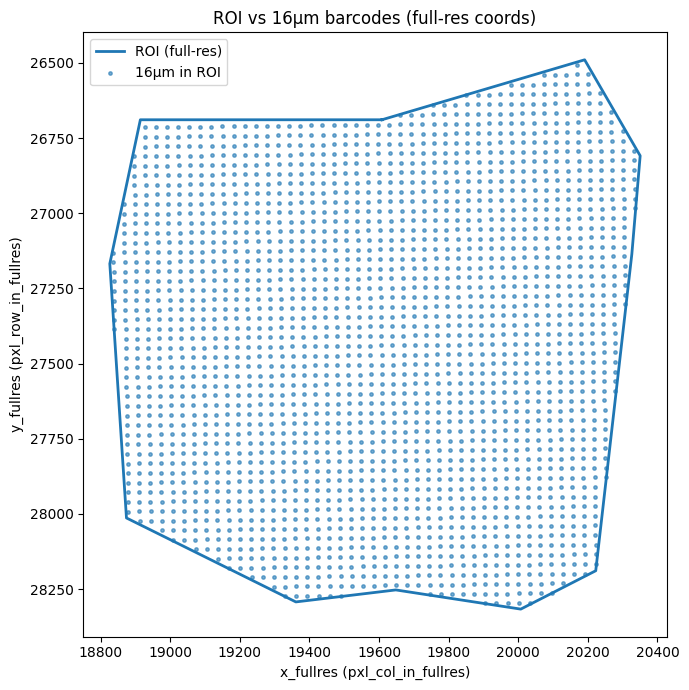

[OK] plot saved: ./roi_check_outputs_b2c_exact/roi_vs_16um_overlay_b2c_exact.png


In [14]:
IMG_KEY         = "0.5_mpp_150_buffer" 
CROPPED_KEY     = "spatial_cropped_150_buffer"
TGT_16UM_PARQUET= "./skin_TXK6Z4X_A1/binned_outputs/square_016um/spatial/tissue_positions.parquet"

OUT_DIR         = "./roi_check_outputs_b2c_exact"
os.makedirs(OUT_DIR, exist_ok=True)


roi_on_processed = [
    (7558.5, 4332.500000000002),
    (6862.5, 4332.500000000002),
    (6774.5, 4812.500000000002),
    (6822.5, 5660.500000000002),
    (7310.5, 5940.500000000002),
    (7598.5, 5900.500000000002),
    (7958.5, 5964.500000000002),
    (8174.5, 5836.500000000002),
    (8278.500000000002, 4780.500000000002),
    (8302.500000000002, 4452.500000000002),
    (8142.5, 4132.500000000002),
]

def get_library_key(adata):
    return list(adata.uns["spatial"].keys())[0]

def get_scalefactor_from_b2c(adata, img_key):
    lib = get_library_key(adata)
    key = f"tissue_{img_key}_scalef"
    return float(adata.uns["spatial"][lib]["scalefactors"][key])

def recover_crop_offset_xy0(adata, cropped_key="spatial_cropped_150_buffer", spatial_key="spatial"):
    if cropped_key not in adata.obsm:
        raise KeyError(f"Could not find {cropped_key}, please check b2c output.")
    S_full = np.asarray(adata.obsm[spatial_key], dtype=float)
    S_crop = np.asarray(adata.obsm[cropped_key], dtype=float)
    D = S_full - S_crop
    x0 = float(np.median(D[:,0]))
    y0 = float(np.median(D[:,1]))
    return x0, y0

def processed_to_fullres(points_uv, x0, y0, scalef):
    """
    image (u,v) = (x0 + u / scalef, y0 + v / scalef)
    """
    arr = np.asarray(points_uv, dtype=float)
    xs = x0 + arr[:,0] / scalef
    ys = y0 + arr[:,1] / scalef
    return np.column_stack([xs, ys])

def select_barcodes_in_polygon(tissue_positions_parquet, polygon_fullres_xy):
    df = pd.read_parquet(tissue_positions_parquet).copy()
    df = df.loc[(df["pxl_row_in_fullres"] >= 0) & (df["pxl_col_in_fullres"] >= 0)]
    pts = np.column_stack([
        df["pxl_col_in_fullres"].to_numpy(dtype=float),
        df["pxl_row_in_fullres"].to_numpy(dtype=float),
    ])
    poly_path = Path(polygon_fullres_xy)
    inside = poly_path.contains_points(pts)
    # barcode finding
    bc_col = "barcode" if "barcode" in df.columns else \
             "Barcode" if "Barcode" in df.columns else \
             "barcodes" if "barcodes" in df.columns else \
             "spot_id" if "spot_id" in df.columns else \
             "barcode_id" if "barcode_id" in df.columns else None
    if bc_col is None:
        raise KeyError(f"Could not find barcode column, existing columns: {list(df.columns)[:20]} ...")

    out = df.loc[inside, [bc_col, "pxl_col_in_fullres", "pxl_row_in_fullres"]].copy()
    out = out.rename(columns={
        bc_col: "barcode",
        "pxl_col_in_fullres": "x_fullres",
        "pxl_row_in_fullres": "y_fullres",
    })
    return out

def main(bdata):
    # read scale factor and crop offset from b2c (ground truth)
    s = get_scalefactor_from_b2c(bdata, IMG_KEY)
    x0, y0 = recover_crop_offset_xy0(bdata, CROPPED_KEY, "spatial")

    print(f"== b2c ground truth ==")
    print(f" scalef (r_x = r_y) : {s:.6f}")
    print(f" crop offset (x0,y0): ({x0:.3f}, {y0:.3f})\n")

    # map processed (u,v) -> full-res (x,y)
    roi_fullres = processed_to_fullres(roi_on_processed, x0, y0, s)

    # save full-res ROI vertices
    roi_fullres_csv = os.path.join(OUT_DIR, "roi_fullres_vertices_from_b2c.csv")
    pd.DataFrame(roi_fullres, columns=["x_fullres", "y_fullres"]).to_csv(roi_fullres_csv, index=False)
    print(f"[OK] ROI full-res vertices: {roi_fullres_csv}")

    # filter barcodes inside ROI
    bc16 = select_barcodes_in_polygon(TGT_16UM_PARQUET, roi_fullres)
    out_csv = os.path.join(OUT_DIR, "barcode_16um_in_roi.csv")
    bc16.to_csv(out_csv, index=False)
    print(f"[OK] 16um ROI barcodes saved: {out_csv}")

    # Plot
    if len(bc16) > 0:
        plt.figure(figsize=(7,7))
        poly = np.vstack([roi_fullres, roi_fullres[0]])
        plt.plot(poly[:,0], poly[:,1], linewidth=2, label="ROI (full-res)")
        plt.scatter(bc16["x_fullres"], bc16["y_fullres"], s=6, alpha=0.6, label="16µm in ROI")
        plt.gca().invert_yaxis()
        plt.xlabel("x_fullres (pxl_col_in_fullres)")
        plt.ylabel("y_fullres (pxl_row_in_fullres)")
        plt.title("ROI vs 16µm barcodes (full-res coords)")
        plt.legend()
        plt.tight_layout()
        plot_path = os.path.join(OUT_DIR, "roi_vs_16um_overlay_b2c_exact.png")
        plt.savefig(plot_path, dpi=160)
        plt.show()
        print(f"[OK] plot saved: {plot_path}")

main(bdata)

### Save barcode for evalution in SPATA2

In [29]:
data = [
    {
        "barcode": "s_016um_00115_00183-1",
        "x_fullres": 19271.64538548361,
        "y_fullres": 26262.61051197978
    },
    {
        "barcode": "s_016um_00115_00184-1",
        "x_fullres": 19239.72044803092,
        "y_fullres": 26263.036326558933
    },
    {
        "barcode": "s_016um_00116_00177-1",
        "x_fullres": 19463.621560822194,
        "y_fullres": 26291.980196107223
    },
    {
        "barcode": "s_016um_00116_00178-1",
        "x_fullres": 19431.696616878296,
        "y_fullres": 26292.40601023942
    },
    {
        "barcode": "s_016um_00116_00179-1",
        "x_fullres": 19399.771674001284,
        "y_fullres": 26292.831824357385
    },
    {
        "barcode": "s_016um_00116_00180-1",
        "x_fullres": 19367.84673219116,
        "y_fullres": 26293.257638461127
    },
    {
        "barcode": "s_016um_00116_00181-1",
        "x_fullres": 19335.92179144792,
        "y_fullres": 26293.68345255064
    },
    {
        "barcode": "s_016um_00116_00182-1",
        "x_fullres": 19303.996851771568,
        "y_fullres": 26294.10926662592
    },
    {
        "barcode": "s_016um_00116_00183-1",
        "x_fullres": 19272.071913162104,
        "y_fullres": 26294.535080686972
    },
    {
        "barcode": "s_016um_00116_00184-1",
        "x_fullres": 19240.146975619522,
        "y_fullres": 26294.96089473379
    },
    {
        "barcode": "s_016um_00116_00185-1",
        "x_fullres": 19208.22203914383,
        "y_fullres": 26295.38670876638
    },
    {
        "barcode": "s_016um_00116_00186-1",
        "x_fullres": 19176.29710373502,
        "y_fullres": 26295.812522784738
    },
    {
        "barcode": "s_016um_00116_00187-1",
        "x_fullres": 19144.372169393093,
        "y_fullres": 26296.238336788865
    },
    {
        "barcode": "s_016um_00117_00170-1",
        "x_fullres": 19687.522727151503,
        "y_fullres": 26320.924072576407
    },
    {
        "barcode": "s_016um_00117_00171-1",
        "x_fullres": 19655.597775649512,
        "y_fullres": 26321.349886275882
    },
    {
        "barcode": "s_016um_00117_00172-1",
        "x_fullres": 19623.672825214413,
        "y_fullres": 26321.77569996113
    },
    {
        "barcode": "s_016um_00117_00173-1",
        "x_fullres": 19591.7478758462,
        "y_fullres": 26322.20151363215
    },
    {
        "barcode": "s_016um_00117_00174-1",
        "x_fullres": 19559.82292754487,
        "y_fullres": 26322.627327288934
    },
    {
        "barcode": "s_016um_00117_00175-1",
        "x_fullres": 19527.89798031043,
        "y_fullres": 26323.053140931494
    },
    {
        "barcode": "s_016um_00117_00176-1",
        "x_fullres": 19495.973034142877,
        "y_fullres": 26323.478954559825
    },
    {
        "barcode": "s_016um_00117_00177-1",
        "x_fullres": 19464.04808904221,
        "y_fullres": 26323.90476817392
    },
    {
        "barcode": "s_016um_00117_00178-1",
        "x_fullres": 19432.123145008423,
        "y_fullres": 26324.330581773782
    },
    {
        "barcode": "s_016um_00117_00179-1",
        "x_fullres": 19400.198202041527,
        "y_fullres": 26324.75639535942
    },
    {
        "barcode": "s_016um_00117_00180-1",
        "x_fullres": 19368.27326014152,
        "y_fullres": 26325.182208930826
    },
    {
        "barcode": "s_016um_00117_00181-1",
        "x_fullres": 19336.348319308396,
        "y_fullres": 26325.60802248801
    },
    {
        "barcode": "s_016um_00117_00182-1",
        "x_fullres": 19304.423379542157,
        "y_fullres": 26326.033836030954
    },
    {
        "barcode": "s_016um_00117_00183-1",
        "x_fullres": 19272.498440842806,
        "y_fullres": 26326.45964955967
    },
    {
        "barcode": "s_016um_00117_00184-1",
        "x_fullres": 19240.573503210344,
        "y_fullres": 26326.88546307416
    },
    {
        "barcode": "s_016um_00117_00185-1",
        "x_fullres": 19208.648566644762,
        "y_fullres": 26327.311276574415
    },
    {
        "barcode": "s_016um_00117_00186-1",
        "x_fullres": 19176.723631146066,
        "y_fullres": 26327.73709006044
    },
    {
        "barcode": "s_016um_00117_00187-1",
        "x_fullres": 19144.798696714253,
        "y_fullres": 26328.162903532237
    },
    {
        "barcode": "s_016um_00117_00188-1",
        "x_fullres": 19112.873763349337,
        "y_fullres": 26328.588716989805
    },
    {
        "barcode": "s_016um_00117_00189-1",
        "x_fullres": 19080.948831051297,
        "y_fullres": 26329.014530433138
    },
    {
        "barcode": "s_016um_00117_00190-1",
        "x_fullres": 19049.02389982015,
        "y_fullres": 26329.440343862247
    },
    {
        "barcode": "s_016um_00117_00191-1",
        "x_fullres": 19017.098969655883,
        "y_fullres": 26329.866157277127
    },
    {
        "barcode": "s_016um_00118_00164-1",
        "x_fullres": 19879.498987958777,
        "y_fullres": 26350.29376923325
    },
    {
        "barcode": "s_016um_00118_00165-1",
        "x_fullres": 19847.574029965584,
        "y_fullres": 26350.719582485777
    },
    {
        "barcode": "s_016um_00118_00166-1",
        "x_fullres": 19815.64907303928,
        "y_fullres": 26351.145395724074
    },
    {
        "barcode": "s_016um_00118_00167-1",
        "x_fullres": 19783.72411717986,
        "y_fullres": 26351.57120894814
    },
    {
        "barcode": "s_016um_00118_00168-1",
        "x_fullres": 19751.799162387328,
        "y_fullres": 26351.997022157975
    },
    {
        "barcode": "s_016um_00118_00169-1",
        "x_fullres": 19719.874208661688,
        "y_fullres": 26352.42283535358
    },
    {
        "barcode": "s_016um_00118_00170-1",
        "x_fullres": 19687.94925600292,
        "y_fullres": 26352.84864853495
    },
    {
        "barcode": "s_016um_00118_00171-1",
        "x_fullres": 19656.02430441105,
        "y_fullres": 26353.274461702094
    },
    {
        "barcode": "s_016um_00118_00172-1",
        "x_fullres": 19624.099353886064,
        "y_fullres": 26353.70027485501
    },
    {
        "barcode": "s_016um_00118_00173-1",
        "x_fullres": 19592.17440442797,
        "y_fullres": 26354.126087993696
    },
    {
        "barcode": "s_016um_00118_00174-1",
        "x_fullres": 19560.249456036756,
        "y_fullres": 26354.55190111815
    },
    {
        "barcode": "s_016um_00118_00175-1",
        "x_fullres": 19528.32450871243,
        "y_fullres": 26354.97771422838
    },
    {
        "barcode": "s_016um_00118_00176-1",
        "x_fullres": 19496.39956245499,
        "y_fullres": 26355.40352732437
    },
    {
        "barcode": "s_016um_00118_00177-1",
        "x_fullres": 19464.474617264437,
        "y_fullres": 26355.829340406137
    },
    {
        "barcode": "s_016um_00118_00178-1",
        "x_fullres": 19432.549673140766,
        "y_fullres": 26356.255153473663
    },
    {
        "barcode": "s_016um_00118_00179-1",
        "x_fullres": 19400.624730083982,
        "y_fullres": 26356.68096652697
    },
    {
        "barcode": "s_016um_00118_00180-1",
        "x_fullres": 19368.69978809409,
        "y_fullres": 26357.106779566046
    },
    {
        "barcode": "s_016um_00118_00181-1",
        "x_fullres": 19336.77484717108,
        "y_fullres": 26357.53259259089
    },
    {
        "barcode": "s_016um_00118_00182-1",
        "x_fullres": 19304.84990731496,
        "y_fullres": 26357.958405601505
    },
    {
        "barcode": "s_016um_00118_00183-1",
        "x_fullres": 19272.924968525724,
        "y_fullres": 26358.38421859789
    },
    {
        "barcode": "s_016um_00118_00184-1",
        "x_fullres": 19241.00003080337,
        "y_fullres": 26358.810031580044
    },
    {
        "barcode": "s_016um_00118_00185-1",
        "x_fullres": 19209.075094147905,
        "y_fullres": 26359.23584454797
    },
    {
        "barcode": "s_016um_00118_00186-1",
        "x_fullres": 19177.150158559325,
        "y_fullres": 26359.66165750166
    },
    {
        "barcode": "s_016um_00118_00187-1",
        "x_fullres": 19145.22522403763,
        "y_fullres": 26360.08747044112
    },
    {
        "barcode": "s_016um_00118_00188-1",
        "x_fullres": 19113.30029058282,
        "y_fullres": 26360.513283366356
    },
    {
        "barcode": "s_016um_00118_00189-1",
        "x_fullres": 19081.375358194902,
        "y_fullres": 26360.939096277358
    },
    {
        "barcode": "s_016um_00118_00190-1",
        "x_fullres": 19049.450426873864,
        "y_fullres": 26361.364909174135
    },
    {
        "barcode": "s_016um_00118_00191-1",
        "x_fullres": 19017.525496619714,
        "y_fullres": 26361.79072205668
    },
    {
        "barcode": "s_016um_00118_00192-1",
        "x_fullres": 18985.600567432448,
        "y_fullres": 26362.21653492499
    },
    {
        "barcode": "s_016um_00118_00193-1",
        "x_fullres": 18953.67563931207,
        "y_fullres": 26362.642347779078
    },
    {
        "barcode": "s_016um_00118_00194-1",
        "x_fullres": 18921.75071225857,
        "y_fullres": 26363.068160618925
    },
    {
        "barcode": "s_016um_00118_00195-1",
        "x_fullres": 18889.825786271962,
        "y_fullres": 26363.49397344455
    },
    {
        "barcode": "s_016um_00119_00157-1",
        "x_fullres": 20103.400253806107,
        "y_fullres": 26379.237659111528
    },
    {
        "barcode": "s_016um_00119_00158-1",
        "x_fullres": 20071.47528825482,
        "y_fullres": 26379.66347193133
    },
    {
        "barcode": "s_016um_00119_00159-1",
        "x_fullres": 20039.55032377042,
        "y_fullres": 26380.089284736907
    },
    {
        "barcode": "s_016um_00119_00160-1",
        "x_fullres": 20007.625360352908,
        "y_fullres": 26380.51509752825
    },
    {
        "barcode": "s_016um_00119_00161-1",
        "x_fullres": 19975.700398002286,
        "y_fullres": 26380.94091030536
    },
    {
        "barcode": "s_016um_00119_00162-1",
        "x_fullres": 19943.77543671854,
        "y_fullres": 26381.366723068237
    },
    {
        "barcode": "s_016um_00119_00163-1",
        "x_fullres": 19911.850476501688,
        "y_fullres": 26381.792535816887
    },
    {
        "barcode": "s_016um_00119_00164-1",
        "x_fullres": 19879.925517351723,
        "y_fullres": 26382.218348551312
    },
    {
        "barcode": "s_016um_00119_00165-1",
        "x_fullres": 19848.000559268643,
        "y_fullres": 26382.644161271506
    },
    {
        "barcode": "s_016um_00119_00166-1",
        "x_fullres": 19816.07560225246,
        "y_fullres": 26383.069973977468
    },
    {
        "barcode": "s_016um_00119_00167-1",
        "x_fullres": 19784.15064630315,
        "y_fullres": 26383.4957866692
    },
    {
        "barcode": "s_016um_00119_00168-1",
        "x_fullres": 19752.22569142074,
        "y_fullres": 26383.9215993467
    },
    {
        "barcode": "s_016um_00119_00169-1",
        "x_fullres": 19720.300737605205,
        "y_fullres": 26384.347412009978
    },
    {
        "barcode": "s_016um_00119_00170-1",
        "x_fullres": 19688.37578485656,
        "y_fullres": 26384.773224659013
    },
    {
        "barcode": "s_016um_00119_00171-1",
        "x_fullres": 19656.4508331748,
        "y_fullres": 26385.199037293823
    },
    {
        "barcode": "s_016um_00119_00172-1",
        "x_fullres": 19624.52588255993,
        "y_fullres": 26385.624849914406
    },
    {
        "barcode": "s_016um_00119_00173-1",
        "x_fullres": 19592.600933011945,
        "y_fullres": 26386.050662520756
    },
    {
        "barcode": "s_016um_00119_00174-1",
        "x_fullres": 19560.675984530848,
        "y_fullres": 26386.476475112882
    },
    {
        "barcode": "s_016um_00119_00175-1",
        "x_fullres": 19528.75103711664,
        "y_fullres": 26386.902287690773
    },
    {
        "barcode": "s_016um_00119_00176-1",
        "x_fullres": 19496.82609076931,
        "y_fullres": 26387.328100254435
    },
    {
        "barcode": "s_016um_00119_00177-1",
        "x_fullres": 19464.901145488875,
        "y_fullres": 26387.753912803866
    },
    {
        "barcode": "s_016um_00119_00178-1",
        "x_fullres": 19432.976201275316,
        "y_fullres": 26388.17972533906
    },
    {
        "barcode": "s_016um_00119_00179-1",
        "x_fullres": 19401.051258128653,
        "y_fullres": 26388.605537860036
    },
    {
        "barcode": "s_016um_00119_00180-1",
        "x_fullres": 19369.12631604887,
        "y_fullres": 26389.03135036678
    },
    {
        "barcode": "s_016um_00119_00181-1",
        "x_fullres": 19337.20137503598,
        "y_fullres": 26389.45716285929
    },
    {
        "barcode": "s_016um_00119_00182-1",
        "x_fullres": 19305.27643508997,
        "y_fullres": 26389.88297533757
    },
    {
        "barcode": "s_016um_00119_00183-1",
        "x_fullres": 19273.35149621085,
        "y_fullres": 26390.30878780162
    },
    {
        "barcode": "s_016um_00119_00184-1",
        "x_fullres": 19241.42655839861,
        "y_fullres": 26390.734600251446
    },
    {
        "barcode": "s_016um_00119_00185-1",
        "x_fullres": 19209.501621653264,
        "y_fullres": 26391.160412687037
    },
    {
        "barcode": "s_016um_00119_00186-1",
        "x_fullres": 19177.576685974793,
        "y_fullres": 26391.58622510839
    },
    {
        "barcode": "s_016um_00119_00187-1",
        "x_fullres": 19145.651751363213,
        "y_fullres": 26392.01203751552
    },
    {
        "barcode": "s_016um_00119_00188-1",
        "x_fullres": 19113.726817818522,
        "y_fullres": 26392.437849908427
    },
    {
        "barcode": "s_016um_00119_00189-1",
        "x_fullres": 19081.801885340716,
        "y_fullres": 26392.863662287098
    },
    {
        "barcode": "s_016um_00119_00190-1",
        "x_fullres": 19049.87695392979,
        "y_fullres": 26393.289474651538
    },
    {
        "barcode": "s_016um_00119_00191-1",
        "x_fullres": 19017.952023585756,
        "y_fullres": 26393.71528700175
    },
    {
        "barcode": "s_016um_00119_00192-1",
        "x_fullres": 18986.027094308607,
        "y_fullres": 26394.14109933773
    },
    {
        "barcode": "s_016um_00119_00193-1",
        "x_fullres": 18954.10216609834,
        "y_fullres": 26394.566911659484
    },
    {
        "barcode": "s_016um_00119_00194-1",
        "x_fullres": 18922.17723895496,
        "y_fullres": 26394.992723966996
    },
    {
        "barcode": "s_016um_00119_00195-1",
        "x_fullres": 18890.252312878463,
        "y_fullres": 26395.418536260288
    },
    {
        "barcode": "s_016um_00119_00196-1",
        "x_fullres": 18858.327387868852,
        "y_fullres": 26395.844348539347
    },
    {
        "barcode": "s_016um_00120_00151-1",
        "x_fullres": 20295.37660008214,
        "y_fullres": 26408.6073682978
    },
    {
        "barcode": "s_016um_00120_00152-1",
        "x_fullres": 20263.451628039642,
        "y_fullres": 26409.03318067065
    },
    {
        "barcode": "s_016um_00120_00153-1",
        "x_fullres": 20231.526657064034,
        "y_fullres": 26409.458993029268
    },
    {
        "barcode": "s_016um_00120_00154-1",
        "x_fullres": 20199.601687155307,
        "y_fullres": 26409.88480537365
    },
    {
        "barcode": "s_016um_00120_00155-1",
        "x_fullres": 20167.676718313473,
        "y_fullres": 26410.31061770381
    },
    {
        "barcode": "s_016um_00120_00156-1",
        "x_fullres": 20135.751750538526,
        "y_fullres": 26410.73643001974
    },
    {
        "barcode": "s_016um_00120_00157-1",
        "x_fullres": 20103.826783830467,
        "y_fullres": 26411.16224232144
    },
    {
        "barcode": "s_016um_00120_00158-1",
        "x_fullres": 20071.901818189293,
        "y_fullres": 26411.58805460891
    },
    {
        "barcode": "s_016um_00120_00159-1",
        "x_fullres": 20039.976853615008,
        "y_fullres": 26412.01386688215
    },
    {
        "barcode": "s_016um_00120_00160-1",
        "x_fullres": 20008.05189010761,
        "y_fullres": 26412.439679141156
    },
    {
        "barcode": "s_016um_00120_00161-1",
        "x_fullres": 19976.1269276671,
        "y_fullres": 26412.86549138594
    },
    {
        "barcode": "s_016um_00120_00162-1",
        "x_fullres": 19944.20196629347,
        "y_fullres": 26413.291303616483
    },
    {
        "barcode": "s_016um_00120_00163-1",
        "x_fullres": 19912.277005986733,
        "y_fullres": 26413.717115832802
    },
    {
        "barcode": "s_016um_00120_00164-1",
        "x_fullres": 19880.352046746884,
        "y_fullres": 26414.14292803489
    },
    {
        "barcode": "s_016um_00120_00165-1",
        "x_fullres": 19848.42708857392,
        "y_fullres": 26414.56874022275
    },
    {
        "barcode": "s_016um_00120_00166-1",
        "x_fullres": 19816.50213146785,
        "y_fullres": 26414.99455239638
    },
    {
        "barcode": "s_016um_00120_00167-1",
        "x_fullres": 19784.577175428658,
        "y_fullres": 26415.42036455578
    },
    {
        "barcode": "s_016um_00120_00168-1",
        "x_fullres": 19752.652220456355,
        "y_fullres": 26415.846176700947
    },
    {
        "barcode": "s_016um_00120_00169-1",
        "x_fullres": 19720.727266550937,
        "y_fullres": 26416.271988831886
    },
    {
        "barcode": "s_016um_00120_00170-1",
        "x_fullres": 19688.802313712407,
        "y_fullres": 26416.69780094859
    },
    {
        "barcode": "s_016um_00120_00171-1",
        "x_fullres": 19656.877361940762,
        "y_fullres": 26417.12361305107
    },
    {
        "barcode": "s_016um_00120_00172-1",
        "x_fullres": 19624.952411236005,
        "y_fullres": 26417.549425139317
    },
    {
        "barcode": "s_016um_00120_00173-1",
        "x_fullres": 19593.02746159814,
        "y_fullres": 26417.975237213337
    },
    {
        "barcode": "s_016um_00120_00174-1",
        "x_fullres": 19561.102513027156,
        "y_fullres": 26418.401049273125
    },
    {
        "barcode": "s_016um_00120_00175-1",
        "x_fullres": 19529.177565523056,
        "y_fullres": 26418.826861318685
    },
    {
        "barcode": "s_016um_00120_00176-1",
        "x_fullres": 19497.252619085848,
        "y_fullres": 26419.252673350016
    },
    {
        "barcode": "s_016um_00120_00177-1",
        "x_fullres": 19465.327673715525,
        "y_fullres": 26419.678485367112
    },
    {
        "barcode": "s_016um_00120_00178-1",
        "x_fullres": 19433.402729412082,
        "y_fullres": 26420.104297369977
    },
    {
        "barcode": "s_016um_00120_00179-1",
        "x_fullres": 19401.47778617553,
        "y_fullres": 26420.530109358613
    },
    {
        "barcode": "s_016um_00120_00180-1",
        "x_fullres": 19369.552844005866,
        "y_fullres": 26420.95592133302
    },
    {
        "barcode": "s_016um_00120_00181-1",
        "x_fullres": 19337.627902903085,
        "y_fullres": 26421.381733293205
    },
    {
        "barcode": "s_016um_00120_00182-1",
        "x_fullres": 19305.70296286719,
        "y_fullres": 26421.807545239153
    },
    {
        "barcode": "s_016um_00120_00183-1",
        "x_fullres": 19273.778023898183,
        "y_fullres": 26422.23335717087
    },
    {
        "barcode": "s_016um_00120_00184-1",
        "x_fullres": 19241.853085996063,
        "y_fullres": 26422.659169088358
    },
    {
        "barcode": "s_016um_00120_00185-1",
        "x_fullres": 19209.928149160827,
        "y_fullres": 26423.084980991614
    },
    {
        "barcode": "s_016um_00120_00186-1",
        "x_fullres": 19178.003213392476,
        "y_fullres": 26423.510792880643
    },
    {
        "barcode": "s_016um_00120_00187-1",
        "x_fullres": 19146.078278691013,
        "y_fullres": 26423.93660475544
    },
    {
        "barcode": "s_016um_00120_00188-1",
        "x_fullres": 19114.15334505643,
        "y_fullres": 26424.362416616008
    },
    {
        "barcode": "s_016um_00120_00189-1",
        "x_fullres": 19082.228412488737,
        "y_fullres": 26424.788228462345
    },
    {
        "barcode": "s_016um_00120_00190-1",
        "x_fullres": 19050.303480987935,
        "y_fullres": 26425.214040294453
    },
    {
        "barcode": "s_016um_00120_00191-1",
        "x_fullres": 19018.37855055401,
        "y_fullres": 26425.639852112334
    },
    {
        "barcode": "s_016um_00120_00192-1",
        "x_fullres": 18986.453621186974,
        "y_fullres": 26426.065663915982
    },
    {
        "barcode": "s_016um_00120_00193-1",
        "x_fullres": 18954.528692886823,
        "y_fullres": 26426.491475705396
    },
    {
        "barcode": "s_016um_00120_00194-1",
        "x_fullres": 18922.603765653555,
        "y_fullres": 26426.91728748058
    },
    {
        "barcode": "s_016um_00120_00195-1",
        "x_fullres": 18890.678839487176,
        "y_fullres": 26427.34309924154
    },
    {
        "barcode": "s_016um_00120_00196-1",
        "x_fullres": 18858.75391438768,
        "y_fullres": 26427.76891098827
    },
    {
        "barcode": "s_016um_00121_00144-1",
        "x_fullres": 20519.277965447563,
        "y_fullres": 26437.551271585173
    },
    {
        "barcode": "s_016um_00121_00145-1",
        "x_fullres": 20487.352985846963,
        "y_fullres": 26437.9770835253
    },
    {
        "barcode": "s_016um_00121_00146-1",
        "x_fullres": 20455.428007313254,
        "y_fullres": 26438.402895451192
    },
    {
        "barcode": "s_016um_00121_00147-1",
        "x_fullres": 20423.50302984643,
        "y_fullres": 26438.828707362856
    },
    {
        "barcode": "s_016um_00121_00148-1",
        "x_fullres": 20391.578053446498,
        "y_fullres": 26439.254519260292
    },
    {
        "barcode": "s_016um_00121_00149-1",
        "x_fullres": 20359.65307811345,
        "y_fullres": 26439.6803311435
    },
    {
        "barcode": "s_016um_00121_00150-1",
        "x_fullres": 20327.728103847294,
        "y_fullres": 26440.10614301248
    },
    {
        "barcode": "s_016um_00121_00151-1",
        "x_fullres": 20295.803130648022,
        "y_fullres": 26440.531954867223
    },
    {
        "barcode": "s_016um_00121_00152-1",
        "x_fullres": 20263.878158515643,
        "y_fullres": 26440.95776670774
    },
    {
        "barcode": "s_016um_00121_00153-1",
        "x_fullres": 20231.953187450148,
        "y_fullres": 26441.383578534023
    },
    {
        "barcode": "s_016um_00121_00154-1",
        "x_fullres": 20200.028217451534,
        "y_fullres": 26441.809390346076
    },
    {
        "barcode": "s_016um_00121_00155-1",
        "x_fullres": 20168.103248519812,
        "y_fullres": 26442.235202143904
    },
    {
        "barcode": "s_016um_00121_00156-1",
        "x_fullres": 20136.17828065498,
        "y_fullres": 26442.6610139275
    },
    {
        "barcode": "s_016um_00121_00157-1",
        "x_fullres": 20104.253313857036,
        "y_fullres": 26443.086825696864
    },
    {
        "barcode": "s_016um_00121_00158-1",
        "x_fullres": 20072.328348125975,
        "y_fullres": 26443.512637452
    },
    {
        "barcode": "s_016um_00121_00159-1",
        "x_fullres": 20040.40338346181,
        "y_fullres": 26443.938449192905
    },
    {
        "barcode": "s_016um_00121_00160-1",
        "x_fullres": 20008.478419864525,
        "y_fullres": 26444.364260919585
    },
    {
        "barcode": "s_016um_00121_00161-1",
        "x_fullres": 19976.553457334125,
        "y_fullres": 26444.79007263203
    },
    {
        "barcode": "s_016um_00121_00162-1",
        "x_fullres": 19944.628495870613,
        "y_fullres": 26445.21588433024
    },
    {
        "barcode": "s_016um_00121_00163-1",
        "x_fullres": 19912.703535473993,
        "y_fullres": 26445.641696014227
    },
    {
        "barcode": "s_016um_00121_00164-1",
        "x_fullres": 19880.778576144254,
        "y_fullres": 26446.06750768398
    },
    {
        "barcode": "s_016um_00121_00165-1",
        "x_fullres": 19848.853617881407,
        "y_fullres": 26446.493319339508
    },
    {
        "barcode": "s_016um_00121_00166-1",
        "x_fullres": 19816.928660685448,
        "y_fullres": 26446.919130980805
    },
    {
        "barcode": "s_016um_00121_00167-1",
        "x_fullres": 19785.00370455637,
        "y_fullres": 26447.34494260787
    },
    {
        "barcode": "s_016um_00121_00168-1",
        "x_fullres": 19753.078749494183,
        "y_fullres": 26447.770754220706
    },
    {
        "barcode": "s_016um_00121_00169-1",
        "x_fullres": 19721.15379549888,
        "y_fullres": 26448.19656581931
    },
    {
        "barcode": "s_016um_00121_00170-1",
        "x_fullres": 19689.228842570465,
        "y_fullres": 26448.622377403684
    },
    {
        "barcode": "s_016um_00121_00171-1",
        "x_fullres": 19657.303890708936,
        "y_fullres": 26449.04818897383
    },
    {
        "barcode": "s_016um_00121_00172-1",
        "x_fullres": 19625.378939914295,
        "y_fullres": 26449.474000529743
    },
    {
        "barcode": "s_016um_00121_00173-1",
        "x_fullres": 19593.45399018654,
        "y_fullres": 26449.899812071428
    },
    {
        "barcode": "s_016um_00121_00174-1",
        "x_fullres": 19561.52904152567,
        "y_fullres": 26450.325623598885
    },
    {
        "barcode": "s_016um_00121_00175-1",
        "x_fullres": 19529.604093931688,
        "y_fullres": 26450.751435112114
    },
    {
        "barcode": "s_016um_00121_00176-1",
        "x_fullres": 19497.679147404593,
        "y_fullres": 26451.177246611107
    },
    {
        "barcode": "s_016um_00121_00177-1",
        "x_fullres": 19465.75420194438,
        "y_fullres": 26451.60305809587
    },
    {
        "barcode": "s_016um_00121_00178-1",
        "x_fullres": 19433.829257551057,
        "y_fullres": 26452.028869566402
    },
    {
        "barcode": "s_016um_00121_00179-1",
        "x_fullres": 19401.904314224623,
        "y_fullres": 26452.454681022708
    },
    {
        "barcode": "s_016um_00121_00180-1",
        "x_fullres": 19369.97937196507,
        "y_fullres": 26452.880492464785
    },
    {
        "barcode": "s_016um_00121_00181-1",
        "x_fullres": 19338.054430772405,
        "y_fullres": 26453.30630389263
    },
    {
        "barcode": "s_016um_00121_00182-1",
        "x_fullres": 19306.129490646625,
        "y_fullres": 26453.732115306248
    },
    {
        "barcode": "s_016um_00121_00183-1",
        "x_fullres": 19274.204551587733,
        "y_fullres": 26454.15792670563
    },
    {
        "barcode": "s_016um_00121_00184-1",
        "x_fullres": 19242.279613595725,
        "y_fullres": 26454.583738090787
    },
    {
        "barcode": "s_016um_00121_00185-1",
        "x_fullres": 19210.354676670602,
        "y_fullres": 26455.00954946171
    },
    {
        "barcode": "s_016um_00121_00186-1",
        "x_fullres": 19178.429740812368,
        "y_fullres": 26455.435360818403
    },
    {
        "barcode": "s_016um_00121_00187-1",
        "x_fullres": 19146.504806021017,
        "y_fullres": 26455.86117216087
    },
    {
        "barcode": "s_016um_00121_00188-1",
        "x_fullres": 19114.579872296552,
        "y_fullres": 26456.286983489103
    },
    {
        "barcode": "s_016um_00121_00189-1",
        "x_fullres": 19082.65493963898,
        "y_fullres": 26456.71279480311
    },
    {
        "barcode": "s_016um_00121_00190-1",
        "x_fullres": 19050.730008048286,
        "y_fullres": 26457.138606102886
    },
    {
        "barcode": "s_016um_00121_00191-1",
        "x_fullres": 19018.805077524477,
        "y_fullres": 26457.564417388432
    },
    {
        "barcode": "s_016um_00121_00192-1",
        "x_fullres": 18986.880148067557,
        "y_fullres": 26457.990228659746
    },
    {
        "barcode": "s_016um_00121_00193-1",
        "x_fullres": 18954.955219677515,
        "y_fullres": 26458.416039916825
    },
    {
        "barcode": "s_016um_00121_00194-1",
        "x_fullres": 18923.030292354364,
        "y_fullres": 26458.841851159683
    },
    {
        "barcode": "s_016um_00121_00195-1",
        "x_fullres": 18891.105366098098,
        "y_fullres": 26459.26766238831
    },
    {
        "barcode": "s_016um_00121_00196-1",
        "x_fullres": 18859.18044090872,
        "y_fullres": 26459.693473602707
    },
    {
        "barcode": "s_016um_00122_00142-1",
        "x_fullres": 20583.554459226485,
        "y_fullres": 26468.62423918817
    },
    {
        "barcode": "s_016um_00122_00143-1",
        "x_fullres": 20551.629477402224,
        "y_fullres": 26469.050050624424
    },
    {
        "barcode": "s_016um_00122_00144-1",
        "x_fullres": 20519.70449664486,
        "y_fullres": 26469.47586204645
    },
    {
        "barcode": "s_016um_00122_00145-1",
        "x_fullres": 20487.779516954375,
        "y_fullres": 26469.901673454242
    },
    {
        "barcode": "s_016um_00122_00146-1",
        "x_fullres": 20455.854538330772,
        "y_fullres": 26470.3274848478
    },
    {
        "barcode": "s_016um_00122_00147-1",
        "x_fullres": 20423.929560774064,
        "y_fullres": 26470.753296227133
    },
    {
        "barcode": "s_016um_00122_00148-1",
        "x_fullres": 20392.00458428425,
        "y_fullres": 26471.179107592234
    },
    {
        "barcode": "s_016um_00122_00149-1",
        "x_fullres": 20360.079608861317,
        "y_fullres": 26471.60491894311
    },
    {
        "barcode": "s_016um_00122_00150-1",
        "x_fullres": 20328.154634505274,
        "y_fullres": 26472.030730279752
    },
    {
        "barcode": "s_016um_00122_00151-1",
        "x_fullres": 20296.22966121612,
        "y_fullres": 26472.456541602165
    },
    {
        "barcode": "s_016um_00122_00152-1",
        "x_fullres": 20264.30468899385,
        "y_fullres": 26472.882352910347
    },
    {
        "barcode": "s_016um_00122_00153-1",
        "x_fullres": 20232.379717838467,
        "y_fullres": 26473.3081642043
    },
    {
        "barcode": "s_016um_00122_00154-1",
        "x_fullres": 20200.45474774997,
        "y_fullres": 26473.733975484018
    },
    {
        "barcode": "s_016um_00122_00155-1",
        "x_fullres": 20168.529778728367,
        "y_fullres": 26474.15978674951
    },
    {
        "barcode": "s_016um_00122_00156-1",
        "x_fullres": 20136.604810773646,
        "y_fullres": 26474.585598000773
    },
    {
        "barcode": "s_016um_00122_00157-1",
        "x_fullres": 20104.67984388582,
        "y_fullres": 26475.011409237803
    },
    {
        "barcode": "s_016um_00122_00158-1",
        "x_fullres": 20072.754878064876,
        "y_fullres": 26475.437220460608
    },
    {
        "barcode": "s_016um_00122_00159-1",
        "x_fullres": 20040.829913310816,
        "y_fullres": 26475.86303166918
    },
    {
        "barcode": "s_016um_00122_00160-1",
        "x_fullres": 20008.904949623648,
        "y_fullres": 26476.288842863523
    },
    {
        "barcode": "s_016um_00122_00161-1",
        "x_fullres": 19976.979987003364,
        "y_fullres": 26476.71465404363
    },
    {
        "barcode": "s_016um_00122_00162-1",
        "x_fullres": 19945.05502544997,
        "y_fullres": 26477.14046520951
    },
    {
        "barcode": "s_016um_00122_00163-1",
        "x_fullres": 19913.130064963458,
        "y_fullres": 26477.566276361165
    },
    {
        "barcode": "s_016um_00122_00164-1",
        "x_fullres": 19881.20510554384,
        "y_fullres": 26477.99208749859
    },
    {
        "barcode": "s_016um_00122_00165-1",
        "x_fullres": 19849.280147191104,
        "y_fullres": 26478.41789862178
    },
    {
        "barcode": "s_016um_00122_00166-1",
        "x_fullres": 19817.355189905258,
        "y_fullres": 26478.843709730743
    },
    {
        "barcode": "s_016um_00122_00167-1",
        "x_fullres": 19785.430233686297,
        "y_fullres": 26479.269520825477
    },
    {
        "barcode": "s_016um_00122_00168-1",
        "x_fullres": 19753.505278534227,
        "y_fullres": 26479.69533190598
    },
    {
        "barcode": "s_016um_00122_00169-1",
        "x_fullres": 19721.580324449034,
        "y_fullres": 26480.121142972246
    },
    {
        "barcode": "s_016um_00122_00170-1",
        "x_fullres": 19689.655371430737,
        "y_fullres": 26480.54695402429
    },
    {
        "barcode": "s_016um_00122_00171-1",
        "x_fullres": 19657.73041947932,
        "y_fullres": 26480.972765062103
    },
    {
        "barcode": "s_016um_00122_00172-1",
        "x_fullres": 19625.805468594794,
        "y_fullres": 26481.398576085685
    },
    {
        "barcode": "s_016um_00122_00173-1",
        "x_fullres": 19593.880518777154,
        "y_fullres": 26481.824387095035
    },
    {
        "barcode": "s_016um_00122_00174-1",
        "x_fullres": 19561.9555700264,
        "y_fullres": 26482.25019809016
    },
    {
        "barcode": "s_016um_00122_00175-1",
        "x_fullres": 19530.030622342532,
        "y_fullres": 26482.676009071052
    },
    {
        "barcode": "s_016um_00122_00176-1",
        "x_fullres": 19498.10567572555,
        "y_fullres": 26483.101820037715
    },
    {
        "barcode": "s_016um_00122_00177-1",
        "x_fullres": 19466.180730175456,
        "y_fullres": 26483.527630990142
    },
    {
        "barcode": "s_016um_00122_00178-1",
        "x_fullres": 19434.255785692243,
        "y_fullres": 26483.953441928345
    },
    {
        "barcode": "s_016um_00122_00179-1",
        "x_fullres": 19402.330842275922,
        "y_fullres": 26484.37925285232
    },
    {
        "barcode": "s_016um_00122_00180-1",
        "x_fullres": 19370.405899926485,
        "y_fullres": 26484.80506376206
    },
    {
        "barcode": "s_016um_00122_00181-1",
        "x_fullres": 19338.480958643937,
        "y_fullres": 26485.230874657573
    },
    {
        "barcode": "s_016um_00122_00182-1",
        "x_fullres": 19306.556018428273,
        "y_fullres": 26485.656685538856
    },
    {
        "barcode": "s_016um_00122_00183-1",
        "x_fullres": 19274.631079279494,
        "y_fullres": 26486.082496405907
    },
    {
        "barcode": "s_016um_00122_00184-1",
        "x_fullres": 19242.706141197603,
        "y_fullres": 26486.508307258733
    },
    {
        "barcode": "s_016um_00122_00185-1",
        "x_fullres": 19210.781204182593,
        "y_fullres": 26486.93411809732
    },
    {
        "barcode": "s_016um_00122_00186-1",
        "x_fullres": 19178.85626823447,
        "y_fullres": 26487.35992892168
    },
    {
        "barcode": "s_016um_00122_00187-1",
        "x_fullres": 19146.931333353234,
        "y_fullres": 26487.785739731815
    },
    {
        "barcode": "s_016um_00122_00188-1",
        "x_fullres": 19115.00639953889,
        "y_fullres": 26488.211550527718
    },
    {
        "barcode": "s_016um_00122_00189-1",
        "x_fullres": 19083.081466791424,
        "y_fullres": 26488.637361309393
    },
    {
        "barcode": "s_016um_00122_00190-1",
        "x_fullres": 19051.156535110847,
        "y_fullres": 26489.063172076832
    },
    {
        "barcode": "s_016um_00122_00191-1",
        "x_fullres": 19019.231604497156,
        "y_fullres": 26489.488982830044
    },
    {
        "barcode": "s_016um_00122_00192-1",
        "x_fullres": 18987.30667495035,
        "y_fullres": 26489.914793569027
    },
    {
        "barcode": "s_016um_00122_00193-1",
        "x_fullres": 18955.381746470423,
        "y_fullres": 26490.34060429378
    },
    {
        "barcode": "s_016um_00122_00194-1",
        "x_fullres": 18923.45681905739,
        "y_fullres": 26490.7664150043
    },
    {
        "barcode": "s_016um_00122_00195-1",
        "x_fullres": 18891.531892711235,
        "y_fullres": 26491.192225700594
    },
    {
        "barcode": "s_016um_00122_00196-1",
        "x_fullres": 18859.60696743197,
        "y_fullres": 26491.618036382653
    },
    {
        "barcode": "s_016um_00123_00141-1",
        "x_fullres": 20615.905973586792,
        "y_fullres": 26500.12301996148
    },
    {
        "barcode": "s_016um_00123_00142-1",
        "x_fullres": 20583.980990605764,
        "y_fullres": 26500.54883087963
    },
    {
        "barcode": "s_016um_00123_00143-1",
        "x_fullres": 20552.05600869162,
        "y_fullres": 26500.974641783552
    },
    {
        "barcode": "s_016um_00123_00144-1",
        "x_fullres": 20520.13102784436,
        "y_fullres": 26501.400452673242
    },
    {
        "barcode": "s_016um_00123_00145-1",
        "x_fullres": 20488.206048063992,
        "y_fullres": 26501.8262635487
    },
    {
        "barcode": "s_016um_00123_00146-1",
        "x_fullres": 20456.281069350505,
        "y_fullres": 26502.252074409924
    },
    {
        "barcode": "s_016um_00123_00147-1",
        "x_fullres": 20424.356091703914,
        "y_fullres": 26502.677885256922
    },
    {
        "barcode": "s_016um_00123_00148-1",
        "x_fullres": 20392.43111512421,
        "y_fullres": 26503.103696089693
    },
    {
        "barcode": "s_016um_00123_00149-1",
        "x_fullres": 20360.506139611396,
        "y_fullres": 26503.52950690823
    },
    {
        "barcode": "s_016um_00123_00150-1",
        "x_fullres": 20328.581165165466,
        "y_fullres": 26503.95531771254
    },
    {
        "barcode": "s_016um_00123_00151-1",
        "x_fullres": 20296.656191786424,
        "y_fullres": 26504.38112850262
    },
    {
        "barcode": "s_016um_00123_00152-1",
        "x_fullres": 20264.73121947427,
        "y_fullres": 26504.806939278467
    },
    {
        "barcode": "s_016um_00123_00153-1",
        "x_fullres": 20232.806248229,
        "y_fullres": 26505.232750040082
    },
    {
        "barcode": "s_016um_00123_00154-1",
        "x_fullres": 20200.88127805062,
        "y_fullres": 26505.658560787473
    },
    {
        "barcode": "s_016um_00123_00155-1",
        "x_fullres": 20168.956308939127,
        "y_fullres": 26506.084371520632
    },
    {
        "barcode": "s_016um_00123_00156-1",
        "x_fullres": 20137.031340894526,
        "y_fullres": 26506.51018223956
    },
    {
        "barcode": "s_016um_00123_00157-1",
        "x_fullres": 20105.10637391681,
        "y_fullres": 26506.935992944258
    },
    {
        "barcode": "s_016um_00123_00158-1",
        "x_fullres": 20073.18140800598,
        "y_fullres": 26507.361803634732
    },
    {
        "barcode": "s_016um_00123_00159-1",
        "x_fullres": 20041.256443162038,
        "y_fullres": 26507.787614310968
    },
    {
        "barcode": "s_016um_00123_00160-1",
        "x_fullres": 20009.331479384986,
        "y_fullres": 26508.21342497298
    },
    {
        "barcode": "s_016um_00123_00161-1",
        "x_fullres": 19977.40651667481,
        "y_fullres": 26508.63923562075
    },
    {
        "barcode": "s_016um_00123_00162-1",
        "x_fullres": 19945.481555031532,
        "y_fullres": 26509.065046254298
    },
    {
        "barcode": "s_016um_00123_00163-1",
        "x_fullres": 19913.55659445514,
        "y_fullres": 26509.49085687362
    },
    {
        "barcode": "s_016um_00123_00164-1",
        "x_fullres": 19881.631634945632,
        "y_fullres": 26509.916667478712
    },
    {
        "barcode": "s_016um_00123_00165-1",
        "x_fullres": 19849.706676503014,
        "y_fullres": 26510.342478069568
    },
    {
        "barcode": "s_016um_00123_00166-1",
        "x_fullres": 19817.781719127284,
        "y_fullres": 26510.7682886462
    },
    {
        "barcode": "s_016um_00123_00167-1",
        "x_fullres": 19785.856762818436,
        "y_fullres": 26511.194099208602
    },
    {
        "barcode": "s_016um_00123_00168-1",
        "x_fullres": 19753.931807576475,
        "y_fullres": 26511.61990975677
    },
    {
        "barcode": "s_016um_00123_00169-1",
        "x_fullres": 19722.006853401403,
        "y_fullres": 26512.045720290702
    },
    {
        "barcode": "s_016um_00123_00170-1",
        "x_fullres": 19690.081900293215,
        "y_fullres": 26512.47153081041
    },
    {
        "barcode": "s_016um_00123_00171-1",
        "x_fullres": 19658.156948251915,
        "y_fullres": 26512.89734131589
    },
    {
        "barcode": "s_016um_00123_00172-1",
        "x_fullres": 19626.231997277504,
        "y_fullres": 26513.32315180714
    },
    {
        "barcode": "s_016um_00123_00173-1",
        "x_fullres": 19594.30704736998,
        "y_fullres": 26513.74896228416
    },
    {
        "barcode": "s_016um_00123_00174-1",
        "x_fullres": 19562.38209852934,
        "y_fullres": 26514.17477274695
    },
    {
        "barcode": "s_016um_00123_00175-1",
        "x_fullres": 19530.45715075559,
        "y_fullres": 26514.600583195508
    },
    {
        "barcode": "s_016um_00123_00176-1",
        "x_fullres": 19498.532204048723,
        "y_fullres": 26515.026393629836
    },
    {
        "barcode": "s_016um_00123_00177-1",
        "x_fullres": 19466.607258408738,
        "y_fullres": 26515.452204049932
    },
    {
        "barcode": "s_016um_00123_00178-1",
        "x_fullres": 19434.68231383564,
        "y_fullres": 26515.878014455804
    },
    {
        "barcode": "s_016um_00123_00179-1",
        "x_fullres": 19402.757370329433,
        "y_fullres": 26516.30382484744
    },
    {
        "barcode": "s_016um_00123_00180-1",
        "x_fullres": 19370.832427890113,
        "y_fullres": 26516.729635224852
    },
    {
        "barcode": "s_016um_00123_00181-1",
        "x_fullres": 19338.907486517677,
        "y_fullres": 26517.15544558803
    },
    {
        "barcode": "s_016um_00123_00182-1",
        "x_fullres": 19306.98254621213,
        "y_fullres": 26517.581255936984
    },
    {
        "barcode": "s_016um_00123_00183-1",
        "x_fullres": 19275.057606973467,
        "y_fullres": 26518.0070662717
    },
    {
        "barcode": "s_016um_00123_00184-1",
        "x_fullres": 19243.13266880169,
        "y_fullres": 26518.43287659219
    },
    {
        "barcode": "s_016um_00123_00185-1",
        "x_fullres": 19211.20773169679,
        "y_fullres": 26518.858686898446
    },
    {
        "barcode": "s_016um_00123_00186-1",
        "x_fullres": 19179.282795658786,
        "y_fullres": 26519.284497190474
    },
    {
        "barcode": "s_016um_00123_00187-1",
        "x_fullres": 19147.357860687665,
        "y_fullres": 26519.710307468275
    },
    {
        "barcode": "s_016um_00123_00188-1",
        "x_fullres": 19115.432926783433,
        "y_fullres": 26520.136117731847
    },
    {
        "barcode": "s_016um_00123_00189-1",
        "x_fullres": 19083.507993946085,
        "y_fullres": 26520.561927981184
    },
    {
        "barcode": "s_016um_00123_00190-1",
        "x_fullres": 19051.58306217562,
        "y_fullres": 26520.987738216292
    },
    {
        "barcode": "s_016um_00123_00191-1",
        "x_fullres": 19019.658131472042,
        "y_fullres": 26521.413548437173
    },
    {
        "barcode": "s_016um_00123_00192-1",
        "x_fullres": 18987.733201835348,
        "y_fullres": 26521.839358643825
    },
    {
        "barcode": "s_016um_00123_00193-1",
        "x_fullres": 18955.808273265542,
        "y_fullres": 26522.26516883624
    },
    {
        "barcode": "s_016um_00123_00194-1",
        "x_fullres": 18923.88334576262,
        "y_fullres": 26522.690979014427
    },
    {
        "barcode": "s_016um_00123_00195-1",
        "x_fullres": 18891.958419326587,
        "y_fullres": 26523.116789178388
    },
    {
        "barcode": "s_016um_00123_00196-1",
        "x_fullres": 18860.033493957435,
        "y_fullres": 26523.54259932812
    },
    {
        "barcode": "s_016um_00124_00141-1",
        "x_fullres": 20616.332505058166,
        "y_fullres": 26532.04761235079
    },
    {
        "barcode": "s_016um_00124_00142-1",
        "x_fullres": 20584.40752198725,
        "y_fullres": 26532.473422736606
    },
    {
        "barcode": "s_016um_00124_00143-1",
        "x_fullres": 20552.48253998322,
        "y_fullres": 26532.899233108194
    },
    {
        "barcode": "s_016um_00124_00144-1",
        "x_fullres": 20520.557559046076,
        "y_fullres": 26533.325043465546
    },
    {
        "barcode": "s_016um_00124_00145-1",
        "x_fullres": 20488.632579175817,
        "y_fullres": 26533.75085380867
    },
    {
        "barcode": "s_016um_00124_00146-1",
        "x_fullres": 20456.707600372454,
        "y_fullres": 26534.176664137565
    },
    {
        "barcode": "s_016um_00124_00147-1",
        "x_fullres": 20424.782622635972,
        "y_fullres": 26534.60247445223
    },
    {
        "barcode": "s_016um_00124_00148-1",
        "x_fullres": 20392.857645966385,
        "y_fullres": 26535.028284752665
    },
    {
        "barcode": "s_016um_00124_00149-1",
        "x_fullres": 20360.932670363683,
        "y_fullres": 26535.45409503887
    },
    {
        "barcode": "s_016um_00124_00150-1",
        "x_fullres": 20329.007695827866,
        "y_fullres": 26535.87990531085
    },
    {
        "barcode": "s_016um_00124_00151-1",
        "x_fullres": 20297.082722358937,
        "y_fullres": 26536.305715568593
    },
    {
        "barcode": "s_016um_00124_00152-1",
        "x_fullres": 20265.157749956903,
        "y_fullres": 26536.73152581211
    },
    {
        "barcode": "s_016um_00124_00153-1",
        "x_fullres": 20233.232778621743,
        "y_fullres": 26537.157336041386
    },
    {
        "barcode": "s_016um_00124_00154-1",
        "x_fullres": 20201.30780835348,
        "y_fullres": 26537.583146256442
    },
    {
        "barcode": "s_016um_00124_00155-1",
        "x_fullres": 20169.382839152106,
        "y_fullres": 26538.00895645727
    },
    {
        "barcode": "s_016um_00124_00156-1",
        "x_fullres": 20137.457871017614,
        "y_fullres": 26538.434766643866
    },
    {
        "barcode": "s_016um_00124_00157-1",
        "x_fullres": 20105.532903950014,
        "y_fullres": 26538.86057681623
    },
    {
        "barcode": "s_016um_00124_00158-1",
        "x_fullres": 20073.607937949295,
        "y_fullres": 26539.286386974367
    },
    {
        "barcode": "s_016um_00124_00159-1",
        "x_fullres": 20041.68297301547,
        "y_fullres": 26539.71219711827
    },
    {
        "barcode": "s_016um_00124_00160-1",
        "x_fullres": 20009.758009148532,
        "y_fullres": 26540.13800724795
    },
    {
        "barcode": "s_016um_00124_00161-1",
        "x_fullres": 19977.833046348474,
        "y_fullres": 26540.56381736339
    },
    {
        "barcode": "s_016um_00124_00162-1",
        "x_fullres": 19945.90808461531,
        "y_fullres": 26540.989627464605
    },
    {
        "barcode": "s_016um_00124_00163-1",
        "x_fullres": 19913.98312394903,
        "y_fullres": 26541.41543755159
    },
    {
        "barcode": "s_016um_00124_00164-1",
        "x_fullres": 19882.058164349637,
        "y_fullres": 26541.841247624347
    },
    {
        "barcode": "s_016um_00124_00165-1",
        "x_fullres": 19850.133205817132,
        "y_fullres": 26542.267057682875
    },
    {
        "barcode": "s_016um_00124_00166-1",
        "x_fullres": 19818.208248351515,
        "y_fullres": 26542.69286772717
    },
    {
        "barcode": "s_016um_00124_00167-1",
        "x_fullres": 19786.283291952783,
        "y_fullres": 26543.118677757237
    },
    {
        "barcode": "s_016um_00124_00168-1",
        "x_fullres": 19754.358336620942,
        "y_fullres": 26543.544487773073
    },
    {
        "barcode": "s_016um_00124_00169-1",
        "x_fullres": 19722.43338235598,
        "y_fullres": 26543.97029777467
    },
    {
        "barcode": "s_016um_00124_00170-1",
        "x_fullres": 19690.508429157908,
        "y_fullres": 26544.39610776205
    },
    {
        "barcode": "s_016um_00124_00171-1",
        "x_fullres": 19658.58347702672,
        "y_fullres": 26544.821917735197
    },
    {
        "barcode": "s_016um_00124_00172-1",
        "x_fullres": 19626.658525962426,
        "y_fullres": 26545.24772769411
    },
    {
        "barcode": "s_016um_00124_00173-1",
        "x_fullres": 19594.733575965016,
        "y_fullres": 26545.6735376388
    },
    {
        "barcode": "s_016um_00124_00174-1",
        "x_fullres": 19562.80862703449,
        "y_fullres": 26546.099347569252
    },
    {
        "barcode": "s_016um_00124_00175-1",
        "x_fullres": 19530.883679170853,
        "y_fullres": 26546.52515748548
    },
    {
        "barcode": "s_016um_00124_00176-1",
        "x_fullres": 19498.9587323741,
        "y_fullres": 26546.950967387478
    },
    {
        "barcode": "s_016um_00124_00177-1",
        "x_fullres": 19467.03378664423,
        "y_fullres": 26547.376777275236
    },
    {
        "barcode": "s_016um_00124_00178-1",
        "x_fullres": 19435.10884198125,
        "y_fullres": 26547.802587148773
    },
    {
        "barcode": "s_016um_00124_00179-1",
        "x_fullres": 19403.18389838516,
        "y_fullres": 26548.22839700808
    },
    {
        "barcode": "s_016um_00124_00180-1",
        "x_fullres": 19371.258955855952,
        "y_fullres": 26548.65420685316
    },
    {
        "barcode": "s_016um_00124_00181-1",
        "x_fullres": 19339.334014393633,
        "y_fullres": 26549.080016684005
    },
    {
        "barcode": "s_016um_00124_00182-1",
        "x_fullres": 19307.4090739982,
        "y_fullres": 26549.505826500623
    },
    {
        "barcode": "s_016um_00124_00183-1",
        "x_fullres": 19275.48413466965,
        "y_fullres": 26549.93163630301
    },
    {
        "barcode": "s_016um_00124_00184-1",
        "x_fullres": 19243.55919640798,
        "y_fullres": 26550.35744609116
    },
    {
        "barcode": "s_016um_00124_00185-1",
        "x_fullres": 19211.634259213206,
        "y_fullres": 26550.783255865088
    },
    {
        "barcode": "s_016um_00124_00186-1",
        "x_fullres": 19179.709323085313,
        "y_fullres": 26551.209065624782
    },
    {
        "barcode": "s_016um_00124_00187-1",
        "x_fullres": 19147.784388024305,
        "y_fullres": 26551.63487537025
    },
    {
        "barcode": "s_016um_00124_00188-1",
        "x_fullres": 19115.85945403019,
        "y_fullres": 26552.060685101485
    },
    {
        "barcode": "s_016um_00124_00189-1",
        "x_fullres": 19083.934521102954,
        "y_fullres": 26552.48649481849
    },
    {
        "barcode": "s_016um_00124_00190-1",
        "x_fullres": 19052.009589242603,
        "y_fullres": 26552.912304521273
    },
    {
        "barcode": "s_016um_00124_00191-1",
        "x_fullres": 19020.08465844914,
        "y_fullres": 26553.33811420982
    },
    {
        "barcode": "s_016um_00124_00192-1",
        "x_fullres": 18988.159728722563,
        "y_fullres": 26553.76392388413
    },
    {
        "barcode": "s_016um_00124_00193-1",
        "x_fullres": 18956.23480006287,
        "y_fullres": 26554.189733544215
    },
    {
        "barcode": "s_016um_00124_00194-1",
        "x_fullres": 18924.309872470065,
        "y_fullres": 26554.615543190073
    },
    {
        "barcode": "s_016um_00124_00195-1",
        "x_fullres": 18892.384945944144,
        "y_fullres": 26555.041352821703
    },
    {
        "barcode": "s_016um_00124_00196-1",
        "x_fullres": 18860.46002048511,
        "y_fullres": 26555.4671624391
    },
    {
        "barcode": "s_016um_00125_00141-1",
        "x_fullres": 20616.759036531752,
        "y_fullres": 26563.972204905614
    },
    {
        "barcode": "s_016um_00125_00142-1",
        "x_fullres": 20584.834053370945,
        "y_fullres": 26564.398014759096
    },
    {
        "barcode": "s_016um_00125_00143-1",
        "x_fullres": 20552.90907127703,
        "y_fullres": 26564.823824598345
    },
    {
        "barcode": "s_016um_00125_00144-1",
        "x_fullres": 20520.984090250004,
        "y_fullres": 26565.24963442337
    },
    {
        "barcode": "s_016um_00125_00145-1",
        "x_fullres": 20489.059110289858,
        "y_fullres": 26565.675444234155
    },
    {
        "barcode": "s_016um_00125_00146-1",
        "x_fullres": 20457.134131396608,
        "y_fullres": 26566.101254030717
    },
    {
        "barcode": "s_016um_00125_00147-1",
        "x_fullres": 20425.209153570246,
        "y_fullres": 26566.52706381305
    },
    {
        "barcode": "s_016um_00125_00148-1",
        "x_fullres": 20393.28417681077,
        "y_fullres": 26566.95287358115
    },
    {
        "barcode": "s_016um_00125_00149-1",
        "x_fullres": 20361.35920111818,
        "y_fullres": 26567.378683335024
    },
    {
        "barcode": "s_016um_00125_00150-1",
        "x_fullres": 20329.434226492478,
        "y_fullres": 26567.804493074666
    },
    {
        "barcode": "s_016um_00125_00151-1",
        "x_fullres": 20297.50925293367,
        "y_fullres": 26568.23030280008
    },
    {
        "barcode": "s_016um_00125_00152-1",
        "x_fullres": 20265.584280441744,
        "y_fullres": 26568.65611251126
    },
    {
        "barcode": "s_016um_00125_00153-1",
        "x_fullres": 20233.659309016704,
        "y_fullres": 26569.081922208206
    },
    {
        "barcode": "s_016um_00125_00154-1",
        "x_fullres": 20201.734338658553,
        "y_fullres": 26569.50773189093
    },
    {
        "barcode": "s_016um_00125_00155-1",
        "x_fullres": 20169.80936936729,
        "y_fullres": 26569.93354155942
    },
    {
        "barcode": "s_016um_00125_00156-1",
        "x_fullres": 20137.884401142914,
        "y_fullres": 26570.359351213683
    },
    {
        "barcode": "s_016um_00125_00157-1",
        "x_fullres": 20105.95943398543,
        "y_fullres": 26570.785160853717
    },
    {
        "barcode": "s_016um_00125_00158-1",
        "x_fullres": 20074.034467894828,
        "y_fullres": 26571.21097047952
    },
    {
        "barcode": "s_016um_00125_00159-1",
        "x_fullres": 20042.109502871113,
        "y_fullres": 26571.636780091092
    },
    {
        "barcode": "s_016um_00125_00160-1",
        "x_fullres": 20010.18453891429,
        "y_fullres": 26572.062589688434
    },
    {
        "barcode": "s_016um_00125_00161-1",
        "x_fullres": 19978.25957602435,
        "y_fullres": 26572.48839927154
    },
    {
        "barcode": "s_016um_00125_00162-1",
        "x_fullres": 19946.334614201296,
        "y_fullres": 26572.914208840422
    },
    {
        "barcode": "s_016um_00125_00163-1",
        "x_fullres": 19914.40965344513,
        "y_fullres": 26573.340018395076
    },
    {
        "barcode": "s_016um_00125_00164-1",
        "x_fullres": 19882.484693755854,
        "y_fullres": 26573.765827935502
    },
    {
        "barcode": "s_016um_00125_00165-1",
        "x_fullres": 19850.559735133465,
        "y_fullres": 26574.191637461692
    },
    {
        "barcode": "s_016um_00125_00166-1",
        "x_fullres": 19818.634777577965,
        "y_fullres": 26574.617446973654
    },
    {
        "barcode": "s_016um_00125_00167-1",
        "x_fullres": 19786.709821089345,
        "y_fullres": 26575.04325647139
    },
    {
        "barcode": "s_016um_00125_00168-1",
        "x_fullres": 19754.784865667614,
        "y_fullres": 26575.46906595489
    },
    {
        "barcode": "s_016um_00125_00169-1",
        "x_fullres": 19722.859911312768,
        "y_fullres": 26575.894875424157
    },
    {
        "barcode": "s_016um_00125_00170-1",
        "x_fullres": 19690.934958024813,
        "y_fullres": 26576.3206848792
    },
    {
        "barcode": "s_016um_00125_00171-1",
        "x_fullres": 19659.010005803742,
        "y_fullres": 26576.746494320014
    },
    {
        "barcode": "s_016um_00125_00172-1",
        "x_fullres": 19627.08505464956,
        "y_fullres": 26577.172303746596
    },
    {
        "barcode": "s_016um_00125_00173-1",
        "x_fullres": 19595.160104562266,
        "y_fullres": 26577.598113158947
    },
    {
        "barcode": "s_016um_00125_00174-1",
        "x_fullres": 19563.235155541854,
        "y_fullres": 26578.023922557073
    },
    {
        "barcode": "s_016um_00125_00175-1",
        "x_fullres": 19531.31020758833,
        "y_fullres": 26578.449731940967
    },
    {
        "barcode": "s_016um_00125_00176-1",
        "x_fullres": 19499.385260701685,
        "y_fullres": 26578.875541310623
    },
    {
        "barcode": "s_016um_00125_00177-1",
        "x_fullres": 19467.460314881937,
        "y_fullres": 26579.301350666057
    },
    {
        "barcode": "s_016um_00125_00178-1",
        "x_fullres": 19435.535370129073,
        "y_fullres": 26579.72716000726
    },
    {
        "barcode": "s_016um_00125_00179-1",
        "x_fullres": 19403.610426443094,
        "y_fullres": 26580.152969334235
    },
    {
        "barcode": "s_016um_00125_00180-1",
        "x_fullres": 19371.685483824003,
        "y_fullres": 26580.578778646977
    },
    {
        "barcode": "s_016um_00125_00181-1",
        "x_fullres": 19339.760542271797,
        "y_fullres": 26581.004587945492
    },
    {
        "barcode": "s_016um_00125_00182-1",
        "x_fullres": 19307.835601786475,
        "y_fullres": 26581.430397229775
    },
    {
        "barcode": "s_016um_00125_00183-1",
        "x_fullres": 19275.91066236804,
        "y_fullres": 26581.85620649983
    },
    {
        "barcode": "s_016um_00125_00184-1",
        "x_fullres": 19243.98572401649,
        "y_fullres": 26582.28201575565
    },
    {
        "barcode": "s_016um_00125_00185-1",
        "x_fullres": 19212.06078673183,
        "y_fullres": 26582.707824997244
    },
    {
        "barcode": "s_016um_00125_00186-1",
        "x_fullres": 19180.135850514052,
        "y_fullres": 26583.133634224607
    },
    {
        "barcode": "s_016um_00125_00187-1",
        "x_fullres": 19148.21091536316,
        "y_fullres": 26583.559443437738
    },
    {
        "barcode": "s_016um_00125_00188-1",
        "x_fullres": 19116.285981279154,
        "y_fullres": 26583.98525263664
    },
    {
        "barcode": "s_016um_00125_00189-1",
        "x_fullres": 19084.361048262035,
        "y_fullres": 26584.41106182132
    },
    {
        "barcode": "s_016um_00125_00190-1",
        "x_fullres": 19052.436116311805,
        "y_fullres": 26584.836870991763
    },
    {
        "barcode": "s_016um_00125_00191-1",
        "x_fullres": 19020.511185428455,
        "y_fullres": 26585.262680147975
    },
    {
        "barcode": "s_016um_00125_00192-1",
        "x_fullres": 18988.586255611986,
        "y_fullres": 26585.688489289954
    },
    {
        "barcode": "s_016um_00125_00193-1",
        "x_fullres": 18956.661326862413,
        "y_fullres": 26586.114298417706
    },
    {
        "barcode": "s_016um_00125_00194-1",
        "x_fullres": 18924.73639917972,
        "y_fullres": 26586.540107531237
    },
    {
        "barcode": "s_016um_00125_00195-1",
        "x_fullres": 18892.811472563913,
        "y_fullres": 26586.96591663053
    },
    {
        "barcode": "s_016um_00125_00196-1",
        "x_fullres": 18860.88654701499,
        "y_fullres": 26587.39172571559
    },
    {
        "barcode": "s_016um_00126_00140-1",
        "x_fullres": 20649.110552325124,
        "y_fullres": 26595.470988290574
    },
    {
        "barcode": "s_016um_00126_00141-1",
        "x_fullres": 20617.185568007546,
        "y_fullres": 26595.896797625952
    },
    {
        "barcode": "s_016um_00126_00142-1",
        "x_fullres": 20585.260584756856,
        "y_fullres": 26596.3226069471
    },
    {
        "barcode": "s_016um_00126_00143-1",
        "x_fullres": 20553.335602573057,
        "y_fullres": 26596.74841625402
    },
    {
        "barcode": "s_016um_00126_00144-1",
        "x_fullres": 20521.410621456143,
        "y_fullres": 26597.174225546707
    },
    {
        "barcode": "s_016um_00126_00145-1",
        "x_fullres": 20489.48564140611,
        "y_fullres": 26597.60003482516
    },
    {
        "barcode": "s_016um_00126_00146-1",
        "x_fullres": 20457.560662422977,
        "y_fullres": 26598.025844089385
    },
    {
        "barcode": "s_016um_00126_00147-1",
        "x_fullres": 20425.635684506728,
        "y_fullres": 26598.451653339383
    },
    {
        "barcode": "s_016um_00126_00148-1",
        "x_fullres": 20393.710707657363,
        "y_fullres": 26598.877462575154
    },
    {
        "barcode": "s_016um_00126_00149-1",
        "x_fullres": 20361.78573187489,
        "y_fullres": 26599.303271796693
    },
    {
        "barcode": "s_016um_00126_00150-1",
        "x_fullres": 20329.860757159306,
        "y_fullres": 26599.729081004
    },
    {
        "barcode": "s_016um_00126_00151-1",
        "x_fullres": 20297.935783510606,
        "y_fullres": 26600.15489019708
    },
    {
        "barcode": "s_016um_00126_00152-1",
        "x_fullres": 20266.0108109288,
        "y_fullres": 26600.580699375925
    },
    {
        "barcode": "s_016um_00126_00153-1",
        "x_fullres": 20234.08583941387,
        "y_fullres": 26601.006508540544
    },
    {
        "barcode": "s_016um_00126_00154-1",
        "x_fullres": 20202.160868965835,
        "y_fullres": 26601.43231769093
    },
    {
        "barcode": "s_016um_00126_00155-1",
        "x_fullres": 20170.235899584684,
        "y_fullres": 26601.85812682709
    },
    {
        "barcode": "s_016um_00126_00156-1",
        "x_fullres": 20138.31093127043,
        "y_fullres": 26602.283935949017
    },
    {
        "barcode": "s_016um_00126_00157-1",
        "x_fullres": 20106.385964023055,
        "y_fullres": 26602.709745056716
    },
    {
        "barcode": "s_016um_00126_00158-1",
        "x_fullres": 20074.46099784257,
        "y_fullres": 26603.135554150187
    },
    {
        "barcode": "s_016um_00126_00159-1",
        "x_fullres": 20042.53603272897,
        "y_fullres": 26603.561363229426
    },
    {
        "barcode": "s_016um_00126_00160-1",
        "x_fullres": 20010.611068682254,
        "y_fullres": 26603.987172294426
    },
    {
        "barcode": "s_016um_00126_00161-1",
        "x_fullres": 19978.686105702433,
        "y_fullres": 26604.412981345205
    },
    {
        "barcode": "s_016um_00126_00162-1",
        "x_fullres": 19946.761143789492,
        "y_fullres": 26604.838790381757
    },
    {
        "barcode": "s_016um_00126_00163-1",
        "x_fullres": 19914.836182943447,
        "y_fullres": 26605.264599404076
    },
    {
        "barcode": "s_016um_00126_00164-1",
        "x_fullres": 19882.911223164283,
        "y_fullres": 26605.690408412167
    },
    {
        "barcode": "s_016um_00126_00165-1",
        "x_fullres": 19850.986264452007,
        "y_fullres": 26606.116217406026
    },
    {
        "barcode": "s_016um_00126_00166-1",
        "x_fullres": 19819.06130680662,
        "y_fullres": 26606.542026385654
    },
    {
        "barcode": "s_016um_00126_00167-1",
        "x_fullres": 19787.136350228116,
        "y_fullres": 26606.967835351057
    },
    {
        "barcode": "s_016um_00126_00168-1",
        "x_fullres": 19755.211394716494,
        "y_fullres": 26607.393644302218
    },
    {
        "barcode": "s_016um_00126_00169-1",
        "x_fullres": 19723.286440271768,
        "y_fullres": 26607.819453239157
    },
    {
        "barcode": "s_016um_00126_00170-1",
        "x_fullres": 19691.361486893926,
        "y_fullres": 26608.24526216187
    },
    {
        "barcode": "s_016um_00126_00171-1",
        "x_fullres": 19659.436534582972,
        "y_fullres": 26608.671071070345
    },
    {
        "barcode": "s_016um_00126_00172-1",
        "x_fullres": 19627.511583338906,
        "y_fullres": 26609.0968799646
    },
    {
        "barcode": "s_016um_00126_00173-1",
        "x_fullres": 19595.58663316172,
        "y_fullres": 26609.52268884462
    },
    {
        "barcode": "s_016um_00126_00174-1",
        "x_fullres": 19563.661684051425,
        "y_fullres": 26609.948497710408
    },
    {
        "barcode": "s_016um_00126_00175-1",
        "x_fullres": 19531.736736008017,
        "y_fullres": 26610.374306561967
    },
    {
        "barcode": "s_016um_00126_00176-1",
        "x_fullres": 19499.811789031493,
        "y_fullres": 26610.800115399295
    },
    {
        "barcode": "s_016um_00126_00177-1",
        "x_fullres": 19467.886843121854,
        "y_fullres": 26611.22592422239
    },
    {
        "barcode": "s_016um_00126_00178-1",
        "x_fullres": 19435.961898279103,
        "y_fullres": 26611.651733031264
    },
    {
        "barcode": "s_016um_00126_00179-1",
        "x_fullres": 19404.03695450324,
        "y_fullres": 26612.077541825904
    },
    {
        "barcode": "s_016um_00126_00180-1",
        "x_fullres": 19372.112011794263,
        "y_fullres": 26612.503350606312
    },
    {
        "barcode": "s_016um_00126_00181-1",
        "x_fullres": 19340.18707015217,
        "y_fullres": 26612.929159372496
    },
    {
        "barcode": "s_016um_00126_00182-1",
        "x_fullres": 19308.262129576964,
        "y_fullres": 26613.354968124444
    },
    {
        "barcode": "s_016um_00126_00183-1",
        "x_fullres": 19276.337190068647,
        "y_fullres": 26613.780776862168
    },
    {
        "barcode": "s_016um_00126_00184-1",
        "x_fullres": 19244.412251627207,
        "y_fullres": 26614.206585585653
    },
    {
        "barcode": "s_016um_00126_00185-1",
        "x_fullres": 19212.487314252663,
        "y_fullres": 26614.632394294913
    },
    {
        "barcode": "s_016um_00126_00186-1",
        "x_fullres": 19180.562377945,
        "y_fullres": 26615.058202989945
    },
    {
        "barcode": "s_016um_00126_00187-1",
        "x_fullres": 19148.637442704225,
        "y_fullres": 26615.484011670742
    },
    {
        "barcode": "s_016um_00126_00188-1",
        "x_fullres": 19116.712508530334,
        "y_fullres": 26615.909820337318
    },
    {
        "barcode": "s_016um_00126_00189-1",
        "x_fullres": 19084.787575423332,
        "y_fullres": 26616.33562898966
    },
    {
        "barcode": "s_016um_00126_00190-1",
        "x_fullres": 19052.86264338321,
        "y_fullres": 26616.761437627767
    },
    {
        "barcode": "s_016um_00126_00191-1",
        "x_fullres": 19020.937712409977,
        "y_fullres": 26617.18724625165
    },
    {
        "barcode": "s_016um_00126_00192-1",
        "x_fullres": 18989.012782503625,
        "y_fullres": 26617.613054861296
    },
    {
        "barcode": "s_016um_00126_00193-1",
        "x_fullres": 18957.087853664165,
        "y_fullres": 26618.038863456717
    },
    {
        "barcode": "s_016um_00126_00194-1",
        "x_fullres": 18925.162925891585,
        "y_fullres": 26618.46467203791
    },
    {
        "barcode": "s_016um_00126_00195-1",
        "x_fullres": 18893.23799918589,
        "y_fullres": 26618.89048060487
    },
    {
        "barcode": "s_016um_00126_00196-1",
        "x_fullres": 18861.313073547088,
        "y_fullres": 26619.316289157603
    },
    {
        "barcode": "s_016um_00127_00140-1",
        "x_fullres": 20649.537083893014,
        "y_fullres": 26627.39558170876
    },
    {
        "barcode": "s_016um_00127_00141-1",
        "x_fullres": 20617.612099485552,
        "y_fullres": 26627.821390511803
    },
    {
        "barcode": "s_016um_00127_00142-1",
        "x_fullres": 20585.687116144978,
        "y_fullres": 26628.247199300622
    },
    {
        "barcode": "s_016um_00127_00143-1",
        "x_fullres": 20553.76213387129,
        "y_fullres": 26628.673008075202
    },
    {
        "barcode": "s_016um_00127_00144-1",
        "x_fullres": 20521.837152664495,
        "y_fullres": 26629.098816835558
    },
    {
        "barcode": "s_016um_00127_00145-1",
        "x_fullres": 20489.91217252458,
        "y_fullres": 26629.524625581675
    },
    {
        "barcode": "s_016um_00127_00146-1",
        "x_fullres": 20457.987193451554,
        "y_fullres": 26629.95043431357
    },
    {
        "barcode": "s_016um_00127_00147-1",
        "x_fullres": 20426.062215445418,
        "y_fullres": 26630.376243031238
    },
    {
        "barcode": "s_016um_00127_00148-1",
        "x_fullres": 20394.137238506173,
        "y_fullres": 26630.80205173467
    },
    {
        "barcode": "s_016um_00127_00149-1",
        "x_fullres": 20362.212262633813,
        "y_fullres": 26631.227860423875
    },
    {
        "barcode": "s_016um_00127_00150-1",
        "x_fullres": 20330.28728782834,
        "y_fullres": 26631.653669098854
    },
    {
        "barcode": "s_016um_00127_00151-1",
        "x_fullres": 20298.36231408976,
        "y_fullres": 26632.079477759595
    },
    {
        "barcode": "s_016um_00127_00152-1",
        "x_fullres": 20266.43734141806,
        "y_fullres": 26632.505286406107
    },
    {
        "barcode": "s_016um_00127_00153-1",
        "x_fullres": 20234.51236981325,
        "y_fullres": 26632.93109503839
    },
    {
        "barcode": "s_016um_00127_00154-1",
        "x_fullres": 20202.58739927533,
        "y_fullres": 26633.356903656444
    },
    {
        "barcode": "s_016um_00127_00155-1",
        "x_fullres": 20170.6624298043,
        "y_fullres": 26633.782712260272
    },
    {
        "barcode": "s_016um_00127_00156-1",
        "x_fullres": 20138.73746140015,
        "y_fullres": 26634.208520849865
    },
    {
        "barcode": "s_016um_00127_00157-1",
        "x_fullres": 20106.812494062895,
        "y_fullres": 26634.634329425233
    },
    {
        "barcode": "s_016um_00127_00158-1",
        "x_fullres": 20074.88752779252,
        "y_fullres": 26635.06013798637
    },
    {
        "barcode": "s_016um_00127_00159-1",
        "x_fullres": 20042.962562589037,
        "y_fullres": 26635.485946533274
    },
    {
        "barcode": "s_016um_00127_00160-1",
        "x_fullres": 20011.037598452436,
        "y_fullres": 26635.911755065947
    },
    {
        "barcode": "s_016um_00127_00161-1",
        "x_fullres": 19979.112635382728,
        "y_fullres": 26636.337563584388
    },
    {
        "barcode": "s_016um_00127_00162-1",
        "x_fullres": 19947.187673379907,
        "y_fullres": 26636.763372088604
    },
    {
        "barcode": "s_016um_00127_00163-1",
        "x_fullres": 19915.26271244397,
        "y_fullres": 26637.189180578593
    },
    {
        "barcode": "s_016um_00127_00164-1",
        "x_fullres": 19883.337752574924,
        "y_fullres": 26637.614989054346
    },
    {
        "barcode": "s_016um_00127_00165-1",
        "x_fullres": 19851.41279377276,
        "y_fullres": 26638.040797515874
    },
    {
        "barcode": "s_016um_00127_00166-1",
        "x_fullres": 19819.487836037486,
        "y_fullres": 26638.466605963167
    },
    {
        "barcode": "s_016um_00127_00167-1",
        "x_fullres": 19787.5628793691,
        "y_fullres": 26638.892414396236
    },
    {
        "barcode": "s_016um_00127_00168-1",
        "x_fullres": 19755.637923767597,
        "y_fullres": 26639.318222815065
    },
    {
        "barcode": "s_016um_00127_00169-1",
        "x_fullres": 19723.71296923298,
        "y_fullres": 26639.74403121967
    },
    {
        "barcode": "s_016um_00127_00170-1",
        "x_fullres": 19691.788015765258,
        "y_fullres": 26640.16983961005
    },
    {
        "barcode": "s_016um_00127_00171-1",
        "x_fullres": 19659.863063364413,
        "y_fullres": 26640.595647986196
    },
    {
        "barcode": "s_016um_00127_00172-1",
        "x_fullres": 19627.93811203046,
        "y_fullres": 26641.021456348113
    },
    {
        "barcode": "s_016um_00127_00173-1",
        "x_fullres": 19596.013161763392,
        "y_fullres": 26641.4472646958
    },
    {
        "barcode": "s_016um_00127_00174-1",
        "x_fullres": 19564.08821256321,
        "y_fullres": 26641.873073029255
    },
    {
        "barcode": "s_016um_00127_00175-1",
        "x_fullres": 19532.163264429917,
        "y_fullres": 26642.298881348484
    },
    {
        "barcode": "s_016um_00127_00176-1",
        "x_fullres": 19500.238317363506,
        "y_fullres": 26642.724689653478
    },
    {
        "barcode": "s_016um_00127_00177-1",
        "x_fullres": 19468.313371363987,
        "y_fullres": 26643.150497944243
    },
    {
        "barcode": "s_016um_00127_00178-1",
        "x_fullres": 19436.38842643135,
        "y_fullres": 26643.57630622078
    },
    {
        "barcode": "s_016um_00127_00179-1",
        "x_fullres": 19404.4634825656,
        "y_fullres": 26644.002114483086
    },
    {
        "barcode": "s_016um_00127_00180-1",
        "x_fullres": 19372.538539766734,
        "y_fullres": 26644.427922731167
    },
    {
        "barcode": "s_016um_00127_00181-1",
        "x_fullres": 19340.61359803476,
        "y_fullres": 26644.853730965013
    },
    {
        "barcode": "s_016um_00127_00182-1",
        "x_fullres": 19308.68865736967,
        "y_fullres": 26645.27953918463
    },
    {
        "barcode": "s_016um_00127_00183-1",
        "x_fullres": 19276.763717771464,
        "y_fullres": 26645.705347390016
    },
    {
        "barcode": "s_016um_00127_00184-1",
        "x_fullres": 19244.83877924014,
        "y_fullres": 26646.13115558117
    },
    {
        "barcode": "s_016um_00127_00185-1",
        "x_fullres": 19212.91384177571,
        "y_fullres": 26646.5569637581
    },
    {
        "barcode": "s_016um_00127_00186-1",
        "x_fullres": 19180.98890537816,
        "y_fullres": 26646.982771920797
    },
    {
        "barcode": "s_016um_00127_00187-1",
        "x_fullres": 19149.063970047497,
        "y_fullres": 26647.408580069263
    },
    {
        "barcode": "s_016um_00127_00188-1",
        "x_fullres": 19117.139035783726,
        "y_fullres": 26647.8343882035
    },
    {
        "barcode": "s_016um_00127_00189-1",
        "x_fullres": 19085.214102586833,
        "y_fullres": 26648.26019632351
    },
    {
        "barcode": "s_016um_00127_00190-1",
        "x_fullres": 19053.289170456832,
        "y_fullres": 26648.68600442929
    },
    {
        "barcode": "s_016um_00127_00191-1",
        "x_fullres": 19021.36423939371,
        "y_fullres": 26649.111812520838
    },
    {
        "barcode": "s_016um_00127_00192-1",
        "x_fullres": 18989.439309397472,
        "y_fullres": 26649.537620598152
    },
    {
        "barcode": "s_016um_00127_00193-1",
        "x_fullres": 18957.514380468125,
        "y_fullres": 26649.963428661238
    },
    {
        "barcode": "s_016um_00127_00194-1",
        "x_fullres": 18925.589452605665,
        "y_fullres": 26650.389236710096
    },
    {
        "barcode": "s_016um_00127_00195-1",
        "x_fullres": 18893.664525810087,
        "y_fullres": 26650.81504474473
    },
    {
        "barcode": "s_016um_00127_00196-1",
        "x_fullres": 18861.739600081393,
        "y_fullres": 26651.240852765128
    },
    {
        "barcode": "s_016um_00127_00197-1",
        "x_fullres": 18829.81467541959,
        "y_fullres": 26651.666660771294
    },
    {
        "barcode": "s_016um_00128_00140-1",
        "x_fullres": 20649.96361546312,
        "y_fullres": 26659.320175292465
    },
    {
        "barcode": "s_016um_00128_00141-1",
        "x_fullres": 20618.03863096577,
        "y_fullres": 26659.745983563174
    },
    {
        "barcode": "s_016um_00128_00142-1",
        "x_fullres": 20586.113647535312,
        "y_fullres": 26660.171791819652
    },
    {
        "barcode": "s_016um_00128_00143-1",
        "x_fullres": 20554.18866517174,
        "y_fullres": 26660.597600061905
    },
    {
        "barcode": "s_016um_00128_00144-1",
        "x_fullres": 20522.263683875048,
        "y_fullres": 26661.023408289922
    },
    {
        "barcode": "s_016um_00128_00145-1",
        "x_fullres": 20490.33870364525,
        "y_fullres": 26661.44921650371
    },
    {
        "barcode": "s_016um_00128_00146-1",
        "x_fullres": 20458.413724482343,
        "y_fullres": 26661.875024703273
    },
    {
        "barcode": "s_016um_00128_00147-1",
        "x_fullres": 20426.488746386323,
        "y_fullres": 26662.300832888603
    },
    {
        "barcode": "s_016um_00128_00148-1",
        "x_fullres": 20394.56376935719,
        "y_fullres": 26662.726641059704
    },
    {
        "barcode": "s_016um_00128_00149-1",
        "x_fullres": 20362.638793394948,
        "y_fullres": 26663.152449216577
    },
    {
        "barcode": "s_016um_00128_00150-1",
        "x_fullres": 20330.713818499593,
        "y_fullres": 26663.57825735922
    },
    {
        "barcode": "s_016um_00128_00151-1",
        "x_fullres": 20298.788844671122,
        "y_fullres": 26664.00406548763
    },
    {
        "barcode": "s_016um_00128_00152-1",
        "x_fullres": 20266.863871909536,
        "y_fullres": 26664.429873601803
    },
    {
        "barcode": "s_016um_00128_00153-1",
        "x_fullres": 20234.938900214842,
        "y_fullres": 26664.855681701752
    },
    {
        "barcode": "s_016um_00128_00154-1",
        "x_fullres": 20203.013929587036,
        "y_fullres": 26665.281489787478
    },
    {
        "barcode": "s_016um_00128_00155-1",
        "x_fullres": 20171.088960026114,
        "y_fullres": 26665.70729785897
    },
    {
        "barcode": "s_016um_00128_00156-1",
        "x_fullres": 20139.16399153209,
        "y_fullres": 26666.13310591623
    },
    {
        "barcode": "s_016um_00128_00157-1",
        "x_fullres": 20107.239024104943,
        "y_fullres": 26666.558913959263
    },
    {
        "barcode": "s_016um_00128_00158-1",
        "x_fullres": 20075.314057744687,
        "y_fullres": 26666.984721988065
    },
    {
        "barcode": "s_016um_00128_00159-1",
        "x_fullres": 20043.389092451314,
        "y_fullres": 26667.41053000264
    },
    {
        "barcode": "s_016um_00128_00160-1",
        "x_fullres": 20011.46412822483,
        "y_fullres": 26667.836338002973
    },
    {
        "barcode": "s_016um_00128_00161-1",
        "x_fullres": 19979.539165065235,
        "y_fullres": 26668.262145989087
    },
    {
        "barcode": "s_016um_00128_00162-1",
        "x_fullres": 19947.61420297253,
        "y_fullres": 26668.68795396097
    },
    {
        "barcode": "s_016um_00128_00163-1",
        "x_fullres": 19915.689241946708,
        "y_fullres": 26669.11376191862
    },
    {
        "barcode": "s_016um_00128_00164-1",
        "x_fullres": 19883.764281987773,
        "y_fullres": 26669.539569862045
    },
    {
        "barcode": "s_016um_00128_00165-1",
        "x_fullres": 19851.839323095726,
        "y_fullres": 26669.96537779124
    },
    {
        "barcode": "s_016um_00128_00166-1",
        "x_fullres": 19819.914365270568,
        "y_fullres": 26670.3911857062
    },
    {
        "barcode": "s_016um_00128_00167-1",
        "x_fullres": 19787.989408512294,
        "y_fullres": 26670.81699360693
    },
    {
        "barcode": "s_016um_00128_00168-1",
        "x_fullres": 19756.064452820905,
        "y_fullres": 26671.242801493427
    },
    {
        "barcode": "s_016um_00128_00169-1",
        "x_fullres": 19724.139498196408,
        "y_fullres": 26671.668609365704
    },
    {
        "barcode": "s_016um_00128_00170-1",
        "x_fullres": 19692.214544638795,
        "y_fullres": 26672.094417223747
    },
    {
        "barcode": "s_016um_00128_00171-1",
        "x_fullres": 19660.289592148067,
        "y_fullres": 26672.52022506756
    },
    {
        "barcode": "s_016um_00128_00172-1",
        "x_fullres": 19628.364640724227,
        "y_fullres": 26672.946032897144
    },
    {
        "barcode": "s_016um_00128_00173-1",
        "x_fullres": 19596.439690367275,
        "y_fullres": 26673.371840712494
    },
    {
        "barcode": "s_016um_00128_00174-1",
        "x_fullres": 19564.514741077208,
        "y_fullres": 26673.79764851362
    },
    {
        "barcode": "s_016um_00128_00175-1",
        "x_fullres": 19532.589792854033,
        "y_fullres": 26674.223456300515
    },
    {
        "barcode": "s_016um_00128_00176-1",
        "x_fullres": 19500.664845697735,
        "y_fullres": 26674.649264073174
    },
    {
        "barcode": "s_016um_00128_00177-1",
        "x_fullres": 19468.739899608325,
        "y_fullres": 26675.075071831605
    },
    {
        "barcode": "s_016um_00128_00178-1",
        "x_fullres": 19436.814954585803,
        "y_fullres": 26675.50087957581
    },
    {
        "barcode": "s_016um_00128_00179-1",
        "x_fullres": 19404.890010630166,
        "y_fullres": 26675.926687305786
    },
    {
        "barcode": "s_016um_00128_00180-1",
        "x_fullres": 19372.96506774142,
        "y_fullres": 26676.35249502153
    },
    {
        "barcode": "s_016um_00128_00181-1",
        "x_fullres": 19341.040125919557,
        "y_fullres": 26676.778302723043
    },
    {
        "barcode": "s_016um_00128_00182-1",
        "x_fullres": 19309.115185164585,
        "y_fullres": 26677.204110410326
    },
    {
        "barcode": "s_016um_00128_00183-1",
        "x_fullres": 19277.19024547649,
        "y_fullres": 26677.629918083378
    },
    {
        "barcode": "s_016um_00128_00184-1",
        "x_fullres": 19245.265306855283,
        "y_fullres": 26678.055725742204
    },
    {
        "barcode": "s_016um_00128_00185-1",
        "x_fullres": 19213.340369300964,
        "y_fullres": 26678.4815333868
    },
    {
        "barcode": "s_016um_00128_00186-1",
        "x_fullres": 19181.415432813534,
        "y_fullres": 26678.907341017162
    },
    {
        "barcode": "s_016um_00128_00187-1",
        "x_fullres": 19149.490497392988,
        "y_fullres": 26679.333148633297
    },
    {
        "barcode": "s_016um_00128_00188-1",
        "x_fullres": 19117.565563039323,
        "y_fullres": 26679.7589562352
    },
    {
        "barcode": "s_016um_00128_00189-1",
        "x_fullres": 19085.640629752554,
        "y_fullres": 26680.18476382288
    },
    {
        "barcode": "s_016um_00128_00190-1",
        "x_fullres": 19053.71569753266,
        "y_fullres": 26680.610571396326
    },
    {
        "barcode": "s_016um_00128_00191-1",
        "x_fullres": 19021.79076637965,
        "y_fullres": 26681.036378955534
    },
    {
        "barcode": "s_016um_00128_00192-1",
        "x_fullres": 18989.86583629353,
        "y_fullres": 26681.462186500517
    },
    {
        "barcode": "s_016um_00128_00193-1",
        "x_fullres": 18957.940907274304,
        "y_fullres": 26681.887994031273
    },
    {
        "barcode": "s_016um_00128_00194-1",
        "x_fullres": 18926.015979321954,
        "y_fullres": 26682.313801547803
    },
    {
        "barcode": "s_016um_00128_00195-1",
        "x_fullres": 18894.091052436495,
        "y_fullres": 26682.7396090501
    },
    {
        "barcode": "s_016um_00128_00196-1",
        "x_fullres": 18862.166126617914,
        "y_fullres": 26683.165416538166
    },
    {
        "barcode": "s_016um_00128_00197-1",
        "x_fullres": 18830.24120186622,
        "y_fullres": 26683.591224012
    },
    {
        "barcode": "s_016um_00129_00139-1",
        "x_fullres": 20682.315132689557,
        "y_fullres": 26690.818961289075
    },
    {
        "barcode": "s_016um_00129_00140-1",
        "x_fullres": 20650.390147035436,
        "y_fullres": 26691.24476904168
    },
    {
        "barcode": "s_016um_00129_00141-1",
        "x_fullres": 20618.4651624482,
        "y_fullres": 26691.670576780056
    },
    {
        "barcode": "s_016um_00129_00142-1",
        "x_fullres": 20586.540178927855,
        "y_fullres": 26692.096384504202
    },
    {
        "barcode": "s_016um_00129_00143-1",
        "x_fullres": 20554.615196474395,
        "y_fullres": 26692.52219221412
    },
    {
        "barcode": "s_016um_00129_00144-1",
        "x_fullres": 20522.69021508782,
        "y_fullres": 26692.947999909804
    },
    {
        "barcode": "s_016um_00129_00145-1",
        "x_fullres": 20490.765234768136,
        "y_fullres": 26693.37380759126
    },
    {
        "barcode": "s_016um_00129_00146-1",
        "x_fullres": 20458.840255515348,
        "y_fullres": 26693.799615258486
    },
    {
        "barcode": "s_016um_00129_00147-1",
        "x_fullres": 20426.91527732944,
        "y_fullres": 26694.22542291148
    },
    {
        "barcode": "s_016um_00129_00148-1",
        "x_fullres": 20394.990300210426,
        "y_fullres": 26694.65123055025
    },
    {
        "barcode": "s_016um_00129_00149-1",
        "x_fullres": 20363.06532415829,
        "y_fullres": 26695.07703817479
    },
    {
        "barcode": "s_016um_00129_00150-1",
        "x_fullres": 20331.14034917305,
        "y_fullres": 26695.502845785097
    },
    {
        "barcode": "s_016um_00129_00151-1",
        "x_fullres": 20299.215375254695,
        "y_fullres": 26695.928653381176
    },
    {
        "barcode": "s_016um_00129_00152-1",
        "x_fullres": 20267.290402403225,
        "y_fullres": 26696.354460963015
    },
    {
        "barcode": "s_016um_00129_00153-1",
        "x_fullres": 20235.365430618644,
        "y_fullres": 26696.780268530638
    },
    {
        "barcode": "s_016um_00129_00154-1",
        "x_fullres": 20203.44045990095,
        "y_fullres": 26697.206076084025
    },
    {
        "barcode": "s_016um_00129_00155-1",
        "x_fullres": 20171.51549025015,
        "y_fullres": 26697.63188362318
    },
    {
        "barcode": "s_016um_00129_00156-1",
        "x_fullres": 20139.590521666232,
        "y_fullres": 26698.057691148108
    },
    {
        "barcode": "s_016um_00129_00157-1",
        "x_fullres": 20107.6655541492,
        "y_fullres": 26698.483498658807
    },
    {
        "barcode": "s_016um_00129_00158-1",
        "x_fullres": 20075.74058769906,
        "y_fullres": 26698.909306155278
    },
    {
        "barcode": "s_016um_00129_00159-1",
        "x_fullres": 20043.815622315808,
        "y_fullres": 26699.335113637517
    },
    {
        "barcode": "s_016um_00129_00160-1",
        "x_fullres": 20011.890657999433,
        "y_fullres": 26699.760921105517
    },
    {
        "barcode": "s_016um_00129_00161-1",
        "x_fullres": 19979.965694749957,
        "y_fullres": 26700.186728559296
    },
    {
        "barcode": "s_016um_00129_00162-1",
        "x_fullres": 19948.040732567362,
        "y_fullres": 26700.612535998844
    },
    {
        "barcode": "s_016um_00129_00163-1",
        "x_fullres": 19916.115771451656,
        "y_fullres": 26701.038343424167
    },
    {
        "barcode": "s_016um_00129_00164-1",
        "x_fullres": 19884.190811402834,
        "y_fullres": 26701.464150835254
    },
    {
        "barcode": "s_016um_00129_00165-1",
        "x_fullres": 19852.2658524209,
        "y_fullres": 26701.889958232114
    },
    {
        "barcode": "s_016um_00129_00166-1",
        "x_fullres": 19820.340894505858,
        "y_fullres": 26702.315765614745
    },
    {
        "barcode": "s_016um_00129_00167-1",
        "x_fullres": 19788.4159376577,
        "y_fullres": 26702.74157298314
    },
    {
        "barcode": "s_016um_00129_00168-1",
        "x_fullres": 19756.490981876424,
        "y_fullres": 26703.16738033731
    },
    {
        "barcode": "s_016um_00129_00169-1",
        "x_fullres": 19724.56602716204,
        "y_fullres": 26703.59318767725
    },
    {
        "barcode": "s_016um_00129_00170-1",
        "x_fullres": 19692.64107351454,
        "y_fullres": 26704.018995002956
    },
    {
        "barcode": "s_016um_00129_00171-1",
        "x_fullres": 19660.71612093393,
        "y_fullres": 26704.44480231444
    },
    {
        "barcode": "s_016um_00129_00172-1",
        "x_fullres": 19628.79116942021,
        "y_fullres": 26704.870609611688
    },
    {
        "barcode": "s_016um_00129_00173-1",
        "x_fullres": 19596.86621897337,
        "y_fullres": 26705.29641689471
    },
    {
        "barcode": "s_016um_00129_00174-1",
        "x_fullres": 19564.941269593415,
        "y_fullres": 26705.7222241635
    },
    {
        "barcode": "s_016um_00129_00175-1",
        "x_fullres": 19533.01632128035,
        "y_fullres": 26706.148031418055
    },
    {
        "barcode": "s_016um_00129_00176-1",
        "x_fullres": 19501.091374034168,
        "y_fullres": 26706.573838658387
    },
    {
        "barcode": "s_016um_00129_00177-1",
        "x_fullres": 19469.166427854874,
        "y_fullres": 26706.999645884483
    },
    {
        "barcode": "s_016um_00129_00178-1",
        "x_fullres": 19437.24148274247,
        "y_fullres": 26707.42545309636
    },
    {
        "barcode": "s_016um_00129_00179-1",
        "x_fullres": 19405.316538696952,
        "y_fullres": 26707.851260294
    },
    {
        "barcode": "s_016um_00129_00180-1",
        "x_fullres": 19373.391595718316,
        "y_fullres": 26708.27706747741
    },
    {
        "barcode": "s_016um_00129_00181-1",
        "x_fullres": 19341.466653806572,
        "y_fullres": 26708.702874646595
    },
    {
        "barcode": "s_016um_00129_00182-1",
        "x_fullres": 19309.54171296171,
        "y_fullres": 26709.12868180154
    },
    {
        "barcode": "s_016um_00129_00183-1",
        "x_fullres": 19277.616773183727,
        "y_fullres": 26709.55448894226
    },
    {
        "barcode": "s_016um_00129_00184-1",
        "x_fullres": 19245.691834472636,
        "y_fullres": 26709.980296068752
    },
    {
        "barcode": "s_016um_00129_00185-1",
        "x_fullres": 19213.766896828434,
        "y_fullres": 26710.406103181012
    },
    {
        "barcode": "s_016um_00129_00186-1",
        "x_fullres": 19181.841960251117,
        "y_fullres": 26710.83191027905
    },
    {
        "barcode": "s_016um_00129_00187-1",
        "x_fullres": 19149.917024740684,
        "y_fullres": 26711.257717362845
    },
    {
        "barcode": "s_016um_00129_00188-1",
        "x_fullres": 19117.99209029714,
        "y_fullres": 26711.68352443242
    },
    {
        "barcode": "s_016um_00129_00189-1",
        "x_fullres": 19086.06715692048,
        "y_fullres": 26712.10933148776
    },
    {
        "barcode": "s_016um_00129_00190-1",
        "x_fullres": 19054.142224610703,
        "y_fullres": 26712.535138528874
    },
    {
        "barcode": "s_016um_00129_00191-1",
        "x_fullres": 19022.21729336781,
        "y_fullres": 26712.960945555755
    },
    {
        "barcode": "s_016um_00129_00192-1",
        "x_fullres": 18990.292363191806,
        "y_fullres": 26713.386752568407
    },
    {
        "barcode": "s_016um_00129_00193-1",
        "x_fullres": 18958.367434082687,
        "y_fullres": 26713.812559566828
    },
    {
        "barcode": "s_016um_00129_00194-1",
        "x_fullres": 18926.442506040457,
        "y_fullres": 26714.23836655102
    },
    {
        "barcode": "s_016um_00129_00195-1",
        "x_fullres": 18894.51757906511,
        "y_fullres": 26714.664173520985
    },
    {
        "barcode": "s_016um_00129_00196-1",
        "x_fullres": 18862.592653156644,
        "y_fullres": 26715.08998047672
    },
    {
        "barcode": "s_016um_00129_00197-1",
        "x_fullres": 18830.667728315068,
        "y_fullres": 26715.515787418222
    },
    {
        "barcode": "s_016um_00130_00139-1",
        "x_fullres": 20682.74166435397,
        "y_fullres": 26722.74355573614
    },
    {
        "barcode": "s_016um_00130_00140-1",
        "x_fullres": 20650.81667860996,
        "y_fullres": 26723.16936295641
    },
    {
        "barcode": "s_016um_00130_00141-1",
        "x_fullres": 20618.89169393284,
        "y_fullres": 26723.595170162454
    },
    {
        "barcode": "s_016um_00130_00142-1",
        "x_fullres": 20586.96671032261,
        "y_fullres": 26724.02097735427
    },
    {
        "barcode": "s_016um_00130_00143-1",
        "x_fullres": 20555.041727779266,
        "y_fullres": 26724.44678453185
    },
    {
        "barcode": "s_016um_00130_00144-1",
        "x_fullres": 20523.116746302807,
        "y_fullres": 26724.8725916952
    },
    {
        "barcode": "s_016um_00130_00145-1",
        "x_fullres": 20491.19176589324,
        "y_fullres": 26725.298398844323
    },
    {
        "barcode": "s_016um_00130_00146-1",
        "x_fullres": 20459.266786550557,
        "y_fullres": 26725.724205979215
    },
    {
        "barcode": "s_016um_00130_00147-1",
        "x_fullres": 20427.34180827477,
        "y_fullres": 26726.15001309988
    },
    {
        "barcode": "s_016um_00130_00148-1",
        "x_fullres": 20395.416831065864,
        "y_fullres": 26726.575820206315
    },
    {
        "barcode": "s_016um_00130_00149-1",
        "x_fullres": 20363.491854923846,
        "y_fullres": 26727.001627298516
    },
    {
        "barcode": "s_016um_00130_00150-1",
        "x_fullres": 20331.56687984872,
        "y_fullres": 26727.427434376496
    },
    {
        "barcode": "s_016um_00130_00151-1",
        "x_fullres": 20299.641905840483,
        "y_fullres": 26727.853241440233
    },
    {
        "barcode": "s_016um_00130_00152-1",
        "x_fullres": 20267.716932899122,
        "y_fullres": 26728.279048489745
    },
    {
        "barcode": "s_016um_00130_00153-1",
        "x_fullres": 20235.79196102466,
        "y_fullres": 26728.70485552503
    },
    {
        "barcode": "s_016um_00130_00154-1",
        "x_fullres": 20203.866990217084,
        "y_fullres": 26729.130662546082
    },
    {
        "barcode": "s_016um_00130_00155-1",
        "x_fullres": 20171.942020476392,
        "y_fullres": 26729.55646955291
    },
    {
        "barcode": "s_016um_00130_00156-1",
        "x_fullres": 20140.017051802588,
        "y_fullres": 26729.982276545503
    },
    {
        "barcode": "s_016um_00130_00157-1",
        "x_fullres": 20108.092084195676,
        "y_fullres": 26730.40808352387
    },
    {
        "barcode": "s_016um_00130_00158-1",
        "x_fullres": 20076.16711765565,
        "y_fullres": 26730.833890488004
    },
    {
        "barcode": "s_016um_00130_00159-1",
        "x_fullres": 20044.2421521825,
        "y_fullres": 26731.2596974379
    },
    {
        "barcode": "s_016um_00130_00160-1",
        "x_fullres": 20012.31718777625,
        "y_fullres": 26731.68550437358
    },
    {
        "barcode": "s_016um_00130_00161-1",
        "x_fullres": 19980.392224436884,
        "y_fullres": 26732.111311295022
    },
    {
        "barcode": "s_016um_00130_00162-1",
        "x_fullres": 19948.467262164406,
        "y_fullres": 26732.53711820224
    },
    {
        "barcode": "s_016um_00130_00163-1",
        "x_fullres": 19916.542300958812,
        "y_fullres": 26732.962925095228
    },
    {
        "barcode": "s_016um_00130_00164-1",
        "x_fullres": 19884.61734082011,
        "y_fullres": 26733.38873197398
    },
    {
        "barcode": "s_016um_00130_00165-1",
        "x_fullres": 19852.692381748293,
        "y_fullres": 26733.81453883851
    },
    {
        "barcode": "s_016um_00130_00166-1",
        "x_fullres": 19820.767423743364,
        "y_fullres": 26734.240345688802
    },
    {
        "barcode": "s_016um_00130_00167-1",
        "x_fullres": 19788.842466805316,
        "y_fullres": 26734.666152524864
    },
    {
        "barcode": "s_016um_00130_00168-1",
        "x_fullres": 19756.917510934156,
        "y_fullres": 26735.0919593467
    },
    {
        "barcode": "s_016um_00130_00169-1",
        "x_fullres": 19724.992556129884,
        "y_fullres": 26735.517766154306
    },
    {
        "barcode": "s_016um_00130_00170-1",
        "x_fullres": 19693.067602392504,
        "y_fullres": 26735.943572947686
    },
    {
        "barcode": "s_016um_00130_00171-1",
        "x_fullres": 19661.142649722005,
        "y_fullres": 26736.36937972683
    },
    {
        "barcode": "s_016um_00130_00172-1",
        "x_fullres": 19629.217698118395,
        "y_fullres": 26736.79518649175
    },
    {
        "barcode": "s_016um_00130_00173-1",
        "x_fullres": 19597.292747581676,
        "y_fullres": 26737.220993242438
    },
    {
        "barcode": "s_016um_00130_00174-1",
        "x_fullres": 19565.367798111838,
        "y_fullres": 26737.64679997889
    },
    {
        "barcode": "s_016um_00130_00175-1",
        "x_fullres": 19533.44284970888,
        "y_fullres": 26738.072606701116
    },
    {
        "barcode": "s_016um_00130_00176-1",
        "x_fullres": 19501.517902372816,
        "y_fullres": 26738.498413409114
    },
    {
        "barcode": "s_016um_00130_00177-1",
        "x_fullres": 19469.59295610364,
        "y_fullres": 26738.924220102883
    },
    {
        "barcode": "s_016um_00130_00178-1",
        "x_fullres": 19437.668010901347,
        "y_fullres": 26739.35002678242
    },
    {
        "barcode": "s_016um_00130_00179-1",
        "x_fullres": 19405.743066765943,
        "y_fullres": 26739.775833447726
    },
    {
        "barcode": "s_016um_00130_00180-1",
        "x_fullres": 19373.818123697423,
        "y_fullres": 26740.201640098807
    },
    {
        "barcode": "s_016um_00130_00181-1",
        "x_fullres": 19341.893181695792,
        "y_fullres": 26740.627446735656
    },
    {
        "barcode": "s_016um_00130_00182-1",
        "x_fullres": 19309.96824076104,
        "y_fullres": 26741.053253358274
    },
    {
        "barcode": "s_016um_00130_00183-1",
        "x_fullres": 19278.043300893176,
        "y_fullres": 26741.479059966656
    },
    {
        "barcode": "s_016um_00130_00184-1",
        "x_fullres": 19246.118362092206,
        "y_fullres": 26741.904866560813
    },
    {
        "barcode": "s_016um_00130_00185-1",
        "x_fullres": 19214.193424358113,
        "y_fullres": 26742.330673140743
    },
    {
        "barcode": "s_016um_00130_00186-1",
        "x_fullres": 19182.268487690915,
        "y_fullres": 26742.756479706444
    },
    {
        "barcode": "s_016um_00130_00187-1",
        "x_fullres": 19150.343552090595,
        "y_fullres": 26743.18228625791
    },
    {
        "barcode": "s_016um_00130_00188-1",
        "x_fullres": 19118.418617557163,
        "y_fullres": 26743.60809279515
    },
    {
        "barcode": "s_016um_00130_00189-1",
        "x_fullres": 19086.493684090616,
        "y_fullres": 26744.033899318158
    },
    {
        "barcode": "s_016um_00130_00190-1",
        "x_fullres": 19054.568751690957,
        "y_fullres": 26744.459705826943
    },
    {
        "barcode": "s_016um_00130_00191-1",
        "x_fullres": 19022.64382035818,
        "y_fullres": 26744.885512321485
    },
    {
        "barcode": "s_016um_00130_00192-1",
        "x_fullres": 18990.71889009229,
        "y_fullres": 26745.311318801803
    },
    {
        "barcode": "s_016um_00130_00193-1",
        "x_fullres": 18958.793960893287,
        "y_fullres": 26745.737125267893
    },
    {
        "barcode": "s_016um_00130_00194-1",
        "x_fullres": 18926.86903276117,
        "y_fullres": 26746.162931719755
    },
    {
        "barcode": "s_016um_00130_00195-1",
        "x_fullres": 18894.944105695933,
        "y_fullres": 26746.58873815739
    },
    {
        "barcode": "s_016um_00130_00196-1",
        "x_fullres": 18863.019179697585,
        "y_fullres": 26747.014544580787
    },
    {
        "barcode": "s_016um_00130_00197-1",
        "x_fullres": 18831.094254766125,
        "y_fullres": 26747.440350989957
    },
    {
        "barcode": "s_016um_00131_00139-1",
        "x_fullres": 20683.168196020593,
        "y_fullres": 26754.668150348723
    },
    {
        "barcode": "s_016um_00131_00140-1",
        "x_fullres": 20651.243210186698,
        "y_fullres": 26755.093957036657
    },
    {
        "barcode": "s_016um_00131_00141-1",
        "x_fullres": 20619.31822541969,
        "y_fullres": 26755.51976371037
    },
    {
        "barcode": "s_016um_00131_00142-1",
        "x_fullres": 20587.393241719576,
        "y_fullres": 26755.945570369848
    },
    {
        "barcode": "s_016um_00131_00143-1",
        "x_fullres": 20555.46825908635,
        "y_fullres": 26756.371377015097
    },
    {
        "barcode": "s_016um_00131_00144-1",
        "x_fullres": 20523.543277520002,
        "y_fullres": 26756.797183646115
    },
    {
        "barcode": "s_016um_00131_00145-1",
        "x_fullres": 20491.61829702055,
        "y_fullres": 26757.222990262897
    },
    {
        "barcode": "s_016um_00131_00146-1",
        "x_fullres": 20459.693317587986,
        "y_fullres": 26757.648796865462
    },
    {
        "barcode": "s_016um_00131_00147-1",
        "x_fullres": 20427.768339222308,
        "y_fullres": 26758.07460345379
    },
    {
        "barcode": "s_016um_00131_00148-1",
        "x_fullres": 20395.843361923515,
        "y_fullres": 26758.50041002789
    },
    {
        "barcode": "s_016um_00131_00149-1",
        "x_fullres": 20363.918385691613,
        "y_fullres": 26758.926216587763
    },
    {
        "barcode": "s_016um_00131_00150-1",
        "x_fullres": 20331.993410526604,
        "y_fullres": 26759.3520231334
    },
    {
        "barcode": "s_016um_00131_00151-1",
        "x_fullres": 20300.06843642847,
        "y_fullres": 26759.777829664807
    },
    {
        "barcode": "s_016um_00131_00152-1",
        "x_fullres": 20268.143463397235,
        "y_fullres": 26760.20363618199
    },
    {
        "barcode": "s_016um_00131_00153-1",
        "x_fullres": 20236.218491432886,
        "y_fullres": 26760.629442684938
    },
    {
        "barcode": "s_016um_00131_00154-1",
        "x_fullres": 20204.293520535422,
        "y_fullres": 26761.055249173663
    },
    {
        "barcode": "s_016um_00131_00155-1",
        "x_fullres": 20172.368550704843,
        "y_fullres": 26761.481055648153
    },
    {
        "barcode": "s_016um_00131_00156-1",
        "x_fullres": 20140.44358194116,
        "y_fullres": 26761.90686210841
    },
    {
        "barcode": "s_016um_00131_00157-1",
        "x_fullres": 20108.518614244356,
        "y_fullres": 26762.332668554445
    },
    {
        "barcode": "s_016um_00131_00158-1",
        "x_fullres": 20076.593647614445,
        "y_fullres": 26762.758474986244
    },
    {
        "barcode": "s_016um_00131_00159-1",
        "x_fullres": 20044.668682051415,
        "y_fullres": 26763.184281403814
    },
    {
        "barcode": "s_016um_00131_00160-1",
        "x_fullres": 20012.743717555277,
        "y_fullres": 26763.610087807156
    },
    {
        "barcode": "s_016um_00131_00161-1",
        "x_fullres": 19980.818754126023,
        "y_fullres": 26764.035894196266
    },
    {
        "barcode": "s_016um_00131_00162-1",
        "x_fullres": 19948.893791763658,
        "y_fullres": 26764.461700571148
    },
    {
        "barcode": "s_016um_00131_00163-1",
        "x_fullres": 19916.968830468184,
        "y_fullres": 26764.8875069318
    },
    {
        "barcode": "s_016um_00131_00164-1",
        "x_fullres": 19885.043870239595,
        "y_fullres": 26765.313313278224
    },
    {
        "barcode": "s_016um_00131_00165-1",
        "x_fullres": 19853.11891107789,
        "y_fullres": 26765.739119610418
    },
    {
        "barcode": "s_016um_00131_00166-1",
        "x_fullres": 19821.193952983078,
        "y_fullres": 26766.16492592838
    },
    {
        "barcode": "s_016um_00131_00167-1",
        "x_fullres": 19789.268995955143,
        "y_fullres": 26766.590732232107
    },
    {
        "barcode": "s_016um_00131_00168-1",
        "x_fullres": 19757.3440399941,
        "y_fullres": 26767.01653852161
    },
    {
        "barcode": "s_016um_00131_00169-1",
        "x_fullres": 19725.41908509994,
        "y_fullres": 26767.442344796884
    },
    {
        "barcode": "s_016um_00131_00170-1",
        "x_fullres": 19693.494131272677,
        "y_fullres": 26767.868151057926
    },
    {
        "barcode": "s_016um_00131_00171-1",
        "x_fullres": 19661.56917851229,
        "y_fullres": 26768.29395730474
    },
    {
        "barcode": "s_016um_00131_00172-1",
        "x_fullres": 19629.6442268188,
        "y_fullres": 26768.719763537323
    },
    {
        "barcode": "s_016um_00131_00173-1",
        "x_fullres": 19597.71927619219,
        "y_fullres": 26769.145569755678
    },
    {
        "barcode": "s_016um_00131_00174-1",
        "x_fullres": 19565.794326632466,
        "y_fullres": 26769.571375959804
    },
    {
        "barcode": "s_016um_00131_00175-1",
        "x_fullres": 19533.869378139625,
        "y_fullres": 26769.99718214969
    },
    {
        "barcode": "s_016um_00131_00176-1",
        "x_fullres": 19501.944430713676,
        "y_fullres": 26770.422988325354
    },
    {
        "barcode": "s_016um_00131_00177-1",
        "x_fullres": 19470.019484354612,
        "y_fullres": 26770.84879448679
    },
    {
        "barcode": "s_016um_00131_00178-1",
        "x_fullres": 19438.094539062437,
        "y_fullres": 26771.274600633995
    },
    {
        "barcode": "s_016um_00131_00179-1",
        "x_fullres": 19406.16959483715,
        "y_fullres": 26771.70040676697
    },
    {
        "barcode": "s_016um_00131_00180-1",
        "x_fullres": 19374.244651678742,
        "y_fullres": 26772.126212885716
    },
    {
        "barcode": "s_016um_00131_00181-1",
        "x_fullres": 19342.319709587224,
        "y_fullres": 26772.55201899023
    },
    {
        "barcode": "s_016um_00131_00182-1",
        "x_fullres": 19310.39476856259,
        "y_fullres": 26772.977825080514
    },
    {
        "barcode": "s_016um_00131_00183-1",
        "x_fullres": 19278.46982860484,
        "y_fullres": 26773.403631156565
    },
    {
        "barcode": "s_016um_00131_00184-1",
        "x_fullres": 19246.54488971398,
        "y_fullres": 26773.829437218392
    },
    {
        "barcode": "s_016um_00131_00185-1",
        "x_fullres": 19214.619951890007,
        "y_fullres": 26774.255243265987
    },
    {
        "barcode": "s_016um_00131_00186-1",
        "x_fullres": 19182.69501513292,
        "y_fullres": 26774.681049299354
    },
    {
        "barcode": "s_016um_00131_00187-1",
        "x_fullres": 19150.770079442715,
        "y_fullres": 26775.10685531849
    },
    {
        "barcode": "s_016um_00131_00188-1",
        "x_fullres": 19118.845144819396,
        "y_fullres": 26775.532661323396
    },
    {
        "barcode": "s_016um_00131_00189-1",
        "x_fullres": 19086.92021126297,
        "y_fullres": 26775.958467314074
    },
    {
        "barcode": "s_016um_00131_00190-1",
        "x_fullres": 19054.995278773422,
        "y_fullres": 26776.38427329052
    },
    {
        "barcode": "s_016um_00131_00191-1",
        "x_fullres": 19023.070347350756,
        "y_fullres": 26776.81007925273
    },
    {
        "barcode": "s_016um_00131_00192-1",
        "x_fullres": 18991.145416994983,
        "y_fullres": 26777.235885200716
    },
    {
        "barcode": "s_016um_00131_00193-1",
        "x_fullres": 18959.220487706094,
        "y_fullres": 26777.661691134475
    },
    {
        "barcode": "s_016um_00131_00194-1",
        "x_fullres": 18927.29555948409,
        "y_fullres": 26778.087497054006
    },
    {
        "barcode": "s_016um_00131_00195-1",
        "x_fullres": 18895.37063232897,
        "y_fullres": 26778.5133029593
    },
    {
        "barcode": "s_016um_00131_00196-1",
        "x_fullres": 18863.445706240742,
        "y_fullres": 26778.93910885037
    },
    {
        "barcode": "s_016um_00131_00197-1",
        "x_fullres": 18831.52078121939,
        "y_fullres": 26779.364914727204
    },
    {
        "barcode": "s_016um_00132_00139-1",
        "x_fullres": 20683.594727689426,
        "y_fullres": 26786.592745126818
    },
    {
        "barcode": "s_016um_00132_00140-1",
        "x_fullres": 20651.669741765647,
        "y_fullres": 26787.01855128242
    },
    {
        "barcode": "s_016um_00132_00141-1",
        "x_fullres": 20619.744756908756,
        "y_fullres": 26787.444357423796
    },
    {
        "barcode": "s_016um_00132_00142-1",
        "x_fullres": 20587.819773118754,
        "y_fullres": 26787.870163550942
    },
    {
        "barcode": "s_016um_00132_00143-1",
        "x_fullres": 20555.894790395632,
        "y_fullres": 26788.295969663854
    },
    {
        "barcode": "s_016um_00132_00144-1",
        "x_fullres": 20523.96980873941,
        "y_fullres": 26788.72177576254
    },
    {
        "barcode": "s_016um_00132_00145-1",
        "x_fullres": 20492.044828150072,
        "y_fullres": 26789.147581846995
    },
    {
        "barcode": "s_016um_00132_00146-1",
        "x_fullres": 20460.11984862762,
        "y_fullres": 26789.57338791722
    },
    {
        "barcode": "s_016um_00132_00147-1",
        "x_fullres": 20428.194870172054,
        "y_fullres": 26789.999193973217
    },
    {
        "barcode": "s_016um_00132_00148-1",
        "x_fullres": 20396.269892783384,
        "y_fullres": 26790.425000014984
    },
    {
        "barcode": "s_016um_00132_00149-1",
        "x_fullres": 20364.344916461596,
        "y_fullres": 26790.850806042523
    },
    {
        "barcode": "s_016um_00132_00150-1",
        "x_fullres": 20332.419941206696,
        "y_fullres": 26791.276612055826
    },
    {
        "barcode": "s_016um_00132_00151-1",
        "x_fullres": 20300.494967018683,
        "y_fullres": 26791.702418054898
    },
    {
        "barcode": "s_016um_00132_00152-1",
        "x_fullres": 20268.569993897556,
        "y_fullres": 26792.128224039745
    },
    {
        "barcode": "s_016um_00132_00153-1",
        "x_fullres": 20236.64502184332,
        "y_fullres": 26792.554030010364
    },
    {
        "barcode": "s_016um_00132_00154-1",
        "x_fullres": 20204.72005085597,
        "y_fullres": 26792.97983596675
    },
    {
        "barcode": "s_016um_00132_00155-1",
        "x_fullres": 20172.795080935513,
        "y_fullres": 26793.40564190891
    },
    {
        "barcode": "s_016um_00132_00156-1",
        "x_fullres": 20140.87011208194,
        "y_fullres": 26793.831447836837
    },
    {
        "barcode": "s_016um_00132_00157-1",
        "x_fullres": 20108.945144295256,
        "y_fullres": 26794.257253750533
    },
    {
        "barcode": "s_016um_00132_00158-1",
        "x_fullres": 20077.020177575454,
        "y_fullres": 26794.683059650004
    },
    {
        "barcode": "s_016um_00132_00159-1",
        "x_fullres": 20045.09521192254,
        "y_fullres": 26795.108865535236
    },
    {
        "barcode": "s_016um_00132_00160-1",
        "x_fullres": 20013.170247336515,
        "y_fullres": 26795.534671406243
    },
    {
        "barcode": "s_016um_00132_00161-1",
        "x_fullres": 19981.245283817378,
        "y_fullres": 26795.960477263023
    },
    {
        "barcode": "s_016um_00132_00162-1",
        "x_fullres": 19949.32032136513,
        "y_fullres": 26796.38628310557
    },
    {
        "barcode": "s_016um_00132_00163-1",
        "x_fullres": 19917.395359979764,
        "y_fullres": 26796.812088933893
    },
    {
        "barcode": "s_016um_00132_00164-1",
        "x_fullres": 19885.47039966129,
        "y_fullres": 26797.23789474798
    },
    {
        "barcode": "s_016um_00132_00165-1",
        "x_fullres": 19853.545440409704,
        "y_fullres": 26797.66370054784
    },
    {
        "barcode": "s_016um_00132_00166-1",
        "x_fullres": 19821.620482225,
        "y_fullres": 26798.08950633347
    },
    {
        "barcode": "s_016um_00132_00167-1",
        "x_fullres": 19789.69552510718,
        "y_fullres": 26798.51531210486
    },
    {
        "barcode": "s_016um_00132_00168-1",
        "x_fullres": 19757.770569056254,
        "y_fullres": 26798.941117862032
    },
    {
        "barcode": "s_016um_00132_00169-1",
        "x_fullres": 19725.845614072212,
        "y_fullres": 26799.36692360497
    },
    {
        "barcode": "s_016um_00132_00170-1",
        "x_fullres": 19693.92066015506,
        "y_fullres": 26799.792729333683
    },
    {
        "barcode": "s_016um_00132_00171-1",
        "x_fullres": 19661.99570730479,
        "y_fullres": 26800.218535048167
    },
    {
        "barcode": "s_016um_00132_00172-1",
        "x_fullres": 19630.07075552141,
        "y_fullres": 26800.64434074841
    },
    {
        "barcode": "s_016um_00132_00173-1",
        "x_fullres": 19598.145804804917,
        "y_fullres": 26801.070146434435
    },
    {
        "barcode": "s_016um_00132_00174-1",
        "x_fullres": 19566.220855155305,
        "y_fullres": 26801.495952106226
    },
    {
        "barcode": "s_016um_00132_00175-1",
        "x_fullres": 19534.295906572584,
        "y_fullres": 26801.92175776378
    },
    {
        "barcode": "s_016um_00132_00176-1",
        "x_fullres": 19502.37095905675,
        "y_fullres": 26802.347563407115
    },
    {
        "barcode": "s_016um_00132_00177-1",
        "x_fullres": 19470.4460126078,
        "y_fullres": 26802.77336903621
    },
    {
        "barcode": "s_016um_00132_00178-1",
        "x_fullres": 19438.521067225738,
        "y_fullres": 26803.199174651087
    },
    {
        "barcode": "s_016um_00132_00179-1",
        "x_fullres": 19406.59612291056,
        "y_fullres": 26803.624980251727
    },
    {
        "barcode": "s_016um_00132_00180-1",
        "x_fullres": 19374.67117966227,
        "y_fullres": 26804.05078583814
    },
    {
        "barcode": "s_016um_00132_00181-1",
        "x_fullres": 19342.746237480867,
        "y_fullres": 26804.476591410326
    },
    {
        "barcode": "s_016um_00132_00182-1",
        "x_fullres": 19310.821296366346,
        "y_fullres": 26804.902396968268
    },
    {
        "barcode": "s_016um_00132_00183-1",
        "x_fullres": 19278.896356318714,
        "y_fullres": 26805.32820251199
    },
    {
        "barcode": "s_016um_00132_00184-1",
        "x_fullres": 19246.97141733797,
        "y_fullres": 26805.754008041484
    },
    {
        "barcode": "s_016um_00132_00185-1",
        "x_fullres": 19215.04647942411,
        "y_fullres": 26806.179813556748
    },
    {
        "barcode": "s_016um_00132_00186-1",
        "x_fullres": 19183.121542577133,
        "y_fullres": 26806.605619057784
    },
    {
        "barcode": "s_016um_00132_00187-1",
        "x_fullres": 19151.196606797046,
        "y_fullres": 26807.03142454458
    },
    {
        "barcode": "s_016um_00132_00188-1",
        "x_fullres": 19119.271672083847,
        "y_fullres": 26807.457230017157
    },
    {
        "barcode": "s_016um_00132_00189-1",
        "x_fullres": 19087.34673843753,
        "y_fullres": 26807.8830354755
    },
    {
        "barcode": "s_016um_00132_00190-1",
        "x_fullres": 19055.421805858095,
        "y_fullres": 26808.30884091961
    },
    {
        "barcode": "s_016um_00132_00191-1",
        "x_fullres": 19023.49687434555,
        "y_fullres": 26808.734646349494
    },
    {
        "barcode": "s_016um_00132_00192-1",
        "x_fullres": 18991.57194389989,
        "y_fullres": 26809.16045176515
    },
    {
        "barcode": "s_016um_00132_00193-1",
        "x_fullres": 18959.647014521113,
        "y_fullres": 26809.58625716657
    },
    {
        "barcode": "s_016um_00132_00194-1",
        "x_fullres": 18927.722086209225,
        "y_fullres": 26810.012062553767
    },
    {
        "barcode": "s_016um_00132_00195-1",
        "x_fullres": 18895.797158964222,
        "y_fullres": 26810.437867926732
    },
    {
        "barcode": "s_016um_00132_00196-1",
        "x_fullres": 18863.872232786103,
        "y_fullres": 26810.86367328547
    },
    {
        "barcode": "s_016um_00132_00197-1",
        "x_fullres": 18831.947307674873,
        "y_fullres": 26811.289478629973
    },
    {
        "barcode": "s_016um_00133_00139-1",
        "x_fullres": 20684.021259360474,
        "y_fullres": 26818.517340070426
    },
    {
        "barcode": "s_016um_00133_00140-1",
        "x_fullres": 20652.09627334681,
        "y_fullres": 26818.943145693698
    },
    {
        "barcode": "s_016um_00133_00141-1",
        "x_fullres": 20620.171288400034,
        "y_fullres": 26819.36895130274
    },
    {
        "barcode": "s_016um_00133_00142-1",
        "x_fullres": 20588.246304520148,
        "y_fullres": 26819.794756897554
    },
    {
        "barcode": "s_016um_00133_00143-1",
        "x_fullres": 20556.32132170714,
        "y_fullres": 26820.22056247813
    },
    {
        "barcode": "s_016um_00133_00144-1",
        "x_fullres": 20524.396339961026,
        "y_fullres": 26820.64636804448
    },
    {
        "barcode": "s_016um_00133_00145-1",
        "x_fullres": 20492.4713592818,
        "y_fullres": 26821.072173596604
    },
    {
        "barcode": "s_016um_00133_00146-1",
        "x_fullres": 20460.546379669464,
        "y_fullres": 26821.497979134496
    },
    {
        "barcode": "s_016um_00133_00147-1",
        "x_fullres": 20428.62140112402,
        "y_fullres": 26821.92378465816
    },
    {
        "barcode": "s_016um_00133_00148-1",
        "x_fullres": 20396.69642364546,
        "y_fullres": 26822.349590167592
    },
    {
        "barcode": "s_016um_00133_00149-1",
        "x_fullres": 20364.771447233787,
        "y_fullres": 26822.775395662793
    },
    {
        "barcode": "s_016um_00133_00150-1",
        "x_fullres": 20332.846471889003,
        "y_fullres": 26823.20120114377
    },
    {
        "barcode": "s_016um_00133_00151-1",
        "x_fullres": 20300.9214976111,
        "y_fullres": 26823.627006610503
    },
    {
        "barcode": "s_016um_00133_00152-1",
        "x_fullres": 20268.99652440009,
        "y_fullres": 26824.05281206302
    },
    {
        "barcode": "s_016um_00133_00153-1",
        "x_fullres": 20237.07155225597,
        "y_fullres": 26824.478617501303
    },
    {
        "barcode": "s_016um_00133_00154-1",
        "x_fullres": 20205.146581178735,
        "y_fullres": 26824.904422925356
    },
    {
        "barcode": "s_016um_00133_00155-1",
        "x_fullres": 20173.22161116839,
        "y_fullres": 26825.330228335184
    },
    {
        "barcode": "s_016um_00133_00156-1",
        "x_fullres": 20141.296642224934,
        "y_fullres": 26825.756033730773
    },
    {
        "barcode": "s_016um_00133_00157-1",
        "x_fullres": 20109.37167434836,
        "y_fullres": 26826.18183911214
    },
    {
        "barcode": "s_016um_00133_00158-1",
        "x_fullres": 20077.446707538675,
        "y_fullres": 26826.607644479274
    },
    {
        "barcode": "s_016um_00133_00159-1",
        "x_fullres": 20045.521741795874,
        "y_fullres": 26827.03344983217
    },
    {
        "barcode": "s_016um_00133_00160-1",
        "x_fullres": 20013.596777119965,
        "y_fullres": 26827.459255170852
    },
    {
        "barcode": "s_016um_00133_00161-1",
        "x_fullres": 19981.67181351094,
        "y_fullres": 26827.885060495293
    },
    {
        "barcode": "s_016um_00133_00162-1",
        "x_fullres": 19949.746850968808,
        "y_fullres": 26828.31086580551
    },
    {
        "barcode": "s_016um_00133_00163-1",
        "x_fullres": 19917.82188949356,
        "y_fullres": 26828.736671101495
    },
    {
        "barcode": "s_016um_00133_00164-1",
        "x_fullres": 19885.8969290852,
        "y_fullres": 26829.16247638325
    },
    {
        "barcode": "s_016um_00133_00165-1",
        "x_fullres": 19853.971969743725,
        "y_fullres": 26829.58828165078
    },
    {
        "barcode": "s_016um_00133_00166-1",
        "x_fullres": 19822.047011469138,
        "y_fullres": 26830.01408690407
    },
    {
        "barcode": "s_016um_00133_00167-1",
        "x_fullres": 19790.122054261436,
        "y_fullres": 26830.439892143135
    },
    {
        "barcode": "s_016um_00133_00168-1",
        "x_fullres": 19758.197098120618,
        "y_fullres": 26830.86569736797
    },
    {
        "barcode": "s_016um_00133_00169-1",
        "x_fullres": 19726.272143046695,
        "y_fullres": 26831.291502578577
    },
    {
        "barcode": "s_016um_00133_00170-1",
        "x_fullres": 19694.347189039654,
        "y_fullres": 26831.717307774958
    },
    {
        "barcode": "s_016um_00133_00171-1",
        "x_fullres": 19662.4222360995,
        "y_fullres": 26832.143112957103
    },
    {
        "barcode": "s_016um_00133_00172-1",
        "x_fullres": 19630.497284226232,
        "y_fullres": 26832.56891812502
    },
    {
        "barcode": "s_016um_00133_00173-1",
        "x_fullres": 19598.572333419856,
        "y_fullres": 26832.994723278705
    },
    {
        "barcode": "s_016um_00133_00174-1",
        "x_fullres": 19566.647383680356,
        "y_fullres": 26833.42052841816
    },
    {
        "barcode": "s_016um_00133_00175-1",
        "x_fullres": 19534.722435007752,
        "y_fullres": 26833.846333543388
    },
    {
        "barcode": "s_016um_00133_00176-1",
        "x_fullres": 19502.797487402033,
        "y_fullres": 26834.272138654385
    },
    {
        "barcode": "s_016um_00133_00177-1",
        "x_fullres": 19470.872540863198,
        "y_fullres": 26834.697943751155
    },
    {
        "barcode": "s_016um_00133_00178-1",
        "x_fullres": 19438.947595391248,
        "y_fullres": 26835.123748833692
    },
    {
        "barcode": "s_016um_00133_00179-1",
        "x_fullres": 19407.022650986186,
        "y_fullres": 26835.549553902
    },
    {
        "barcode": "s_016um_00133_00180-1",
        "x_fullres": 19375.097707648012,
        "y_fullres": 26835.975358956082
    },
    {
        "barcode": "s_016um_00133_00181-1",
        "x_fullres": 19343.172765376723,
        "y_fullres": 26836.40116399593
    },
    {
        "barcode": "s_016um_00133_00182-1",
        "x_fullres": 19311.24782417232,
        "y_fullres": 26836.826969021542
    },
    {
        "barcode": "s_016um_00133_00183-1",
        "x_fullres": 19279.3228840348,
        "y_fullres": 26837.25277403293
    },
    {
        "barcode": "s_016um_00133_00184-1",
        "x_fullres": 19247.397944964167,
        "y_fullres": 26837.67857903009
    },
    {
        "barcode": "s_016um_00133_00185-1",
        "x_fullres": 19215.473006960423,
        "y_fullres": 26838.104384013022
    },
    {
        "barcode": "s_016um_00133_00186-1",
        "x_fullres": 19183.548070023564,
        "y_fullres": 26838.530188981724
    },
    {
        "barcode": "s_016um_00133_00187-1",
        "x_fullres": 19151.62313415359,
        "y_fullres": 26838.955993936193
    },
    {
        "barcode": "s_016um_00133_00188-1",
        "x_fullres": 19119.698199350503,
        "y_fullres": 26839.38179887643
    },
    {
        "barcode": "s_016um_00133_00189-1",
        "x_fullres": 19087.7732656143,
        "y_fullres": 26839.80760380244
    },
    {
        "barcode": "s_016um_00133_00190-1",
        "x_fullres": 19055.84833294498,
        "y_fullres": 26840.23340871422
    },
    {
        "barcode": "s_016um_00133_00191-1",
        "x_fullres": 19023.92340134255,
        "y_fullres": 26840.659213611772
    },
    {
        "barcode": "s_016um_00133_00192-1",
        "x_fullres": 18991.998470807004,
        "y_fullres": 26841.08501849509
    },
    {
        "barcode": "s_016um_00133_00193-1",
        "x_fullres": 18960.073541338348,
        "y_fullres": 26841.510823364184
    },
    {
        "barcode": "s_016um_00133_00194-1",
        "x_fullres": 18928.148612936573,
        "y_fullres": 26841.936628219042
    },
    {
        "barcode": "s_016um_00133_00195-1",
        "x_fullres": 18896.223685601686,
        "y_fullres": 26842.36243305968
    },
    {
        "barcode": "s_016um_00133_00196-1",
        "x_fullres": 18864.29875933368,
        "y_fullres": 26842.78823788608
    },
    {
        "barcode": "s_016um_00133_00197-1",
        "x_fullres": 18832.373834132562,
        "y_fullres": 26843.21404269825
    },
    {
        "barcode": "s_016um_00134_00139-1",
        "x_fullres": 20684.447791033734,
        "y_fullres": 26850.441935179555
    },
    {
        "barcode": "s_016um_00134_00140-1",
        "x_fullres": 20652.52280493018,
        "y_fullres": 26850.86774027049
    },
    {
        "barcode": "s_016um_00134_00141-1",
        "x_fullres": 20620.597819893515,
        "y_fullres": 26851.293545347202
    },
    {
        "barcode": "s_016um_00134_00142-1",
        "x_fullres": 20588.672835923746,
        "y_fullres": 26851.719350409676
    },
    {
        "barcode": "s_016um_00134_00143-1",
        "x_fullres": 20556.747853020854,
        "y_fullres": 26852.145155457918
    },
    {
        "barcode": "s_016um_00134_00144-1",
        "x_fullres": 20524.822871184853,
        "y_fullres": 26852.57096049194
    },
    {
        "barcode": "s_016um_00134_00145-1",
        "x_fullres": 20492.897890415745,
        "y_fullres": 26852.996765511725
    },
    {
        "barcode": "s_016um_00134_00146-1",
        "x_fullres": 20460.972910713524,
        "y_fullres": 26853.422570517287
    },
    {
        "barcode": "s_016um_00134_00147-1",
        "x_fullres": 20429.04793207819,
        "y_fullres": 26853.848375508616
    },
    {
        "barcode": "s_016um_00134_00148-1",
        "x_fullres": 20397.12295450975,
        "y_fullres": 26854.274180485714
    },
    {
        "barcode": "s_016um_00134_00149-1",
        "x_fullres": 20365.19797800819,
        "y_fullres": 26854.699985448588
    },
    {
        "barcode": "s_016um_00134_00150-1",
        "x_fullres": 20333.273002573518,
        "y_fullres": 26855.125790397222
    },
    {
        "barcode": "s_016um_00134_00151-1",
        "x_fullres": 20301.348028205728,
        "y_fullres": 26855.551595331628
    },
    {
        "barcode": "s_016um_00134_00152-1",
        "x_fullres": 20269.423054904837,
        "y_fullres": 26855.977400251806
    },
    {
        "barcode": "s_016um_00134_00153-1",
        "x_fullres": 20237.498082670827,
        "y_fullres": 26856.403205157756
    },
    {
        "barcode": "s_016um_00134_00154-1",
        "x_fullres": 20205.57311150371,
        "y_fullres": 26856.82901004948
    },
    {
        "barcode": "s_016um_00134_00155-1",
        "x_fullres": 20173.64814140348,
        "y_fullres": 26857.25481492697
    },
    {
        "barcode": "s_016um_00134_00156-1",
        "x_fullres": 20141.723172370133,
        "y_fullres": 26857.68061979023
    },
    {
        "barcode": "s_016um_00134_00157-1",
        "x_fullres": 20109.798204403676,
        "y_fullres": 26858.10642463926
    },
    {
        "barcode": "s_016um_00134_00158-1",
        "x_fullres": 20077.8732375041,
        "y_fullres": 26858.532229474054
    },
    {
        "barcode": "s_016um_00134_00159-1",
        "x_fullres": 20045.94827167142,
        "y_fullres": 26858.95803429463
    },
    {
        "barcode": "s_016um_00134_00160-1",
        "x_fullres": 20014.023306905627,
        "y_fullres": 26859.38383910097
    },
    {
        "barcode": "s_016um_00134_00161-1",
        "x_fullres": 19982.09834320672,
        "y_fullres": 26859.80964389308
    },
    {
        "barcode": "s_016um_00134_00162-1",
        "x_fullres": 19950.1733805747,
        "y_fullres": 26860.235448670963
    },
    {
        "barcode": "s_016um_00134_00163-1",
        "x_fullres": 19918.248419009564,
        "y_fullres": 26860.661253434613
    },
    {
        "barcode": "s_016um_00134_00164-1",
        "x_fullres": 19886.323458511317,
        "y_fullres": 26861.08705818404
    },
    {
        "barcode": "s_016um_00134_00165-1",
        "x_fullres": 19854.398499079954,
        "y_fullres": 26861.512862919233
    },
    {
        "barcode": "s_016um_00134_00166-1",
        "x_fullres": 19822.47354071548,
        "y_fullres": 26861.93866764019
    },
    {
        "barcode": "s_016um_00134_00167-1",
        "x_fullres": 19790.548583417894,
        "y_fullres": 26862.36447234692
    },
    {
        "barcode": "s_016um_00134_00168-1",
        "x_fullres": 19758.6236271872,
        "y_fullres": 26862.79027703942
    },
    {
        "barcode": "s_016um_00134_00169-1",
        "x_fullres": 19726.698672023387,
        "y_fullres": 26863.2160817177
    },
    {
        "barcode": "s_016um_00134_00170-1",
        "x_fullres": 19694.77371792646,
        "y_fullres": 26863.64188638174
    },
    {
        "barcode": "s_016um_00134_00171-1",
        "x_fullres": 19662.848764896422,
        "y_fullres": 26864.067691031556
    },
    {
        "barcode": "s_016um_00134_00172-1",
        "x_fullres": 19630.92381293327,
        "y_fullres": 26864.49349566714
    },
    {
        "barcode": "s_016um_00134_00173-1",
        "x_fullres": 19598.998862037006,
        "y_fullres": 26864.919300288493
    },
    {
        "barcode": "s_016um_00134_00174-1",
        "x_fullres": 19567.07391220762,
        "y_fullres": 26865.345104895612
    },
    {
        "barcode": "s_016um_00134_00175-1",
        "x_fullres": 19535.14896344513,
        "y_fullres": 26865.770909488507
    },
    {
        "barcode": "s_016um_00134_00176-1",
        "x_fullres": 19503.224015749525,
        "y_fullres": 26866.196714067173
    },
    {
        "barcode": "s_016um_00134_00177-1",
        "x_fullres": 19471.299069120803,
        "y_fullres": 26866.622518631608
    },
    {
        "barcode": "s_016um_00134_00178-1",
        "x_fullres": 19439.37412355897,
        "y_fullres": 26867.04832318181
    },
    {
        "barcode": "s_016um_00134_00179-1",
        "x_fullres": 19407.449179064024,
        "y_fullres": 26867.47412771779
    },
    {
        "barcode": "s_016um_00134_00180-1",
        "x_fullres": 19375.524235635963,
        "y_fullres": 26867.899932239536
    },
    {
        "barcode": "s_016um_00134_00181-1",
        "x_fullres": 19343.59929327479,
        "y_fullres": 26868.32573674705
    },
    {
        "barcode": "s_016um_00134_00182-1",
        "x_fullres": 19311.6743519805,
        "y_fullres": 26868.75154124033
    },
    {
        "barcode": "s_016um_00134_00183-1",
        "x_fullres": 19279.749411753095,
        "y_fullres": 26869.177345719385
    },
    {
        "barcode": "s_016um_00134_00184-1",
        "x_fullres": 19247.824472592576,
        "y_fullres": 26869.603150184215
    },
    {
        "barcode": "s_016um_00134_00185-1",
        "x_fullres": 19215.89953449895,
        "y_fullres": 26870.02895463481
    },
    {
        "barcode": "s_016um_00134_00186-1",
        "x_fullres": 19183.974597472203,
        "y_fullres": 26870.454759071177
    },
    {
        "barcode": "s_016um_00134_00187-1",
        "x_fullres": 19152.049661512345,
        "y_fullres": 26870.880563493316
    },
    {
        "barcode": "s_016um_00134_00188-1",
        "x_fullres": 19120.124726619375,
        "y_fullres": 26871.306367901223
    },
    {
        "barcode": "s_016um_00134_00189-1",
        "x_fullres": 19088.199792793286,
        "y_fullres": 26871.732172294902
    },
    {
        "barcode": "s_016um_00134_00190-1",
        "x_fullres": 19056.27486003408,
        "y_fullres": 26872.157976674345
    },
    {
        "barcode": "s_016um_00134_00191-1",
        "x_fullres": 19024.349928341762,
        "y_fullres": 26872.58378103956
    },
    {
        "barcode": "s_016um_00134_00192-1",
        "x_fullres": 18992.424997716334,
        "y_fullres": 26873.009585390548
    },
    {
        "barcode": "s_016um_00134_00193-1",
        "x_fullres": 18960.500068157788,
        "y_fullres": 26873.435389727307
    },
    {
        "barcode": "s_016um_00134_00194-1",
        "x_fullres": 18928.575139666133,
        "y_fullres": 26873.861194049838
    },
    {
        "barcode": "s_016um_00134_00195-1",
        "x_fullres": 18896.65021224136,
        "y_fullres": 26874.286998358137
    },
    {
        "barcode": "s_016um_00134_00196-1",
        "x_fullres": 18864.725285883465,
        "y_fullres": 26874.712802652208
    },
    {
        "barcode": "s_016um_00134_00197-1",
        "x_fullres": 18832.800360592464,
        "y_fullres": 26875.138606932047
    },
    {
        "barcode": "s_016um_00135_00139-1",
        "x_fullres": 20684.874322709198,
        "y_fullres": 26882.366530454197
    },
    {
        "barcode": "s_016um_00135_00140-1",
        "x_fullres": 20652.949336515765,
        "y_fullres": 26882.7923350128
    },
    {
        "barcode": "s_016um_00135_00141-1",
        "x_fullres": 20621.024351389216,
        "y_fullres": 26883.21813955717
    },
    {
        "barcode": "s_016um_00135_00142-1",
        "x_fullres": 20589.099367329556,
        "y_fullres": 26883.64394408732
    },
    {
        "barcode": "s_016um_00135_00143-1",
        "x_fullres": 20557.17438433678,
        "y_fullres": 26884.06974860323
    },
    {
        "barcode": "s_016um_00135_00144-1",
        "x_fullres": 20525.249402410896,
        "y_fullres": 26884.495553104913
    },
    {
        "barcode": "s_016um_00135_00145-1",
        "x_fullres": 20493.3244215519,
        "y_fullres": 26884.921357592368
    },
    {
        "barcode": "s_016um_00135_00146-1",
        "x_fullres": 20461.399441759793,
        "y_fullres": 26885.34716206559
    },
    {
        "barcode": "s_016um_00135_00147-1",
        "x_fullres": 20429.474463034578,
        "y_fullres": 26885.772966524586
    },
    {
        "barcode": "s_016um_00135_00148-1",
        "x_fullres": 20397.549485376243,
        "y_fullres": 26886.198770969353
    },
    {
        "barcode": "s_016um_00135_00149-1",
        "x_fullres": 20365.6245087848,
        "y_fullres": 26886.62457539989
    },
    {
        "barcode": "s_016um_00135_00150-1",
        "x_fullres": 20333.69953326024,
        "y_fullres": 26887.050379816188
    },
    {
        "barcode": "s_016um_00135_00151-1",
        "x_fullres": 20301.774558802572,
        "y_fullres": 26887.476184218263
    },
    {
        "barcode": "s_016um_00135_00152-1",
        "x_fullres": 20269.849585411794,
        "y_fullres": 26887.90198860611
    },
    {
        "barcode": "s_016um_00135_00153-1",
        "x_fullres": 20237.924613087904,
        "y_fullres": 26888.32779297973
    },
    {
        "barcode": "s_016um_00135_00154-1",
        "x_fullres": 20205.999641830895,
        "y_fullres": 26888.753597339113
    },
    {
        "barcode": "s_016um_00135_00155-1",
        "x_fullres": 20174.074671640778,
        "y_fullres": 26889.179401684272
    },
    {
        "barcode": "s_016um_00135_00156-1",
        "x_fullres": 20142.149702517545,
        "y_fullres": 26889.605206015196
    },
    {
        "barcode": "s_016um_00135_00157-1",
        "x_fullres": 20110.224734461208,
        "y_fullres": 26890.031010331895
    },
    {
        "barcode": "s_016um_00135_00158-1",
        "x_fullres": 20078.299767471744,
        "y_fullres": 26890.45681463436
    },
    {
        "barcode": "s_016um_00135_00159-1",
        "x_fullres": 20046.374801549176,
        "y_fullres": 26890.882618922595
    },
    {
        "barcode": "s_016um_00135_00160-1",
        "x_fullres": 20014.4498366935,
        "y_fullres": 26891.308423196602
    },
    {
        "barcode": "s_016um_00135_00161-1",
        "x_fullres": 19982.524872904705,
        "y_fullres": 26891.73422745638
    },
    {
        "barcode": "s_016um_00135_00162-1",
        "x_fullres": 19950.5999101828,
        "y_fullres": 26892.16003170193
    },
    {
        "barcode": "s_016um_00135_00163-1",
        "x_fullres": 19918.67494852778,
        "y_fullres": 26892.585835933252
    },
    {
        "barcode": "s_016um_00135_00164-1",
        "x_fullres": 19886.74998793965,
        "y_fullres": 26893.01164015034
    },
    {
        "barcode": "s_016um_00135_00165-1",
        "x_fullres": 19854.825028418403,
        "y_fullres": 26893.4374443532
    },
    {
        "barcode": "s_016um_00135_00166-1",
        "x_fullres": 19822.900069964042,
        "y_fullres": 26893.86324854182
    },
    {
        "barcode": "s_016um_00135_00167-1",
        "x_fullres": 19790.975112576572,
        "y_fullres": 26894.28905271622
    },
    {
        "barcode": "s_016um_00135_00168-1",
        "x_fullres": 19759.050156255988,
        "y_fullres": 26894.71485687639
    },
    {
        "barcode": "s_016um_00135_00169-1",
        "x_fullres": 19727.125201002287,
        "y_fullres": 26895.14066102233
    },
    {
        "barcode": "s_016um_00135_00170-1",
        "x_fullres": 19695.20024681548,
        "y_fullres": 26895.566465154043
    },
    {
        "barcode": "s_016um_00135_00171-1",
        "x_fullres": 19663.275293695555,
        "y_fullres": 26895.992269271523
    },
    {
        "barcode": "s_016um_00135_00172-1",
        "x_fullres": 19631.350341642516,
        "y_fullres": 26896.41807337477
    },
    {
        "barcode": "s_016um_00135_00173-1",
        "x_fullres": 19599.425390656368,
        "y_fullres": 26896.843877463798
    },
    {
        "barcode": "s_016um_00135_00174-1",
        "x_fullres": 19567.500440737098,
        "y_fullres": 26897.269681538583
    },
    {
        "barcode": "s_016um_00135_00175-1",
        "x_fullres": 19535.57549188472,
        "y_fullres": 26897.695485599143
    },
    {
        "barcode": "s_016um_00135_00176-1",
        "x_fullres": 19503.65054409923,
        "y_fullres": 26898.121289645474
    },
    {
        "barcode": "s_016um_00135_00177-1",
        "x_fullres": 19471.725597380628,
        "y_fullres": 26898.547093677575
    },
    {
        "barcode": "s_016um_00135_00178-1",
        "x_fullres": 19439.800651728907,
        "y_fullres": 26898.97289769545
    },
    {
        "barcode": "s_016um_00135_00179-1",
        "x_fullres": 19407.875707144074,
        "y_fullres": 26899.39870169909
    },
    {
        "barcode": "s_016um_00135_00180-1",
        "x_fullres": 19375.95076362613,
        "y_fullres": 26899.824505688503
    },
    {
        "barcode": "s_016um_00135_00181-1",
        "x_fullres": 19344.02582117507,
        "y_fullres": 26900.250309663686
    },
    {
        "barcode": "s_016um_00135_00182-1",
        "x_fullres": 19312.10087979089,
        "y_fullres": 26900.67611362463
    },
    {
        "barcode": "s_016um_00135_00183-1",
        "x_fullres": 19280.1759394736,
        "y_fullres": 26901.10191757136
    },
    {
        "barcode": "s_016um_00135_00184-1",
        "x_fullres": 19248.2510002232,
        "y_fullres": 26901.52772150385
    },
    {
        "barcode": "s_016um_00135_00185-1",
        "x_fullres": 19216.326062039687,
        "y_fullres": 26901.953525422115
    },
    {
        "barcode": "s_016um_00135_00186-1",
        "x_fullres": 19184.401124923057,
        "y_fullres": 26902.379329326148
    },
    {
        "barcode": "s_016um_00135_00187-1",
        "x_fullres": 19152.476188873312,
        "y_fullres": 26902.805133215952
    },
    {
        "barcode": "s_016um_00135_00188-1",
        "x_fullres": 19120.551253890455,
        "y_fullres": 26903.230937091528
    },
    {
        "barcode": "s_016um_00135_00189-1",
        "x_fullres": 19088.62631997448,
        "y_fullres": 26903.656740952872
    },
    {
        "barcode": "s_016um_00135_00190-1",
        "x_fullres": 19056.70138712539,
        "y_fullres": 26904.08254479998
    },
    {
        "barcode": "s_016um_00135_00191-1",
        "x_fullres": 19024.776455343188,
        "y_fullres": 26904.508348632866
    },
    {
        "barcode": "s_016um_00135_00192-1",
        "x_fullres": 18992.851524627873,
        "y_fullres": 26904.934152451522
    },
    {
        "barcode": "s_016um_00135_00193-1",
        "x_fullres": 18960.926594979446,
        "y_fullres": 26905.35995625595
    },
    {
        "barcode": "s_016um_00135_00194-1",
        "x_fullres": 18929.0016663979,
        "y_fullres": 26905.785760046147
    },
    {
        "barcode": "s_016um_00135_00195-1",
        "x_fullres": 18897.07673888324,
        "y_fullres": 26906.21156382211
    },
    {
        "barcode": "s_016um_00135_00196-1",
        "x_fullres": 18865.151812435462,
        "y_fullres": 26906.637367583848
    },
    {
        "barcode": "s_016um_00135_00197-1",
        "x_fullres": 18833.226887054574,
        "y_fullres": 26907.06317133135
    },
    {
        "barcode": "s_016um_00136_00139-1",
        "x_fullres": 20685.300854386882,
        "y_fullres": 26914.291125894353
    },
    {
        "barcode": "s_016um_00136_00140-1",
        "x_fullres": 20653.375868103558,
        "y_fullres": 26914.71692992062
    },
    {
        "barcode": "s_016um_00136_00141-1",
        "x_fullres": 20621.450882887126,
        "y_fullres": 26915.142733932662
    },
    {
        "barcode": "s_016um_00136_00142-1",
        "x_fullres": 20589.525898737575,
        "y_fullres": 26915.568537930467
    },
    {
        "barcode": "s_016um_00136_00143-1",
        "x_fullres": 20557.60091565492,
        "y_fullres": 26915.994341914047
    },
    {
        "barcode": "s_016um_00136_00144-1",
        "x_fullres": 20525.675933639148,
        "y_fullres": 26916.4201458834
    },
    {
        "barcode": "s_016um_00136_00145-1",
        "x_fullres": 20493.75095269027,
        "y_fullres": 26916.84594983852
    },
    {
        "barcode": "s_016um_00136_00146-1",
        "x_fullres": 20461.825972808278,
        "y_fullres": 26917.27175377941
    },
    {
        "barcode": "s_016um_00136_00147-1",
        "x_fullres": 20429.90099399317,
        "y_fullres": 26917.697557706073
    },
    {
        "barcode": "s_016um_00136_00148-1",
        "x_fullres": 20397.976016244953,
        "y_fullres": 26918.123361618505
    },
    {
        "barcode": "s_016um_00136_00149-1",
        "x_fullres": 20366.051039563623,
        "y_fullres": 26918.549165516706
    },
    {
        "barcode": "s_016um_00136_00150-1",
        "x_fullres": 20334.12606394918,
        "y_fullres": 26918.974969400675
    },
    {
        "barcode": "s_016um_00136_00151-1",
        "x_fullres": 20302.201089401624,
        "y_fullres": 26919.400773270416
    },
    {
        "barcode": "s_016um_00136_00152-1",
        "x_fullres": 20270.276115920962,
        "y_fullres": 26919.82657712593
    },
    {
        "barcode": "s_016um_00136_00153-1",
        "x_fullres": 20238.35114350718,
        "y_fullres": 26920.252380967213
    },
    {
        "barcode": "s_016um_00136_00154-1",
        "x_fullres": 20206.426172160292,
        "y_fullres": 26920.678184794266
    },
    {
        "barcode": "s_016um_00136_00155-1",
        "x_fullres": 20174.501201880288,
        "y_fullres": 26921.10398860709
    },
    {
        "barcode": "s_016um_00136_00156-1",
        "x_fullres": 20142.576232667176,
        "y_fullres": 26921.52979240568
    },
    {
        "barcode": "s_016um_00136_00157-1",
        "x_fullres": 20110.651264520944,
        "y_fullres": 26921.955596190048
    },
    {
        "barcode": "s_016um_00136_00158-1",
        "x_fullres": 20078.7262974416,
        "y_fullres": 26922.381399960173
    },
    {
        "barcode": "s_016um_00136_00159-1",
        "x_fullres": 20046.80133142915,
        "y_fullres": 26922.80720371608
    },
    {
        "barcode": "s_016um_00136_00160-1",
        "x_fullres": 20014.876366483582,
        "y_fullres": 26923.233007457755
    },
    {
        "barcode": "s_016um_00136_00161-1",
        "x_fullres": 19982.951402604904,
        "y_fullres": 26923.658811185196
    },
    {
        "barcode": "s_016um_00136_00162-1",
        "x_fullres": 19951.02643979311,
        "y_fullres": 26924.084614898416
    },
    {
        "barcode": "s_016um_00136_00163-1",
        "x_fullres": 19919.101478048207,
        "y_fullres": 26924.5104185974
    },
    {
        "barcode": "s_016um_00136_00164-1",
        "x_fullres": 19887.17651737019,
        "y_fullres": 26924.936222282155
    },
    {
        "barcode": "s_016um_00136_00165-1",
        "x_fullres": 19855.251557759057,
        "y_fullres": 26925.362025952683
    },
    {
        "barcode": "s_016um_00136_00166-1",
        "x_fullres": 19823.32659921481,
        "y_fullres": 26925.78782960897
    },
    {
        "barcode": "s_016um_00136_00167-1",
        "x_fullres": 19791.401641737455,
        "y_fullres": 26926.213633251038
    },
    {
        "barcode": "s_016um_00136_00168-1",
        "x_fullres": 19759.476685326983,
        "y_fullres": 26926.639436878875
    },
    {
        "barcode": "s_016um_00136_00169-1",
        "x_fullres": 19727.551729983403,
        "y_fullres": 26927.06524049248
    },
    {
        "barcode": "s_016um_00136_00170-1",
        "x_fullres": 19695.626775706707,
        "y_fullres": 26927.49104409186
    },
    {
        "barcode": "s_016um_00136_00171-1",
        "x_fullres": 19663.701822496896,
        "y_fullres": 26927.916847677006
    },
    {
        "barcode": "s_016um_00136_00172-1",
        "x_fullres": 19631.776870353977,
        "y_fullres": 26928.342651247924
    },
    {
        "barcode": "s_016um_00136_00173-1",
        "x_fullres": 19599.85191927794,
        "y_fullres": 26928.768454804613
    },
    {
        "barcode": "s_016um_00136_00174-1",
        "x_fullres": 19567.926969268785,
        "y_fullres": 26929.194258347063
    },
    {
        "barcode": "s_016um_00136_00175-1",
        "x_fullres": 19536.00202032652,
        "y_fullres": 26929.620061875296
    },
    {
        "barcode": "s_016um_00136_00176-1",
        "x_fullres": 19504.077072451146,
        "y_fullres": 26930.045865389293
    },
    {
        "barcode": "s_016um_00136_00177-1",
        "x_fullres": 19472.152125642657,
        "y_fullres": 26930.471668889062
    },
    {
        "barcode": "s_016um_00136_00178-1",
        "x_fullres": 19440.227179901052,
        "y_fullres": 26930.8974723746
    },
    {
        "barcode": "s_016um_00136_00179-1",
        "x_fullres": 19408.302235226336,
        "y_fullres": 26931.32327584591
    },
    {
        "barcode": "s_016um_00136_00180-1",
        "x_fullres": 19376.377291618504,
        "y_fullres": 26931.74907930299
    },
    {
        "barcode": "s_016um_00136_00181-1",
        "x_fullres": 19344.452349077554,
        "y_fullres": 26932.174882745832
    },
    {
        "barcode": "s_016um_00136_00182-1",
        "x_fullres": 19312.52740760349,
        "y_fullres": 26932.600686174454
    },
    {
        "barcode": "s_016um_00136_00183-1",
        "x_fullres": 19280.60246719632,
        "y_fullres": 26933.026489588843
    },
    {
        "barcode": "s_016um_00136_00184-1",
        "x_fullres": 19248.677527856034,
        "y_fullres": 26933.452292989
    },
    {
        "barcode": "s_016um_00136_00185-1",
        "x_fullres": 19216.752589582637,
        "y_fullres": 26933.878096374938
    },
    {
        "barcode": "s_016um_00136_00186-1",
        "x_fullres": 19184.82765237612,
        "y_fullres": 26934.303899746636
    },
    {
        "barcode": "s_016um_00136_00187-1",
        "x_fullres": 19152.902716236487,
        "y_fullres": 26934.72970310411
    },
    {
        "barcode": "s_016um_00136_00188-1",
        "x_fullres": 19120.977781163743,
        "y_fullres": 26935.155506447347
    },
    {
        "barcode": "s_016um_00136_00189-1",
        "x_fullres": 19089.052847157884,
        "y_fullres": 26935.581309776353
    },
    {
        "barcode": "s_016um_00136_00190-1",
        "x_fullres": 19057.127914218912,
        "y_fullres": 26936.00711309114
    },
    {
        "barcode": "s_016um_00136_00191-1",
        "x_fullres": 19025.202982346826,
        "y_fullres": 26936.432916391692
    },
    {
        "barcode": "s_016um_00136_00192-1",
        "x_fullres": 18993.278051541627,
        "y_fullres": 26936.858719678014
    },
    {
        "barcode": "s_016um_00136_00193-1",
        "x_fullres": 18961.35312180331,
        "y_fullres": 26937.284522950104
    },
    {
        "barcode": "s_016um_00136_00194-1",
        "x_fullres": 18929.428193131876,
        "y_fullres": 26937.71032620797
    },
    {
        "barcode": "s_016um_00136_00195-1",
        "x_fullres": 18897.50326552733,
        "y_fullres": 26938.136129451603
    },
    {
        "barcode": "s_016um_00136_00196-1",
        "x_fullres": 18865.578338989675,
        "y_fullres": 26938.56193268101
    },
    {
        "barcode": "s_016um_00136_00197-1",
        "x_fullres": 18833.653413518896,
        "y_fullres": 26938.987735896175
    },
    {
        "barcode": "s_016um_00136_00198-1",
        "x_fullres": 18801.728489115012,
        "y_fullres": 26939.413539097117
    },
    {
        "barcode": "s_016um_00137_00139-1",
        "x_fullres": 20685.727386066774,
        "y_fullres": 26946.215721500026
    },
    {
        "barcode": "s_016um_00137_00140-1",
        "x_fullres": 20653.802399693563,
        "y_fullres": 26946.641524993956
    },
    {
        "barcode": "s_016um_00137_00141-1",
        "x_fullres": 20621.877414387243,
        "y_fullres": 26947.067328473666
    },
    {
        "barcode": "s_016um_00137_00142-1",
        "x_fullres": 20589.952430147812,
        "y_fullres": 26947.493131939136
    },
    {
        "barcode": "s_016um_00137_00143-1",
        "x_fullres": 20558.027446975266,
        "y_fullres": 26947.918935390382
    },
    {
        "barcode": "s_016um_00137_00144-1",
        "x_fullres": 20526.102464869615,
        "y_fullres": 26948.344738827403
    },
    {
        "barcode": "s_016um_00137_00145-1",
        "x_fullres": 20494.17748383085,
        "y_fullres": 26948.770542250186
    },
    {
        "barcode": "s_016um_00137_00146-1",
        "x_fullres": 20462.252503858967,
        "y_fullres": 26949.196345658747
    },
    {
        "barcode": "s_016um_00137_00147-1",
        "x_fullres": 20430.327524953977,
        "y_fullres": 26949.622149053073
    },
    {
        "barcode": "s_016um_00137_00148-1",
        "x_fullres": 20398.402547115875,
        "y_fullres": 26950.04795243317
    },
    {
        "barcode": "s_016um_00137_00149-1",
        "x_fullres": 20366.47757034466,
        "y_fullres": 26950.473755799045
    },
    {
        "barcode": "s_016um_00137_00150-1",
        "x_fullres": 20334.55259464033,
        "y_fullres": 26950.899559150672
    },
    {
        "barcode": "s_016um_00137_00151-1",
        "x_fullres": 20302.62762000289,
        "y_fullres": 26951.325362488085
    },
    {
        "barcode": "s_016um_00137_00152-1",
        "x_fullres": 20270.70264643234,
        "y_fullres": 26951.751165811263
    },
    {
        "barcode": "s_016um_00137_00153-1",
        "x_fullres": 20238.777673928675,
        "y_fullres": 26952.17696912021
    },
    {
        "barcode": "s_016um_00137_00154-1",
        "x_fullres": 20206.8527024919,
        "y_fullres": 26952.60277241493
    },
    {
        "barcode": "s_016um_00137_00155-1",
        "x_fullres": 20174.92773212201,
        "y_fullres": 26953.02857569542
    },
    {
        "barcode": "s_016um_00137_00156-1",
        "x_fullres": 20143.00276281901,
        "y_fullres": 26953.454378961684
    },
    {
        "barcode": "s_016um_00137_00157-1",
        "x_fullres": 20111.0777945829,
        "y_fullres": 26953.88018221371
    },
    {
        "barcode": "s_016um_00137_00158-1",
        "x_fullres": 20079.15282741367,
        "y_fullres": 26954.305985451505
    },
    {
        "barcode": "s_016um_00137_00159-1",
        "x_fullres": 20047.227861311327,
        "y_fullres": 26954.73178867508
    },
    {
        "barcode": "s_016um_00137_00160-1",
        "x_fullres": 20015.302896275876,
        "y_fullres": 26955.15759188442
    },
    {
        "barcode": "s_016um_00137_00161-1",
        "x_fullres": 19983.377932307314,
        "y_fullres": 26955.58339507953
    },
    {
        "barcode": "s_016um_00137_00162-1",
        "x_fullres": 19951.452969405636,
        "y_fullres": 26956.009198260414
    },
    {
        "barcode": "s_016um_00137_00163-1",
        "x_fullres": 19919.528007570843,
        "y_fullres": 26956.435001427064
    },
    {
        "barcode": "s_016um_00137_00164-1",
        "x_fullres": 19887.603046802946,
        "y_fullres": 26956.86080457949
    },
    {
        "barcode": "s_016um_00137_00165-1",
        "x_fullres": 19855.67808710193,
        "y_fullres": 26957.28660771768
    },
    {
        "barcode": "s_016um_00137_00166-1",
        "x_fullres": 19823.753128467793,
        "y_fullres": 26957.712410841636
    },
    {
        "barcode": "s_016um_00137_00167-1",
        "x_fullres": 19791.82817090055,
        "y_fullres": 26958.13821395137
    },
    {
        "barcode": "s_016um_00137_00168-1",
        "x_fullres": 19759.903214400198,
        "y_fullres": 26958.564017046872
    },
    {
        "barcode": "s_016um_00137_00169-1",
        "x_fullres": 19727.97825896673,
        "y_fullres": 26958.989820128147
    },
    {
        "barcode": "s_016um_00137_00170-1",
        "x_fullres": 19696.05330460015,
        "y_fullres": 26959.41562319519
    },
    {
        "barcode": "s_016um_00137_00171-1",
        "x_fullres": 19664.128351300453,
        "y_fullres": 26959.841426248004
    },
    {
        "barcode": "s_016um_00137_00172-1",
        "x_fullres": 19632.203399067646,
        "y_fullres": 26960.267229286586
    },
    {
        "barcode": "s_016um_00137_00173-1",
        "x_fullres": 19600.278447901717,
        "y_fullres": 26960.693032310937
    },
    {
        "barcode": "s_016um_00137_00174-1",
        "x_fullres": 19568.353497802684,
        "y_fullres": 26961.118835321064
    },
    {
        "barcode": "s_016um_00137_00175-1",
        "x_fullres": 19536.42854877054,
        "y_fullres": 26961.54463831696
    },
    {
        "barcode": "s_016um_00137_00176-1",
        "x_fullres": 19504.503600805274,
        "y_fullres": 26961.97044129862
    },
    {
        "barcode": "s_016um_00137_00177-1",
        "x_fullres": 19472.5786539069,
        "y_fullres": 26962.39624426606
    },
    {
        "barcode": "s_016um_00137_00178-1",
        "x_fullres": 19440.65370807541,
        "y_fullres": 26962.822047219262
    },
    {
        "barcode": "s_016um_00137_00179-1",
        "x_fullres": 19408.728763310806,
        "y_fullres": 26963.24785015824
    },
    {
        "barcode": "s_016um_00137_00180-1",
        "x_fullres": 19376.803819613087,
        "y_fullres": 26963.673653082988
    },
    {
        "barcode": "s_016um_00137_00181-1",
        "x_fullres": 19344.878876982257,
        "y_fullres": 26964.0994559935
    },
    {
        "barcode": "s_016um_00137_00182-1",
        "x_fullres": 19312.95393541831,
        "y_fullres": 26964.525258889786
    },
    {
        "barcode": "s_016um_00137_00183-1",
        "x_fullres": 19281.028994921253,
        "y_fullres": 26964.95106177184
    },
    {
        "barcode": "s_016um_00137_00184-1",
        "x_fullres": 19249.10405549108,
        "y_fullres": 26965.37686463967
    },
    {
        "barcode": "s_016um_00137_00185-1",
        "x_fullres": 19217.179117127795,
        "y_fullres": 26965.80266749327
    },
    {
        "barcode": "s_016um_00137_00186-1",
        "x_fullres": 19185.25417983139,
        "y_fullres": 26966.228470332637
    },
    {
        "barcode": "s_016um_00137_00187-1",
        "x_fullres": 19153.32924360188,
        "y_fullres": 26966.654273157776
    },
    {
        "barcode": "s_016um_00137_00188-1",
        "x_fullres": 19121.40430843925,
        "y_fullres": 26967.080075968683
    },
    {
        "barcode": "s_016um_00137_00189-1",
        "x_fullres": 19089.4793743435,
        "y_fullres": 26967.505878765358
    },
    {
        "barcode": "s_016um_00137_00190-1",
        "x_fullres": 19057.554441314645,
        "y_fullres": 26967.931681547805
    },
    {
        "barcode": "s_016um_00137_00191-1",
        "x_fullres": 19025.629509352675,
        "y_fullres": 26968.357484316024
    },
    {
        "barcode": "s_016um_00137_00192-1",
        "x_fullres": 18993.704578457586,
        "y_fullres": 26968.783287070015
    },
    {
        "barcode": "s_016um_00137_00193-1",
        "x_fullres": 18961.779648629385,
        "y_fullres": 26969.209089809774
    },
    {
        "barcode": "s_016um_00137_00194-1",
        "x_fullres": 18929.85471986807,
        "y_fullres": 26969.63489253531
    },
    {
        "barcode": "s_016um_00137_00195-1",
        "x_fullres": 18897.92979217364,
        "y_fullres": 26970.060695246608
    },
    {
        "barcode": "s_016um_00137_00196-1",
        "x_fullres": 18866.004865546096,
        "y_fullres": 26970.48649794368
    },
    {
        "barcode": "s_016um_00137_00197-1",
        "x_fullres": 18834.079939985437,
        "y_fullres": 26970.91230062651
    },
    {
        "barcode": "s_016um_00137_00198-1",
        "x_fullres": 18802.15501549166,
        "y_fullres": 26971.338103295122
    },
    {
        "barcode": "s_016um_00138_00140-1",
        "x_fullres": 20654.228931285783,
        "y_fullres": 26978.566120232812
    },
    {
        "barcode": "s_016um_00138_00141-1",
        "x_fullres": 20622.303945889576,
        "y_fullres": 26978.991923180187
    },
    {
        "barcode": "s_016um_00138_00142-1",
        "x_fullres": 20590.378961560258,
        "y_fullres": 26979.417726113323
    },
    {
        "barcode": "s_016um_00138_00143-1",
        "x_fullres": 20558.453978297828,
        "y_fullres": 26979.843529032238
    },
    {
        "barcode": "s_016um_00138_00144-1",
        "x_fullres": 20526.52899610229,
        "y_fullres": 26980.26933193692
    },
    {
        "barcode": "s_016um_00138_00145-1",
        "x_fullres": 20494.604014973636,
        "y_fullres": 26980.695134827372
    },
    {
        "barcode": "s_016um_00138_00146-1",
        "x_fullres": 20462.67903491187,
        "y_fullres": 26981.120937703596
    },
    {
        "barcode": "s_016um_00138_00147-1",
        "x_fullres": 20430.754055916997,
        "y_fullres": 26981.54674056559
    },
    {
        "barcode": "s_016um_00138_00148-1",
        "x_fullres": 20398.82907798901,
        "y_fullres": 26981.972543413358
    },
    {
        "barcode": "s_016um_00138_00149-1",
        "x_fullres": 20366.90410112791,
        "y_fullres": 26982.398346246893
    },
    {
        "barcode": "s_016um_00138_00150-1",
        "x_fullres": 20334.97912533369,
        "y_fullres": 26982.82414906619
    },
    {
        "barcode": "s_016um_00138_00151-1",
        "x_fullres": 20303.054150606367,
        "y_fullres": 26983.249951871265
    },
    {
        "barcode": "s_016um_00138_00152-1",
        "x_fullres": 20271.129176945928,
        "y_fullres": 26983.67575466211
    },
    {
        "barcode": "s_016um_00138_00153-1",
        "x_fullres": 20239.204204352383,
        "y_fullres": 26984.101557438727
    },
    {
        "barcode": "s_016um_00138_00154-1",
        "x_fullres": 20207.27923282572,
        "y_fullres": 26984.527360201115
    },
    {
        "barcode": "s_016um_00138_00155-1",
        "x_fullres": 20175.354262365945,
        "y_fullres": 26984.95316294927
    },
    {
        "barcode": "s_016um_00138_00156-1",
        "x_fullres": 20143.429292973062,
        "y_fullres": 26985.378965683194
    },
    {
        "barcode": "s_016um_00138_00157-1",
        "x_fullres": 20111.504324647056,
        "y_fullres": 26985.804768402886
    },
    {
        "barcode": "s_016um_00138_00158-1",
        "x_fullres": 20079.579357387945,
        "y_fullres": 26986.230571108354
    },
    {
        "barcode": "s_016um_00138_00159-1",
        "x_fullres": 20047.65439119572,
        "y_fullres": 26986.656373799593
    },
    {
        "barcode": "s_016um_00138_00160-1",
        "x_fullres": 20015.729426070386,
        "y_fullres": 26987.0821764766
    },
    {
        "barcode": "s_016um_00138_00161-1",
        "x_fullres": 19983.804462011933,
        "y_fullres": 26987.507979139376
    },
    {
        "barcode": "s_016um_00138_00162-1",
        "x_fullres": 19951.879499020375,
        "y_fullres": 26987.933781787924
    },
    {
        "barcode": "s_016um_00138_00163-1",
        "x_fullres": 19919.9545370957,
        "y_fullres": 26988.359584422244
    },
    {
        "barcode": "s_016um_00138_00164-1",
        "x_fullres": 19888.029576237906,
        "y_fullres": 26988.785387042335
    },
    {
        "barcode": "s_016um_00138_00165-1",
        "x_fullres": 19856.104616447003,
        "y_fullres": 26989.211189648187
    },
    {
        "barcode": "s_016um_00138_00166-1",
        "x_fullres": 19824.17965772299,
        "y_fullres": 26989.636992239815
    },
    {
        "barcode": "s_016um_00138_00167-1",
        "x_fullres": 19792.25470006586,
        "y_fullres": 26990.062794817215
    },
    {
        "barcode": "s_016um_00138_00168-1",
        "x_fullres": 19760.32974347562,
        "y_fullres": 26990.488597380387
    },
    {
        "barcode": "s_016um_00138_00169-1",
        "x_fullres": 19728.40478795227,
        "y_fullres": 26990.914399929326
    },
    {
        "barcode": "s_016um_00138_00170-1",
        "x_fullres": 19696.4798334958,
        "y_fullres": 26991.340202464035
    },
    {
        "barcode": "s_016um_00138_00171-1",
        "x_fullres": 19664.554880106218,
        "y_fullres": 26991.766004984514
    },
    {
        "barcode": "s_016um_00138_00172-1",
        "x_fullres": 19632.629927783524,
        "y_fullres": 26992.191807490766
    },
    {
        "barcode": "s_016um_00138_00173-1",
        "x_fullres": 19600.704976527715,
        "y_fullres": 26992.617609982786
    },
    {
        "barcode": "s_016um_00138_00174-1",
        "x_fullres": 19568.780026338794,
        "y_fullres": 26993.043412460574
    },
    {
        "barcode": "s_016um_00138_00175-1",
        "x_fullres": 19536.855077216762,
        "y_fullres": 26993.46921492414
    },
    {
        "barcode": "s_016um_00138_00176-1",
        "x_fullres": 19504.930129161614,
        "y_fullres": 26993.895017373467
    },
    {
        "barcode": "s_016um_00138_00177-1",
        "x_fullres": 19473.005182173354,
        "y_fullres": 26994.32081980857
    },
    {
        "barcode": "s_016um_00138_00178-1",
        "x_fullres": 19441.08023625198,
        "y_fullres": 26994.746622229446
    },
    {
        "barcode": "s_016um_00138_00179-1",
        "x_fullres": 19409.15529139749,
        "y_fullres": 26995.17242463609
    },
    {
        "barcode": "s_016um_00138_00180-1",
        "x_fullres": 19377.23034760989,
        "y_fullres": 26995.598227028502
    },
    {
        "barcode": "s_016um_00138_00181-1",
        "x_fullres": 19345.305404889168,
        "y_fullres": 26996.02402940668
    },
    {
        "barcode": "s_016um_00138_00182-1",
        "x_fullres": 19313.38046323534,
        "y_fullres": 26996.44983177063
    },
    {
        "barcode": "s_016um_00138_00183-1",
        "x_fullres": 19281.455522648394,
        "y_fullres": 26996.87563412036
    },
    {
        "barcode": "s_016um_00138_00184-1",
        "x_fullres": 19249.530583128337,
        "y_fullres": 26997.30143645585
    },
    {
        "barcode": "s_016um_00138_00185-1",
        "x_fullres": 19217.605644675165,
        "y_fullres": 26997.727238777115
    },
    {
        "barcode": "s_016um_00138_00186-1",
        "x_fullres": 19185.68070728888,
        "y_fullres": 26998.15304108415
    },
    {
        "barcode": "s_016um_00138_00187-1",
        "x_fullres": 19153.755770969477,
        "y_fullres": 26998.578843376956
    },
    {
        "barcode": "s_016um_00138_00188-1",
        "x_fullres": 19121.830835716963,
        "y_fullres": 26999.004645655536
    },
    {
        "barcode": "s_016um_00138_00189-1",
        "x_fullres": 19089.905901531332,
        "y_fullres": 26999.430447919873
    },
    {
        "barcode": "s_016um_00138_00190-1",
        "x_fullres": 19057.98096841259,
        "y_fullres": 26999.85625016999
    },
    {
        "barcode": "s_016um_00138_00191-1",
        "x_fullres": 19026.056036360733,
        "y_fullres": 27000.282052405873
    },
    {
        "barcode": "s_016um_00138_00192-1",
        "x_fullres": 18994.13110537576,
        "y_fullres": 27000.70785462753
    },
    {
        "barcode": "s_016um_00138_00193-1",
        "x_fullres": 18962.206175457675,
        "y_fullres": 27001.13365683496
    },
    {
        "barcode": "s_016um_00138_00194-1",
        "x_fullres": 18930.281246606475,
        "y_fullres": 27001.559459028158
    },
    {
        "barcode": "s_016um_00138_00195-1",
        "x_fullres": 18898.35631882216,
        "y_fullres": 27001.985261207126
    },
    {
        "barcode": "s_016um_00138_00196-1",
        "x_fullres": 18866.43139210473,
        "y_fullres": 27002.411063371863
    },
    {
        "barcode": "s_016um_00138_00197-1",
        "x_fullres": 18834.506466454182,
        "y_fullres": 27002.836865522364
    },
    {
        "barcode": "s_016um_00138_00198-1",
        "x_fullres": 18802.58154187052,
        "y_fullres": 27003.262667658644
    },
    {
        "barcode": "s_016um_00139_00140-1",
        "x_fullres": 20654.65546288021,
        "y_fullres": 27010.49071563718
    },
    {
        "barcode": "s_016um_00139_00141-1",
        "x_fullres": 20622.730477394118,
        "y_fullres": 27010.916518052218
    },
    {
        "barcode": "s_016um_00139_00142-1",
        "x_fullres": 20590.805492974916,
        "y_fullres": 27011.342320453023
    },
    {
        "barcode": "s_016um_00139_00143-1",
        "x_fullres": 20558.8805096226,
        "y_fullres": 27011.768122839603
    },
    {
        "barcode": "s_016um_00139_00144-1",
        "x_fullres": 20526.955527337173,
        "y_fullres": 27012.193925211952
    },
    {
        "barcode": "s_016um_00139_00145-1",
        "x_fullres": 20495.030546118636,
        "y_fullres": 27012.619727570072
    },
    {
        "barcode": "s_016um_00139_00146-1",
        "x_fullres": 20463.105565966987,
        "y_fullres": 27013.04552991396
    },
    {
        "barcode": "s_016um_00139_00147-1",
        "x_fullres": 20431.180586882227,
        "y_fullres": 27013.471332243626
    },
    {
        "barcode": "s_016um_00139_00148-1",
        "x_fullres": 20399.255608864354,
        "y_fullres": 27013.897134559054
    },
    {
        "barcode": "s_016um_00139_00149-1",
        "x_fullres": 20367.330631913363,
        "y_fullres": 27014.322936860248
    },
    {
        "barcode": "s_016um_00139_00150-1",
        "x_fullres": 20335.405656029263,
        "y_fullres": 27014.74873914722
    },
    {
        "barcode": "s_016um_00139_00151-1",
        "x_fullres": 20303.48068121205,
        "y_fullres": 27015.17454141996
    },
    {
        "barcode": "s_016um_00139_00152-1",
        "x_fullres": 20271.55570746173,
        "y_fullres": 27015.600343678474
    },
    {
        "barcode": "s_016um_00139_00153-1",
        "x_fullres": 20239.630734778297,
        "y_fullres": 27016.026145922755
    },
    {
        "barcode": "s_016um_00139_00154-1",
        "x_fullres": 20207.70576316175,
        "y_fullres": 27016.451948152808
    },
    {
        "barcode": "s_016um_00139_00155-1",
        "x_fullres": 20175.78079261209,
        "y_fullres": 27016.87775036863
    },
    {
        "barcode": "s_016um_00139_00156-1",
        "x_fullres": 20143.85582312932,
        "y_fullres": 27017.30355257022
    },
    {
        "barcode": "s_016um_00139_00157-1",
        "x_fullres": 20111.930854713428,
        "y_fullres": 27017.729354757583
    },
    {
        "barcode": "s_016um_00139_00158-1",
        "x_fullres": 20080.00588736443,
        "y_fullres": 27018.155156930716
    },
    {
        "barcode": "s_016um_00139_00159-1",
        "x_fullres": 20048.080921082324,
        "y_fullres": 27018.58095908962
    },
    {
        "barcode": "s_016um_00139_00160-1",
        "x_fullres": 20016.1559558671,
        "y_fullres": 27019.006761234294
    },
    {
        "barcode": "s_016um_00139_00161-1",
        "x_fullres": 19984.230991718767,
        "y_fullres": 27019.432563364735
    },
    {
        "barcode": "s_016um_00139_00162-1",
        "x_fullres": 19952.30602863732,
        "y_fullres": 27019.858365480955
    },
    {
        "barcode": "s_016um_00139_00163-1",
        "x_fullres": 19920.38106662276,
        "y_fullres": 27020.28416758294
    },
    {
        "barcode": "s_016um_00139_00164-1",
        "x_fullres": 19888.456105675083,
        "y_fullres": 27020.709969670694
    },
    {
        "barcode": "s_016um_00139_00165-1",
        "x_fullres": 19856.53114579429,
        "y_fullres": 27021.13577174421
    },
    {
        "barcode": "s_016um_00139_00166-1",
        "x_fullres": 19824.606186980393,
        "y_fullres": 27021.56157380351
    },
    {
        "barcode": "s_016um_00139_00167-1",
        "x_fullres": 19792.681229233378,
        "y_fullres": 27021.987375848577
    },
    {
        "barcode": "s_016um_00139_00168-1",
        "x_fullres": 19760.756272553255,
        "y_fullres": 27022.413177879414
    },
    {
        "barcode": "s_016um_00139_00169-1",
        "x_fullres": 19728.831316940017,
        "y_fullres": 27022.83897989602
    },
    {
        "barcode": "s_016um_00139_00170-1",
        "x_fullres": 19696.906362393664,
        "y_fullres": 27023.264781898397
    },
    {
        "barcode": "s_016um_00139_00171-1",
        "x_fullres": 19664.981408914195,
        "y_fullres": 27023.690583886542
    },
    {
        "barcode": "s_016um_00139_00172-1",
        "x_fullres": 19633.05645650162,
        "y_fullres": 27024.116385860463
    },
    {
        "barcode": "s_016um_00139_00173-1",
        "x_fullres": 19601.13150515592,
        "y_fullres": 27024.542187820145
    },
    {
        "barcode": "s_016um_00139_00174-1",
        "x_fullres": 19569.206554877113,
        "y_fullres": 27024.967989765602
    },
    {
        "barcode": "s_016um_00139_00175-1",
        "x_fullres": 19537.281605665197,
        "y_fullres": 27025.39379169683
    },
    {
        "barcode": "s_016um_00139_00176-1",
        "x_fullres": 19505.356657520166,
        "y_fullres": 27025.81959361383
    },
    {
        "barcode": "s_016um_00139_00177-1",
        "x_fullres": 19473.43171044202,
        "y_fullres": 27026.245395516602
    },
    {
        "barcode": "s_016um_00139_00178-1",
        "x_fullres": 19441.506764430756,
        "y_fullres": 27026.67119740514
    },
    {
        "barcode": "s_016um_00139_00179-1",
        "x_fullres": 19409.581819486386,
        "y_fullres": 27027.09699927945
    },
    {
        "barcode": "s_016um_00139_00180-1",
        "x_fullres": 19377.656875608896,
        "y_fullres": 27027.52280113953
    },
    {
        "barcode": "s_016um_00139_00181-1",
        "x_fullres": 19345.73193279829,
        "y_fullres": 27027.948602985372
    },
    {
        "barcode": "s_016um_00139_00182-1",
        "x_fullres": 19313.80699105458,
        "y_fullres": 27028.374404816997
    },
    {
        "barcode": "s_016um_00139_00183-1",
        "x_fullres": 19281.882050377746,
        "y_fullres": 27028.800206634387
    },
    {
        "barcode": "s_016um_00139_00184-1",
        "x_fullres": 19249.957110767802,
        "y_fullres": 27029.22600843755
    },
    {
        "barcode": "s_016um_00139_00185-1",
        "x_fullres": 19218.032172224746,
        "y_fullres": 27029.651810226478
    },
    {
        "barcode": "s_016um_00139_00186-1",
        "x_fullres": 19186.107234748575,
        "y_fullres": 27030.07761200118
    },
    {
        "barcode": "s_016um_00139_00187-1",
        "x_fullres": 19154.18229833929,
        "y_fullres": 27030.503413761657
    },
    {
        "barcode": "s_016um_00139_00188-1",
        "x_fullres": 19122.257362996894,
        "y_fullres": 27030.9292155079
    },
    {
        "barcode": "s_016um_00139_00189-1",
        "x_fullres": 19090.332428721373,
        "y_fullres": 27031.355017239905
    },
    {
        "barcode": "s_016um_00139_00190-1",
        "x_fullres": 19058.407495512743,
        "y_fullres": 27031.780818957686
    },
    {
        "barcode": "s_016um_00139_00191-1",
        "x_fullres": 19026.482563371,
        "y_fullres": 27032.20662066124
    },
    {
        "barcode": "s_016um_00139_00192-1",
        "x_fullres": 18994.557632296146,
        "y_fullres": 27032.632422350565
    },
    {
        "barcode": "s_016um_00139_00193-1",
        "x_fullres": 18962.632702288174,
        "y_fullres": 27033.05822402566
    },
    {
        "barcode": "s_016um_00139_00194-1",
        "x_fullres": 18930.70777334709,
        "y_fullres": 27033.484025686525
    },
    {
        "barcode": "s_016um_00139_00195-1",
        "x_fullres": 18898.782845472888,
        "y_fullres": 27033.90982733316
    },
    {
        "barcode": "s_016um_00139_00196-1",
        "x_fullres": 18866.85791866557,
        "y_fullres": 27034.335628965557
    },
    {
        "barcode": "s_016um_00139_00197-1",
        "x_fullres": 18834.93299292514,
        "y_fullres": 27034.761430583734
    },
    {
        "barcode": "s_016um_00139_00198-1",
        "x_fullres": 18803.008068251595,
        "y_fullres": 27035.18723218768
    },
    {
        "barcode": "s_016um_00140_00140-1",
        "x_fullres": 20655.081994476852,
        "y_fullres": 27042.415311207063
    },
    {
        "barcode": "s_016um_00140_00141-1",
        "x_fullres": 20623.15700890087,
        "y_fullres": 27042.841113089766
    },
    {
        "barcode": "s_016um_00140_00142-1",
        "x_fullres": 20591.232024391782,
        "y_fullres": 27043.26691495824
    },
    {
        "barcode": "s_016um_00140_00143-1",
        "x_fullres": 20559.30704094958,
        "y_fullres": 27043.692716812482
    },
    {
        "barcode": "s_016um_00140_00144-1",
        "x_fullres": 20527.382058574272,
        "y_fullres": 27044.118518652504
    },
    {
        "barcode": "s_016um_00140_00145-1",
        "x_fullres": 20495.457077265848,
        "y_fullres": 27044.544320478286
    },
    {
        "barcode": "s_016um_00140_00146-1",
        "x_fullres": 20463.532097024312,
        "y_fullres": 27044.970122289844
    },
    {
        "barcode": "s_016um_00140_00147-1",
        "x_fullres": 20431.607117849668,
        "y_fullres": 27045.39592408717
    },
    {
        "barcode": "s_016um_00140_00148-1",
        "x_fullres": 20399.682139741908,
        "y_fullres": 27045.821725870264
    },
    {
        "barcode": "s_016um_00140_00149-1",
        "x_fullres": 20367.757162701033,
        "y_fullres": 27046.24752763913
    },
    {
        "barcode": "s_016um_00140_00150-1",
        "x_fullres": 20335.832186727046,
        "y_fullres": 27046.673329393765
    },
    {
        "barcode": "s_016um_00140_00151-1",
        "x_fullres": 20303.907211819955,
        "y_fullres": 27047.099131134175
    },
    {
        "barcode": "s_016um_00140_00152-1",
        "x_fullres": 20271.982237979744,
        "y_fullres": 27047.524932860353
    },
    {
        "barcode": "s_016um_00140_00153-1",
        "x_fullres": 20240.057265206426,
        "y_fullres": 27047.9507345723
    },
    {
        "barcode": "s_016um_00140_00154-1",
        "x_fullres": 20208.132293499995,
        "y_fullres": 27048.37653627002
    },
    {
        "barcode": "s_016um_00140_00155-1",
        "x_fullres": 20176.20732286045,
        "y_fullres": 27048.80233795351
    },
    {
        "barcode": "s_016um_00140_00156-1",
        "x_fullres": 20144.28235328779,
        "y_fullres": 27049.22813962277
    },
    {
        "barcode": "s_016um_00140_00157-1",
        "x_fullres": 20112.35738478202,
        "y_fullres": 27049.653941277793
    },
    {
        "barcode": "s_016um_00140_00158-1",
        "x_fullres": 20080.432417343134,
        "y_fullres": 27050.07974291859
    },
    {
        "barcode": "s_016um_00140_00159-1",
        "x_fullres": 20048.507450971138,
        "y_fullres": 27050.505544545165
    },
    {
        "barcode": "s_016um_00140_00160-1",
        "x_fullres": 20016.582485666033,
        "y_fullres": 27050.931346157504
    },
    {
        "barcode": "s_016um_00140_00161-1",
        "x_fullres": 19984.65752142781,
        "y_fullres": 27051.357147755614
    },
    {
        "barcode": "s_016um_00140_00162-1",
        "x_fullres": 19952.732558256477,
        "y_fullres": 27051.782949339497
    },
    {
        "barcode": "s_016um_00140_00163-1",
        "x_fullres": 19920.80759615203,
        "y_fullres": 27052.208750909147
    },
    {
        "barcode": "s_016um_00140_00164-1",
        "x_fullres": 19888.88263511447,
        "y_fullres": 27052.634552464573
    },
    {
        "barcode": "s_016um_00140_00165-1",
        "x_fullres": 19856.957675143793,
        "y_fullres": 27053.060354005756
    },
    {
        "barcode": "s_016um_00140_00166-1",
        "x_fullres": 19825.03271624001,
        "y_fullres": 27053.48615553272
    },
    {
        "barcode": "s_016um_00140_00167-1",
        "x_fullres": 19793.10775840311,
        "y_fullres": 27053.911957045453
    },
    {
        "barcode": "s_016um_00140_00168-1",
        "x_fullres": 19761.1828016331,
        "y_fullres": 27054.337758543956
    },
    {
        "barcode": "s_016um_00140_00169-1",
        "x_fullres": 19729.257845929973,
        "y_fullres": 27054.76356002823
    },
    {
        "barcode": "s_016um_00140_00170-1",
        "x_fullres": 19697.33289129374,
        "y_fullres": 27055.189361498273
    },
    {
        "barcode": "s_016um_00140_00171-1",
        "x_fullres": 19665.407937724387,
        "y_fullres": 27055.615162954087
    },
    {
        "barcode": "s_016um_00140_00172-1",
        "x_fullres": 19633.482985221923,
        "y_fullres": 27056.04096439567
    },
    {
        "barcode": "s_016um_00140_00173-1",
        "x_fullres": 19601.558033786343,
        "y_fullres": 27056.46676582302
    },
    {
        "barcode": "s_016um_00140_00174-1",
        "x_fullres": 19569.63308341765,
        "y_fullres": 27056.892567236147
    },
    {
        "barcode": "s_016um_00140_00175-1",
        "x_fullres": 19537.708134115845,
        "y_fullres": 27057.318368635042
    },
    {
        "barcode": "s_016um_00140_00176-1",
        "x_fullres": 19505.783185880926,
        "y_fullres": 27057.74417001971
    },
    {
        "barcode": "s_016um_00140_00177-1",
        "x_fullres": 19473.858238712895,
        "y_fullres": 27058.169971390143
    },
    {
        "barcode": "s_016um_00140_00178-1",
        "x_fullres": 19441.93329261175,
        "y_fullres": 27058.59577274635
    },
    {
        "barcode": "s_016um_00140_00179-1",
        "x_fullres": 19410.008347577488,
        "y_fullres": 27059.02157408833
    },
    {
        "barcode": "s_016um_00140_00180-1",
        "x_fullres": 19378.083403610115,
        "y_fullres": 27059.447375416068
    },
    {
        "barcode": "s_016um_00140_00181-1",
        "x_fullres": 19346.158460709627,
        "y_fullres": 27059.873176729587
    },
    {
        "barcode": "s_016um_00140_00182-1",
        "x_fullres": 19314.233518876026,
        "y_fullres": 27060.298978028874
    },
    {
        "barcode": "s_016um_00140_00183-1",
        "x_fullres": 19282.30857810931,
        "y_fullres": 27060.72477931393
    },
    {
        "barcode": "s_016um_00140_00184-1",
        "x_fullres": 19250.383638409483,
        "y_fullres": 27061.150580584763
    },
    {
        "barcode": "s_016um_00140_00185-1",
        "x_fullres": 19218.45869977654,
        "y_fullres": 27061.576381841358
    },
    {
        "barcode": "s_016um_00140_00186-1",
        "x_fullres": 19186.533762210485,
        "y_fullres": 27062.00218308373
    },
    {
        "barcode": "s_016um_00140_00187-1",
        "x_fullres": 19154.608825711315,
        "y_fullres": 27062.427984311867
    },
    {
        "barcode": "s_016um_00140_00188-1",
        "x_fullres": 19122.683890279026,
        "y_fullres": 27062.85378552577
    },
    {
        "barcode": "s_016um_00140_00189-1",
        "x_fullres": 19090.758955913625,
        "y_fullres": 27063.279586725454
    },
    {
        "barcode": "s_016um_00140_00190-1",
        "x_fullres": 19058.834022615112,
        "y_fullres": 27063.7053879109
    },
    {
        "barcode": "s_016um_00140_00191-1",
        "x_fullres": 19026.909090383484,
        "y_fullres": 27064.131189082123
    },
    {
        "barcode": "s_016um_00140_00192-1",
        "x_fullres": 18994.98415921874,
        "y_fullres": 27064.556990239114
    },
    {
        "barcode": "s_016um_00140_00193-1",
        "x_fullres": 18963.05922912089,
        "y_fullres": 27064.982791381874
    },
    {
        "barcode": "s_016um_00140_00194-1",
        "x_fullres": 18931.134300089914,
        "y_fullres": 27065.40859251041
    },
    {
        "barcode": "s_016um_00140_00195-1",
        "x_fullres": 18899.209372125828,
        "y_fullres": 27065.83439362471
    },
    {
        "barcode": "s_016um_00140_00196-1",
        "x_fullres": 18867.284445228623,
        "y_fullres": 27066.260194724775
    },
    {
        "barcode": "s_016um_00140_00197-1",
        "x_fullres": 18835.35951939831,
        "y_fullres": 27066.685995810618
    },
    {
        "barcode": "s_016um_00140_00198-1",
        "x_fullres": 18803.43459463488,
        "y_fullres": 27067.11179688223
    },
    {
        "barcode": "s_016um_00141_00140-1",
        "x_fullres": 20655.508526075704,
        "y_fullres": 27074.339906942463
    },
    {
        "barcode": "s_016um_00141_00141-1",
        "x_fullres": 20623.583540409836,
        "y_fullres": 27074.765708292827
    },
    {
        "barcode": "s_016um_00141_00142-1",
        "x_fullres": 20591.658555810864,
        "y_fullres": 27075.191509628967
    },
    {
        "barcode": "s_016um_00141_00143-1",
        "x_fullres": 20559.73357227878,
        "y_fullres": 27075.61731095088
    },
    {
        "barcode": "s_016um_00141_00144-1",
        "x_fullres": 20527.808589813583,
        "y_fullres": 27076.043112258565
    },
    {
        "barcode": "s_016um_00141_00145-1",
        "x_fullres": 20495.88360841527,
        "y_fullres": 27076.468913552017
    },
    {
        "barcode": "s_016um_00141_00146-1",
        "x_fullres": 20463.958628083852,
        "y_fullres": 27076.894714831236
    },
    {
        "barcode": "s_016um_00141_00147-1",
        "x_fullres": 20432.03364881932,
        "y_fullres": 27077.32051609623
    },
    {
        "barcode": "s_016um_00141_00148-1",
        "x_fullres": 20400.108670621674,
        "y_fullres": 27077.746317346995
    },
    {
        "barcode": "s_016um_00141_00149-1",
        "x_fullres": 20368.18369349091,
        "y_fullres": 27078.172118583523
    },
    {
        "barcode": "s_016um_00141_00150-1",
        "x_fullres": 20336.258717427045,
        "y_fullres": 27078.597919805827
    },
    {
        "barcode": "s_016um_00141_00151-1",
        "x_fullres": 20304.333742430063,
        "y_fullres": 27079.023721013902
    },
    {
        "barcode": "s_016um_00141_00152-1",
        "x_fullres": 20272.408768499972,
        "y_fullres": 27079.449522207746
    },
    {
        "barcode": "s_016um_00141_00153-1",
        "x_fullres": 20240.483795636766,
        "y_fullres": 27079.87532338736
    },
    {
        "barcode": "s_016um_00141_00154-1",
        "x_fullres": 20208.558823840445,
        "y_fullres": 27080.30112455275
    },
    {
        "barcode": "s_016um_00141_00155-1",
        "x_fullres": 20176.633853111016,
        "y_fullres": 27080.7269257039
    },
    {
        "barcode": "s_016um_00141_00156-1",
        "x_fullres": 20144.708883448475,
        "y_fullres": 27081.152726840828
    },
    {
        "barcode": "s_016um_00141_00157-1",
        "x_fullres": 20112.783914852815,
        "y_fullres": 27081.578527963517
    },
    {
        "barcode": "s_016um_00141_00158-1",
        "x_fullres": 20080.858947324043,
        "y_fullres": 27082.004329071988
    },
    {
        "barcode": "s_016um_00141_00159-1",
        "x_fullres": 20048.933980862166,
        "y_fullres": 27082.430130166224
    },
    {
        "barcode": "s_016um_00141_00160-1",
        "x_fullres": 20017.00901546717,
        "y_fullres": 27082.855931246228
    },
    {
        "barcode": "s_016um_00141_00161-1",
        "x_fullres": 19985.084051139063,
        "y_fullres": 27083.281732312007
    },
    {
        "barcode": "s_016um_00141_00162-1",
        "x_fullres": 19953.159087877844,
        "y_fullres": 27083.707533363555
    },
    {
        "barcode": "s_016um_00141_00163-1",
        "x_fullres": 19921.234125683513,
        "y_fullres": 27084.133334400874
    },
    {
        "barcode": "s_016um_00141_00164-1",
        "x_fullres": 19889.30916455607,
        "y_fullres": 27084.559135423962
    },
    {
        "barcode": "s_016um_00141_00165-1",
        "x_fullres": 19857.384204495505,
        "y_fullres": 27084.984936432815
    },
    {
        "barcode": "s_016um_00141_00166-1",
        "x_fullres": 19825.45924550184,
        "y_fullres": 27085.410737427443
    },
    {
        "barcode": "s_016um_00141_00167-1",
        "x_fullres": 19793.534287575054,
        "y_fullres": 27085.836538407842
    },
    {
        "barcode": "s_016um_00141_00168-1",
        "x_fullres": 19761.609330715157,
        "y_fullres": 27086.262339374014
    },
    {
        "barcode": "s_016um_00141_00169-1",
        "x_fullres": 19729.684374922144,
        "y_fullres": 27086.688140325954
    },
    {
        "barcode": "s_016um_00141_00170-1",
        "x_fullres": 19697.759420196024,
        "y_fullres": 27087.113941263666
    },
    {
        "barcode": "s_016um_00141_00171-1",
        "x_fullres": 19665.834466536788,
        "y_fullres": 27087.539742187146
    },
    {
        "barcode": "s_016um_00141_00172-1",
        "x_fullres": 19633.909513944436,
        "y_fullres": 27087.96554309639
    },
    {
        "barcode": "s_016um_00141_00173-1",
        "x_fullres": 19601.98456241897,
        "y_fullres": 27088.391343991414
    },
    {
        "barcode": "s_016um_00141_00174-1",
        "x_fullres": 19570.059611960394,
        "y_fullres": 27088.817144872206
    },
    {
        "barcode": "s_016um_00141_00175-1",
        "x_fullres": 19538.1346625687,
        "y_fullres": 27089.242945738766
    },
    {
        "barcode": "s_016um_00141_00176-1",
        "x_fullres": 19506.2097142439,
        "y_fullres": 27089.668746591098
    },
    {
        "barcode": "s_016um_00141_00177-1",
        "x_fullres": 19474.284766985984,
        "y_fullres": 27090.0945474292
    },
    {
        "barcode": "s_016um_00141_00178-1",
        "x_fullres": 19442.35982079495,
        "y_fullres": 27090.520348253078
    },
    {
        "barcode": "s_016um_00141_00179-1",
        "x_fullres": 19410.43487567081,
        "y_fullres": 27090.946149062718
    },
    {
        "barcode": "s_016um_00141_00180-1",
        "x_fullres": 19378.509931613546,
        "y_fullres": 27091.371949858127
    },
    {
        "barcode": "s_016um_00141_00181-1",
        "x_fullres": 19346.584988623174,
        "y_fullres": 27091.79775063931
    },
    {
        "barcode": "s_016um_00141_00182-1",
        "x_fullres": 19314.660046699686,
        "y_fullres": 27092.223551406263
    },
    {
        "barcode": "s_016um_00141_00183-1",
        "x_fullres": 19282.735105843087,
        "y_fullres": 27092.64935215899
    },
    {
        "barcode": "s_016um_00141_00184-1",
        "x_fullres": 19250.810166053372,
        "y_fullres": 27093.075152897487
    },
    {
        "barcode": "s_016um_00141_00185-1",
        "x_fullres": 19218.88522733055,
        "y_fullres": 27093.50095362175
    },
    {
        "barcode": "s_016um_00141_00186-1",
        "x_fullres": 19186.960289674604,
        "y_fullres": 27093.926754331787
    },
    {
        "barcode": "s_016um_00141_00187-1",
        "x_fullres": 19155.035353085546,
        "y_fullres": 27094.35255502759
    },
    {
        "barcode": "s_016um_00141_00188-1",
        "x_fullres": 19123.11041756337,
        "y_fullres": 27094.778355709168
    },
    {
        "barcode": "s_016um_00141_00189-1",
        "x_fullres": 19091.18548310809,
        "y_fullres": 27095.204156376512
    },
    {
        "barcode": "s_016um_00141_00190-1",
        "x_fullres": 19059.26054971969,
        "y_fullres": 27095.62995702963
    },
    {
        "barcode": "s_016um_00141_00191-1",
        "x_fullres": 19027.335617398177,
        "y_fullres": 27096.055757668517
    },
    {
        "barcode": "s_016um_00141_00192-1",
        "x_fullres": 18995.41068614355,
        "y_fullres": 27096.481558293173
    },
    {
        "barcode": "s_016um_00141_00193-1",
        "x_fullres": 18963.485755955808,
        "y_fullres": 27096.907358903605
    },
    {
        "barcode": "s_016um_00141_00194-1",
        "x_fullres": 18931.56082683495,
        "y_fullres": 27097.333159499805
    },
    {
        "barcode": "s_016um_00141_00195-1",
        "x_fullres": 18899.63589878098,
        "y_fullres": 27097.758960081774
    },
    {
        "barcode": "s_016um_00141_00196-1",
        "x_fullres": 18867.71097179389,
        "y_fullres": 27098.184760649507
    },
    {
        "barcode": "s_016um_00141_00197-1",
        "x_fullres": 18835.78604587369,
        "y_fullres": 27098.610561203015
    },
    {
        "barcode": "s_016um_00141_00198-1",
        "x_fullres": 18803.861121020378,
        "y_fullres": 27099.0363617423
    },
    {
        "barcode": "s_016um_00142_00140-1",
        "x_fullres": 20655.935057676765,
        "y_fullres": 27106.264502843376
    },
    {
        "barcode": "s_016um_00142_00141-1",
        "x_fullres": 20624.010071921013,
        "y_fullres": 27106.690303661406
    },
    {
        "barcode": "s_016um_00142_00142-1",
        "x_fullres": 20592.085087232157,
        "y_fullres": 27107.116104465218
    },
    {
        "barcode": "s_016um_00142_00143-1",
        "x_fullres": 20560.160103610186,
        "y_fullres": 27107.541905254795
    },
    {
        "barcode": "s_016um_00142_00144-1",
        "x_fullres": 20528.235121055106,
        "y_fullres": 27107.96770603014
    },
    {
        "barcode": "s_016um_00142_00145-1",
        "x_fullres": 20496.310139566907,
        "y_fullres": 27108.39350679126
    },
    {
        "barcode": "s_016um_00142_00146-1",
        "x_fullres": 20464.3851591456,
        "y_fullres": 27108.819307538146
    },
    {
        "barcode": "s_016um_00142_00147-1",
        "x_fullres": 20432.460179791182,
        "y_fullres": 27109.24510827081
    },
    {
        "barcode": "s_016um_00142_00148-1",
        "x_fullres": 20400.535201503655,
        "y_fullres": 27109.67090898924
    },
    {
        "barcode": "s_016um_00142_00149-1",
        "x_fullres": 20368.610224283006,
        "y_fullres": 27110.096709693433
    },
    {
        "barcode": "s_016um_00142_00150-1",
        "x_fullres": 20336.68524812925,
        "y_fullres": 27110.522510383402
    },
    {
        "barcode": "s_016um_00142_00151-1",
        "x_fullres": 20304.760273042386,
        "y_fullres": 27110.948311059143
    },
    {
        "barcode": "s_016um_00142_00152-1",
        "x_fullres": 20272.83529902241,
        "y_fullres": 27111.374111720655
    },
    {
        "barcode": "s_016um_00142_00153-1",
        "x_fullres": 20240.910326069315,
        "y_fullres": 27111.799912367936
    },
    {
        "barcode": "s_016um_00142_00154-1",
        "x_fullres": 20208.98535418311,
        "y_fullres": 27112.225713000986
    },
    {
        "barcode": "s_016um_00142_00155-1",
        "x_fullres": 20177.060383363798,
        "y_fullres": 27112.651513619807
    },
    {
        "barcode": "s_016um_00142_00156-1",
        "x_fullres": 20145.135413611362,
        "y_fullres": 27113.077314224392
    },
    {
        "barcode": "s_016um_00142_00157-1",
        "x_fullres": 20113.210444925822,
        "y_fullres": 27113.50311481476
    },
    {
        "barcode": "s_016um_00142_00158-1",
        "x_fullres": 20081.28547730717,
        "y_fullres": 27113.92891539089
    },
    {
        "barcode": "s_016um_00142_00159-1",
        "x_fullres": 20049.360510755403,
        "y_fullres": 27114.354715952795
    },
    {
        "barcode": "s_016um_00142_00160-1",
        "x_fullres": 20017.43554527052,
        "y_fullres": 27114.78051650047
    },
    {
        "barcode": "s_016um_00142_00161-1",
        "x_fullres": 19985.510580852533,
        "y_fullres": 27115.20631703391
    },
    {
        "barcode": "s_016um_00142_00162-1",
        "x_fullres": 19953.585617501427,
        "y_fullres": 27115.63211755313
    },
    {
        "barcode": "s_016um_00142_00163-1",
        "x_fullres": 19921.66065521721,
        "y_fullres": 27116.05791805811
    },
    {
        "barcode": "s_016um_00142_00164-1",
        "x_fullres": 19889.735693999875,
        "y_fullres": 27116.48371854886
    },
    {
        "barcode": "s_016um_00142_00165-1",
        "x_fullres": 19857.810733849434,
        "y_fullres": 27116.909519025387
    },
    {
        "barcode": "s_016um_00142_00166-1",
        "x_fullres": 19825.885774765877,
        "y_fullres": 27117.33531948768
    },
    {
        "barcode": "s_016um_00142_00167-1",
        "x_fullres": 19793.960816749204,
        "y_fullres": 27117.76111993575
    },
    {
        "barcode": "s_016um_00142_00168-1",
        "x_fullres": 19762.035859799427,
        "y_fullres": 27118.186920369586
    },
    {
        "barcode": "s_016um_00142_00169-1",
        "x_fullres": 19730.110903916528,
        "y_fullres": 27118.61272078919
    },
    {
        "barcode": "s_016um_00142_00170-1",
        "x_fullres": 19698.185949100523,
        "y_fullres": 27119.03852119457
    },
    {
        "barcode": "s_016um_00142_00171-1",
        "x_fullres": 19666.2609953514,
        "y_fullres": 27119.464321585714
    },
    {
        "barcode": "s_016um_00142_00172-1",
        "x_fullres": 19634.33604266916,
        "y_fullres": 27119.89012196263
    },
    {
        "barcode": "s_016um_00142_00173-1",
        "x_fullres": 19602.41109105381,
        "y_fullres": 27120.315922325317
    },
    {
        "barcode": "s_016um_00142_00174-1",
        "x_fullres": 19570.48614050535,
        "y_fullres": 27120.741722673774
    },
    {
        "barcode": "s_016um_00142_00175-1",
        "x_fullres": 19538.561191023775,
        "y_fullres": 27121.167523008004
    },
    {
        "barcode": "s_016um_00142_00176-1",
        "x_fullres": 19506.636242609085,
        "y_fullres": 27121.593323328005
    },
    {
        "barcode": "s_016um_00142_00177-1",
        "x_fullres": 19474.711295261284,
        "y_fullres": 27122.019123633774
    },
    {
        "barcode": "s_016um_00142_00178-1",
        "x_fullres": 19442.786348980368,
        "y_fullres": 27122.444923925315
    },
    {
        "barcode": "s_016um_00142_00179-1",
        "x_fullres": 19410.861403766336,
        "y_fullres": 27122.870724202625
    },
    {
        "barcode": "s_016um_00142_00180-1",
        "x_fullres": 19378.936459619188,
        "y_fullres": 27123.2965244657
    },
    {
        "barcode": "s_016um_00142_00181-1",
        "x_fullres": 19347.011516538932,
        "y_fullres": 27123.72232471455
    },
    {
        "barcode": "s_016um_00142_00182-1",
        "x_fullres": 19315.086574525558,
        "y_fullres": 27124.148124949174
    },
    {
        "barcode": "s_016um_00142_00183-1",
        "x_fullres": 19283.161633579075,
        "y_fullres": 27124.573925169567
    },
    {
        "barcode": "s_016um_00142_00184-1",
        "x_fullres": 19251.236693699477,
        "y_fullres": 27124.99972537573
    },
    {
        "barcode": "s_016um_00142_00185-1",
        "x_fullres": 19219.311754886763,
        "y_fullres": 27125.425525567658
    },
    {
        "barcode": "s_016um_00142_00186-1",
        "x_fullres": 19187.386817140934,
        "y_fullres": 27125.85132574536
    },
    {
        "barcode": "s_016um_00142_00187-1",
        "x_fullres": 19155.461880461993,
        "y_fullres": 27126.277125908837
    },
    {
        "barcode": "s_016um_00142_00188-1",
        "x_fullres": 19123.536944849933,
        "y_fullres": 27126.702926058075
    },
    {
        "barcode": "s_016um_00142_00189-1",
        "x_fullres": 19091.612010304765,
        "y_fullres": 27127.12872619309
    },
    {
        "barcode": "s_016um_00142_00190-1",
        "x_fullres": 19059.68707682648,
        "y_fullres": 27127.55452631387
    },
    {
        "barcode": "s_016um_00142_00191-1",
        "x_fullres": 19027.762144415083,
        "y_fullres": 27127.980326420424
    },
    {
        "barcode": "s_016um_00142_00192-1",
        "x_fullres": 18995.83721307057,
        "y_fullres": 27128.406126512753
    },
    {
        "barcode": "s_016um_00142_00193-1",
        "x_fullres": 18963.91228279294,
        "y_fullres": 27128.83192659085
    },
    {
        "barcode": "s_016um_00142_00194-1",
        "x_fullres": 18931.9873535822,
        "y_fullres": 27129.257726654712
    },
    {
        "barcode": "s_016um_00142_00195-1",
        "x_fullres": 18900.062425438344,
        "y_fullres": 27129.68352670435
    },
    {
        "barcode": "s_016um_00142_00196-1",
        "x_fullres": 18868.137498361368,
        "y_fullres": 27130.10932673975
    },
    {
        "barcode": "s_016um_00142_00197-1",
        "x_fullres": 18836.212572351284,
        "y_fullres": 27130.53512676093
    },
    {
        "barcode": "s_016um_00142_00198-1",
        "x_fullres": 18804.287647408084,
        "y_fullres": 27130.960926767875
    },
    {
        "barcode": "s_016um_00143_00141-1",
        "x_fullres": 20624.436603434402,
        "y_fullres": 27138.6148991955
    },
    {
        "barcode": "s_016um_00143_00142-1",
        "x_fullres": 20592.511618655662,
        "y_fullres": 27139.040699466976
    },
    {
        "barcode": "s_016um_00143_00143-1",
        "x_fullres": 20560.586634943804,
        "y_fullres": 27139.466499724218
    },
    {
        "barcode": "s_016um_00143_00144-1",
        "x_fullres": 20528.661652298833,
        "y_fullres": 27139.892299967232
    },
    {
        "barcode": "s_016um_00143_00145-1",
        "x_fullres": 20496.736670720755,
        "y_fullres": 27140.31810019602
    },
    {
        "barcode": "s_016um_00143_00146-1",
        "x_fullres": 20464.81169020956,
        "y_fullres": 27140.743900410576
    },
    {
        "barcode": "s_016um_00143_00147-1",
        "x_fullres": 20432.88671076526,
        "y_fullres": 27141.1697006109
    },
    {
        "barcode": "s_016um_00143_00148-1",
        "x_fullres": 20400.961732387837,
        "y_fullres": 27141.59550079699
    },
    {
        "barcode": "s_016um_00143_00149-1",
        "x_fullres": 20369.03675507731,
        "y_fullres": 27142.021300968856
    },
    {
        "barcode": "s_016um_00143_00150-1",
        "x_fullres": 20337.11177883367,
        "y_fullres": 27142.44710112649
    },
    {
        "barcode": "s_016um_00143_00151-1",
        "x_fullres": 20305.186803656918,
        "y_fullres": 27142.8729012699
    },
    {
        "barcode": "s_016um_00143_00152-1",
        "x_fullres": 20273.261829547053,
        "y_fullres": 27143.29870139908
    },
    {
        "barcode": "s_016um_00143_00153-1",
        "x_fullres": 20241.33685650408,
        "y_fullres": 27143.724501514025
    },
    {
        "barcode": "s_016um_00143_00154-1",
        "x_fullres": 20209.411884527988,
        "y_fullres": 27144.150301614744
    },
    {
        "barcode": "s_016um_00143_00155-1",
        "x_fullres": 20177.486913618784,
        "y_fullres": 27144.57610170123
    },
    {
        "barcode": "s_016um_00143_00156-1",
        "x_fullres": 20145.56194377647,
        "y_fullres": 27145.001901773485
    },
    {
        "barcode": "s_016um_00143_00157-1",
        "x_fullres": 20113.63697500104,
        "y_fullres": 27145.427701831515
    },
    {
        "barcode": "s_016um_00143_00158-1",
        "x_fullres": 20081.712007292503,
        "y_fullres": 27145.853501875314
    },
    {
        "barcode": "s_016um_00143_00159-1",
        "x_fullres": 20049.78704065085,
        "y_fullres": 27146.27930190488
    },
    {
        "barcode": "s_016um_00143_00160-1",
        "x_fullres": 20017.862075076086,
        "y_fullres": 27146.705101920223
    },
    {
        "barcode": "s_016um_00143_00161-1",
        "x_fullres": 19985.937110568208,
        "y_fullres": 27147.130901921337
    },
    {
        "barcode": "s_016um_00143_00162-1",
        "x_fullres": 19954.01214712722,
        "y_fullres": 27147.556701908215
    },
    {
        "barcode": "s_016um_00143_00163-1",
        "x_fullres": 19922.08718475312,
        "y_fullres": 27147.982501880866
    },
    {
        "barcode": "s_016um_00143_00164-1",
        "x_fullres": 19890.162223445896,
        "y_fullres": 27148.40830183928
    },
    {
        "barcode": "s_016um_00143_00165-1",
        "x_fullres": 19858.237263205567,
        "y_fullres": 27148.834101783472
    },
    {
        "barcode": "s_016um_00143_00166-1",
        "x_fullres": 19826.31230403213,
        "y_fullres": 27149.259901713438
    },
    {
        "barcode": "s_016um_00143_00167-1",
        "x_fullres": 19794.387345925574,
        "y_fullres": 27149.68570162917
    },
    {
        "barcode": "s_016um_00143_00168-1",
        "x_fullres": 19762.462388885902,
        "y_fullres": 27150.11150153067
    },
    {
        "barcode": "s_016um_00143_00169-1",
        "x_fullres": 19730.537432913126,
        "y_fullres": 27150.537301417946
    },
    {
        "barcode": "s_016um_00143_00170-1",
        "x_fullres": 19698.61247800723,
        "y_fullres": 27150.96310129099
    },
    {
        "barcode": "s_016um_00143_00171-1",
        "x_fullres": 19666.68752416822,
        "y_fullres": 27151.388901149807
    },
    {
        "barcode": "s_016um_00143_00172-1",
        "x_fullres": 19634.762571396095,
        "y_fullres": 27151.814700994382
    },
    {
        "barcode": "s_016um_00143_00173-1",
        "x_fullres": 19602.837619690865,
        "y_fullres": 27152.240500824737
    },
    {
        "barcode": "s_016um_00143_00174-1",
        "x_fullres": 19570.912669052515,
        "y_fullres": 27152.666300640863
    },
    {
        "barcode": "s_016um_00143_00175-1",
        "x_fullres": 19538.987719481058,
        "y_fullres": 27153.09210044276
    },
    {
        "barcode": "s_016um_00143_00176-1",
        "x_fullres": 19507.06277097648,
        "y_fullres": 27153.51790023043
    },
    {
        "barcode": "s_016um_00143_00177-1",
        "x_fullres": 19475.137823538793,
        "y_fullres": 27153.943700003863
    },
    {
        "barcode": "s_016um_00143_00178-1",
        "x_fullres": 19443.21287716799,
        "y_fullres": 27154.36949976307
    },
    {
        "barcode": "s_016um_00143_00179-1",
        "x_fullres": 19411.287931864073,
        "y_fullres": 27154.795299508045
    },
    {
        "barcode": "s_016um_00143_00180-1",
        "x_fullres": 19379.362987627042,
        "y_fullres": 27155.221099238785
    },
    {
        "barcode": "s_016um_00143_00181-1",
        "x_fullres": 19347.4380444569,
        "y_fullres": 27155.646898955307
    },
    {
        "barcode": "s_016um_00143_00182-1",
        "x_fullres": 19315.513102353645,
        "y_fullres": 27156.072698657594
    },
    {
        "barcode": "s_016um_00143_00183-1",
        "x_fullres": 19283.588161317275,
        "y_fullres": 27156.498498345652
    },
    {
        "barcode": "s_016um_00143_00184-1",
        "x_fullres": 19251.66322134779,
        "y_fullres": 27156.924298019483
    },
    {
        "barcode": "s_016um_00143_00185-1",
        "x_fullres": 19219.73828244519,
        "y_fullres": 27157.350097679082
    },
    {
        "barcode": "s_016um_00143_00186-1",
        "x_fullres": 19187.81334460948,
        "y_fullres": 27157.775897324453
    },
    {
        "barcode": "s_016um_00143_00187-1",
        "x_fullres": 19155.88840784065,
        "y_fullres": 27158.20169695559
    },
    {
        "barcode": "s_016um_00143_00188-1",
        "x_fullres": 19123.963472138705,
        "y_fullres": 27158.6274965725
    },
    {
        "barcode": "s_016um_00143_00189-1",
        "x_fullres": 19092.038537503653,
        "y_fullres": 27159.053296175178
    },
    {
        "barcode": "s_016um_00143_00190-1",
        "x_fullres": 19060.113603935482,
        "y_fullres": 27159.47909576363
    },
    {
        "barcode": "s_016um_00143_00191-1",
        "x_fullres": 19028.188671434196,
        "y_fullres": 27159.90489533785
    },
    {
        "barcode": "s_016um_00143_00192-1",
        "x_fullres": 18996.2637399998,
        "y_fullres": 27160.330694897846
    },
    {
        "barcode": "s_016um_00143_00193-1",
        "x_fullres": 18964.33880963229,
        "y_fullres": 27160.756494443605
    },
    {
        "barcode": "s_016um_00143_00194-1",
        "x_fullres": 18932.41388033166,
        "y_fullres": 27161.18229397514
    },
    {
        "barcode": "s_016um_00143_00195-1",
        "x_fullres": 18900.488952097916,
        "y_fullres": 27161.608093492436
    },
    {
        "barcode": "s_016um_00143_00196-1",
        "x_fullres": 18868.56402493106,
        "y_fullres": 27162.03389299551
    },
    {
        "barcode": "s_016um_00143_00197-1",
        "x_fullres": 18836.63909883109,
        "y_fullres": 27162.459692484357
    },
    {
        "barcode": "s_016um_00143_00198-1",
        "x_fullres": 18804.714173798002,
        "y_fullres": 27162.88549195897
    },
    {
        "barcode": "s_016um_00144_00141-1",
        "x_fullres": 20624.863134950003,
        "y_fullres": 27170.53949489511
    },
    {
        "barcode": "s_016um_00144_00142-1",
        "x_fullres": 20592.938150081376,
        "y_fullres": 27170.96529463425
    },
    {
        "barcode": "s_016um_00144_00143-1",
        "x_fullres": 20561.01316627963,
        "y_fullres": 27171.391094359165
    },
    {
        "barcode": "s_016um_00144_00144-1",
        "x_fullres": 20529.088183544776,
        "y_fullres": 27171.816894069845
    },
    {
        "barcode": "s_016um_00144_00145-1",
        "x_fullres": 20497.16320187681,
        "y_fullres": 27172.242693766293
    },
    {
        "barcode": "s_016um_00144_00146-1",
        "x_fullres": 20465.238221275737,
        "y_fullres": 27172.668493448517
    },
    {
        "barcode": "s_016um_00144_00147-1",
        "x_fullres": 20433.313241741544,
        "y_fullres": 27173.094293116505
    },
    {
        "barcode": "s_016um_00144_00148-1",
        "x_fullres": 20401.388263274242,
        "y_fullres": 27173.520092770264
    },
    {
        "barcode": "s_016um_00144_00149-1",
        "x_fullres": 20369.463285873826,
        "y_fullres": 27173.945892409796
    },
    {
        "barcode": "s_016um_00144_00150-1",
        "x_fullres": 20337.5383095403,
        "y_fullres": 27174.3716920351
    },
    {
        "barcode": "s_016um_00144_00151-1",
        "x_fullres": 20305.61333427366,
        "y_fullres": 27174.79749164617
    },
    {
        "barcode": "s_016um_00144_00152-1",
        "x_fullres": 20273.688360073913,
        "y_fullres": 27175.223291243015
    },
    {
        "barcode": "s_016um_00144_00153-1",
        "x_fullres": 20241.76338694105,
        "y_fullres": 27175.64909082563
    },
    {
        "barcode": "s_016um_00144_00154-1",
        "x_fullres": 20209.838414875074,
        "y_fullres": 27176.074890394015
    },
    {
        "barcode": "s_016um_00144_00155-1",
        "x_fullres": 20177.91344387599,
        "y_fullres": 27176.50068994817
    },
    {
        "barcode": "s_016um_00144_00156-1",
        "x_fullres": 20145.988473943784,
        "y_fullres": 27176.926489488087
    },
    {
        "barcode": "s_016um_00144_00157-1",
        "x_fullres": 20114.063505078473,
        "y_fullres": 27177.352289013783
    },
    {
        "barcode": "s_016um_00144_00158-1",
        "x_fullres": 20082.138537280047,
        "y_fullres": 27177.77808852525
    },
    {
        "barcode": "s_016um_00144_00159-1",
        "x_fullres": 20050.213570548513,
        "y_fullres": 27178.203888022486
    },
    {
        "barcode": "s_016um_00144_00160-1",
        "x_fullres": 20018.28860488386,
        "y_fullres": 27178.629687505494
    },
    {
        "barcode": "s_016um_00144_00161-1",
        "x_fullres": 19986.3636402861,
        "y_fullres": 27179.05548697427
    },
    {
        "barcode": "s_016um_00144_00162-1",
        "x_fullres": 19954.438676755224,
        "y_fullres": 27179.481286428818
    },
    {
        "barcode": "s_016um_00144_00163-1",
        "x_fullres": 19922.513714291235,
        "y_fullres": 27179.907085869138
    },
    {
        "barcode": "s_016um_00144_00164-1",
        "x_fullres": 19890.588752894128,
        "y_fullres": 27180.332885295218
    },
    {
        "barcode": "s_016um_00144_00165-1",
        "x_fullres": 19858.66379256391,
        "y_fullres": 27180.758684707078
    },
    {
        "barcode": "s_016um_00144_00166-1",
        "x_fullres": 19826.738833300587,
        "y_fullres": 27181.184484104706
    },
    {
        "barcode": "s_016um_00144_00167-1",
        "x_fullres": 19794.813875104148,
        "y_fullres": 27181.610283488106
    },
    {
        "barcode": "s_016um_00144_00168-1",
        "x_fullres": 19762.888917974597,
        "y_fullres": 27182.036082857278
    },
    {
        "barcode": "s_016um_00144_00169-1",
        "x_fullres": 19730.96396191193,
        "y_fullres": 27182.461882212217
    },
    {
        "barcode": "s_016um_00144_00170-1",
        "x_fullres": 19699.039006916148,
        "y_fullres": 27182.887681552926
    },
    {
        "barcode": "s_016um_00144_00171-1",
        "x_fullres": 19667.114052987254,
        "y_fullres": 27183.313480879406
    },
    {
        "barcode": "s_016um_00144_00172-1",
        "x_fullres": 19635.189100125248,
        "y_fullres": 27183.73928019165
    },
    {
        "barcode": "s_016um_00144_00173-1",
        "x_fullres": 19603.264148330127,
        "y_fullres": 27184.165079489678
    },
    {
        "barcode": "s_016um_00144_00174-1",
        "x_fullres": 19571.339197601894,
        "y_fullres": 27184.590878773466
    },
    {
        "barcode": "s_016um_00144_00175-1",
        "x_fullres": 19539.41424794055,
        "y_fullres": 27185.01667804303
    },
    {
        "barcode": "s_016um_00144_00176-1",
        "x_fullres": 19507.48929934609,
        "y_fullres": 27185.442477298362
    },
    {
        "barcode": "s_016um_00144_00177-1",
        "x_fullres": 19475.564351818513,
        "y_fullres": 27185.868276539466
    },
    {
        "barcode": "s_016um_00144_00178-1",
        "x_fullres": 19443.639405357826,
        "y_fullres": 27186.294075766342
    },
    {
        "barcode": "s_016um_00144_00179-1",
        "x_fullres": 19411.714459964023,
        "y_fullres": 27186.71987497898
    },
    {
        "barcode": "s_016um_00144_00180-1",
        "x_fullres": 19379.78951563711,
        "y_fullres": 27187.14567417739
    },
    {
        "barcode": "s_016um_00144_00181-1",
        "x_fullres": 19347.864572377082,
        "y_fullres": 27187.571473361575
    },
    {
        "barcode": "s_016um_00144_00182-1",
        "x_fullres": 19315.93963018394,
        "y_fullres": 27187.99727253153
    },
    {
        "barcode": "s_016um_00144_00183-1",
        "x_fullres": 19284.014689057683,
        "y_fullres": 27188.42307168726
    },
    {
        "barcode": "s_016um_00144_00184-1",
        "x_fullres": 19252.08974899831,
        "y_fullres": 27188.848870828755
    },
    {
        "barcode": "s_016um_00144_00185-1",
        "x_fullres": 19220.16481000583,
        "y_fullres": 27189.27466995602
    },
    {
        "barcode": "s_016um_00144_00186-1",
        "x_fullres": 19188.23987208023,
        "y_fullres": 27189.700469069056
    },
    {
        "barcode": "s_016um_00144_00187-1",
        "x_fullres": 19156.314935221515,
        "y_fullres": 27190.126268167856
    },
    {
        "barcode": "s_016um_00144_00188-1",
        "x_fullres": 19124.38999942969,
        "y_fullres": 27190.55206725244
    },
    {
        "barcode": "s_016um_00144_00189-1",
        "x_fullres": 19092.46506470475,
        "y_fullres": 27190.977866322784
    },
    {
        "barcode": "s_016um_00144_00190-1",
        "x_fullres": 19060.54013104669,
        "y_fullres": 27191.403665378904
    },
    {
        "barcode": "s_016um_00144_00191-1",
        "x_fullres": 19028.61519845552,
        "y_fullres": 27191.829464420793
    },
    {
        "barcode": "s_016um_00144_00192-1",
        "x_fullres": 18996.69026693124,
        "y_fullres": 27192.25526344845
    },
    {
        "barcode": "s_016um_00144_00193-1",
        "x_fullres": 18964.765336473843,
        "y_fullres": 27192.68106246188
    },
    {
        "barcode": "s_016um_00144_00194-1",
        "x_fullres": 18932.840407083335,
        "y_fullres": 27193.10686146108
    },
    {
        "barcode": "s_016um_00144_00195-1",
        "x_fullres": 18900.9154787597,
        "y_fullres": 27193.532660446046
    },
    {
        "barcode": "s_016um_00144_00196-1",
        "x_fullres": 18868.990551502957,
        "y_fullres": 27193.958459416786
    },
    {
        "barcode": "s_016um_00144_00197-1",
        "x_fullres": 18837.065625313102,
        "y_fullres": 27194.3842583733
    },
    {
        "barcode": "s_016um_00144_00198-1",
        "x_fullres": 18805.14070019013,
        "y_fullres": 27194.810057315583
    },
    {
        "barcode": "s_016um_00144_00199-1",
        "x_fullres": 18773.215776134046,
        "y_fullres": 27195.235856243635
    },
    {
        "barcode": "s_016um_00145_00141-1",
        "x_fullres": 20625.289666467816,
        "y_fullres": 27202.464090760237
    },
    {
        "barcode": "s_016um_00145_00142-1",
        "x_fullres": 20593.364681509298,
        "y_fullres": 27202.889889967046
    },
    {
        "barcode": "s_016um_00145_00143-1",
        "x_fullres": 20561.439697617672,
        "y_fullres": 27203.31568915962
    },
    {
        "barcode": "s_016um_00145_00144-1",
        "x_fullres": 20529.514714792935,
        "y_fullres": 27203.741488337968
    },
    {
        "barcode": "s_016um_00145_00145-1",
        "x_fullres": 20497.58973303508,
        "y_fullres": 27204.16728750208
    },
    {
        "barcode": "s_016um_00145_00146-1",
        "x_fullres": 20465.664752344117,
        "y_fullres": 27204.59308665197
    },
    {
        "barcode": "s_016um_00145_00147-1",
        "x_fullres": 20433.739772720044,
        "y_fullres": 27205.01888578763
    },
    {
        "barcode": "s_016um_00145_00148-1",
        "x_fullres": 20401.814794162852,
        "y_fullres": 27205.444684909053
    },
    {
        "barcode": "s_016um_00145_00149-1",
        "x_fullres": 20369.889816672552,
        "y_fullres": 27205.87048401625
    },
    {
        "barcode": "s_016um_00145_00150-1",
        "x_fullres": 20337.96484024914,
        "y_fullres": 27206.29628310922
    },
    {
        "barcode": "s_016um_00145_00151-1",
        "x_fullres": 20306.03986489262,
        "y_fullres": 27206.72208218796
    },
    {
        "barcode": "s_016um_00145_00152-1",
        "x_fullres": 20274.11489060298,
        "y_fullres": 27207.147881252473
    },
    {
        "barcode": "s_016um_00145_00153-1",
        "x_fullres": 20242.189917380238,
        "y_fullres": 27207.57368030275
    },
    {
        "barcode": "s_016um_00145_00154-1",
        "x_fullres": 20210.264945224375,
        "y_fullres": 27207.9994793388
    },
    {
        "barcode": "s_016um_00145_00155-1",
        "x_fullres": 20178.3399741354,
        "y_fullres": 27208.42527836062
    },
    {
        "barcode": "s_016um_00145_00156-1",
        "x_fullres": 20146.41500411331,
        "y_fullres": 27208.851077368206
    },
    {
        "barcode": "s_016um_00145_00157-1",
        "x_fullres": 20114.490035158116,
        "y_fullres": 27209.27687636157
    },
    {
        "barcode": "s_016um_00145_00158-1",
        "x_fullres": 20082.565067269807,
        "y_fullres": 27209.702675340704
    },
    {
        "barcode": "s_016um_00145_00159-1",
        "x_fullres": 20050.64010044838,
        "y_fullres": 27210.128474305606
    },
    {
        "barcode": "s_016um_00145_00160-1",
        "x_fullres": 20018.715134693848,
        "y_fullres": 27210.55427325628
    },
    {
        "barcode": "s_016um_00145_00161-1",
        "x_fullres": 19986.7901700062,
        "y_fullres": 27210.98007219272
    },
    {
        "barcode": "s_016um_00145_00162-1",
        "x_fullres": 19954.86520638544,
        "y_fullres": 27211.405871114937
    },
    {
        "barcode": "s_016um_00145_00163-1",
        "x_fullres": 19922.940243831563,
        "y_fullres": 27211.831670022922
    },
    {
        "barcode": "s_016um_00145_00164-1",
        "x_fullres": 19891.015282344575,
        "y_fullres": 27212.25746891667
    },
    {
        "barcode": "s_016um_00145_00165-1",
        "x_fullres": 19859.090321924476,
        "y_fullres": 27212.683267796194
    },
    {
        "barcode": "s_016um_00145_00166-1",
        "x_fullres": 19827.165362571264,
        "y_fullres": 27213.109066661487
    },
    {
        "barcode": "s_016um_00145_00167-1",
        "x_fullres": 19795.240404284938,
        "y_fullres": 27213.534865512556
    },
    {
        "barcode": "s_016um_00145_00168-1",
        "x_fullres": 19763.3154470655,
        "y_fullres": 27213.960664349393
    },
    {
        "barcode": "s_016um_00145_00169-1",
        "x_fullres": 19731.390490912945,
        "y_fullres": 27214.386463172
    },
    {
        "barcode": "s_016um_00145_00170-1",
        "x_fullres": 19699.465535827283,
        "y_fullres": 27214.812261980376
    },
    {
        "barcode": "s_016um_00145_00171-1",
        "x_fullres": 19667.5405818085,
        "y_fullres": 27215.238060774518
    },
    {
        "barcode": "s_016um_00145_00172-1",
        "x_fullres": 19635.615628856605,
        "y_fullres": 27215.66385955444
    },
    {
        "barcode": "s_016um_00145_00173-1",
        "x_fullres": 19603.690676971604,
        "y_fullres": 27216.089658320125
    },
    {
        "barcode": "s_016um_00145_00174-1",
        "x_fullres": 19571.765726153484,
        "y_fullres": 27216.515457071582
    },
    {
        "barcode": "s_016um_00145_00175-1",
        "x_fullres": 19539.840776402252,
        "y_fullres": 27216.94125580881
    },
    {
        "barcode": "s_016um_00145_00176-1",
        "x_fullres": 19507.915827717905,
        "y_fullres": 27217.367054531813
    },
    {
        "barcode": "s_016um_00145_00177-1",
        "x_fullres": 19475.99088010045,
        "y_fullres": 27217.792853240586
    },
    {
        "barcode": "s_016um_00145_00178-1",
        "x_fullres": 19444.065933549875,
        "y_fullres": 27218.218651935123
    },
    {
        "barcode": "s_016um_00145_00179-1",
        "x_fullres": 19412.140988066185,
        "y_fullres": 27218.64445061543
    },
    {
        "barcode": "s_016um_00145_00180-1",
        "x_fullres": 19380.216043649387,
        "y_fullres": 27219.07024928151
    },
    {
        "barcode": "s_016um_00145_00181-1",
        "x_fullres": 19348.291100299473,
        "y_fullres": 27219.49604793336
    },
    {
        "barcode": "s_016um_00145_00182-1",
        "x_fullres": 19316.366158016444,
        "y_fullres": 27219.921846570986
    },
    {
        "barcode": "s_016um_00145_00183-1",
        "x_fullres": 19284.441216800304,
        "y_fullres": 27220.34764519438
    },
    {
        "barcode": "s_016um_00145_00184-1",
        "x_fullres": 19252.51627665105,
        "y_fullres": 27220.77344380354
    },
    {
        "barcode": "s_016um_00145_00185-1",
        "x_fullres": 19220.59133756868,
        "y_fullres": 27221.199242398474
    },
    {
        "barcode": "s_016um_00145_00186-1",
        "x_fullres": 19188.6663995532,
        "y_fullres": 27221.625040979176
    },
    {
        "barcode": "s_016um_00145_00187-1",
        "x_fullres": 19156.741462604597,
        "y_fullres": 27222.050839545645
    },
    {
        "barcode": "s_016um_00145_00188-1",
        "x_fullres": 19124.816526722883,
        "y_fullres": 27222.47663809789
    },
    {
        "barcode": "s_016um_00145_00189-1",
        "x_fullres": 19092.891591908057,
        "y_fullres": 27222.902436635904
    },
    {
        "barcode": "s_016um_00145_00190-1",
        "x_fullres": 19060.96665816012,
        "y_fullres": 27223.32823515969
    },
    {
        "barcode": "s_016um_00145_00191-1",
        "x_fullres": 19029.041725479063,
        "y_fullres": 27223.754033669244
    },
    {
        "barcode": "s_016um_00145_00192-1",
        "x_fullres": 18997.116793864894,
        "y_fullres": 27224.179832164573
    },
    {
        "barcode": "s_016um_00145_00193-1",
        "x_fullres": 18965.191863317614,
        "y_fullres": 27224.60563064567
    },
    {
        "barcode": "s_016um_00145_00194-1",
        "x_fullres": 18933.266933837214,
        "y_fullres": 27225.031429112536
    },
    {
        "barcode": "s_016um_00145_00195-1",
        "x_fullres": 18901.342005423696,
        "y_fullres": 27225.457227565166
    },
    {
        "barcode": "s_016um_00145_00196-1",
        "x_fullres": 18869.41707807707,
        "y_fullres": 27225.883026003576
    },
    {
        "barcode": "s_016um_00145_00197-1",
        "x_fullres": 18837.49215179733,
        "y_fullres": 27226.308824427757
    },
    {
        "barcode": "s_016um_00145_00198-1",
        "x_fullres": 18805.567226584473,
        "y_fullres": 27226.734622837706
    },
    {
        "barcode": "s_016um_00145_00199-1",
        "x_fullres": 18773.642302438504,
        "y_fullres": 27227.160421233424
    },
    {
        "barcode": "s_016um_00146_00141-1",
        "x_fullres": 20625.716197987836,
        "y_fullres": 27234.388686790877
    },
    {
        "barcode": "s_016um_00146_00142-1",
        "x_fullres": 20593.791212939435,
        "y_fullres": 27234.81448546535
    },
    {
        "barcode": "s_016um_00146_00143-1",
        "x_fullres": 20561.866228957926,
        "y_fullres": 27235.24028412559
    },
    {
        "barcode": "s_016um_00146_00144-1",
        "x_fullres": 20529.941246043298,
        "y_fullres": 27235.666082771604
    },
    {
        "barcode": "s_016um_00146_00145-1",
        "x_fullres": 20498.01626419556,
        "y_fullres": 27236.091881403387
    },
    {
        "barcode": "s_016um_00146_00146-1",
        "x_fullres": 20466.091283414713,
        "y_fullres": 27236.517680020945
    },
    {
        "barcode": "s_016um_00146_00147-1",
        "x_fullres": 20434.166303700753,
        "y_fullres": 27236.943478624267
    },
    {
        "barcode": "s_016um_00146_00148-1",
        "x_fullres": 20402.241325053674,
        "y_fullres": 27237.369277213355
    },
    {
        "barcode": "s_016um_00146_00149-1",
        "x_fullres": 20370.31634747349,
        "y_fullres": 27237.79507578822
    },
    {
        "barcode": "s_016um_00146_00150-1",
        "x_fullres": 20338.391370960195,
        "y_fullres": 27238.220874348855
    },
    {
        "barcode": "s_016um_00146_00151-1",
        "x_fullres": 20306.466395513784,
        "y_fullres": 27238.646672895262
    },
    {
        "barcode": "s_016um_00146_00152-1",
        "x_fullres": 20274.541421134265,
        "y_fullres": 27239.07247142744
    },
    {
        "barcode": "s_016um_00146_00153-1",
        "x_fullres": 20242.61644782163,
        "y_fullres": 27239.498269945383
    },
    {
        "barcode": "s_016um_00146_00154-1",
        "x_fullres": 20210.691475575884,
        "y_fullres": 27239.9240684491
    },
    {
        "barcode": "s_016um_00146_00155-1",
        "x_fullres": 20178.766504397023,
        "y_fullres": 27240.34986693858
    },
    {
        "barcode": "s_016um_00146_00156-1",
        "x_fullres": 20146.841534285053,
        "y_fullres": 27240.775665413843
    },
    {
        "barcode": "s_016um_00146_00157-1",
        "x_fullres": 20114.916565239968,
        "y_fullres": 27241.20146387487
    },
    {
        "barcode": "s_016um_00146_00158-1",
        "x_fullres": 20082.99159726177,
        "y_fullres": 27241.62726232167
    },
    {
        "barcode": "s_016um_00146_00159-1",
        "x_fullres": 20051.066630350466,
        "y_fullres": 27242.05306075424
    },
    {
        "barcode": "s_016um_00146_00160-1",
        "x_fullres": 20019.141664506045,
        "y_fullres": 27242.478859172577
    },
    {
        "barcode": "s_016um_00146_00161-1",
        "x_fullres": 19987.21669972851,
        "y_fullres": 27242.904657576688
    },
    {
        "barcode": "s_016um_00146_00162-1",
        "x_fullres": 19955.29173601786,
        "y_fullres": 27243.33045596657
    },
    {
        "barcode": "s_016um_00146_00163-1",
        "x_fullres": 19923.366773374102,
        "y_fullres": 27243.756254342214
    },
    {
        "barcode": "s_016um_00146_00164-1",
        "x_fullres": 19891.441811797227,
        "y_fullres": 27244.182052703633
    },
    {
        "barcode": "s_016um_00146_00165-1",
        "x_fullres": 19859.516851287244,
        "y_fullres": 27244.607851050827
    },
    {
        "barcode": "s_016um_00146_00166-1",
        "x_fullres": 19827.591891844146,
        "y_fullres": 27245.03364938379
    },
    {
        "barcode": "s_016um_00146_00167-1",
        "x_fullres": 19795.666933467935,
        "y_fullres": 27245.459447702524
    },
    {
        "barcode": "s_016um_00146_00168-1",
        "x_fullres": 19763.74197615861,
        "y_fullres": 27245.885246007023
    },
    {
        "barcode": "s_016um_00146_00169-1",
        "x_fullres": 19731.817019916172,
        "y_fullres": 27246.311044297297
    },
    {
        "barcode": "s_016um_00146_00170-1",
        "x_fullres": 19699.892064740623,
        "y_fullres": 27246.73684257334
    },
    {
        "barcode": "s_016um_00146_00171-1",
        "x_fullres": 19667.967110631955,
        "y_fullres": 27247.16264083515
    },
    {
        "barcode": "s_016um_00146_00172-1",
        "x_fullres": 19636.042157590182,
        "y_fullres": 27247.588439082734
    },
    {
        "barcode": "s_016um_00146_00173-1",
        "x_fullres": 19604.11720561529,
        "y_fullres": 27248.01423731609
    },
    {
        "barcode": "s_016um_00146_00174-1",
        "x_fullres": 19572.192254707286,
        "y_fullres": 27248.440035535215
    },
    {
        "barcode": "s_016um_00146_00175-1",
        "x_fullres": 19540.267304866167,
        "y_fullres": 27248.86583374011
    },
    {
        "barcode": "s_016um_00146_00176-1",
        "x_fullres": 19508.34235609194,
        "y_fullres": 27249.29163193078
    },
    {
        "barcode": "s_016um_00146_00177-1",
        "x_fullres": 19476.417408384594,
        "y_fullres": 27249.717430107215
    },
    {
        "barcode": "s_016um_00146_00178-1",
        "x_fullres": 19444.492461744136,
        "y_fullres": 27250.143228269422
    },
    {
        "barcode": "s_016um_00146_00179-1",
        "x_fullres": 19412.567516170562,
        "y_fullres": 27250.569026417394
    },
    {
        "barcode": "s_016um_00146_00180-1",
        "x_fullres": 19380.642571663873,
        "y_fullres": 27250.99482455114
    },
    {
        "barcode": "s_016um_00146_00181-1",
        "x_fullres": 19348.717628224076,
        "y_fullres": 27251.420622670663
    },
    {
        "barcode": "s_016um_00146_00182-1",
        "x_fullres": 19316.79268585116,
        "y_fullres": 27251.84642077595
    },
    {
        "barcode": "s_016um_00146_00183-1",
        "x_fullres": 19284.867744545136,
        "y_fullres": 27252.27221886701
    },
    {
        "barcode": "s_016um_00146_00184-1",
        "x_fullres": 19252.942804305996,
        "y_fullres": 27252.69801694384
    },
    {
        "barcode": "s_016um_00146_00185-1",
        "x_fullres": 19221.017865133745,
        "y_fullres": 27253.12381500644
    },
    {
        "barcode": "s_016um_00146_00186-1",
        "x_fullres": 19189.092927028374,
        "y_fullres": 27253.549613054813
    },
    {
        "barcode": "s_016um_00146_00187-1",
        "x_fullres": 19157.167989989885,
        "y_fullres": 27253.975411088948
    },
    {
        "barcode": "s_016um_00146_00188-1",
        "x_fullres": 19125.243054018287,
        "y_fullres": 27254.40120910886
    },
    {
        "barcode": "s_016um_00146_00189-1",
        "x_fullres": 19093.318119113577,
        "y_fullres": 27254.827007114538
    },
    {
        "barcode": "s_016um_00146_00190-1",
        "x_fullres": 19061.393185275752,
        "y_fullres": 27255.252805105993
    },
    {
        "barcode": "s_016um_00146_00191-1",
        "x_fullres": 19029.468252504812,
        "y_fullres": 27255.678603083215
    },
    {
        "barcode": "s_016um_00146_00192-1",
        "x_fullres": 18997.54332080076,
        "y_fullres": 27256.10440104621
    },
    {
        "barcode": "s_016um_00146_00193-1",
        "x_fullres": 18965.618390163592,
        "y_fullres": 27256.530198994973
    },
    {
        "barcode": "s_016um_00146_00194-1",
        "x_fullres": 18933.693460593306,
        "y_fullres": 27256.955996929508
    },
    {
        "barcode": "s_016um_00146_00195-1",
        "x_fullres": 18901.768532089904,
        "y_fullres": 27257.381794849804
    },
    {
        "barcode": "s_016um_00146_00196-1",
        "x_fullres": 18869.843604653393,
        "y_fullres": 27257.807592755882
    },
    {
        "barcode": "s_016um_00146_00197-1",
        "x_fullres": 18837.918678283768,
        "y_fullres": 27258.23339064773
    },
    {
        "barcode": "s_016um_00146_00198-1",
        "x_fullres": 18805.993752981027,
        "y_fullres": 27258.659188525344
    },
    {
        "barcode": "s_016um_00146_00199-1",
        "x_fullres": 18774.06882874517,
        "y_fullres": 27259.084986388727
    },
    {
        "barcode": "s_016um_00147_00141-1",
        "x_fullres": 20626.14272951007,
        "y_fullres": 27266.31328298703
    },
    {
        "barcode": "s_016um_00147_00142-1",
        "x_fullres": 20594.217744371785,
        "y_fullres": 27266.73908112917
    },
    {
        "barcode": "s_016um_00147_00143-1",
        "x_fullres": 20562.292760300385,
        "y_fullres": 27267.164879257078
    },
    {
        "barcode": "s_016um_00147_00144-1",
        "x_fullres": 20530.36777729588,
        "y_fullres": 27267.590677370757
    },
    {
        "barcode": "s_016um_00147_00145-1",
        "x_fullres": 20498.442795358256,
        "y_fullres": 27268.01647547021
    },
    {
        "barcode": "s_016um_00147_00146-1",
        "x_fullres": 20466.51781448752,
        "y_fullres": 27268.44227355543
    },
    {
        "barcode": "s_016um_00147_00147-1",
        "x_fullres": 20434.592834683666,
        "y_fullres": 27268.868071626413
    },
    {
        "barcode": "s_016um_00147_00148-1",
        "x_fullres": 20402.66785594671,
        "y_fullres": 27269.293869683173
    },
    {
        "barcode": "s_016um_00147_00149-1",
        "x_fullres": 20370.74287827664,
        "y_fullres": 27269.7196677257
    },
    {
        "barcode": "s_016um_00147_00150-1",
        "x_fullres": 20338.817901673458,
        "y_fullres": 27270.14546575401
    },
    {
        "barcode": "s_016um_00147_00151-1",
        "x_fullres": 20306.892926137167,
        "y_fullres": 27270.57126376808
    },
    {
        "barcode": "s_016um_00147_00152-1",
        "x_fullres": 20274.967951667757,
        "y_fullres": 27270.99706176792
    },
    {
        "barcode": "s_016um_00147_00153-1",
        "x_fullres": 20243.04297826524,
        "y_fullres": 27271.422859753533
    },
    {
        "barcode": "s_016um_00147_00154-1",
        "x_fullres": 20211.118005929606,
        "y_fullres": 27271.848657724917
    },
    {
        "barcode": "s_016um_00147_00155-1",
        "x_fullres": 20179.19303466086,
        "y_fullres": 27272.27445568207
    },
    {
        "barcode": "s_016um_00147_00156-1",
        "x_fullres": 20147.268064459004,
        "y_fullres": 27272.70025362499
    },
    {
        "barcode": "s_016um_00147_00157-1",
        "x_fullres": 20115.343095324035,
        "y_fullres": 27273.126051553685
    },
    {
        "barcode": "s_016um_00147_00158-1",
        "x_fullres": 20083.418127255954,
        "y_fullres": 27273.55184946815
    },
    {
        "barcode": "s_016um_00147_00159-1",
        "x_fullres": 20051.49316025476,
        "y_fullres": 27273.977647368385
    },
    {
        "barcode": "s_016um_00147_00160-1",
        "x_fullres": 20019.56819432045,
        "y_fullres": 27274.403445254393
    },
    {
        "barcode": "s_016um_00147_00161-1",
        "x_fullres": 19987.643229453035,
        "y_fullres": 27274.82924312617
    },
    {
        "barcode": "s_016um_00147_00162-1",
        "x_fullres": 19955.718265652504,
        "y_fullres": 27275.255040983717
    },
    {
        "barcode": "s_016um_00147_00163-1",
        "x_fullres": 19923.793302918853,
        "y_fullres": 27275.680838827026
    },
    {
        "barcode": "s_016um_00147_00164-1",
        "x_fullres": 19891.8683412521,
        "y_fullres": 27276.106636656114
    },
    {
        "barcode": "s_016um_00147_00165-1",
        "x_fullres": 19859.943380652225,
        "y_fullres": 27276.532434470977
    },
    {
        "barcode": "s_016um_00147_00166-1",
        "x_fullres": 19828.018421119243,
        "y_fullres": 27276.958232271605
    },
    {
        "barcode": "s_016um_00147_00167-1",
        "x_fullres": 19796.093462653145,
        "y_fullres": 27277.384030058
    },
    {
        "barcode": "s_016um_00147_00168-1",
        "x_fullres": 19764.168505253936,
        "y_fullres": 27277.80982783017
    },
    {
        "barcode": "s_016um_00147_00169-1",
        "x_fullres": 19732.243548921615,
        "y_fullres": 27278.23562558811
    },
    {
        "barcode": "s_016um_00147_00170-1",
        "x_fullres": 19700.318593656182,
        "y_fullres": 27278.661423331825
    },
    {
        "barcode": "s_016um_00147_00171-1",
        "x_fullres": 19668.393639457627,
        "y_fullres": 27279.087221061298
    },
    {
        "barcode": "s_016um_00147_00172-1",
        "x_fullres": 19636.468686325963,
        "y_fullres": 27279.51301877655
    },
    {
        "barcode": "s_016um_00147_00173-1",
        "x_fullres": 19604.543734261188,
        "y_fullres": 27279.93881647757
    },
    {
        "barcode": "s_016um_00147_00174-1",
        "x_fullres": 19572.618783263297,
        "y_fullres": 27280.364614164362
    },
    {
        "barcode": "s_016um_00147_00175-1",
        "x_fullres": 19540.693833332294,
        "y_fullres": 27280.790411836926
    },
    {
        "barcode": "s_016um_00147_00176-1",
        "x_fullres": 19508.76888446818,
        "y_fullres": 27281.21620949526
    },
    {
        "barcode": "s_016um_00147_00177-1",
        "x_fullres": 19476.84393667095,
        "y_fullres": 27281.642007139362
    },
    {
        "barcode": "s_016um_00147_00178-1",
        "x_fullres": 19444.91898994061,
        "y_fullres": 27282.067804769234
    },
    {
        "barcode": "s_016um_00147_00179-1",
        "x_fullres": 19412.994044277144,
        "y_fullres": 27282.493602384875
    },
    {
        "barcode": "s_016um_00147_00180-1",
        "x_fullres": 19381.069099680575,
        "y_fullres": 27282.91939998629
    },
    {
        "barcode": "s_016um_00147_00181-1",
        "x_fullres": 19349.14415615089,
        "y_fullres": 27283.345197573475
    },
    {
        "barcode": "s_016um_00147_00182-1",
        "x_fullres": 19317.21921368809,
        "y_fullres": 27283.77099514643
    },
    {
        "barcode": "s_016um_00147_00183-1",
        "x_fullres": 19285.29427229218,
        "y_fullres": 27284.196792705156
    },
    {
        "barcode": "s_016um_00147_00184-1",
        "x_fullres": 19253.369331963157,
        "y_fullres": 27284.62259024965
    },
    {
        "barcode": "s_016um_00147_00185-1",
        "x_fullres": 19221.444392701014,
        "y_fullres": 27285.048387779923
    },
    {
        "barcode": "s_016um_00147_00186-1",
        "x_fullres": 19189.519454505757,
        "y_fullres": 27285.474185295956
    },
    {
        "barcode": "s_016um_00147_00187-1",
        "x_fullres": 19157.594517377387,
        "y_fullres": 27285.89998279776
    },
    {
        "barcode": "s_016um_00147_00188-1",
        "x_fullres": 19125.669581315906,
        "y_fullres": 27286.32578028534
    },
    {
        "barcode": "s_016um_00147_00189-1",
        "x_fullres": 19093.74464632131,
        "y_fullres": 27286.75157775869
    },
    {
        "barcode": "s_016um_00147_00190-1",
        "x_fullres": 19061.8197123936,
        "y_fullres": 27287.177375217812
    },
    {
        "barcode": "s_016um_00147_00191-1",
        "x_fullres": 19029.894779532777,
        "y_fullres": 27287.6031726627
    },
    {
        "barcode": "s_016um_00147_00192-1",
        "x_fullres": 18997.969847738834,
        "y_fullres": 27288.02897009336
    },
    {
        "barcode": "s_016um_00147_00193-1",
        "x_fullres": 18966.04491701178,
        "y_fullres": 27288.45476750979
    },
    {
        "barcode": "s_016um_00147_00194-1",
        "x_fullres": 18934.11998735161,
        "y_fullres": 27288.880564911986
    },
    {
        "barcode": "s_016um_00147_00195-1",
        "x_fullres": 18902.195058758327,
        "y_fullres": 27289.306362299958
    },
    {
        "barcode": "s_016um_00147_00196-1",
        "x_fullres": 18870.27013123193,
        "y_fullres": 27289.732159673702
    },
    {
        "barcode": "s_016um_00147_00197-1",
        "x_fullres": 18838.345204772417,
        "y_fullres": 27290.157957033214
    },
    {
        "barcode": "s_016um_00147_00198-1",
        "x_fullres": 18806.420279379792,
        "y_fullres": 27290.583754378495
    },
    {
        "barcode": "s_016um_00147_00199-1",
        "x_fullres": 18774.49535505405,
        "y_fullres": 27291.009551709547
    },
    {
        "barcode": "s_016um_00148_00141-1",
        "x_fullres": 20626.569261034518,
        "y_fullres": 27298.2378793487
    },
    {
        "barcode": "s_016um_00148_00142-1",
        "x_fullres": 20594.64427580635,
        "y_fullres": 27298.66367695851
    },
    {
        "barcode": "s_016um_00148_00143-1",
        "x_fullres": 20562.719291645062,
        "y_fullres": 27299.089474554083
    },
    {
        "barcode": "s_016um_00148_00144-1",
        "x_fullres": 20530.794308550667,
        "y_fullres": 27299.515272135428
    },
    {
        "barcode": "s_016um_00148_00145-1",
        "x_fullres": 20498.869326523156,
        "y_fullres": 27299.94106970254
    },
    {
        "barcode": "s_016um_00148_00146-1",
        "x_fullres": 20466.944345562537,
        "y_fullres": 27300.366867255427
    },
    {
        "barcode": "s_016um_00148_00147-1",
        "x_fullres": 20435.019365668802,
        "y_fullres": 27300.79266479408
    },
    {
        "barcode": "s_016um_00148_00148-1",
        "x_fullres": 20403.094386841956,
        "y_fullres": 27301.21846231851
    },
    {
        "barcode": "s_016um_00148_00149-1",
        "x_fullres": 20371.169409082006,
        "y_fullres": 27301.644259828707
    },
    {
        "barcode": "s_016um_00148_00150-1",
        "x_fullres": 20339.244432388936,
        "y_fullres": 27302.070057324672
    },
    {
        "barcode": "s_016um_00148_00151-1",
        "x_fullres": 20307.319456762754,
        "y_fullres": 27302.49585480641
    },
    {
        "barcode": "s_016um_00148_00152-1",
        "x_fullres": 20275.39448220346,
        "y_fullres": 27302.921652273923
    },
    {
        "barcode": "s_016um_00148_00153-1",
        "x_fullres": 20243.46950871106,
        "y_fullres": 27303.3474497272
    },
    {
        "barcode": "s_016um_00148_00154-1",
        "x_fullres": 20211.544536285543,
        "y_fullres": 27303.77324716625
    },
    {
        "barcode": "s_016um_00148_00155-1",
        "x_fullres": 20179.619564926907,
        "y_fullres": 27304.199044591063
    },
    {
        "barcode": "s_016um_00148_00156-1",
        "x_fullres": 20147.694594635166,
        "y_fullres": 27304.624842001653
    },
    {
        "barcode": "s_016um_00148_00157-1",
        "x_fullres": 20115.76962541031,
        "y_fullres": 27305.050639398018
    },
    {
        "barcode": "s_016um_00148_00158-1",
        "x_fullres": 20083.844657252343,
        "y_fullres": 27305.47643678015
    },
    {
        "barcode": "s_016um_00148_00159-1",
        "x_fullres": 20051.919690161263,
        "y_fullres": 27305.902234148052
    },
    {
        "barcode": "s_016um_00148_00160-1",
        "x_fullres": 20019.994724137076,
        "y_fullres": 27306.328031501722
    },
    {
        "barcode": "s_016um_00148_00161-1",
        "x_fullres": 19988.06975917977,
        "y_fullres": 27306.753828841163
    },
    {
        "barcode": "s_016um_00148_00162-1",
        "x_fullres": 19956.144795289354,
        "y_fullres": 27307.17962616638
    },
    {
        "barcode": "s_016um_00148_00163-1",
        "x_fullres": 19924.21983246582,
        "y_fullres": 27307.60542347736
    },
    {
        "barcode": "s_016um_00148_00164-1",
        "x_fullres": 19892.294870709175,
        "y_fullres": 27308.03122077411
    },
    {
        "barcode": "s_016um_00148_00165-1",
        "x_fullres": 19860.369910019417,
        "y_fullres": 27308.457018056637
    },
    {
        "barcode": "s_016um_00148_00166-1",
        "x_fullres": 19828.44495039655,
        "y_fullres": 27308.88281532493
    },
    {
        "barcode": "s_016um_00148_00167-1",
        "x_fullres": 19796.519991840567,
        "y_fullres": 27309.308612579
    },
    {
        "barcode": "s_016um_00148_00168-1",
        "x_fullres": 19764.595034351474,
        "y_fullres": 27309.734409818837
    },
    {
        "barcode": "s_016um_00148_00169-1",
        "x_fullres": 19732.670077929266,
        "y_fullres": 27310.160207044442
    },
    {
        "barcode": "s_016um_00148_00170-1",
        "x_fullres": 19700.745122573946,
        "y_fullres": 27310.58600425582
    },
    {
        "barcode": "s_016um_00148_00171-1",
        "x_fullres": 19668.820168285503,
        "y_fullres": 27311.011801452958
    },
    {
        "barcode": "s_016um_00148_00172-1",
        "x_fullres": 19636.895215063956,
        "y_fullres": 27311.43759863588
    },
    {
        "barcode": "s_016um_00148_00173-1",
        "x_fullres": 19604.970262909297,
        "y_fullres": 27311.86339580457
    },
    {
        "barcode": "s_016um_00148_00174-1",
        "x_fullres": 19573.045311821523,
        "y_fullres": 27312.289192959026
    },
    {
        "barcode": "s_016um_00148_00175-1",
        "x_fullres": 19541.120361800637,
        "y_fullres": 27312.714990099255
    },
    {
        "barcode": "s_016um_00148_00176-1",
        "x_fullres": 19509.195412846635,
        "y_fullres": 27313.140787225253
    },
    {
        "barcode": "s_016um_00148_00177-1",
        "x_fullres": 19477.270464959518,
        "y_fullres": 27313.566584337026
    },
    {
        "barcode": "s_016um_00148_00178-1",
        "x_fullres": 19445.345518139286,
        "y_fullres": 27313.99238143456
    },
    {
        "barcode": "s_016um_00148_00179-1",
        "x_fullres": 19413.42057238594,
        "y_fullres": 27314.418178517873
    },
    {
        "barcode": "s_016um_00148_00180-1",
        "x_fullres": 19381.495627699485,
        "y_fullres": 27314.843975586955
    },
    {
        "barcode": "s_016um_00148_00181-1",
        "x_fullres": 19349.570684079918,
        "y_fullres": 27315.269772641805
    },
    {
        "barcode": "s_016um_00148_00182-1",
        "x_fullres": 19317.645741527234,
        "y_fullres": 27315.69556968243
    },
    {
        "barcode": "s_016um_00148_00183-1",
        "x_fullres": 19285.720800041436,
        "y_fullres": 27316.121366708823
    },
    {
        "barcode": "s_016um_00148_00184-1",
        "x_fullres": 19253.795859622525,
        "y_fullres": 27316.547163720985
    },
    {
        "barcode": "s_016um_00148_00185-1",
        "x_fullres": 19221.8709202705,
        "y_fullres": 27316.97296071892
    },
    {
        "barcode": "s_016um_00148_00186-1",
        "x_fullres": 19189.94598198536,
        "y_fullres": 27317.398757702616
    },
    {
        "barcode": "s_016um_00148_00187-1",
        "x_fullres": 19158.0210447671,
        "y_fullres": 27317.824554672097
    },
    {
        "barcode": "s_016um_00148_00188-1",
        "x_fullres": 19126.096108615733,
        "y_fullres": 27318.25035162734
    },
    {
        "barcode": "s_016um_00148_00189-1",
        "x_fullres": 19094.171173531256,
        "y_fullres": 27318.676148568356
    },
    {
        "barcode": "s_016um_00148_00190-1",
        "x_fullres": 19062.246239513657,
        "y_fullres": 27319.101945495142
    },
    {
        "barcode": "s_016um_00148_00191-1",
        "x_fullres": 19030.321306562946,
        "y_fullres": 27319.5277424077
    },
    {
        "barcode": "s_016um_00148_00192-1",
        "x_fullres": 18998.39637467912,
        "y_fullres": 27319.95353930603
    },
    {
        "barcode": "s_016um_00148_00193-1",
        "x_fullres": 18966.471443862185,
        "y_fullres": 27320.379336190126
    },
    {
        "barcode": "s_016um_00148_00194-1",
        "x_fullres": 18934.546514112124,
        "y_fullres": 27320.80513305999
    },
    {
        "barcode": "s_016um_00148_00195-1",
        "x_fullres": 18902.62158542896,
        "y_fullres": 27321.230929915626
    },
    {
        "barcode": "s_016um_00148_00196-1",
        "x_fullres": 18870.696657812678,
        "y_fullres": 27321.656726757035
    },
    {
        "barcode": "s_016um_00148_00197-1",
        "x_fullres": 18838.771731263278,
        "y_fullres": 27322.082523584217
    },
    {
        "barcode": "s_016um_00148_00198-1",
        "x_fullres": 18806.846805780766,
        "y_fullres": 27322.508320397166
    },
    {
        "barcode": "s_016um_00148_00199-1",
        "x_fullres": 18774.921881365142,
        "y_fullres": 27322.934117195888
    },
    {
        "barcode": "s_016um_00149_00142-1",
        "x_fullres": 20595.07080724312,
        "y_fullres": 27330.58827295336
    },
    {
        "barcode": "s_016um_00149_00143-1",
        "x_fullres": 20563.145822991948,
        "y_fullres": 27331.014070016598
    },
    {
        "barcode": "s_016um_00149_00144-1",
        "x_fullres": 20531.220839807665,
        "y_fullres": 27331.43986706561
    },
    {
        "barcode": "s_016um_00149_00145-1",
        "x_fullres": 20499.29585769027,
        "y_fullres": 27331.86566410039
    },
    {
        "barcode": "s_016um_00149_00146-1",
        "x_fullres": 20467.37087663977,
        "y_fullres": 27332.291461120945
    },
    {
        "barcode": "s_016um_00149_00147-1",
        "x_fullres": 20435.445896656143,
        "y_fullres": 27332.717258127264
    },
    {
        "barcode": "s_016um_00149_00148-1",
        "x_fullres": 20403.520917739417,
        "y_fullres": 27333.143055119355
    },
    {
        "barcode": "s_016um_00149_00149-1",
        "x_fullres": 20371.595939889576,
        "y_fullres": 27333.568852097218
    },
    {
        "barcode": "s_016um_00149_00150-1",
        "x_fullres": 20339.670963106622,
        "y_fullres": 27333.994649060853
    },
    {
        "barcode": "s_016um_00149_00151-1",
        "x_fullres": 20307.745987390554,
        "y_fullres": 27334.42044601026
    },
    {
        "barcode": "s_016um_00149_00152-1",
        "x_fullres": 20275.82101274138,
        "y_fullres": 27334.846242945434
    },
    {
        "barcode": "s_016um_00149_00153-1",
        "x_fullres": 20243.896039159088,
        "y_fullres": 27335.27203986638
    },
    {
        "barcode": "s_016um_00149_00154-1",
        "x_fullres": 20211.971066643684,
        "y_fullres": 27335.697836773095
    },
    {
        "barcode": "s_016um_00149_00155-1",
        "x_fullres": 20180.046095195168,
        "y_fullres": 27336.123633665575
    },
    {
        "barcode": "s_016um_00149_00156-1",
        "x_fullres": 20148.12112481354,
        "y_fullres": 27336.549430543837
    },
    {
        "barcode": "s_016um_00149_00157-1",
        "x_fullres": 20116.196155498797,
        "y_fullres": 27336.975227407864
    },
    {
        "barcode": "s_016um_00149_00158-1",
        "x_fullres": 20084.271187250946,
        "y_fullres": 27337.40102425766
    },
    {
        "barcode": "s_016um_00149_00159-1",
        "x_fullres": 20052.346220069983,
        "y_fullres": 27337.82682109323
    },
    {
        "barcode": "s_016um_00149_00160-1",
        "x_fullres": 20020.421253955905,
        "y_fullres": 27338.252617914568
    },
    {
        "barcode": "s_016um_00149_00161-1",
        "x_fullres": 19988.49628890872,
        "y_fullres": 27338.67841472168
    },
    {
        "barcode": "s_016um_00149_00162-1",
        "x_fullres": 19956.57132492841,
        "y_fullres": 27339.104211514554
    },
    {
        "barcode": "s_016um_00149_00163-1",
        "x_fullres": 19924.64636201499,
        "y_fullres": 27339.5300082932
    },
    {
        "barcode": "s_016um_00149_00164-1",
        "x_fullres": 19892.721400168462,
        "y_fullres": 27339.955805057623
    },
    {
        "barcode": "s_016um_00149_00165-1",
        "x_fullres": 19860.79643938882,
        "y_fullres": 27340.381601807814
    },
    {
        "barcode": "s_016um_00149_00166-1",
        "x_fullres": 19828.87147967607,
        "y_fullres": 27340.807398543777
    },
    {
        "barcode": "s_016um_00149_00167-1",
        "x_fullres": 19796.9465210302,
        "y_fullres": 27341.23319526551
    },
    {
        "barcode": "s_016um_00149_00168-1",
        "x_fullres": 19765.02156345122,
        "y_fullres": 27341.65899197301
    },
    {
        "barcode": "s_016um_00149_00169-1",
        "x_fullres": 19733.09660693913,
        "y_fullres": 27342.084788666285
    },
    {
        "barcode": "s_016um_00149_00170-1",
        "x_fullres": 19701.171651493914,
        "y_fullres": 27342.51058534532
    },
    {
        "barcode": "s_016um_00149_00171-1",
        "x_fullres": 19669.246697115595,
        "y_fullres": 27342.93638201014
    },
    {
        "barcode": "s_016um_00149_00172-1",
        "x_fullres": 19637.321743804165,
        "y_fullres": 27343.362178660722
    },
    {
        "barcode": "s_016um_00149_00173-1",
        "x_fullres": 19605.396791559615,
        "y_fullres": 27343.787975297077
    },
    {
        "barcode": "s_016um_00149_00174-1",
        "x_fullres": 19573.471840381957,
        "y_fullres": 27344.213771919203
    },
    {
        "barcode": "s_016um_00149_00175-1",
        "x_fullres": 19541.546890271184,
        "y_fullres": 27344.639568527098
    },
    {
        "barcode": "s_016um_00149_00176-1",
        "x_fullres": 19509.6219412273,
        "y_fullres": 27345.06536512077
    },
    {
        "barcode": "s_016um_00149_00177-1",
        "x_fullres": 19477.696993250294,
        "y_fullres": 27345.491161700204
    },
    {
        "barcode": "s_016um_00149_00178-1",
        "x_fullres": 19445.772046340175,
        "y_fullres": 27345.916958265403
    },
    {
        "barcode": "s_016um_00149_00179-1",
        "x_fullres": 19413.84710049695,
        "y_fullres": 27346.34275481638
    },
    {
        "barcode": "s_016um_00149_00180-1",
        "x_fullres": 19381.922155720607,
        "y_fullres": 27346.76855135313
    },
    {
        "barcode": "s_016um_00149_00181-1",
        "x_fullres": 19349.997212011156,
        "y_fullres": 27347.19434787565
    },
    {
        "barcode": "s_016um_00149_00182-1",
        "x_fullres": 19318.072269368586,
        "y_fullres": 27347.62014438394
    },
    {
        "barcode": "s_016um_00149_00183-1",
        "x_fullres": 19286.147327792904,
        "y_fullres": 27348.045940878
    },
    {
        "barcode": "s_016um_00149_00184-1",
        "x_fullres": 19254.222387284106,
        "y_fullres": 27348.47173735783
    },
    {
        "barcode": "s_016um_00149_00185-1",
        "x_fullres": 19222.297447842197,
        "y_fullres": 27348.89753382343
    },
    {
        "barcode": "s_016um_00149_00186-1",
        "x_fullres": 19190.372509467164,
        "y_fullres": 27349.323330274798
    },
    {
        "barcode": "s_016um_00149_00187-1",
        "x_fullres": 19158.447572159028,
        "y_fullres": 27349.74912671194
    },
    {
        "barcode": "s_016um_00149_00188-1",
        "x_fullres": 19126.522635917776,
        "y_fullres": 27350.17492313485
    },
    {
        "barcode": "s_016um_00149_00189-1",
        "x_fullres": 19094.59770074341,
        "y_fullres": 27350.600719543534
    },
    {
        "barcode": "s_016um_00149_00190-1",
        "x_fullres": 19062.672766635926,
        "y_fullres": 27351.02651593799
    },
    {
        "barcode": "s_016um_00149_00191-1",
        "x_fullres": 19030.747833595327,
        "y_fullres": 27351.452312318215
    },
    {
        "barcode": "s_016um_00149_00192-1",
        "x_fullres": 18998.82290162162,
        "y_fullres": 27351.87810868421
    },
    {
        "barcode": "s_016um_00149_00193-1",
        "x_fullres": 18966.897970714796,
        "y_fullres": 27352.303905035973
    },
    {
        "barcode": "s_016um_00149_00194-1",
        "x_fullres": 18934.973040874855,
        "y_fullres": 27352.7297013735
    },
    {
        "barcode": "s_016um_00149_00195-1",
        "x_fullres": 18903.048112101802,
        "y_fullres": 27353.155497696807
    },
    {
        "barcode": "s_016um_00149_00196-1",
        "x_fullres": 18871.12318439563,
        "y_fullres": 27353.581294005886
    },
    {
        "barcode": "s_016um_00149_00197-1",
        "x_fullres": 18839.198257756347,
        "y_fullres": 27354.007090300733
    },
    {
        "barcode": "s_016um_00149_00198-1",
        "x_fullres": 18807.273332183955,
        "y_fullres": 27354.432886581348
    },
    {
        "barcode": "s_016um_00149_00199-1",
        "x_fullres": 18775.34840767844,
        "y_fullres": 27354.858682847735
    },
    {
        "barcode": "s_016um_00150_00142-1",
        "x_fullres": 20595.4973386821,
        "y_fullres": 27362.512869113725
    },
    {
        "barcode": "s_016um_00150_00143-1",
        "x_fullres": 20563.572354341042,
        "y_fullres": 27362.93866564463
    },
    {
        "barcode": "s_016um_00150_00144-1",
        "x_fullres": 20531.64737106688,
        "y_fullres": 27363.364462161306
    },
    {
        "barcode": "s_016um_00150_00145-1",
        "x_fullres": 20499.722388859598,
        "y_fullres": 27363.790258663757
    },
    {
        "barcode": "s_016um_00150_00146-1",
        "x_fullres": 20467.797407719205,
        "y_fullres": 27364.216055151977
    },
    {
        "barcode": "s_016um_00150_00147-1",
        "x_fullres": 20435.8724276457,
        "y_fullres": 27364.64185162596
    },
    {
        "barcode": "s_016um_00150_00148-1",
        "x_fullres": 20403.947448639086,
        "y_fullres": 27365.06764808572
    },
    {
        "barcode": "s_016um_00150_00149-1",
        "x_fullres": 20372.022470699358,
        "y_fullres": 27365.493444531246
    },
    {
        "barcode": "s_016um_00150_00150-1",
        "x_fullres": 20340.097493826517,
        "y_fullres": 27365.91924096255
    },
    {
        "barcode": "s_016um_00150_00151-1",
        "x_fullres": 20308.17251802057,
        "y_fullres": 27366.345037379622
    },
    {
        "barcode": "s_016um_00150_00152-1",
        "x_fullres": 20276.247543281504,
        "y_fullres": 27366.770833782462
    },
    {
        "barcode": "s_016um_00150_00153-1",
        "x_fullres": 20244.322569609332,
        "y_fullres": 27367.196630171075
    },
    {
        "barcode": "s_016um_00150_00154-1",
        "x_fullres": 20212.397597004037,
        "y_fullres": 27367.62242654545
    },
    {
        "barcode": "s_016um_00150_00155-1",
        "x_fullres": 20180.472625465638,
        "y_fullres": 27368.048222905607
    },
    {
        "barcode": "s_016um_00150_00156-1",
        "x_fullres": 20148.547654994123,
        "y_fullres": 27368.474019251527
    },
    {
        "barcode": "s_016um_00150_00157-1",
        "x_fullres": 20116.6226855895,
        "y_fullres": 27368.899815583223
    },
    {
        "barcode": "s_016um_00150_00158-1",
        "x_fullres": 20084.69771725176,
        "y_fullres": 27369.325611900687
    },
    {
        "barcode": "s_016um_00150_00159-1",
        "x_fullres": 20052.77274998091,
        "y_fullres": 27369.75140820392
    },
    {
        "barcode": "s_016um_00150_00160-1",
        "x_fullres": 20020.84778377695,
        "y_fullres": 27370.177204492928
    },
    {
        "barcode": "s_016um_00150_00161-1",
        "x_fullres": 19988.922818639872,
        "y_fullres": 27370.603000767704
    },
    {
        "barcode": "s_016um_00150_00162-1",
        "x_fullres": 19956.99785456968,
        "y_fullres": 27371.028797028244
    },
    {
        "barcode": "s_016um_00150_00163-1",
        "x_fullres": 19925.07289156638,
        "y_fullres": 27371.45459327456
    },
    {
        "barcode": "s_016um_00150_00164-1",
        "x_fullres": 19893.147929629966,
        "y_fullres": 27371.88038950665
    },
    {
        "barcode": "s_016um_00150_00165-1",
        "x_fullres": 19861.222968760438,
        "y_fullres": 27372.30618572451
    },
    {
        "barcode": "s_016um_00150_00166-1",
        "x_fullres": 19829.2980089578,
        "y_fullres": 27372.731981928137
    },
    {
        "barcode": "s_016um_00150_00167-1",
        "x_fullres": 19797.373050222046,
        "y_fullres": 27373.157778117533
    },
    {
        "barcode": "s_016um_00150_00168-1",
        "x_fullres": 19765.44809255318,
        "y_fullres": 27373.5835742927
    },
    {
        "barcode": "s_016um_00150_00169-1",
        "x_fullres": 19733.5231359512,
        "y_fullres": 27374.00937045364
    },
    {
        "barcode": "s_016um_00150_00170-1",
        "x_fullres": 19701.598180416106,
        "y_fullres": 27374.43516660035
    },
    {
        "barcode": "s_016um_00150_00171-1",
        "x_fullres": 19669.6732259479,
        "y_fullres": 27374.86096273283
    },
    {
        "barcode": "s_016um_00150_00172-1",
        "x_fullres": 19637.74827254658,
        "y_fullres": 27375.28675885108
    },
    {
        "barcode": "s_016um_00150_00173-1",
        "x_fullres": 19605.823320212152,
        "y_fullres": 27375.712554955102
    },
    {
        "barcode": "s_016um_00150_00174-1",
        "x_fullres": 19573.898368944603,
        "y_fullres": 27376.138351044894
    },
    {
        "barcode": "s_016um_00150_00175-1",
        "x_fullres": 19541.973418743943,
        "y_fullres": 27376.564147120458
    },
    {
        "barcode": "s_016um_00150_00176-1",
        "x_fullres": 19510.04846961017,
        "y_fullres": 27376.98994318179
    },
    {
        "barcode": "s_016um_00150_00177-1",
        "x_fullres": 19478.123521543286,
        "y_fullres": 27377.415739228894
    },
    {
        "barcode": "s_016um_00150_00178-1",
        "x_fullres": 19446.198574543283,
        "y_fullres": 27377.841535261763
    },
    {
        "barcode": "s_016um_00150_00179-1",
        "x_fullres": 19414.273628610168,
        "y_fullres": 27378.267331280407
    },
    {
        "barcode": "s_016um_00150_00180-1",
        "x_fullres": 19382.348683743945,
        "y_fullres": 27378.693127284827
    },
    {
        "barcode": "s_016um_00150_00181-1",
        "x_fullres": 19350.423739944603,
        "y_fullres": 27379.11892327501
    },
    {
        "barcode": "s_016um_00150_00182-1",
        "x_fullres": 19318.49879721215,
        "y_fullres": 27379.544719250967
    },
    {
        "barcode": "s_016um_00150_00183-1",
        "x_fullres": 19286.57385554658,
        "y_fullres": 27379.97051521269
    },
    {
        "barcode": "s_016um_00150_00184-1",
        "x_fullres": 19254.6489149479,
        "y_fullres": 27380.396311160188
    },
    {
        "barcode": "s_016um_00150_00185-1",
        "x_fullres": 19222.723975416102,
        "y_fullres": 27380.82210709346
    },
    {
        "barcode": "s_016um_00150_00186-1",
        "x_fullres": 19190.79903695119,
        "y_fullres": 27381.247903012492
    },
    {
        "barcode": "s_016um_00150_00187-1",
        "x_fullres": 19158.874099553166,
        "y_fullres": 27381.6736989173
    },
    {
        "barcode": "s_016um_00150_00188-1",
        "x_fullres": 19126.949163222027,
        "y_fullres": 27382.09949480788
    },
    {
        "barcode": "s_016um_00150_00189-1",
        "x_fullres": 19095.024227957772,
        "y_fullres": 27382.52529068423
    },
    {
        "barcode": "s_016um_00150_00190-1",
        "x_fullres": 19063.09929376041,
        "y_fullres": 27382.951086546353
    },
    {
        "barcode": "s_016um_00150_00191-1",
        "x_fullres": 19031.174360629928,
        "y_fullres": 27383.37688239424
    },
    {
        "barcode": "s_016um_00150_00192-1",
        "x_fullres": 18999.24942856633,
        "y_fullres": 27383.8026782279
    },
    {
        "barcode": "s_016um_00150_00193-1",
        "x_fullres": 18967.32449756962,
        "y_fullres": 27384.228474047333
    },
    {
        "barcode": "s_016um_00150_00194-1",
        "x_fullres": 18935.399567639794,
        "y_fullres": 27384.65426985253
    },
    {
        "barcode": "s_016um_00150_00195-1",
        "x_fullres": 18903.474638776854,
        "y_fullres": 27385.080065643506
    },
    {
        "barcode": "s_016um_00150_00196-1",
        "x_fullres": 18871.5497109808,
        "y_fullres": 27385.50586142025
    },
    {
        "barcode": "s_016um_00150_00197-1",
        "x_fullres": 18839.624784251635,
        "y_fullres": 27385.931657182762
    },
    {
        "barcode": "s_016um_00150_00198-1",
        "x_fullres": 18807.69985858935,
        "y_fullres": 27386.357452931046
    },
    {
        "barcode": "s_016um_00150_00199-1",
        "x_fullres": 18775.774933993955,
        "y_fullres": 27386.783248665102
    },
    {
        "barcode": "s_016um_00151_00142-1",
        "x_fullres": 20595.923870123293,
        "y_fullres": 27394.43746543961
    },
    {
        "barcode": "s_016um_00151_00143-1",
        "x_fullres": 20563.998885692356,
        "y_fullres": 27394.863261438182
    },
    {
        "barcode": "s_016um_00151_00144-1",
        "x_fullres": 20532.0739023283,
        "y_fullres": 27395.289057422524
    },
    {
        "barcode": "s_016um_00151_00145-1",
        "x_fullres": 20500.148920031133,
        "y_fullres": 27395.714853392637
    },
    {
        "barcode": "s_016um_00151_00146-1",
        "x_fullres": 20468.223938800857,
        "y_fullres": 27396.140649348516
    },
    {
        "barcode": "s_016um_00151_00147-1",
        "x_fullres": 20436.298958637468,
        "y_fullres": 27396.566445290173
    },
    {
        "barcode": "s_016um_00151_00148-1",
        "x_fullres": 20404.373979540964,
        "y_fullres": 27396.9922412176
    },
    {
        "barcode": "s_016um_00151_00149-1",
        "x_fullres": 20372.44900151135,
        "y_fullres": 27397.418037130796
    },
    {
        "barcode": "s_016um_00151_00150-1",
        "x_fullres": 20340.524024548627,
        "y_fullres": 27397.84383302976
    },
    {
        "barcode": "s_016um_00151_00151-1",
        "x_fullres": 20308.59904865279,
        "y_fullres": 27398.2696289145
    },
    {
        "barcode": "s_016um_00151_00152-1",
        "x_fullres": 20276.674073823844,
        "y_fullres": 27398.695424785008
    },
    {
        "barcode": "s_016um_00151_00153-1",
        "x_fullres": 20244.749100061785,
        "y_fullres": 27399.121220641286
    },
    {
        "barcode": "s_016um_00151_00154-1",
        "x_fullres": 20212.824127366603,
        "y_fullres": 27399.547016483328
    },
    {
        "barcode": "s_016um_00151_00155-1",
        "x_fullres": 20180.899155738316,
        "y_fullres": 27399.97281231115
    },
    {
        "barcode": "s_016um_00151_00156-1",
        "x_fullres": 20148.97418517692,
        "y_fullres": 27400.39860812474
    },
    {
        "barcode": "s_016um_00151_00157-1",
        "x_fullres": 20117.04921568241,
        "y_fullres": 27400.8244039241
    },
    {
        "barcode": "s_016um_00151_00158-1",
        "x_fullres": 20085.124247254786,
        "y_fullres": 27401.25019970923
    },
    {
        "barcode": "s_016um_00151_00159-1",
        "x_fullres": 20053.199279894052,
        "y_fullres": 27401.67599548013
    },
    {
        "barcode": "s_016um_00151_00160-1",
        "x_fullres": 20021.274313600203,
        "y_fullres": 27402.101791236804
    },
    {
        "barcode": "s_016um_00151_00161-1",
        "x_fullres": 19989.34934837324,
        "y_fullres": 27402.527586979246
    },
    {
        "barcode": "s_016um_00151_00162-1",
        "x_fullres": 19957.424384213162,
        "y_fullres": 27402.953382707456
    },
    {
        "barcode": "s_016um_00151_00163-1",
        "x_fullres": 19925.499421119977,
        "y_fullres": 27403.379178421437
    },
    {
        "barcode": "s_016um_00151_00164-1",
        "x_fullres": 19893.574459093677,
        "y_fullres": 27403.80497412119
    },
    {
        "barcode": "s_016um_00151_00165-1",
        "x_fullres": 19861.649498134262,
        "y_fullres": 27404.230769806712
    },
    {
        "barcode": "s_016um_00151_00166-1",
        "x_fullres": 19829.724538241742,
        "y_fullres": 27404.65656547801
    },
    {
        "barcode": "s_016um_00151_00167-1",
        "x_fullres": 19797.7995794161,
        "y_fullres": 27405.082361135075
    },
    {
        "barcode": "s_016um_00151_00168-1",
        "x_fullres": 19765.87462165735,
        "y_fullres": 27405.508156777913
    },
    {
        "barcode": "s_016um_00151_00169-1",
        "x_fullres": 19733.949664965483,
        "y_fullres": 27405.933952406518
    },
    {
        "barcode": "s_016um_00151_00170-1",
        "x_fullres": 19702.024709340505,
        "y_fullres": 27406.35974802089
    },
    {
        "barcode": "s_016um_00151_00171-1",
        "x_fullres": 19670.09975478241,
        "y_fullres": 27406.785543621034
    },
    {
        "barcode": "s_016um_00151_00172-1",
        "x_fullres": 19638.17480129121,
        "y_fullres": 27407.211339206955
    },
    {
        "barcode": "s_016um_00151_00173-1",
        "x_fullres": 19606.249848866893,
        "y_fullres": 27407.637134778644
    },
    {
        "barcode": "s_016um_00151_00174-1",
        "x_fullres": 19574.32489750946,
        "y_fullres": 27408.062930336102
    },
    {
        "barcode": "s_016um_00151_00175-1",
        "x_fullres": 19542.399947218917,
        "y_fullres": 27408.48872587933
    },
    {
        "barcode": "s_016um_00151_00176-1",
        "x_fullres": 19510.47499799526,
        "y_fullres": 27408.914521408333
    },
    {
        "barcode": "s_016um_00151_00177-1",
        "x_fullres": 19478.550049838486,
        "y_fullres": 27409.340316923106
    },
    {
        "barcode": "s_016um_00151_00178-1",
        "x_fullres": 19446.6251027486,
        "y_fullres": 27409.76611242364
    },
    {
        "barcode": "s_016um_00151_00179-1",
        "x_fullres": 19414.7001567256,
        "y_fullres": 27410.19190790995
    },
    {
        "barcode": "s_016um_00151_00180-1",
        "x_fullres": 19382.775211769487,
        "y_fullres": 27410.61770338203
    },
    {
        "barcode": "s_016um_00151_00181-1",
        "x_fullres": 19350.85026788026,
        "y_fullres": 27411.043498839885
    },
    {
        "barcode": "s_016um_00151_00182-1",
        "x_fullres": 19318.92532505792,
        "y_fullres": 27411.46929428351
    },
    {
        "barcode": "s_016um_00151_00183-1",
        "x_fullres": 19287.00038330247,
        "y_fullres": 27411.895089712903
    },
    {
        "barcode": "s_016um_00151_00184-1",
        "x_fullres": 19255.075442613903,
        "y_fullres": 27412.320885128065
    },
    {
        "barcode": "s_016um_00151_00185-1",
        "x_fullres": 19223.15050299222,
        "y_fullres": 27412.746680528995
    },
    {
        "barcode": "s_016um_00151_00186-1",
        "x_fullres": 19191.225564437424,
        "y_fullres": 27413.1724759157
    },
    {
        "barcode": "s_016um_00151_00187-1",
        "x_fullres": 19159.300626949513,
        "y_fullres": 27413.598271288178
    },
    {
        "barcode": "s_016um_00151_00188-1",
        "x_fullres": 19127.375690528486,
        "y_fullres": 27414.024066646423
    },
    {
        "barcode": "s_016um_00151_00189-1",
        "x_fullres": 19095.45075517435,
        "y_fullres": 27414.44986199044
    },
    {
        "barcode": "s_016um_00151_00190-1",
        "x_fullres": 19063.5258208871,
        "y_fullres": 27414.875657320226
    },
    {
        "barcode": "s_016um_00151_00191-1",
        "x_fullres": 19031.600887666733,
        "y_fullres": 27415.301452635784
    },
    {
        "barcode": "s_016um_00151_00192-1",
        "x_fullres": 18999.675955513252,
        "y_fullres": 27415.727247937117
    },
    {
        "barcode": "s_016um_00151_00193-1",
        "x_fullres": 18967.751024426652,
        "y_fullres": 27416.153043224207
    },
    {
        "barcode": "s_016um_00151_00194-1",
        "x_fullres": 18935.82609440694,
        "y_fullres": 27416.578838497077
    },
    {
        "barcode": "s_016um_00151_00195-1",
        "x_fullres": 18903.901165454117,
        "y_fullres": 27417.004633755718
    },
    {
        "barcode": "s_016um_00151_00196-1",
        "x_fullres": 18871.976237568182,
        "y_fullres": 27417.430429000127
    },
    {
        "barcode": "s_016um_00151_00197-1",
        "x_fullres": 18840.051310749128,
        "y_fullres": 27417.856224230312
    },
    {
        "barcode": "s_016um_00151_00198-1",
        "x_fullres": 18808.126384996962,
        "y_fullres": 27418.282019446262
    },
    {
        "barcode": "s_016um_00151_00199-1",
        "x_fullres": 18776.20146031168,
        "y_fullres": 27418.707814647983
    },
    {
        "barcode": "s_016um_00152_00142-1",
        "x_fullres": 20596.3504015667,
        "y_fullres": 27426.362061931002
    },
    {
        "barcode": "s_016um_00152_00143-1",
        "x_fullres": 20564.425417045873,
        "y_fullres": 27426.78785739724
    },
    {
        "barcode": "s_016um_00152_00144-1",
        "x_fullres": 20532.500433591937,
        "y_fullres": 27427.213652849252
    },
    {
        "barcode": "s_016um_00152_00145-1",
        "x_fullres": 20500.575451204884,
        "y_fullres": 27427.63944828703
    },
    {
        "barcode": "s_016um_00152_00146-1",
        "x_fullres": 20468.650469884717,
        "y_fullres": 27428.06524371058
    },
    {
        "barcode": "s_016um_00152_00147-1",
        "x_fullres": 20436.72548963144,
        "y_fullres": 27428.4910391199
    },
    {
        "barcode": "s_016um_00152_00148-1",
        "x_fullres": 20404.80051044506,
        "y_fullres": 27428.916834514992
    },
    {
        "barcode": "s_016um_00152_00149-1",
        "x_fullres": 20372.87553232556,
        "y_fullres": 27429.342629895855
    },
    {
        "barcode": "s_016um_00152_00150-1",
        "x_fullres": 20340.95055527295,
        "y_fullres": 27429.768425262486
    },
    {
        "barcode": "s_016um_00152_00151-1",
        "x_fullres": 20309.02557928723,
        "y_fullres": 27430.194220614892
    },
    {
        "barcode": "s_016um_00152_00152-1",
        "x_fullres": 20277.100604368392,
        "y_fullres": 27430.620015953067
    },
    {
        "barcode": "s_016um_00152_00153-1",
        "x_fullres": 20245.175630516445,
        "y_fullres": 27431.04581127701
    },
    {
        "barcode": "s_016um_00152_00154-1",
        "x_fullres": 20213.25065773138,
        "y_fullres": 27431.471606586718
    },
    {
        "barcode": "s_016um_00152_00155-1",
        "x_fullres": 20181.325686013213,
        "y_fullres": 27431.897401882205
    },
    {
        "barcode": "s_016um_00152_00156-1",
        "x_fullres": 20149.400715361928,
        "y_fullres": 27432.323197163463
    },
    {
        "barcode": "s_016um_00152_00157-1",
        "x_fullres": 20117.475745777534,
        "y_fullres": 27432.74899243049
    },
    {
        "barcode": "s_016um_00152_00158-1",
        "x_fullres": 20085.550777260025,
        "y_fullres": 27433.174787683285
    },
    {
        "barcode": "s_016um_00152_00159-1",
        "x_fullres": 20053.6258098094,
        "y_fullres": 27433.600582921852
    },
    {
        "barcode": "s_016um_00152_00160-1",
        "x_fullres": 20021.700843425668,
        "y_fullres": 27434.02637814619
    },
    {
        "barcode": "s_016um_00152_00161-1",
        "x_fullres": 19989.775878108823,
        "y_fullres": 27434.452173356305
    },
    {
        "barcode": "s_016um_00152_00162-1",
        "x_fullres": 19957.85091385886,
        "y_fullres": 27434.877968552177
    },
    {
        "barcode": "s_016um_00152_00163-1",
        "x_fullres": 19925.925950675784,
        "y_fullres": 27435.303763733824
    },
    {
        "barcode": "s_016um_00152_00164-1",
        "x_fullres": 19894.000988559605,
        "y_fullres": 27435.729558901246
    },
    {
        "barcode": "s_016um_00152_00165-1",
        "x_fullres": 19862.076027510306,
        "y_fullres": 27436.155354054434
    },
    {
        "barcode": "s_016um_00152_00166-1",
        "x_fullres": 19830.15106752789,
        "y_fullres": 27436.5811491934
    },
    {
        "barcode": "s_016um_00152_00167-1",
        "x_fullres": 19798.22610861237,
        "y_fullres": 27437.00694431813
    },
    {
        "barcode": "s_016um_00152_00168-1",
        "x_fullres": 19766.301150763735,
        "y_fullres": 27437.432739428634
    },
    {
        "barcode": "s_016um_00152_00169-1",
        "x_fullres": 19734.37619398198,
        "y_fullres": 27437.858534524905
    },
    {
        "barcode": "s_016um_00152_00170-1",
        "x_fullres": 19702.451238267116,
        "y_fullres": 27438.284329606944
    },
    {
        "barcode": "s_016um_00152_00171-1",
        "x_fullres": 19670.52628361914,
        "y_fullres": 27438.71012467476
    },
    {
        "barcode": "s_016um_00152_00172-1",
        "x_fullres": 19638.60133003805,
        "y_fullres": 27439.135919728345
    },
    {
        "barcode": "s_016um_00152_00173-1",
        "x_fullres": 19606.676377523847,
        "y_fullres": 27439.561714767697
    },
    {
        "barcode": "s_016um_00152_00174-1",
        "x_fullres": 19574.751426076527,
        "y_fullres": 27439.987509792823
    },
    {
        "barcode": "s_016um_00152_00175-1",
        "x_fullres": 19542.8264756961,
        "y_fullres": 27440.41330480372
    },
    {
        "barcode": "s_016um_00152_00176-1",
        "x_fullres": 19510.901526382557,
        "y_fullres": 27440.83909980039
    },
    {
        "barcode": "s_016um_00152_00177-1",
        "x_fullres": 19478.9765781359,
        "y_fullres": 27441.26489478282
    },
    {
        "barcode": "s_016um_00152_00178-1",
        "x_fullres": 19447.051630956128,
        "y_fullres": 27441.690689751027
    },
    {
        "barcode": "s_016um_00152_00179-1",
        "x_fullres": 19415.126684843242,
        "y_fullres": 27442.116484705006
    },
    {
        "barcode": "s_016um_00152_00180-1",
        "x_fullres": 19383.201739797245,
        "y_fullres": 27442.542279644753
    },
    {
        "barcode": "s_016um_00152_00181-1",
        "x_fullres": 19351.276795818136,
        "y_fullres": 27442.968074570275
    },
    {
        "barcode": "s_016um_00152_00182-1",
        "x_fullres": 19319.35185290591,
        "y_fullres": 27443.393869481566
    },
    {
        "barcode": "s_016um_00152_00183-1",
        "x_fullres": 19287.42691106057,
        "y_fullres": 27443.819664378625
    },
    {
        "barcode": "s_016um_00152_00184-1",
        "x_fullres": 19255.50197028212,
        "y_fullres": 27444.245459261456
    },
    {
        "barcode": "s_016um_00152_00185-1",
        "x_fullres": 19223.57703057055,
        "y_fullres": 27444.67125413005
    },
    {
        "barcode": "s_016um_00152_00186-1",
        "x_fullres": 19191.652091925866,
        "y_fullres": 27445.097048984426
    },
    {
        "barcode": "s_016um_00152_00187-1",
        "x_fullres": 19159.72715434807,
        "y_fullres": 27445.52284382457
    },
    {
        "barcode": "s_016um_00152_00188-1",
        "x_fullres": 19127.802217837165,
        "y_fullres": 27445.94863865048
    },
    {
        "barcode": "s_016um_00152_00189-1",
        "x_fullres": 19095.87728239314,
        "y_fullres": 27446.374433462162
    },
    {
        "barcode": "s_016um_00152_00190-1",
        "x_fullres": 19063.952348016006,
        "y_fullres": 27446.800228259617
    },
    {
        "barcode": "s_016um_00152_00191-1",
        "x_fullres": 19032.02741470575,
        "y_fullres": 27447.226023042844
    },
    {
        "barcode": "s_016um_00152_00192-1",
        "x_fullres": 19000.102482462386,
        "y_fullres": 27447.65181781184
    },
    {
        "barcode": "s_016um_00152_00193-1",
        "x_fullres": 18968.1775512859,
        "y_fullres": 27448.077612566598
    },
    {
        "barcode": "s_016um_00152_00194-1",
        "x_fullres": 18936.252621176307,
        "y_fullres": 27448.503407307137
    },
    {
        "barcode": "s_016um_00152_00195-1",
        "x_fullres": 18904.327692133596,
        "y_fullres": 27448.929202033443
    },
    {
        "barcode": "s_016um_00152_00196-1",
        "x_fullres": 18872.40276415777,
        "y_fullres": 27449.354996745522
    },
    {
        "barcode": "s_016um_00152_00197-1",
        "x_fullres": 18840.477837248836,
        "y_fullres": 27449.78079144337
    },
    {
        "barcode": "s_016um_00152_00198-1",
        "x_fullres": 18808.552911406783,
        "y_fullres": 27450.206586126988
    },
    {
        "barcode": "s_016um_00152_00199-1",
        "x_fullres": 18776.627986631614,
        "y_fullres": 27450.632380796378
    },
    {
        "barcode": "s_016um_00153_00142-1",
        "x_fullres": 20596.77693301232,
        "y_fullres": 27458.286658587913
    },
    {
        "barcode": "s_016um_00153_00143-1",
        "x_fullres": 20564.851948401607,
        "y_fullres": 27458.71245352182
    },
    {
        "barcode": "s_016um_00153_00144-1",
        "x_fullres": 20532.92696485778,
        "y_fullres": 27459.138248441493
    },
    {
        "barcode": "s_016um_00153_00145-1",
        "x_fullres": 20501.001982380843,
        "y_fullres": 27459.564043346945
    },
    {
        "barcode": "s_016um_00153_00146-1",
        "x_fullres": 20469.077000970792,
        "y_fullres": 27459.989838238154
    },
    {
        "barcode": "s_016um_00153_00147-1",
        "x_fullres": 20437.152020627633,
        "y_fullres": 27460.415633115143
    },
    {
        "barcode": "s_016um_00153_00148-1",
        "x_fullres": 20405.22704135136,
        "y_fullres": 27460.8414279779
    },
    {
        "barcode": "s_016um_00153_00149-1",
        "x_fullres": 20373.30206314198,
        "y_fullres": 27461.267222826427
    },
    {
        "barcode": "s_016um_00153_00150-1",
        "x_fullres": 20341.377085999484,
        "y_fullres": 27461.69301766073
    },
    {
        "barcode": "s_016um_00153_00151-1",
        "x_fullres": 20309.452109923874,
        "y_fullres": 27462.1188124808
    },
    {
        "barcode": "s_016um_00153_00152-1",
        "x_fullres": 20277.52713491515,
        "y_fullres": 27462.54460728664
    },
    {
        "barcode": "s_016um_00153_00153-1",
        "x_fullres": 20245.602160973325,
        "y_fullres": 27462.97040207825
    },
    {
        "barcode": "s_016um_00153_00154-1",
        "x_fullres": 20213.677188098372,
        "y_fullres": 27463.396196855625
    },
    {
        "barcode": "s_016um_00153_00155-1",
        "x_fullres": 20181.752216290315,
        "y_fullres": 27463.82199161878
    },
    {
        "barcode": "s_016um_00153_00156-1",
        "x_fullres": 20149.82724554915,
        "y_fullres": 27464.2477863677
    },
    {
        "barcode": "s_016um_00153_00157-1",
        "x_fullres": 20117.902275874865,
        "y_fullres": 27464.673581102394
    },
    {
        "barcode": "s_016um_00153_00158-1",
        "x_fullres": 20085.977307267472,
        "y_fullres": 27465.099375822858
    },
    {
        "barcode": "s_016um_00153_00159-1",
        "x_fullres": 20054.052339726964,
        "y_fullres": 27465.52517052909
    },
    {
        "barcode": "s_016um_00153_00160-1",
        "x_fullres": 20022.127373253345,
        "y_fullres": 27465.950965221098
    },
    {
        "barcode": "s_016um_00153_00161-1",
        "x_fullres": 19990.20240784661,
        "y_fullres": 27466.376759898867
    },
    {
        "barcode": "s_016um_00153_00162-1",
        "x_fullres": 19958.277443506766,
        "y_fullres": 27466.80255456241
    },
    {
        "barcode": "s_016um_00153_00163-1",
        "x_fullres": 19926.352480233807,
        "y_fullres": 27467.228349211728
    },
    {
        "barcode": "s_016um_00153_00164-1",
        "x_fullres": 19894.427518027736,
        "y_fullres": 27467.654143846816
    },
    {
        "barcode": "s_016um_00153_00165-1",
        "x_fullres": 19862.50255688855,
        "y_fullres": 27468.079938467676
    },
    {
        "barcode": "s_016um_00153_00166-1",
        "x_fullres": 19830.57759681626,
        "y_fullres": 27468.505733074304
    },
    {
        "barcode": "s_016um_00153_00167-1",
        "x_fullres": 19798.652637810846,
        "y_fullres": 27468.9315276667
    },
    {
        "barcode": "s_016um_00153_00168-1",
        "x_fullres": 19766.727679872325,
        "y_fullres": 27469.35732224487
    },
    {
        "barcode": "s_016um_00153_00169-1",
        "x_fullres": 19734.80272300069,
        "y_fullres": 27469.7831168088
    },
    {
        "barcode": "s_016um_00153_00170-1",
        "x_fullres": 19702.87776719594,
        "y_fullres": 27470.208911358517
    },
    {
        "barcode": "s_016um_00153_00171-1",
        "x_fullres": 19670.952812458076,
        "y_fullres": 27470.634705893997
    },
    {
        "barcode": "s_016um_00153_00172-1",
        "x_fullres": 19639.0278587871,
        "y_fullres": 27471.060500415246
    },
    {
        "barcode": "s_016um_00153_00173-1",
        "x_fullres": 19607.102906183012,
        "y_fullres": 27471.486294922266
    },
    {
        "barcode": "s_016um_00153_00174-1",
        "x_fullres": 19575.177954645813,
        "y_fullres": 27471.91208941506
    },
    {
        "barcode": "s_016um_00153_00175-1",
        "x_fullres": 19543.253004175498,
        "y_fullres": 27472.337883893626
    },
    {
        "barcode": "s_016um_00153_00176-1",
        "x_fullres": 19511.328054772068,
        "y_fullres": 27472.76367835796
    },
    {
        "barcode": "s_016um_00153_00177-1",
        "x_fullres": 19479.403106435522,
        "y_fullres": 27473.189472808055
    },
    {
        "barcode": "s_016um_00153_00178-1",
        "x_fullres": 19447.478159165865,
        "y_fullres": 27473.61526724393
    },
    {
        "barcode": "s_016um_00153_00179-1",
        "x_fullres": 19415.553212963096,
        "y_fullres": 27474.041061665575
    },
    {
        "barcode": "s_016um_00153_00180-1",
        "x_fullres": 19383.628267827215,
        "y_fullres": 27474.46685607299
    },
    {
        "barcode": "s_016um_00153_00181-1",
        "x_fullres": 19351.703323758218,
        "y_fullres": 27474.89265046618
    },
    {
        "barcode": "s_016um_00153_00182-1",
        "x_fullres": 19319.77838075611,
        "y_fullres": 27475.318444845136
    },
    {
        "barcode": "s_016um_00153_00183-1",
        "x_fullres": 19287.853438820883,
        "y_fullres": 27475.74423920986
    },
    {
        "barcode": "s_016um_00153_00184-1",
        "x_fullres": 19255.928497952544,
        "y_fullres": 27476.17003356036
    },
    {
        "barcode": "s_016um_00153_00185-1",
        "x_fullres": 19224.003558151086,
        "y_fullres": 27476.595827896625
    },
    {
        "barcode": "s_016um_00153_00186-1",
        "x_fullres": 19192.078619416523,
        "y_fullres": 27477.021622218665
    },
    {
        "barcode": "s_016um_00153_00187-1",
        "x_fullres": 19160.15368174884,
        "y_fullres": 27477.447416526473
    },
    {
        "barcode": "s_016um_00153_00188-1",
        "x_fullres": 19128.228745148048,
        "y_fullres": 27477.873210820053
    },
    {
        "barcode": "s_016um_00153_00189-1",
        "x_fullres": 19096.303809614143,
        "y_fullres": 27478.2990050994
    },
    {
        "barcode": "s_016um_00153_00190-1",
        "x_fullres": 19064.37887514712,
        "y_fullres": 27478.724799364525
    },
    {
        "barcode": "s_016um_00153_00191-1",
        "x_fullres": 19032.45394174698,
        "y_fullres": 27479.150593615417
    },
    {
        "barcode": "s_016um_00153_00192-1",
        "x_fullres": 19000.529009413727,
        "y_fullres": 27479.57638785208
    },
    {
        "barcode": "s_016um_00153_00193-1",
        "x_fullres": 18968.60407814736,
        "y_fullres": 27480.002182074506
    },
    {
        "barcode": "s_016um_00153_00194-1",
        "x_fullres": 18936.679147947878,
        "y_fullres": 27480.42797628271
    },
    {
        "barcode": "s_016um_00153_00195-1",
        "x_fullres": 18904.754218815287,
        "y_fullres": 27480.853770476686
    },
    {
        "barcode": "s_016um_00153_00196-1",
        "x_fullres": 18872.829290749578,
        "y_fullres": 27481.27956465643
    },
    {
        "barcode": "s_016um_00153_00197-1",
        "x_fullres": 18840.904363750753,
        "y_fullres": 27481.705358821946
    },
    {
        "barcode": "s_016um_00153_00198-1",
        "x_fullres": 18808.979437818813,
        "y_fullres": 27482.13115297323
    },
    {
        "barcode": "s_016um_00153_00199-1",
        "x_fullres": 18777.05451295376,
        "y_fullres": 27482.556947110286
    },
    {
        "barcode": "s_016um_00154_00142-1",
        "x_fullres": 20597.203464460144,
        "y_fullres": 27490.21125541034
    },
    {
        "barcode": "s_016um_00154_00143-1",
        "x_fullres": 20565.27847975955,
        "y_fullres": 27490.63704981191
    },
    {
        "barcode": "s_016um_00154_00144-1",
        "x_fullres": 20533.353496125837,
        "y_fullres": 27491.062844199256
    },
    {
        "barcode": "s_016um_00154_00145-1",
        "x_fullres": 20501.428513559014,
        "y_fullres": 27491.48863857237
    },
    {
        "barcode": "s_016um_00154_00146-1",
        "x_fullres": 20469.50353205908,
        "y_fullres": 27491.914432931244
    },
    {
        "barcode": "s_016um_00154_00147-1",
        "x_fullres": 20437.578551626033,
        "y_fullres": 27492.340227275898
    },
    {
        "barcode": "s_016um_00154_00148-1",
        "x_fullres": 20405.65357225988,
        "y_fullres": 27492.766021606323
    },
    {
        "barcode": "s_016um_00154_00149-1",
        "x_fullres": 20373.728593960608,
        "y_fullres": 27493.19181592252
    },
    {
        "barcode": "s_016um_00154_00150-1",
        "x_fullres": 20341.803616728226,
        "y_fullres": 27493.617610224486
    },
    {
        "barcode": "s_016um_00154_00151-1",
        "x_fullres": 20309.878640562732,
        "y_fullres": 27494.04340451222
    },
    {
        "barcode": "s_016um_00154_00152-1",
        "x_fullres": 20277.953665464127,
        "y_fullres": 27494.469198785726
    },
    {
        "barcode": "s_016um_00154_00153-1",
        "x_fullres": 20246.028691432406,
        "y_fullres": 27494.894993045
    },
    {
        "barcode": "s_016um_00154_00154-1",
        "x_fullres": 20214.103718467573,
        "y_fullres": 27495.32078729005
    },
    {
        "barcode": "s_016um_00154_00155-1",
        "x_fullres": 20182.178746569632,
        "y_fullres": 27495.746581520867
    },
    {
        "barcode": "s_016um_00154_00156-1",
        "x_fullres": 20150.25377573858,
        "y_fullres": 27496.172375737457
    },
    {
        "barcode": "s_016um_00154_00157-1",
        "x_fullres": 20118.328805974408,
        "y_fullres": 27496.598169939814
    },
    {
        "barcode": "s_016um_00154_00158-1",
        "x_fullres": 20086.40383727713,
        "y_fullres": 27497.023964127944
    },
    {
        "barcode": "s_016um_00154_00159-1",
        "x_fullres": 20054.47886964674,
        "y_fullres": 27497.449758301846
    },
    {
        "barcode": "s_016um_00154_00160-1",
        "x_fullres": 20022.553903083233,
        "y_fullres": 27497.87555246152
    },
    {
        "barcode": "s_016um_00154_00161-1",
        "x_fullres": 19990.628937586614,
        "y_fullres": 27498.301346606953
    },
    {
        "barcode": "s_016um_00154_00162-1",
        "x_fullres": 19958.703973156884,
        "y_fullres": 27498.727140738163
    },
    {
        "barcode": "s_016um_00154_00163-1",
        "x_fullres": 19926.779009794038,
        "y_fullres": 27499.15293485515
    },
    {
        "barcode": "s_016um_00154_00164-1",
        "x_fullres": 19894.85404749808,
        "y_fullres": 27499.578728957902
    },
    {
        "barcode": "s_016um_00154_00165-1",
        "x_fullres": 19862.92908626901,
        "y_fullres": 27500.004523046427
    },
    {
        "barcode": "s_016um_00154_00166-1",
        "x_fullres": 19831.004126106833,
        "y_fullres": 27500.43031712072
    },
    {
        "barcode": "s_016um_00154_00167-1",
        "x_fullres": 19799.079167011536,
        "y_fullres": 27500.856111180787
    },
    {
        "barcode": "s_016um_00154_00168-1",
        "x_fullres": 19767.15420898313,
        "y_fullres": 27501.28190522662
    },
    {
        "barcode": "s_016um_00154_00169-1",
        "x_fullres": 19735.229252021607,
        "y_fullres": 27501.707699258222
    },
    {
        "barcode": "s_016um_00154_00170-1",
        "x_fullres": 19703.30429612697,
        "y_fullres": 27502.1334932756
    },
    {
        "barcode": "s_016um_00154_00171-1",
        "x_fullres": 19671.379341299224,
        "y_fullres": 27502.559287278746
    },
    {
        "barcode": "s_016um_00154_00172-1",
        "x_fullres": 19639.454387538364,
        "y_fullres": 27502.985081267663
    },
    {
        "barcode": "s_016um_00154_00173-1",
        "x_fullres": 19607.52943484439,
        "y_fullres": 27503.410875242353
    },
    {
        "barcode": "s_016um_00154_00174-1",
        "x_fullres": 19575.604483217303,
        "y_fullres": 27503.836669202814
    },
    {
        "barcode": "s_016um_00154_00175-1",
        "x_fullres": 19543.679532657105,
        "y_fullres": 27504.262463149043
    },
    {
        "barcode": "s_016um_00154_00176-1",
        "x_fullres": 19511.754583163787,
        "y_fullres": 27504.68825708104
    },
    {
        "barcode": "s_016um_00154_00177-1",
        "x_fullres": 19479.829634737358,
        "y_fullres": 27505.114050998807
    },
    {
        "barcode": "s_016um_00154_00178-1",
        "x_fullres": 19447.904687377813,
        "y_fullres": 27505.53984490235
    },
    {
        "barcode": "s_016um_00154_00179-1",
        "x_fullres": 19415.97974108516,
        "y_fullres": 27505.965638791662
    },
    {
        "barcode": "s_016um_00154_00180-1",
        "x_fullres": 19384.054795859392,
        "y_fullres": 27506.391432666744
    },
    {
        "barcode": "s_016um_00154_00181-1",
        "x_fullres": 19352.129851700513,
        "y_fullres": 27506.817226527597
    },
    {
        "barcode": "s_016um_00154_00182-1",
        "x_fullres": 19320.204908608517,
        "y_fullres": 27507.24302037422
    },
    {
        "barcode": "s_016um_00154_00183-1",
        "x_fullres": 19288.279966583406,
        "y_fullres": 27507.668814206612
    },
    {
        "barcode": "s_016um_00154_00184-1",
        "x_fullres": 19256.35502562518,
        "y_fullres": 27508.09460802478
    },
    {
        "barcode": "s_016um_00154_00185-1",
        "x_fullres": 19224.430085733842,
        "y_fullres": 27508.52040182871
    },
    {
        "barcode": "s_016um_00154_00186-1",
        "x_fullres": 19192.50514690939,
        "y_fullres": 27508.946195618417
    },
    {
        "barcode": "s_016um_00154_00187-1",
        "x_fullres": 19160.580209151824,
        "y_fullres": 27509.37198939389
    },
    {
        "barcode": "s_016um_00154_00188-1",
        "x_fullres": 19128.655272461147,
        "y_fullres": 27509.797783155136
    },
    {
        "barcode": "s_016um_00154_00189-1",
        "x_fullres": 19096.73033683735,
        "y_fullres": 27510.223576902157
    },
    {
        "barcode": "s_016um_00154_00190-1",
        "x_fullres": 19064.805402280443,
        "y_fullres": 27510.649370634947
    },
    {
        "barcode": "s_016um_00154_00191-1",
        "x_fullres": 19032.88046879042,
        "y_fullres": 27511.075164353504
    },
    {
        "barcode": "s_016um_00154_00192-1",
        "x_fullres": 19000.955536367284,
        "y_fullres": 27511.500958057837
    },
    {
        "barcode": "s_016um_00154_00193-1",
        "x_fullres": 18969.030605011027,
        "y_fullres": 27511.926751747927
    },
    {
        "barcode": "s_016um_00154_00194-1",
        "x_fullres": 18937.105674721664,
        "y_fullres": 27512.3525454238
    },
    {
        "barcode": "s_016um_00154_00195-1",
        "x_fullres": 18905.180745499183,
        "y_fullres": 27512.778339085442
    },
    {
        "barcode": "s_016um_00154_00196-1",
        "x_fullres": 18873.25581734359,
        "y_fullres": 27513.20413273285
    },
    {
        "barcode": "s_016um_00154_00197-1",
        "x_fullres": 18841.330890254878,
        "y_fullres": 27513.629926366037
    },
    {
        "barcode": "s_016um_00154_00198-1",
        "x_fullres": 18809.405964233058,
        "y_fullres": 27514.055719984986
    },
    {
        "barcode": "s_016um_00155_00143-1",
        "x_fullres": 20565.7050111197,
        "y_fullres": 27522.56164626752
    },
    {
        "barcode": "s_016um_00155_00144-1",
        "x_fullres": 20533.780027396107,
        "y_fullres": 27522.987440122528
    },
    {
        "barcode": "s_016um_00155_00145-1",
        "x_fullres": 20501.855044739394,
        "y_fullres": 27523.413233963303
    },
    {
        "barcode": "s_016um_00155_00146-1",
        "x_fullres": 20469.930063149575,
        "y_fullres": 27523.839027789854
    },
    {
        "barcode": "s_016um_00155_00147-1",
        "x_fullres": 20438.005082626645,
        "y_fullres": 27524.264821602173
    },
    {
        "barcode": "s_016um_00155_00148-1",
        "x_fullres": 20406.080103170603,
        "y_fullres": 27524.690615400265
    },
    {
        "barcode": "s_016um_00155_00149-1",
        "x_fullres": 20374.155124781446,
        "y_fullres": 27525.116409184124
    },
    {
        "barcode": "s_016um_00155_00150-1",
        "x_fullres": 20342.23014745918,
        "y_fullres": 27525.542202953755
    },
    {
        "barcode": "s_016um_00155_00151-1",
        "x_fullres": 20310.305171203803,
        "y_fullres": 27525.96799670916
    },
    {
        "barcode": "s_016um_00155_00152-1",
        "x_fullres": 20278.38019601531,
        "y_fullres": 27526.393790450333
    },
    {
        "barcode": "s_016um_00155_00153-1",
        "x_fullres": 20246.455221893706,
        "y_fullres": 27526.819584177272
    },
    {
        "barcode": "s_016um_00155_00154-1",
        "x_fullres": 20214.53024883899,
        "y_fullres": 27527.245377889984
    },
    {
        "barcode": "s_016um_00155_00155-1",
        "x_fullres": 20182.605276851158,
        "y_fullres": 27527.67117158847
    },
    {
        "barcode": "s_016um_00155_00156-1",
        "x_fullres": 20150.68030593022,
        "y_fullres": 27528.096965272725
    },
    {
        "barcode": "s_016um_00155_00157-1",
        "x_fullres": 20118.755336076167,
        "y_fullres": 27528.522758942752
    },
    {
        "barcode": "s_016um_00155_00158-1",
        "x_fullres": 20086.830367289003,
        "y_fullres": 27528.948552598547
    },
    {
        "barcode": "s_016um_00155_00159-1",
        "x_fullres": 20054.905399568725,
        "y_fullres": 27529.374346240114
    },
    {
        "barcode": "s_016um_00155_00160-1",
        "x_fullres": 20022.980432915334,
        "y_fullres": 27529.800139867453
    },
    {
        "barcode": "s_016um_00155_00161-1",
        "x_fullres": 19991.055467328828,
        "y_fullres": 27530.225933480557
    },
    {
        "barcode": "s_016um_00155_00162-1",
        "x_fullres": 19959.13050280921,
        "y_fullres": 27530.651727079436
    },
    {
        "barcode": "s_016um_00155_00163-1",
        "x_fullres": 19927.20553935648,
        "y_fullres": 27531.077520664083
    },
    {
        "barcode": "s_016um_00155_00164-1",
        "x_fullres": 19895.280576970643,
        "y_fullres": 27531.503314234502
    },
    {
        "barcode": "s_016um_00155_00165-1",
        "x_fullres": 19863.355615651686,
        "y_fullres": 27531.929107790693
    },
    {
        "barcode": "s_016um_00155_00166-1",
        "x_fullres": 19831.43065539962,
        "y_fullres": 27532.354901332656
    },
    {
        "barcode": "s_016um_00155_00167-1",
        "x_fullres": 19799.50569621444,
        "y_fullres": 27532.780694860387
    },
    {
        "barcode": "s_016um_00155_00168-1",
        "x_fullres": 19767.580738096145,
        "y_fullres": 27533.20648837389
    },
    {
        "barcode": "s_016um_00155_00169-1",
        "x_fullres": 19735.655781044734,
        "y_fullres": 27533.632281873157
    },
    {
        "barcode": "s_016um_00155_00170-1",
        "x_fullres": 19703.73082506022,
        "y_fullres": 27534.0580753582
    },
    {
        "barcode": "s_016um_00155_00171-1",
        "x_fullres": 19671.805870142583,
        "y_fullres": 27534.483868829015
    },
    {
        "barcode": "s_016um_00155_00172-1",
        "x_fullres": 19639.880916291837,
        "y_fullres": 27534.9096622856
    },
    {
        "barcode": "s_016um_00155_00173-1",
        "x_fullres": 19607.955963507982,
        "y_fullres": 27535.335455727953
    },
    {
        "barcode": "s_016um_00155_00174-1",
        "x_fullres": 19576.03101179101,
        "y_fullres": 27535.76124915608
    },
    {
        "barcode": "s_016um_00155_00175-1",
        "x_fullres": 19544.10606114092,
        "y_fullres": 27536.187042569974
    },
    {
        "barcode": "s_016um_00155_00176-1",
        "x_fullres": 19512.18111155772,
        "y_fullres": 27536.612835969645
    },
    {
        "barcode": "s_016um_00155_00177-1",
        "x_fullres": 19480.256163041406,
        "y_fullres": 27537.038629355076
    },
    {
        "barcode": "s_016um_00155_00178-1",
        "x_fullres": 19448.331215591978,
        "y_fullres": 27537.464422726283
    },
    {
        "barcode": "s_016um_00155_00179-1",
        "x_fullres": 19416.406269209438,
        "y_fullres": 27537.890216083262
    },
    {
        "barcode": "s_016um_00155_00180-1",
        "x_fullres": 19384.481323893786,
        "y_fullres": 27538.31600942601
    },
    {
        "barcode": "s_016um_00155_00181-1",
        "x_fullres": 19352.55637964502,
        "y_fullres": 27538.74180275453
    },
    {
        "barcode": "s_016um_00155_00182-1",
        "x_fullres": 19320.631436463136,
        "y_fullres": 27539.167596068823
    },
    {
        "barcode": "s_016um_00155_00183-1",
        "x_fullres": 19288.70649434814,
        "y_fullres": 27539.593389368885
    },
    {
        "barcode": "s_016um_00155_00184-1",
        "x_fullres": 19256.78155330003,
        "y_fullres": 27540.01918265471
    },
    {
        "barcode": "s_016um_00155_00185-1",
        "x_fullres": 19224.856613318803,
        "y_fullres": 27540.44497592631
    },
    {
        "barcode": "s_016um_00155_00186-1",
        "x_fullres": 19192.93167440447,
        "y_fullres": 27540.870769183686
    },
    {
        "barcode": "s_016um_00155_00187-1",
        "x_fullres": 19161.006736557018,
        "y_fullres": 27541.29656242683
    },
    {
        "barcode": "s_016um_00155_00188-1",
        "x_fullres": 19129.081799776453,
        "y_fullres": 27541.722355655744
    },
    {
        "barcode": "s_016um_00155_00189-1",
        "x_fullres": 19097.156864062774,
        "y_fullres": 27542.148148870427
    },
    {
        "barcode": "s_016um_00155_00190-1",
        "x_fullres": 19065.231929415982,
        "y_fullres": 27542.57394207088
    },
    {
        "barcode": "s_016um_00155_00191-1",
        "x_fullres": 19033.306995836072,
        "y_fullres": 27542.999735257108
    },
    {
        "barcode": "s_016um_00155_00192-1",
        "x_fullres": 19001.382063323046,
        "y_fullres": 27543.4255284291
    },
    {
        "barcode": "s_016um_00155_00193-1",
        "x_fullres": 18969.457131876912,
        "y_fullres": 27543.851321586866
    },
    {
        "barcode": "s_016um_00155_00194-1",
        "x_fullres": 18937.53220149766,
        "y_fullres": 27544.277114730405
    },
    {
        "barcode": "s_016um_00155_00195-1",
        "x_fullres": 18905.607272185294,
        "y_fullres": 27544.70290785971
    },
    {
        "barcode": "s_016um_00155_00196-1",
        "x_fullres": 18873.682343939814,
        "y_fullres": 27545.128700974794
    },
    {
        "barcode": "s_016um_00155_00197-1",
        "x_fullres": 18841.757416761222,
        "y_fullres": 27545.55449407564
    },
    {
        "barcode": "s_016um_00155_00198-1",
        "x_fullres": 18809.83249064951,
        "y_fullres": 27545.98028716226
    },
    {
        "barcode": "s_016um_00156_00143-1",
        "x_fullres": 20566.131542482068,
        "y_fullres": 27554.486242888644
    },
    {
        "barcode": "s_016um_00156_00144-1",
        "x_fullres": 20534.206558668586,
        "y_fullres": 27554.912036211317
    },
    {
        "barcode": "s_016um_00156_00145-1",
        "x_fullres": 20502.28157592199,
        "y_fullres": 27555.33782951976
    },
    {
        "barcode": "s_016um_00156_00146-1",
        "x_fullres": 20470.356594242287,
        "y_fullres": 27555.763622813975
    },
    {
        "barcode": "s_016um_00156_00147-1",
        "x_fullres": 20438.43161362947,
        "y_fullres": 27556.18941609396
    },
    {
        "barcode": "s_016um_00156_00148-1",
        "x_fullres": 20406.50663408354,
        "y_fullres": 27556.615209359716
    },
    {
        "barcode": "s_016um_00156_00149-1",
        "x_fullres": 20374.5816556045,
        "y_fullres": 27557.041002611244
    },
    {
        "barcode": "s_016um_00156_00150-1",
        "x_fullres": 20342.656678192347,
        "y_fullres": 27557.466795848544
    },
    {
        "barcode": "s_016um_00156_00151-1",
        "x_fullres": 20310.731701847082,
        "y_fullres": 27557.892589071613
    },
    {
        "barcode": "s_016um_00156_00152-1",
        "x_fullres": 20278.80672656871,
        "y_fullres": 27558.318382280453
    },
    {
        "barcode": "s_016um_00156_00153-1",
        "x_fullres": 20246.881752357214,
        "y_fullres": 27558.744175475054
    },
    {
        "barcode": "s_016um_00156_00154-1",
        "x_fullres": 20214.95677921261,
        "y_fullres": 27559.169968655435
    },
    {
        "barcode": "s_016um_00156_00155-1",
        "x_fullres": 20183.031807134896,
        "y_fullres": 27559.59576182159
    },
    {
        "barcode": "s_016um_00156_00156-1",
        "x_fullres": 20151.106836124072,
        "y_fullres": 27560.02155497351
    },
    {
        "barcode": "s_016um_00156_00157-1",
        "x_fullres": 20119.181866180134,
        "y_fullres": 27560.447348111204
    },
    {
        "barcode": "s_016um_00156_00158-1",
        "x_fullres": 20087.256897303083,
        "y_fullres": 27560.873141234664
    },
    {
        "barcode": "s_016um_00156_00159-1",
        "x_fullres": 20055.33192949292,
        "y_fullres": 27561.298934343897
    },
    {
        "barcode": "s_016um_00156_00160-1",
        "x_fullres": 20023.406962749646,
        "y_fullres": 27561.724727438905
    },
    {
        "barcode": "s_016um_00156_00161-1",
        "x_fullres": 19991.48199707325,
        "y_fullres": 27562.150520519674
    },
    {
        "barcode": "s_016um_00156_00162-1",
        "x_fullres": 19959.55703246375,
        "y_fullres": 27562.576313586218
    },
    {
        "barcode": "s_016um_00156_00163-1",
        "x_fullres": 19927.63206892114,
        "y_fullres": 27563.00210663853
    },
    {
        "barcode": "s_016um_00156_00164-1",
        "x_fullres": 19895.70710644541,
        "y_fullres": 27563.42789967662
    },
    {
        "barcode": "s_016um_00156_00165-1",
        "x_fullres": 19863.78214503657,
        "y_fullres": 27563.85369270048
    },
    {
        "barcode": "s_016um_00156_00166-1",
        "x_fullres": 19831.857184694618,
        "y_fullres": 27564.279485710103
    },
    {
        "barcode": "s_016um_00156_00167-1",
        "x_fullres": 19799.93222541955,
        "y_fullres": 27564.705278705504
    },
    {
        "barcode": "s_016um_00156_00168-1",
        "x_fullres": 19768.00726721137,
        "y_fullres": 27565.131071686672
    },
    {
        "barcode": "s_016um_00156_00169-1",
        "x_fullres": 19736.082310070076,
        "y_fullres": 27565.556864653605
    },
    {
        "barcode": "s_016um_00156_00170-1",
        "x_fullres": 19704.157353995673,
        "y_fullres": 27565.982657606317
    },
    {
        "barcode": "s_016um_00156_00171-1",
        "x_fullres": 19672.232398988155,
        "y_fullres": 27566.408450544797
    },
    {
        "barcode": "s_016um_00156_00172-1",
        "x_fullres": 19640.307445047525,
        "y_fullres": 27566.834243469046
    },
    {
        "barcode": "s_016um_00156_00173-1",
        "x_fullres": 19608.38249217378,
        "y_fullres": 27567.26003637907
    },
    {
        "barcode": "s_016um_00156_00174-1",
        "x_fullres": 19576.457540366922,
        "y_fullres": 27567.68582927486
    },
    {
        "barcode": "s_016um_00156_00175-1",
        "x_fullres": 19544.53258962695,
        "y_fullres": 27568.111622156426
    },
    {
        "barcode": "s_016um_00156_00176-1",
        "x_fullres": 19512.60763995386,
        "y_fullres": 27568.53741502375
    },
    {
        "barcode": "s_016um_00156_00177-1",
        "x_fullres": 19480.68269134766,
        "y_fullres": 27568.963207876855
    },
    {
        "barcode": "s_016um_00156_00178-1",
        "x_fullres": 19448.75774380835,
        "y_fullres": 27569.38900071573
    },
    {
        "barcode": "s_016um_00156_00179-1",
        "x_fullres": 19416.832797335926,
        "y_fullres": 27569.814793540376
    },
    {
        "barcode": "s_016um_00156_00180-1",
        "x_fullres": 19384.907851930388,
        "y_fullres": 27570.240586350796
    },
    {
        "barcode": "s_016um_00156_00181-1",
        "x_fullres": 19352.982907591733,
        "y_fullres": 27570.66637914698
    },
    {
        "barcode": "s_016um_00156_00182-1",
        "x_fullres": 19321.057964319964,
        "y_fullres": 27571.092171928936
    },
    {
        "barcode": "s_016um_00156_00183-1",
        "x_fullres": 19289.13302211509,
        "y_fullres": 27571.517964696664
    },
    {
        "barcode": "s_016um_00156_00184-1",
        "x_fullres": 19257.20808097709,
        "y_fullres": 27571.943757450157
    },
    {
        "barcode": "s_016um_00156_00185-1",
        "x_fullres": 19225.283140905984,
        "y_fullres": 27572.36955018943
    },
    {
        "barcode": "s_016um_00156_00186-1",
        "x_fullres": 19193.35820190176,
        "y_fullres": 27572.79534291447
    },
    {
        "barcode": "s_016um_00156_00187-1",
        "x_fullres": 19161.433263964424,
        "y_fullres": 27573.221135625277
    },
    {
        "barcode": "s_016um_00156_00188-1",
        "x_fullres": 19129.508327093972,
        "y_fullres": 27573.646928321858
    },
    {
        "barcode": "s_016um_00156_00189-1",
        "x_fullres": 19097.58339129041,
        "y_fullres": 27574.07272100421
    },
    {
        "barcode": "s_016um_00156_00190-1",
        "x_fullres": 19065.65845655373,
        "y_fullres": 27574.498513672334
    },
    {
        "barcode": "s_016um_00156_00191-1",
        "x_fullres": 19033.733522883937,
        "y_fullres": 27574.924306326226
    },
    {
        "barcode": "s_016um_00156_00192-1",
        "x_fullres": 19001.808590281027,
        "y_fullres": 27575.350098965882
    },
    {
        "barcode": "s_016um_00156_00193-1",
        "x_fullres": 18969.883658745002,
        "y_fullres": 27575.77589159132
    },
    {
        "barcode": "s_016um_00156_00194-1",
        "x_fullres": 18937.958728275866,
        "y_fullres": 27576.201684202522
    },
    {
        "barcode": "s_016um_00156_00195-1",
        "x_fullres": 18906.033798873614,
        "y_fullres": 27576.6274767995
    },
    {
        "barcode": "s_016um_00156_00196-1",
        "x_fullres": 18874.108870538254,
        "y_fullres": 27577.053269382246
    },
    {
        "barcode": "s_016um_00156_00197-1",
        "x_fullres": 18842.18394326977,
        "y_fullres": 27577.479061950762
    },
    {
        "barcode": "s_016um_00157_00143-1",
        "x_fullres": 20566.55807384664,
        "y_fullres": 27586.41083967528
    },
    {
        "barcode": "s_016um_00157_00144-1",
        "x_fullres": 20534.63308994328,
        "y_fullres": 27586.836632465624
    },
    {
        "barcode": "s_016um_00157_00145-1",
        "x_fullres": 20502.708107106795,
        "y_fullres": 27587.26242524173
    },
    {
        "barcode": "s_016um_00157_00146-1",
        "x_fullres": 20470.783125337206,
        "y_fullres": 27587.688218003612
    },
    {
        "barcode": "s_016um_00157_00147-1",
        "x_fullres": 20438.8581446345,
        "y_fullres": 27588.114010751262
    },
    {
        "barcode": "s_016um_00157_00148-1",
        "x_fullres": 20406.93316499869,
        "y_fullres": 27588.539803484684
    },
    {
        "barcode": "s_016um_00157_00149-1",
        "x_fullres": 20375.008186429764,
        "y_fullres": 27588.96559620388
    },
    {
        "barcode": "s_016um_00157_00150-1",
        "x_fullres": 20343.083208927725,
        "y_fullres": 27589.391388908847
    },
    {
        "barcode": "s_016um_00157_00151-1",
        "x_fullres": 20311.158232492577,
        "y_fullres": 27589.81718159958
    },
    {
        "barcode": "s_016um_00157_00152-1",
        "x_fullres": 20279.233257124313,
        "y_fullres": 27590.242974276087
    },
    {
        "barcode": "s_016um_00157_00153-1",
        "x_fullres": 20247.308282822934,
        "y_fullres": 27590.668766938354
    },
    {
        "barcode": "s_016um_00157_00154-1",
        "x_fullres": 20215.383309588447,
        "y_fullres": 27591.094559586403
    },
    {
        "barcode": "s_016um_00157_00155-1",
        "x_fullres": 20183.45833742085,
        "y_fullres": 27591.52035222022
    },
    {
        "barcode": "s_016um_00157_00156-1",
        "x_fullres": 20151.533366320138,
        "y_fullres": 27591.946144839807
    },
    {
        "barcode": "s_016um_00157_00157-1",
        "x_fullres": 20119.608396286316,
        "y_fullres": 27592.371937445165
    },
    {
        "barcode": "s_016um_00157_00158-1",
        "x_fullres": 20087.683427319378,
        "y_fullres": 27592.797730036295
    },
    {
        "barcode": "s_016um_00157_00159-1",
        "x_fullres": 20055.75845941933,
        "y_fullres": 27593.2235226132
    },
    {
        "barcode": "s_016um_00157_00160-1",
        "x_fullres": 20023.83349258616,
        "y_fullres": 27593.649315175862
    },
    {
        "barcode": "s_016um_00157_00161-1",
        "x_fullres": 19991.90852681989,
        "y_fullres": 27594.075107724304
    },
    {
        "barcode": "s_016um_00157_00162-1",
        "x_fullres": 19959.983562120502,
        "y_fullres": 27594.500900258514
    },
    {
        "barcode": "s_016um_00157_00163-1",
        "x_fullres": 19928.058598488,
        "y_fullres": 27594.926692778496
    },
    {
        "barcode": "s_016um_00157_00164-1",
        "x_fullres": 19896.133635922393,
        "y_fullres": 27595.35248528425
    },
    {
        "barcode": "s_016um_00157_00165-1",
        "x_fullres": 19864.208674423666,
        "y_fullres": 27595.778277775775
    },
    {
        "barcode": "s_016um_00157_00166-1",
        "x_fullres": 19832.283713991827,
        "y_fullres": 27596.20407025307
    },
    {
        "barcode": "s_016um_00157_00167-1",
        "x_fullres": 19800.358754626875,
        "y_fullres": 27596.62986271613
    },
    {
        "barcode": "s_016um_00157_00168-1",
        "x_fullres": 19768.43379632881,
        "y_fullres": 27597.05565516496
    },
    {
        "barcode": "s_016um_00157_00169-1",
        "x_fullres": 19736.50883909763,
        "y_fullres": 27597.48144759957
    },
    {
        "barcode": "s_016um_00157_00170-1",
        "x_fullres": 19704.583882933344,
        "y_fullres": 27597.907240019944
    },
    {
        "barcode": "s_016um_00157_00171-1",
        "x_fullres": 19672.65892783594,
        "y_fullres": 27598.333032426093
    },
    {
        "barcode": "s_016um_00157_00172-1",
        "x_fullres": 19640.73397380542,
        "y_fullres": 27598.758824818007
    },
    {
        "barcode": "s_016um_00157_00173-1",
        "x_fullres": 19608.80902084179,
        "y_fullres": 27599.184617195697
    },
    {
        "barcode": "s_016um_00157_00174-1",
        "x_fullres": 19576.884068945044,
        "y_fullres": 27599.610409559158
    },
    {
        "barcode": "s_016um_00157_00175-1",
        "x_fullres": 19544.95911811519,
        "y_fullres": 27600.036201908388
    },
    {
        "barcode": "s_016um_00157_00176-1",
        "x_fullres": 19513.034168352217,
        "y_fullres": 27600.461994243382
    },
    {
        "barcode": "s_016um_00157_00177-1",
        "x_fullres": 19481.109219656133,
        "y_fullres": 27600.88778656415
    },
    {
        "barcode": "s_016um_00157_00178-1",
        "x_fullres": 19449.184272026938,
        "y_fullres": 27601.313578870693
    },
    {
        "barcode": "s_016um_00157_00179-1",
        "x_fullres": 19417.259325464624,
        "y_fullres": 27601.73937116301
    },
    {
        "barcode": "s_016um_00157_00180-1",
        "x_fullres": 19385.334379969197,
        "y_fullres": 27602.165163441092
    },
    {
        "barcode": "s_016um_00157_00181-1",
        "x_fullres": 19353.409435540663,
        "y_fullres": 27602.59095570494
    },
    {
        "barcode": "s_016um_00157_00182-1",
        "x_fullres": 19321.48449217901,
        "y_fullres": 27603.016747954567
    },
    {
        "barcode": "s_016um_00157_00183-1",
        "x_fullres": 19289.559549884245,
        "y_fullres": 27603.44254018996
    },
    {
        "barcode": "s_016um_00157_00184-1",
        "x_fullres": 19257.63460865636,
        "y_fullres": 27603.868332411123
    },
    {
        "barcode": "s_016um_00157_00185-1",
        "x_fullres": 19225.70966849537,
        "y_fullres": 27604.29412461806
    },
    {
        "barcode": "s_016um_00157_00186-1",
        "x_fullres": 19193.78472940126,
        "y_fullres": 27604.719916810765
    },
    {
        "barcode": "s_016um_00157_00187-1",
        "x_fullres": 19161.859791374038,
        "y_fullres": 27605.145708989243
    },
    {
        "barcode": "s_016um_00157_00188-1",
        "x_fullres": 19129.934854413703,
        "y_fullres": 27605.57150115349
    },
    {
        "barcode": "s_016um_00157_00189-1",
        "x_fullres": 19098.009918520253,
        "y_fullres": 27605.99729330351
    },
    {
        "barcode": "s_016um_00157_00190-1",
        "x_fullres": 19066.08498369369,
        "y_fullres": 27606.4230854393
    },
    {
        "barcode": "s_016um_00157_00191-1",
        "x_fullres": 19034.160049934013,
        "y_fullres": 27606.848877560857
    },
    {
        "barcode": "s_016um_00157_00192-1",
        "x_fullres": 19002.235117241213,
        "y_fullres": 27607.274669668186
    },
    {
        "barcode": "s_016um_00157_00193-1",
        "x_fullres": 18970.310185615304,
        "y_fullres": 27607.700461761284
    },
    {
        "barcode": "s_016um_00157_00194-1",
        "x_fullres": 18938.385255056288,
        "y_fullres": 27608.126253840157
    },
    {
        "barcode": "s_016um_00157_00195-1",
        "x_fullres": 18906.46032556415,
        "y_fullres": 27608.5520459048
    },
    {
        "barcode": "s_016um_00157_00196-1",
        "x_fullres": 18874.535397138898,
        "y_fullres": 27608.97783795521
    },
    {
        "barcode": "s_016um_00157_00197-1",
        "x_fullres": 18842.61046978054,
        "y_fullres": 27609.403629991397
    },
    {
        "barcode": "s_016um_00158_00143-1",
        "x_fullres": 20566.984605213434,
        "y_fullres": 27618.335436627436
    },
    {
        "barcode": "s_016um_00158_00144-1",
        "x_fullres": 20535.05962122018,
        "y_fullres": 27618.761228885443
    },
    {
        "barcode": "s_016um_00158_00145-1",
        "x_fullres": 20503.13463829381,
        "y_fullres": 27619.187021129215
    },
    {
        "barcode": "s_016um_00158_00146-1",
        "x_fullres": 20471.209656434334,
        "y_fullres": 27619.612813358763
    },
    {
        "barcode": "s_016um_00158_00147-1",
        "x_fullres": 20439.28467564175,
        "y_fullres": 27620.03860557408
    },
    {
        "barcode": "s_016um_00158_00148-1",
        "x_fullres": 20407.35969591605,
        "y_fullres": 27620.464397775173
    },
    {
        "barcode": "s_016um_00158_00149-1",
        "x_fullres": 20375.43471725724,
        "y_fullres": 27620.890189962032
    },
    {
        "barcode": "s_016um_00158_00150-1",
        "x_fullres": 20343.509739665315,
        "y_fullres": 27621.31598213466
    },
    {
        "barcode": "s_016um_00158_00151-1",
        "x_fullres": 20311.58476314028,
        "y_fullres": 27621.741774293063
    },
    {
        "barcode": "s_016um_00158_00152-1",
        "x_fullres": 20279.659787682125,
        "y_fullres": 27622.167566437227
    },
    {
        "barcode": "s_016um_00158_00153-1",
        "x_fullres": 20247.73481329087,
        "y_fullres": 27622.593358567174
    },
    {
        "barcode": "s_016um_00158_00154-1",
        "x_fullres": 20215.809839966496,
        "y_fullres": 27623.019150682885
    },
    {
        "barcode": "s_016um_00158_00155-1",
        "x_fullres": 20183.88486770901,
        "y_fullres": 27623.44494278437
    },
    {
        "barcode": "s_016um_00158_00156-1",
        "x_fullres": 20151.959896518416,
        "y_fullres": 27623.870734871623
    },
    {
        "barcode": "s_016um_00158_00157-1",
        "x_fullres": 20120.034926394706,
        "y_fullres": 27624.296526944647
    },
    {
        "barcode": "s_016um_00158_00158-1",
        "x_fullres": 20088.10995733788,
        "y_fullres": 27624.722319003446
    },
    {
        "barcode": "s_016um_00158_00159-1",
        "x_fullres": 20056.184989347945,
        "y_fullres": 27625.14811104801
    },
    {
        "barcode": "s_016um_00158_00160-1",
        "x_fullres": 20024.260022424896,
        "y_fullres": 27625.57390307834
    },
    {
        "barcode": "s_016um_00158_00161-1",
        "x_fullres": 19992.335056568736,
        "y_fullres": 27625.999695094448
    },
    {
        "barcode": "s_016um_00158_00162-1",
        "x_fullres": 19960.410091779468,
        "y_fullres": 27626.425487096327
    },
    {
        "barcode": "s_016um_00158_00163-1",
        "x_fullres": 19928.48512805708,
        "y_fullres": 27626.851279083978
    },
    {
        "barcode": "s_016um_00158_00164-1",
        "x_fullres": 19896.56016540158,
        "y_fullres": 27627.277071057397
    },
    {
        "barcode": "s_016um_00158_00165-1",
        "x_fullres": 19864.63520381297,
        "y_fullres": 27627.702863016584
    },
    {
        "barcode": "s_016um_00158_00166-1",
        "x_fullres": 19832.71024329125,
        "y_fullres": 27628.128654961543
    },
    {
        "barcode": "s_016um_00158_00167-1",
        "x_fullres": 19800.785283836412,
        "y_fullres": 27628.554446892274
    },
    {
        "barcode": "s_016um_00158_00168-1",
        "x_fullres": 19768.86032544846,
        "y_fullres": 27628.980238808774
    },
    {
        "barcode": "s_016um_00158_00169-1",
        "x_fullres": 19736.935368127397,
        "y_fullres": 27629.406030711045
    },
    {
        "barcode": "s_016um_00158_00170-1",
        "x_fullres": 19705.01041187322,
        "y_fullres": 27629.831822599088
    },
    {
        "barcode": "s_016um_00158_00171-1",
        "x_fullres": 19673.08545668593,
        "y_fullres": 27630.257614472906
    },
    {
        "barcode": "s_016um_00158_00172-1",
        "x_fullres": 19641.160502565526,
        "y_fullres": 27630.683406332486
    },
    {
        "barcode": "s_016um_00158_00173-1",
        "x_fullres": 19609.235549512014,
        "y_fullres": 27631.109198177845
    },
    {
        "barcode": "s_016um_00158_00174-1",
        "x_fullres": 19577.310597525386,
        "y_fullres": 27631.534990008968
    },
    {
        "barcode": "s_016um_00158_00175-1",
        "x_fullres": 19545.385646605646,
        "y_fullres": 27631.960781825866
    },
    {
        "barcode": "s_016um_00158_00176-1",
        "x_fullres": 19513.460696752783,
        "y_fullres": 27632.38657362853
    },
    {
        "barcode": "s_016um_00158_00177-1",
        "x_fullres": 19481.535747966813,
        "y_fullres": 27632.81236541696
    },
    {
        "barcode": "s_016um_00158_00178-1",
        "x_fullres": 19449.61080024773,
        "y_fullres": 27633.238157191176
    },
    {
        "barcode": "s_016um_00158_00179-1",
        "x_fullres": 19417.685853595533,
        "y_fullres": 27633.66394895115
    },
    {
        "barcode": "s_016um_00158_00180-1",
        "x_fullres": 19385.760908010227,
        "y_fullres": 27634.0897406969
    },
    {
        "barcode": "s_016um_00158_00181-1",
        "x_fullres": 19353.8359634918,
        "y_fullres": 27634.515532428424
    },
    {
        "barcode": "s_016um_00158_00182-1",
        "x_fullres": 19321.91102004027,
        "y_fullres": 27634.94132414571
    },
    {
        "barcode": "s_016um_00158_00183-1",
        "x_fullres": 19289.986077655616,
        "y_fullres": 27635.367115848778
    },
    {
        "barcode": "s_016um_00158_00184-1",
        "x_fullres": 19258.061136337845,
        "y_fullres": 27635.7929075376
    },
    {
        "barcode": "s_016um_00158_00185-1",
        "x_fullres": 19226.136196086965,
        "y_fullres": 27636.218699212204
    },
    {
        "barcode": "s_016um_00158_00186-1",
        "x_fullres": 19194.211256902974,
        "y_fullres": 27636.64449087258
    },
    {
        "barcode": "s_016um_00158_00187-1",
        "x_fullres": 19162.286318785867,
        "y_fullres": 27637.07028251872
    },
    {
        "barcode": "s_016um_00158_00188-1",
        "x_fullres": 19130.361381735645,
        "y_fullres": 27637.496074150637
    },
    {
        "barcode": "s_016um_00158_00189-1",
        "x_fullres": 19098.43644575231,
        "y_fullres": 27637.921865768323
    },
    {
        "barcode": "s_016um_00158_00190-1",
        "x_fullres": 19066.511510835862,
        "y_fullres": 27638.347657371778
    },
    {
        "barcode": "s_016um_00158_00191-1",
        "x_fullres": 19034.586576986298,
        "y_fullres": 27638.77344896101
    },
    {
        "barcode": "s_016um_00158_00192-1",
        "x_fullres": 19002.661644203614,
        "y_fullres": 27639.199240536
    },
    {
        "barcode": "s_016um_00158_00193-1",
        "x_fullres": 18970.736712487822,
        "y_fullres": 27639.625032096767
    },
    {
        "barcode": "s_016um_00158_00194-1",
        "x_fullres": 18938.811781838915,
        "y_fullres": 27640.050823643305
    },
    {
        "barcode": "s_016um_00158_00195-1",
        "x_fullres": 18906.8868522569,
        "y_fullres": 27640.476615175612
    },
    {
        "barcode": "s_016um_00158_00196-1",
        "x_fullres": 18874.96192374176,
        "y_fullres": 27640.902406693695
    },
    {
        "barcode": "s_016um_00158_00197-1",
        "x_fullres": 18843.03699629351,
        "y_fullres": 27641.328198197545
    },
    {
        "barcode": "s_016um_00159_00143-1",
        "x_fullres": 20567.411136582432,
        "y_fullres": 27650.260033745104
    },
    {
        "barcode": "s_016um_00159_00144-1",
        "x_fullres": 20535.48615249929,
        "y_fullres": 27650.68582547077
    },
    {
        "barcode": "s_016um_00159_00145-1",
        "x_fullres": 20503.561169483037,
        "y_fullres": 27651.111617182218
    },
    {
        "barcode": "s_016um_00159_00146-1",
        "x_fullres": 20471.63618753368,
        "y_fullres": 27651.53740887943
    },
    {
        "barcode": "s_016um_00159_00147-1",
        "x_fullres": 20439.711206651205,
        "y_fullres": 27651.963200562415
    },
    {
        "barcode": "s_016um_00159_00148-1",
        "x_fullres": 20407.786226835622,
        "y_fullres": 27652.388992231172
    },
    {
        "barcode": "s_016um_00159_00149-1",
        "x_fullres": 20375.861248086923,
        "y_fullres": 27652.814783885697
    },
    {
        "barcode": "s_016um_00159_00150-1",
        "x_fullres": 20343.936270405116,
        "y_fullres": 27653.240575525997
    },
    {
        "barcode": "s_016um_00159_00151-1",
        "x_fullres": 20312.011293790194,
        "y_fullres": 27653.666367152062
    },
    {
        "barcode": "s_016um_00159_00152-1",
        "x_fullres": 20280.086318242156,
        "y_fullres": 27654.092158763895
    },
    {
        "barcode": "s_016um_00159_00153-1",
        "x_fullres": 20248.16134376101,
        "y_fullres": 27654.517950361504
    },
    {
        "barcode": "s_016um_00159_00154-1",
        "x_fullres": 20216.236370346753,
        "y_fullres": 27654.94374194488
    },
    {
        "barcode": "s_016um_00159_00155-1",
        "x_fullres": 20184.311397999383,
        "y_fullres": 27655.369533514033
    },
    {
        "barcode": "s_016um_00159_00156-1",
        "x_fullres": 20152.386426718902,
        "y_fullres": 27655.795325068953
    },
    {
        "barcode": "s_016um_00159_00157-1",
        "x_fullres": 20120.461456505305,
        "y_fullres": 27656.221116609646
    },
    {
        "barcode": "s_016um_00159_00158-1",
        "x_fullres": 20088.536487358597,
        "y_fullres": 27656.646908136107
    },
    {
        "barcode": "s_016um_00159_00159-1",
        "x_fullres": 20056.61151927878,
        "y_fullres": 27657.07269964834
    },
    {
        "barcode": "s_016um_00159_00160-1",
        "x_fullres": 20024.68655226584,
        "y_fullres": 27657.49849114634
    },
    {
        "barcode": "s_016um_00159_00161-1",
        "x_fullres": 19992.7615863198,
        "y_fullres": 27657.924282630112
    },
    {
        "barcode": "s_016um_00159_00162-1",
        "x_fullres": 19960.83662144064,
        "y_fullres": 27658.350074099657
    },
    {
        "barcode": "s_016um_00159_00163-1",
        "x_fullres": 19928.91165762837,
        "y_fullres": 27658.77586555497
    },
    {
        "barcode": "s_016um_00159_00164-1",
        "x_fullres": 19896.986694882984,
        "y_fullres": 27659.201656996054
    },
    {
        "barcode": "s_016um_00159_00165-1",
        "x_fullres": 19865.061733204486,
        "y_fullres": 27659.627448422914
    },
    {
        "barcode": "s_016um_00159_00166-1",
        "x_fullres": 19833.13677259288,
        "y_fullres": 27660.053239835543
    },
    {
        "barcode": "s_016um_00159_00167-1",
        "x_fullres": 19801.211813048158,
        "y_fullres": 27660.47903123394
    },
    {
        "barcode": "s_016um_00159_00168-1",
        "x_fullres": 19769.28685457032,
        "y_fullres": 27660.9048226181
    },
    {
        "barcode": "s_016um_00159_00169-1",
        "x_fullres": 19737.36189715937,
        "y_fullres": 27661.33061398804
    },
    {
        "barcode": "s_016um_00159_00170-1",
        "x_fullres": 19705.43694081531,
        "y_fullres": 27661.756405343753
    },
    {
        "barcode": "s_016um_00159_00171-1",
        "x_fullres": 19673.511985538134,
        "y_fullres": 27662.182196685233
    },
    {
        "barcode": "s_016um_00159_00172-1",
        "x_fullres": 19641.58703132785,
        "y_fullres": 27662.60798801248
    },
    {
        "barcode": "s_016um_00159_00173-1",
        "x_fullres": 19609.662078184447,
        "y_fullres": 27663.033779325502
    },
    {
        "barcode": "s_016um_00159_00174-1",
        "x_fullres": 19577.73712610793,
        "y_fullres": 27663.459570624294
    },
    {
        "barcode": "s_016um_00159_00175-1",
        "x_fullres": 19545.81217509831,
        "y_fullres": 27663.885361908862
    },
    {
        "barcode": "s_016um_00159_00176-1",
        "x_fullres": 19513.887225155562,
        "y_fullres": 27664.311153179187
    },
    {
        "barcode": "s_016um_00159_00177-1",
        "x_fullres": 19481.962276279704,
        "y_fullres": 27664.73694443529
    },
    {
        "barcode": "s_016um_00159_00178-1",
        "x_fullres": 19450.037328470735,
        "y_fullres": 27665.162735677168
    },
    {
        "barcode": "s_016um_00159_00179-1",
        "x_fullres": 19418.112381728657,
        "y_fullres": 27665.588526904812
    },
    {
        "barcode": "s_016um_00159_00180-1",
        "x_fullres": 19386.18743605346,
        "y_fullres": 27666.014318118232
    },
    {
        "barcode": "s_016um_00159_00181-1",
        "x_fullres": 19354.262491445155,
        "y_fullres": 27666.440109317416
    },
    {
        "barcode": "s_016um_00159_00182-1",
        "x_fullres": 19322.33754790373,
        "y_fullres": 27666.865900502373
    },
    {
        "barcode": "s_016um_00159_00183-1",
        "x_fullres": 19290.41260542919,
        "y_fullres": 27667.291691673097
    },
    {
        "barcode": "s_016um_00159_00184-1",
        "x_fullres": 19258.487664021537,
        "y_fullres": 27667.717482829594
    },
    {
        "barcode": "s_016um_00159_00185-1",
        "x_fullres": 19226.562723680778,
        "y_fullres": 27668.143273971866
    },
    {
        "barcode": "s_016um_00159_00186-1",
        "x_fullres": 19194.637784406896,
        "y_fullres": 27668.569065099906
    },
    {
        "barcode": "s_016um_00159_00187-1",
        "x_fullres": 19162.712846199902,
        "y_fullres": 27668.994856213718
    },
    {
        "barcode": "s_016um_00159_00188-1",
        "x_fullres": 19130.7879090598,
        "y_fullres": 27669.420647313298
    },
    {
        "barcode": "s_016um_00159_00189-1",
        "x_fullres": 19098.86297298658,
        "y_fullres": 27669.84643839865
    },
    {
        "barcode": "s_016um_00159_00190-1",
        "x_fullres": 19066.938037980242,
        "y_fullres": 27670.272229469778
    },
    {
        "barcode": "s_016um_00159_00191-1",
        "x_fullres": 19035.013104040787,
        "y_fullres": 27670.698020526663
    },
    {
        "barcode": "s_016um_00159_00192-1",
        "x_fullres": 19003.088171168227,
        "y_fullres": 27671.123811569327
    },
    {
        "barcode": "s_016um_00159_00193-1",
        "x_fullres": 18971.163239362548,
        "y_fullres": 27671.549602597763
    },
    {
        "barcode": "s_016um_00159_00194-1",
        "x_fullres": 18939.23830862376,
        "y_fullres": 27671.975393611967
    },
    {
        "barcode": "s_016um_00159_00195-1",
        "x_fullres": 18907.31337895185,
        "y_fullres": 27672.401184611947
    },
    {
        "barcode": "s_016um_00159_00196-1",
        "x_fullres": 18875.38845034683,
        "y_fullres": 27672.82697559769
    },
    {
        "barcode": "s_016um_00160_00143-1",
        "x_fullres": 20567.83766795364,
        "y_fullres": 27682.184631028285
    },
    {
        "barcode": "s_016um_00160_00144-1",
        "x_fullres": 20535.912683780618,
        "y_fullres": 27682.610422221624
    },
    {
        "barcode": "s_016um_00160_00145-1",
        "x_fullres": 20503.98770067448,
        "y_fullres": 27683.036213400734
    },
    {
        "barcode": "s_016um_00160_00146-1",
        "x_fullres": 20472.062718635232,
        "y_fullres": 27683.462004565612
    },
    {
        "barcode": "s_016um_00160_00147-1",
        "x_fullres": 20440.137737662877,
        "y_fullres": 27683.887795716262
    },
    {
        "barcode": "s_016um_00160_00148-1",
        "x_fullres": 20408.212757757403,
        "y_fullres": 27684.313586852684
    },
    {
        "barcode": "s_016um_00160_00149-1",
        "x_fullres": 20376.28777891882,
        "y_fullres": 27684.739377974878
    },
    {
        "barcode": "s_016um_00160_00150-1",
        "x_fullres": 20344.362801147126,
        "y_fullres": 27685.16516908284
    },
    {
        "barcode": "s_016um_00160_00151-1",
        "x_fullres": 20312.43782444232,
        "y_fullres": 27685.590960176574
    },
    {
        "barcode": "s_016um_00160_00152-1",
        "x_fullres": 20280.512848804396,
        "y_fullres": 27686.016751256073
    },
    {
        "barcode": "s_016um_00160_00153-1",
        "x_fullres": 20248.58787423337,
        "y_fullres": 27686.442542321347
    },
    {
        "barcode": "s_016um_00160_00154-1",
        "x_fullres": 20216.662900729225,
        "y_fullres": 27686.868333372397
    },
    {
        "barcode": "s_016um_00160_00155-1",
        "x_fullres": 20184.73792829197,
        "y_fullres": 27687.29412440921
    },
    {
        "barcode": "s_016um_00160_00156-1",
        "x_fullres": 20152.8129569216,
        "y_fullres": 27687.719915431797
    },
    {
        "barcode": "s_016um_00160_00157-1",
        "x_fullres": 20120.88798661812,
        "y_fullres": 27688.145706440155
    },
    {
        "barcode": "s_016um_00160_00158-1",
        "x_fullres": 20088.963017381528,
        "y_fullres": 27688.57149743428
    },
    {
        "barcode": "s_016um_00160_00159-1",
        "x_fullres": 20057.03804921182,
        "y_fullres": 27688.997288414183
    },
    {
        "barcode": "s_016um_00160_00160-1",
        "x_fullres": 20025.113082109,
        "y_fullres": 27689.42307937985
    },
    {
        "barcode": "s_016um_00160_00161-1",
        "x_fullres": 19993.18811607307,
        "y_fullres": 27689.848870331287
    },
    {
        "barcode": "s_016um_00160_00162-1",
        "x_fullres": 19961.263151104024,
        "y_fullres": 27690.274661268497
    },
    {
        "barcode": "s_016um_00160_00163-1",
        "x_fullres": 19929.33818720187,
        "y_fullres": 27690.70045219148
    },
    {
        "barcode": "s_016um_00160_00164-1",
        "x_fullres": 19897.413224366603,
        "y_fullres": 27691.126243100232
    },
    {
        "barcode": "s_016um_00160_00165-1",
        "x_fullres": 19865.488262598217,
        "y_fullres": 27691.552033994754
    },
    {
        "barcode": "s_016um_00160_00166-1",
        "x_fullres": 19833.563301896727,
        "y_fullres": 27691.977824875048
    },
    {
        "barcode": "s_016um_00160_00167-1",
        "x_fullres": 19801.63834226212,
        "y_fullres": 27692.403615741114
    },
    {
        "barcode": "s_016um_00160_00168-1",
        "x_fullres": 19769.713383694394,
        "y_fullres": 27692.82940659294
    },
    {
        "barcode": "s_016um_00160_00169-1",
        "x_fullres": 19737.788426193558,
        "y_fullres": 27693.25519743055
    },
    {
        "barcode": "s_016um_00160_00170-1",
        "x_fullres": 19705.863469759614,
        "y_fullres": 27693.680988253924
    },
    {
        "barcode": "s_016um_00160_00171-1",
        "x_fullres": 19673.938514392554,
        "y_fullres": 27694.106779063073
    },
    {
        "barcode": "s_016um_00160_00172-1",
        "x_fullres": 19642.01356009238,
        "y_fullres": 27694.532569857987
    },
    {
        "barcode": "s_016um_00160_00173-1",
        "x_fullres": 19610.088606859095,
        "y_fullres": 27694.958360638677
    },
    {
        "barcode": "s_016um_00160_00174-1",
        "x_fullres": 19578.163654692693,
        "y_fullres": 27695.38415140514
    },
    {
        "barcode": "s_016um_00160_00175-1",
        "x_fullres": 19546.238703593175,
        "y_fullres": 27695.80994215736
    },
    {
        "barcode": "s_016um_00160_00176-1",
        "x_fullres": 19514.31375356055,
        "y_fullres": 27696.235732895362
    },
    {
        "barcode": "s_016um_00160_00177-1",
        "x_fullres": 19482.38880459481,
        "y_fullres": 27696.661523619132
    },
    {
        "barcode": "s_016um_00160_00178-1",
        "x_fullres": 19450.46385669596,
        "y_fullres": 27697.087314328674
    },
    {
        "barcode": "s_016um_00160_00179-1",
        "x_fullres": 19418.53890986399,
        "y_fullres": 27697.513105023987
    },
    {
        "barcode": "s_016um_00160_00180-1",
        "x_fullres": 19386.61396409891,
        "y_fullres": 27697.938895705072
    },
    {
        "barcode": "s_016um_00160_00181-1",
        "x_fullres": 19354.689019400717,
        "y_fullres": 27698.364686371926
    },
    {
        "barcode": "s_016um_00160_00182-1",
        "x_fullres": 19322.764075769406,
        "y_fullres": 27698.790477024548
    },
    {
        "barcode": "s_016um_00160_00183-1",
        "x_fullres": 19290.83913320498,
        "y_fullres": 27699.216267662938
    },
    {
        "barcode": "s_016um_00160_00184-1",
        "x_fullres": 19258.914191707445,
        "y_fullres": 27699.642058287107
    },
    {
        "barcode": "s_016um_00160_00185-1",
        "x_fullres": 19226.989251276795,
        "y_fullres": 27700.06784889704
    },
    {
        "barcode": "s_016um_00160_00186-1",
        "x_fullres": 19195.064311913033,
        "y_fullres": 27700.49363949275
    },
    {
        "barcode": "s_016um_00160_00187-1",
        "x_fullres": 19163.139373616155,
        "y_fullres": 27700.919430074224
    },
    {
        "barcode": "s_016um_00160_00188-1",
        "x_fullres": 19131.214436386163,
        "y_fullres": 27701.345220641473
    },
    {
        "barcode": "s_016um_00160_00189-1",
        "x_fullres": 19099.289500223058,
        "y_fullres": 27701.771011194494
    },
    {
        "barcode": "s_016um_00160_00190-1",
        "x_fullres": 19067.364565126838,
        "y_fullres": 27702.196801733284
    },
    {
        "barcode": "s_016um_00160_00191-1",
        "x_fullres": 19035.4396310975,
        "y_fullres": 27702.622592257838
    },
    {
        "barcode": "s_016um_00160_00192-1",
        "x_fullres": 19003.514698135048,
        "y_fullres": 27703.048382768175
    },
    {
        "barcode": "s_016um_00160_00193-1",
        "x_fullres": 18971.58976623949,
        "y_fullres": 27703.474173264272
    },
    {
        "barcode": "s_016um_00160_00194-1",
        "x_fullres": 18939.66483541081,
        "y_fullres": 27703.899963746146
    },
    {
        "barcode": "s_016um_00160_00195-1",
        "x_fullres": 18907.739905649018,
        "y_fullres": 27704.32575421379
    },
    {
        "barcode": "s_016um_00160_00196-1",
        "x_fullres": 18875.814976954112,
        "y_fullres": 27704.751544667204
    },
    {
        "barcode": "s_016um_00161_00144-1",
        "x_fullres": 20536.339215064152,
        "y_fullres": 27714.535019137988
    },
    {
        "barcode": "s_016um_00161_00145-1",
        "x_fullres": 20504.41423186813,
        "y_fullres": 27714.960809784763
    },
    {
        "barcode": "s_016um_00161_00146-1",
        "x_fullres": 20472.489249739,
        "y_fullres": 27715.386600417307
    },
    {
        "barcode": "s_016um_00161_00147-1",
        "x_fullres": 20440.564268676753,
        "y_fullres": 27715.812391035626
    },
    {
        "barcode": "s_016um_00161_00148-1",
        "x_fullres": 20408.6392886814,
        "y_fullres": 27716.238181639717
    },
    {
        "barcode": "s_016um_00161_00149-1",
        "x_fullres": 20376.71430975293,
        "y_fullres": 27716.663972229573
    },
    {
        "barcode": "s_016um_00161_00150-1",
        "x_fullres": 20344.789331891352,
        "y_fullres": 27717.0897628052
    },
    {
        "barcode": "s_016um_00161_00151-1",
        "x_fullres": 20312.86435509666,
        "y_fullres": 27717.5155533666
    },
    {
        "barcode": "s_016um_00161_00152-1",
        "x_fullres": 20280.93937936885,
        "y_fullres": 27717.941343913764
    },
    {
        "barcode": "s_016um_00161_00153-1",
        "x_fullres": 20249.014404707934,
        "y_fullres": 27718.36713444671
    },
    {
        "barcode": "s_016um_00161_00154-1",
        "x_fullres": 20217.089431113905,
        "y_fullres": 27718.792924965423
    },
    {
        "barcode": "s_016um_00161_00155-1",
        "x_fullres": 20185.16445858676,
        "y_fullres": 27719.218715469902
    },
    {
        "barcode": "s_016um_00161_00156-1",
        "x_fullres": 20153.23948712651,
        "y_fullres": 27719.644505960157
    },
    {
        "barcode": "s_016um_00161_00157-1",
        "x_fullres": 20121.314516733142,
        "y_fullres": 27720.07029643618
    },
    {
        "barcode": "s_016um_00161_00158-1",
        "x_fullres": 20089.389547406663,
        "y_fullres": 27720.496086897976
    },
    {
        "barcode": "s_016um_00161_00159-1",
        "x_fullres": 20057.464579147072,
        "y_fullres": 27720.921877345536
    },
    {
        "barcode": "s_016um_00161_00160-1",
        "x_fullres": 20025.539611954366,
        "y_fullres": 27721.34766777887
    },
    {
        "barcode": "s_016um_00161_00161-1",
        "x_fullres": 19993.61464582855,
        "y_fullres": 27721.77345819798
    },
    {
        "barcode": "s_016um_00161_00162-1",
        "x_fullres": 19961.68968076962,
        "y_fullres": 27722.199248602854
    },
    {
        "barcode": "s_016um_00161_00163-1",
        "x_fullres": 19929.76471677758,
        "y_fullres": 27722.625038993505
    },
    {
        "barcode": "s_016um_00161_00164-1",
        "x_fullres": 19897.839753852426,
        "y_fullres": 27723.050829369924
    },
    {
        "barcode": "s_016um_00161_00165-1",
        "x_fullres": 19865.914791994157,
        "y_fullres": 27723.47661973211
    },
    {
        "barcode": "s_016um_00161_00166-1",
        "x_fullres": 19833.98983120278,
        "y_fullres": 27723.90241008007
    },
    {
        "barcode": "s_016um_00161_00167-1",
        "x_fullres": 19802.064871478284,
        "y_fullres": 27724.328200413795
    },
    {
        "barcode": "s_016um_00161_00168-1",
        "x_fullres": 19770.139912820676,
        "y_fullres": 27724.7539907333
    },
    {
        "barcode": "s_016um_00161_00169-1",
        "x_fullres": 19738.214955229956,
        "y_fullres": 27725.179781038572
    },
    {
        "barcode": "s_016um_00161_00170-1",
        "x_fullres": 19706.289998706125,
        "y_fullres": 27725.605571329615
    },
    {
        "barcode": "s_016um_00161_00171-1",
        "x_fullres": 19674.365043249178,
        "y_fullres": 27726.03136160643
    },
    {
        "barcode": "s_016um_00161_00172-1",
        "x_fullres": 19642.440088859123,
        "y_fullres": 27726.45715186901
    },
    {
        "barcode": "s_016um_00161_00173-1",
        "x_fullres": 19610.515135535952,
        "y_fullres": 27726.88294211737
    },
    {
        "barcode": "s_016um_00161_00174-1",
        "x_fullres": 19578.590183279666,
        "y_fullres": 27727.308732351496
    },
    {
        "barcode": "s_016um_00161_00175-1",
        "x_fullres": 19546.66523209026,
        "y_fullres": 27727.734522571383
    },
    {
        "barcode": "s_016um_00161_00176-1",
        "x_fullres": 19514.74028196775,
        "y_fullres": 27728.160312777054
    },
    {
        "barcode": "s_016um_00161_00177-1",
        "x_fullres": 19482.815332912127,
        "y_fullres": 27728.586102968486
    },
    {
        "barcode": "s_016um_00161_00178-1",
        "x_fullres": 19450.890384923387,
        "y_fullres": 27729.0118931457
    },
    {
        "barcode": "s_016um_00161_00179-1",
        "x_fullres": 19418.965438001534,
        "y_fullres": 27729.43768330868
    },
    {
        "barcode": "s_016um_00161_00180-1",
        "x_fullres": 19387.040492146567,
        "y_fullres": 27729.863473457426
    },
    {
        "barcode": "s_016um_00161_00181-1",
        "x_fullres": 19355.115547358488,
        "y_fullres": 27730.28926359195
    },
    {
        "barcode": "s_016um_00161_00182-1",
        "x_fullres": 19323.190603637293,
        "y_fullres": 27730.715053712236
    },
    {
        "barcode": "s_016um_00161_00183-1",
        "x_fullres": 19291.265660982983,
        "y_fullres": 27731.140843818295
    },
    {
        "barcode": "s_016um_00161_00184-1",
        "x_fullres": 19259.34071939556,
        "y_fullres": 27731.56663391013
    },
    {
        "barcode": "s_016um_00161_00185-1",
        "x_fullres": 19227.41577887503,
        "y_fullres": 27731.992423987733
    },
    {
        "barcode": "s_016um_00161_00186-1",
        "x_fullres": 19195.49083942138,
        "y_fullres": 27732.418214051107
    },
    {
        "barcode": "s_016um_00161_00187-1",
        "x_fullres": 19163.565901034617,
        "y_fullres": 27732.84400410025
    },
    {
        "barcode": "s_016um_00161_00188-1",
        "x_fullres": 19131.640963714737,
        "y_fullres": 27733.26979413517
    },
    {
        "barcode": "s_016um_00161_00189-1",
        "x_fullres": 19099.71602746175,
        "y_fullres": 27733.695584155852
    },
    {
        "barcode": "s_016um_00161_00190-1",
        "x_fullres": 19067.791092275642,
        "y_fullres": 27734.12137416231
    },
    {
        "barcode": "s_016um_00161_00191-1",
        "x_fullres": 19035.86615815642,
        "y_fullres": 27734.547164154534
    },
    {
        "barcode": "s_016um_00161_00192-1",
        "x_fullres": 19003.94122510409,
        "y_fullres": 27734.972954132532
    },
    {
        "barcode": "s_016um_00161_00193-1",
        "x_fullres": 18972.01629311864,
        "y_fullres": 27735.3987440963
    },
    {
        "barcode": "s_016um_00161_00194-1",
        "x_fullres": 18940.091362200073,
        "y_fullres": 27735.824534045838
    },
    {
        "barcode": "s_016um_00161_00195-1",
        "x_fullres": 18908.166432348396,
        "y_fullres": 27736.25032398115
    },
    {
        "barcode": "s_016um_00162_00144-1",
        "x_fullres": 20536.7657463499,
        "y_fullres": 27746.459616219865
    },
    {
        "barcode": "s_016um_00162_00145-1",
        "x_fullres": 20504.840763063996,
        "y_fullres": 27746.885406334306
    },
    {
        "barcode": "s_016um_00162_00146-1",
        "x_fullres": 20472.915780844975,
        "y_fullres": 27747.31119643452
    },
    {
        "barcode": "s_016um_00162_00147-1",
        "x_fullres": 20440.990799692845,
        "y_fullres": 27747.736986520507
    },
    {
        "barcode": "s_016um_00162_00148-1",
        "x_fullres": 20409.065819607607,
        "y_fullres": 27748.16277659226
    },
    {
        "barcode": "s_016um_00162_00149-1",
        "x_fullres": 20377.14084058925,
        "y_fullres": 27748.58856664978
    },
    {
        "barcode": "s_016um_00162_00150-1",
        "x_fullres": 20345.215862637786,
        "y_fullres": 27749.014356693082
    },
    {
        "barcode": "s_016um_00162_00151-1",
        "x_fullres": 20313.290885753206,
        "y_fullres": 27749.440146722136
    },
    {
        "barcode": "s_016um_00162_00152-1",
        "x_fullres": 20281.365909935514,
        "y_fullres": 27749.865936736976
    },
    {
        "barcode": "s_016um_00162_00153-1",
        "x_fullres": 20249.44093518471,
        "y_fullres": 27750.291726737585
    },
    {
        "barcode": "s_016um_00162_00154-1",
        "x_fullres": 20217.515961500794,
        "y_fullres": 27750.717516723962
    },
    {
        "barcode": "s_016um_00162_00155-1",
        "x_fullres": 20185.59098888377,
        "y_fullres": 27751.143306696114
    },
    {
        "barcode": "s_016um_00162_00156-1",
        "x_fullres": 20153.66601733363,
        "y_fullres": 27751.569096654028
    },
    {
        "barcode": "s_016um_00162_00157-1",
        "x_fullres": 20121.74104685038,
        "y_fullres": 27751.994886597724
    },
    {
        "barcode": "s_016um_00162_00158-1",
        "x_fullres": 20089.816077434018,
        "y_fullres": 27752.420676527185
    },
    {
        "barcode": "s_016um_00162_00159-1",
        "x_fullres": 20057.891109084536,
        "y_fullres": 27752.846466442406
    },
    {
        "barcode": "s_016um_00162_00160-1",
        "x_fullres": 20025.966141801946,
        "y_fullres": 27753.272256343414
    },
    {
        "barcode": "s_016um_00162_00161-1",
        "x_fullres": 19994.041175586244,
        "y_fullres": 27753.698046230184
    },
    {
        "barcode": "s_016um_00162_00162-1",
        "x_fullres": 19962.11621043743,
        "y_fullres": 27754.123836102728
    },
    {
        "barcode": "s_016um_00162_00163-1",
        "x_fullres": 19930.1912463555,
        "y_fullres": 27754.549625961045
    },
    {
        "barcode": "s_016um_00162_00164-1",
        "x_fullres": 19898.266283340465,
        "y_fullres": 27754.97541580513
    },
    {
        "barcode": "s_016um_00162_00165-1",
        "x_fullres": 19866.341321392312,
        "y_fullres": 27755.401205634986
    },
    {
        "barcode": "s_016um_00162_00166-1",
        "x_fullres": 19834.416360511044,
        "y_fullres": 27755.82699545061
    },
    {
        "barcode": "s_016um_00162_00167-1",
        "x_fullres": 19802.49140069666,
        "y_fullres": 27756.252785252003
    },
    {
        "barcode": "s_016um_00162_00168-1",
        "x_fullres": 19770.566441949173,
        "y_fullres": 27756.678575039172
    },
    {
        "barcode": "s_016um_00162_00169-1",
        "x_fullres": 19738.641484268566,
        "y_fullres": 27757.10436481211
    },
    {
        "barcode": "s_016um_00162_00170-1",
        "x_fullres": 19706.71652765485,
        "y_fullres": 27757.53015457082
    },
    {
        "barcode": "s_016um_00162_00171-1",
        "x_fullres": 19674.79157210802,
        "y_fullres": 27757.9559443153
    },
    {
        "barcode": "s_016um_00162_00172-1",
        "x_fullres": 19642.866617628075,
        "y_fullres": 27758.381734045553
    },
    {
        "barcode": "s_016um_00162_00173-1",
        "x_fullres": 19610.941664215017,
        "y_fullres": 27758.807523761574
    },
    {
        "barcode": "s_016um_00162_00174-1",
        "x_fullres": 19579.016711868848,
        "y_fullres": 27759.233313463363
    },
    {
        "barcode": "s_016um_00162_00175-1",
        "x_fullres": 19547.09176058956,
        "y_fullres": 27759.659103150923
    },
    {
        "barcode": "s_016um_00162_00176-1",
        "x_fullres": 19515.166810377163,
        "y_fullres": 27760.084892824256
    },
    {
        "barcode": "s_016um_00162_00177-1",
        "x_fullres": 19483.241861231654,
        "y_fullres": 27760.51068248336
    },
    {
        "barcode": "s_016um_00162_00178-1",
        "x_fullres": 19451.31691315303,
        "y_fullres": 27760.936472128236
    },
    {
        "barcode": "s_016um_00162_00179-1",
        "x_fullres": 19419.39196614129,
        "y_fullres": 27761.36226175888
    },
    {
        "barcode": "s_016um_00162_00180-1",
        "x_fullres": 19387.467020196436,
        "y_fullres": 27761.7880513753
    },
    {
        "barcode": "s_016um_00162_00181-1",
        "x_fullres": 19355.542075318474,
        "y_fullres": 27762.21384097749
    },
    {
        "barcode": "s_016um_00162_00182-1",
        "x_fullres": 19323.617131507395,
        "y_fullres": 27762.639630565445
    },
    {
        "barcode": "s_016um_00162_00183-1",
        "x_fullres": 19291.692188763198,
        "y_fullres": 27763.065420139166
    },
    {
        "barcode": "s_016um_00162_00184-1",
        "x_fullres": 19259.767247085892,
        "y_fullres": 27763.491209698666
    },
    {
        "barcode": "s_016um_00162_00185-1",
        "x_fullres": 19227.84230647547,
        "y_fullres": 27763.91699924394
    },
    {
        "barcode": "s_016um_00162_00186-1",
        "x_fullres": 19195.917366931935,
        "y_fullres": 27764.34278877498
    },
    {
        "barcode": "s_016um_00162_00187-1",
        "x_fullres": 19163.992428455287,
        "y_fullres": 27764.76857829179
    },
    {
        "barcode": "s_016um_00162_00188-1",
        "x_fullres": 19132.067491045527,
        "y_fullres": 27765.19436779437
    },
    {
        "barcode": "s_016um_00162_00189-1",
        "x_fullres": 19100.14255470265,
        "y_fullres": 27765.620157282723
    },
    {
        "barcode": "s_016um_00162_00190-1",
        "x_fullres": 19068.21761942666,
        "y_fullres": 27766.04594675685
    },
    {
        "barcode": "s_016um_00162_00191-1",
        "x_fullres": 19036.29268521755,
        "y_fullres": 27766.47173621674
    },
    {
        "barcode": "s_016um_00162_00192-1",
        "x_fullres": 19004.36775207533,
        "y_fullres": 27766.897525662403
    },
    {
        "barcode": "s_016um_00162_00193-1",
        "x_fullres": 18972.442819999997,
        "y_fullres": 27767.32331509384
    },
    {
        "barcode": "s_016um_00162_00194-1",
        "x_fullres": 18940.51788899155,
        "y_fullres": 27767.749104511044
    },
    {
        "barcode": "s_016um_00162_00195-1",
        "x_fullres": 18908.592959049987,
        "y_fullres": 27768.174893914027
    },
    {
        "barcode": "s_016um_00163_00144-1",
        "x_fullres": 20537.19227763786,
        "y_fullres": 27778.384213467263
    },
    {
        "barcode": "s_016um_00163_00145-1",
        "x_fullres": 20505.267294262067,
        "y_fullres": 27778.81000304937
    },
    {
        "barcode": "s_016um_00163_00146-1",
        "x_fullres": 20473.34231195316,
        "y_fullres": 27779.235792617248
    },
    {
        "barcode": "s_016um_00163_00147-1",
        "x_fullres": 20441.41733071115,
        "y_fullres": 27779.6615821709
    },
    {
        "barcode": "s_016um_00163_00148-1",
        "x_fullres": 20409.49235053602,
        "y_fullres": 27780.087371710317
    },
    {
        "barcode": "s_016um_00163_00149-1",
        "x_fullres": 20377.567371427784,
        "y_fullres": 27780.51316123551
    },
    {
        "barcode": "s_016um_00163_00150-1",
        "x_fullres": 20345.64239338643,
        "y_fullres": 27780.938950746473
    },
    {
        "barcode": "s_016um_00163_00151-1",
        "x_fullres": 20313.717416411964,
        "y_fullres": 27781.3647402432
    },
    {
        "barcode": "s_016um_00163_00152-1",
        "x_fullres": 20281.79244050439,
        "y_fullres": 27781.790529725702
    },
    {
        "barcode": "s_016um_00163_00153-1",
        "x_fullres": 20249.8674656637,
        "y_fullres": 27782.216319193973
    },
    {
        "barcode": "s_016um_00163_00154-1",
        "x_fullres": 20217.942491889902,
        "y_fullres": 27782.642108648022
    },
    {
        "barcode": "s_016um_00163_00155-1",
        "x_fullres": 20186.017519182988,
        "y_fullres": 27783.067898087837
    },
    {
        "barcode": "s_016um_00163_00156-1",
        "x_fullres": 20154.092547542965,
        "y_fullres": 27783.493687513423
    },
    {
        "barcode": "s_016um_00163_00157-1",
        "x_fullres": 20122.167576969827,
        "y_fullres": 27783.919476924777
    },
    {
        "barcode": "s_016um_00163_00158-1",
        "x_fullres": 20090.242607463577,
        "y_fullres": 27784.345266321903
    },
    {
        "barcode": "s_016um_00163_00159-1",
        "x_fullres": 20058.31763902421,
        "y_fullres": 27784.771055704798
    },
    {
        "barcode": "s_016um_00163_00160-1",
        "x_fullres": 20026.392671651738,
        "y_fullres": 27785.196845073468
    },
    {
        "barcode": "s_016um_00163_00161-1",
        "x_fullres": 19994.46770534615,
        "y_fullres": 27785.622634427906
    },
    {
        "barcode": "s_016um_00163_00162-1",
        "x_fullres": 19962.542740107452,
        "y_fullres": 27786.048423768116
    },
    {
        "barcode": "s_016um_00163_00163-1",
        "x_fullres": 19930.61777593564,
        "y_fullres": 27786.474213094098
    },
    {
        "barcode": "s_016um_00163_00164-1",
        "x_fullres": 19898.69281283071,
        "y_fullres": 27786.90000240585
    },
    {
        "barcode": "s_016um_00163_00165-1",
        "x_fullres": 19866.767850792672,
        "y_fullres": 27787.325791703373
    },
    {
        "barcode": "s_016um_00163_00166-1",
        "x_fullres": 19834.842889821524,
        "y_fullres": 27787.751580986667
    },
    {
        "barcode": "s_016um_00163_00167-1",
        "x_fullres": 19802.917929917257,
        "y_fullres": 27788.177370255722
    },
    {
        "barcode": "s_016um_00163_00168-1",
        "x_fullres": 19770.99297107988,
        "y_fullres": 27788.603159510556
    },
    {
        "barcode": "s_016um_00163_00169-1",
        "x_fullres": 19739.068013309392,
        "y_fullres": 27789.028948751165
    },
    {
        "barcode": "s_016um_00163_00170-1",
        "x_fullres": 19707.143056605786,
        "y_fullres": 27789.45473797754
    },
    {
        "barcode": "s_016um_00163_00171-1",
        "x_fullres": 19675.21810096907,
        "y_fullres": 27789.880527189685
    },
    {
        "barcode": "s_016um_00163_00172-1",
        "x_fullres": 19643.29314639924,
        "y_fullres": 27790.306316387603
    },
    {
        "barcode": "s_016um_00163_00173-1",
        "x_fullres": 19611.368192896298,
        "y_fullres": 27790.732105571293
    },
    {
        "barcode": "s_016um_00163_00174-1",
        "x_fullres": 19579.44324046024,
        "y_fullres": 27791.157894740754
    },
    {
        "barcode": "s_016um_00163_00175-1",
        "x_fullres": 19547.518289091073,
        "y_fullres": 27791.583683895977
    },
    {
        "barcode": "s_016um_00163_00176-1",
        "x_fullres": 19515.59333878879,
        "y_fullres": 27792.009473036975
    },
    {
        "barcode": "s_016um_00163_00177-1",
        "x_fullres": 19483.66838955339,
        "y_fullres": 27792.435262163748
    },
    {
        "barcode": "s_016um_00163_00178-1",
        "x_fullres": 19451.74344138488,
        "y_fullres": 27792.861051276286
    },
    {
        "barcode": "s_016um_00163_00179-1",
        "x_fullres": 19419.818494283256,
        "y_fullres": 27793.286840374603
    },
    {
        "barcode": "s_016um_00163_00180-1",
        "x_fullres": 19387.89354824852,
        "y_fullres": 27793.712629458685
    },
    {
        "barcode": "s_016um_00163_00181-1",
        "x_fullres": 19355.96860328067,
        "y_fullres": 27794.13841852854
    },
    {
        "barcode": "s_016um_00163_00182-1",
        "x_fullres": 19324.043659379706,
        "y_fullres": 27794.564207584157
    },
    {
        "barcode": "s_016um_00163_00183-1",
        "x_fullres": 19292.118716545625,
        "y_fullres": 27794.989996625554
    },
    {
        "barcode": "s_016um_00163_00184-1",
        "x_fullres": 19260.193774778432,
        "y_fullres": 27795.415785652724
    },
    {
        "barcode": "s_016um_00163_00185-1",
        "x_fullres": 19228.268834078124,
        "y_fullres": 27795.841574665657
    },
    {
        "barcode": "s_016um_00163_00186-1",
        "x_fullres": 19196.343894444708,
        "y_fullres": 27796.267363664367
    },
    {
        "barcode": "s_016um_00163_00187-1",
        "x_fullres": 19164.418955878173,
        "y_fullres": 27796.693152648844
    },
    {
        "barcode": "s_016um_00163_00188-1",
        "x_fullres": 19132.494018378526,
        "y_fullres": 27797.118941619094
    },
    {
        "barcode": "s_016um_00163_00189-1",
        "x_fullres": 19100.569081945767,
        "y_fullres": 27797.544730575115
    },
    {
        "barcode": "s_016um_00163_00190-1",
        "x_fullres": 19068.644146579885,
        "y_fullres": 27797.970519516897
    },
    {
        "barcode": "s_016um_00163_00191-1",
        "x_fullres": 19036.719212280892,
        "y_fullres": 27798.39630844446
    },
    {
        "barcode": "s_016um_00163_00192-1",
        "x_fullres": 19004.794279048787,
        "y_fullres": 27798.822097357795
    },
    {
        "barcode": "s_016um_00163_00193-1",
        "x_fullres": 18972.86934688357,
        "y_fullres": 27799.247886256893
    },
    {
        "barcode": "s_016um_00163_00194-1",
        "x_fullres": 18940.944415785238,
        "y_fullres": 27799.67367514177
    },
    {
        "barcode": "s_016um_00164_00144-1",
        "x_fullres": 20537.61880892803,
        "y_fullres": 27810.30881088017
    },
    {
        "barcode": "s_016um_00164_00145-1",
        "x_fullres": 20505.693825462353,
        "y_fullres": 27810.734599929947
    },
    {
        "barcode": "s_016um_00164_00146-1",
        "x_fullres": 20473.768843063564,
        "y_fullres": 27811.16038896549
    },
    {
        "barcode": "s_016um_00164_00147-1",
        "x_fullres": 20441.843861731664,
        "y_fullres": 27811.586177986806
    },
    {
        "barcode": "s_016um_00164_00148-1",
        "x_fullres": 20409.918881466652,
        "y_fullres": 27812.011966993894
    },
    {
        "barcode": "s_016um_00164_00149-1",
        "x_fullres": 20377.993902268525,
        "y_fullres": 27812.43775598675
    },
    {
        "barcode": "s_016um_00164_00150-1",
        "x_fullres": 20346.06892413729,
        "y_fullres": 27812.863544965378
    },
    {
        "barcode": "s_016um_00164_00151-1",
        "x_fullres": 20314.143947072935,
        "y_fullres": 27813.28933392977
    },
    {
        "barcode": "s_016um_00164_00152-1",
        "x_fullres": 20282.218971075476,
        "y_fullres": 27813.71512287994
    },
    {
        "barcode": "s_016um_00164_00153-1",
        "x_fullres": 20250.2939961449,
        "y_fullres": 27814.14091181588
    },
    {
        "barcode": "s_016um_00164_00154-1",
        "x_fullres": 20218.369022281215,
        "y_fullres": 27814.566700737592
    },
    {
        "barcode": "s_016um_00164_00155-1",
        "x_fullres": 20186.44404948442,
        "y_fullres": 27814.992489645072
    },
    {
        "barcode": "s_016um_00164_00156-1",
        "x_fullres": 20154.519077754507,
        "y_fullres": 27815.418278538324
    },
    {
        "barcode": "s_016um_00164_00157-1",
        "x_fullres": 20122.594107091485,
        "y_fullres": 27815.844067417347
    },
    {
        "barcode": "s_016um_00164_00158-1",
        "x_fullres": 20090.669137495348,
        "y_fullres": 27816.269856282146
    },
    {
        "barcode": "s_016um_00164_00159-1",
        "x_fullres": 20058.7441689661,
        "y_fullres": 27816.695645132702
    },
    {
        "barcode": "s_016um_00164_00160-1",
        "x_fullres": 20026.81920150374,
        "y_fullres": 27817.121433969038
    },
    {
        "barcode": "s_016um_00164_00161-1",
        "x_fullres": 19994.89423510827,
        "y_fullres": 27817.54722279114
    },
    {
        "barcode": "s_016um_00164_00162-1",
        "x_fullres": 19962.96926977968,
        "y_fullres": 27817.973011599017
    },
    {
        "barcode": "s_016um_00164_00163-1",
        "x_fullres": 19931.044305517982,
        "y_fullres": 27818.398800392668
    },
    {
        "barcode": "s_016um_00164_00164-1",
        "x_fullres": 19899.11934232317,
        "y_fullres": 27818.824589172087
    },
    {
        "barcode": "s_016um_00164_00165-1",
        "x_fullres": 19867.194380195248,
        "y_fullres": 27819.250377937275
    },
    {
        "barcode": "s_016um_00164_00166-1",
        "x_fullres": 19835.269419134213,
        "y_fullres": 27819.676166688234
    },
    {
        "barcode": "s_016um_00164_00167-1",
        "x_fullres": 19803.34445914006,
        "y_fullres": 27820.101955424958
    },
    {
        "barcode": "s_016um_00164_00168-1",
        "x_fullres": 19771.4195002128,
        "y_fullres": 27820.52774414746
    },
    {
        "barcode": "s_016um_00164_00169-1",
        "x_fullres": 19739.494542352422,
        "y_fullres": 27820.953532855732
    },
    {
        "barcode": "s_016um_00164_00170-1",
        "x_fullres": 19707.569585558933,
        "y_fullres": 27821.379321549775
    },
    {
        "barcode": "s_016um_00164_00171-1",
        "x_fullres": 19675.64462983233,
        "y_fullres": 27821.80511022959
    },
    {
        "barcode": "s_016um_00164_00172-1",
        "x_fullres": 19643.71967517262,
        "y_fullres": 27822.23089889517
    },
    {
        "barcode": "s_016um_00164_00173-1",
        "x_fullres": 19611.79472157979,
        "y_fullres": 27822.65668754653
    },
    {
        "barcode": "s_016um_00164_00174-1",
        "x_fullres": 19579.869769053843,
        "y_fullres": 27823.08247618365
    },
    {
        "barcode": "s_016um_00164_00175-1",
        "x_fullres": 19547.94481759479,
        "y_fullres": 27823.508264806544
    },
    {
        "barcode": "s_016um_00164_00176-1",
        "x_fullres": 19516.01986720262,
        "y_fullres": 27823.934053415214
    },
    {
        "barcode": "s_016um_00164_00177-1",
        "x_fullres": 19484.094917877337,
        "y_fullres": 27824.359842009646
    },
    {
        "barcode": "s_016um_00164_00178-1",
        "x_fullres": 19452.169969618943,
        "y_fullres": 27824.785630589857
    },
    {
        "barcode": "s_016um_00164_00179-1",
        "x_fullres": 19420.245022427436,
        "y_fullres": 27825.211419155836
    },
    {
        "barcode": "s_016um_00164_00180-1",
        "x_fullres": 19388.320076302814,
        "y_fullres": 27825.637207707587
    },
    {
        "barcode": "s_016um_00164_00181-1",
        "x_fullres": 19356.39513124508,
        "y_fullres": 27826.06299624511
    },
    {
        "barcode": "s_016um_00164_00182-1",
        "x_fullres": 19324.470187254225,
        "y_fullres": 27826.488784768393
    },
    {
        "barcode": "s_016um_00164_00183-1",
        "x_fullres": 19292.54524433026,
        "y_fullres": 27826.914573277456
    },
    {
        "barcode": "s_016um_00164_00184-1",
        "x_fullres": 19260.620302473184,
        "y_fullres": 27827.34036177229
    },
    {
        "barcode": "s_016um_00164_00185-1",
        "x_fullres": 19228.695361682992,
        "y_fullres": 27827.766150252894
    },
    {
        "barcode": "s_016um_00164_00186-1",
        "x_fullres": 19196.77042195969,
        "y_fullres": 27828.19193871927
    },
    {
        "barcode": "s_016um_00164_00187-1",
        "x_fullres": 19164.845483303267,
        "y_fullres": 27828.61772717141
    },
    {
        "barcode": "s_016um_00164_00188-1",
        "x_fullres": 19132.920545713736,
        "y_fullres": 27829.04351560933
    },
    {
        "barcode": "s_016um_00164_00189-1",
        "x_fullres": 19100.99560919109,
        "y_fullres": 27829.469304033017
    },
    {
        "barcode": "s_016um_00164_00190-1",
        "x_fullres": 19069.07067373532,
        "y_fullres": 27829.895092442468
    },
    {
        "barcode": "s_016um_00164_00191-1",
        "x_fullres": 19037.145739346444,
        "y_fullres": 27830.3208808377
    },
    {
        "barcode": "s_016um_00164_00192-1",
        "x_fullres": 19005.22080602446,
        "y_fullres": 27830.746669218697
    },
    {
        "barcode": "s_016um_00164_00193-1",
        "x_fullres": 18973.295873769355,
        "y_fullres": 27831.172457585468
    },
    {
        "barcode": "s_016um_00164_00194-1",
        "x_fullres": 18941.37094258114,
        "y_fullres": 27831.598245938007
    },
    {
        "barcode": "s_016um_00165_00144-1",
        "x_fullres": 20538.045340220415,
        "y_fullres": 27842.233408458596
    },
    {
        "barcode": "s_016um_00165_00145-1",
        "x_fullres": 20506.12035666485,
        "y_fullres": 27842.659196976037
    },
    {
        "barcode": "s_016um_00165_00146-1",
        "x_fullres": 20474.195374176175,
        "y_fullres": 27843.084985479247
    },
    {
        "barcode": "s_016um_00165_00147-1",
        "x_fullres": 20442.27039275439,
        "y_fullres": 27843.51077396823
    },
    {
        "barcode": "s_016um_00165_00148-1",
        "x_fullres": 20410.345412399492,
        "y_fullres": 27843.936562442985
    },
    {
        "barcode": "s_016um_00165_00149-1",
        "x_fullres": 20378.420433111478,
        "y_fullres": 27844.362350903506
    },
    {
        "barcode": "s_016um_00165_00150-1",
        "x_fullres": 20346.495454890355,
        "y_fullres": 27844.788139349803
    },
    {
        "barcode": "s_016um_00165_00151-1",
        "x_fullres": 20314.57047773612,
        "y_fullres": 27845.213927781857
    },
    {
        "barcode": "s_016um_00165_00152-1",
        "x_fullres": 20282.64550164877,
        "y_fullres": 27845.639716199697
    },
    {
        "barcode": "s_016um_00165_00153-1",
        "x_fullres": 20250.720526628316,
        "y_fullres": 27846.065504603303
    },
    {
        "barcode": "s_016um_00165_00154-1",
        "x_fullres": 20218.795552674743,
        "y_fullres": 27846.49129299268
    },
    {
        "barcode": "s_016um_00165_00155-1",
        "x_fullres": 20186.870579788058,
        "y_fullres": 27846.91708136783
    },
    {
        "barcode": "s_016um_00165_00156-1",
        "x_fullres": 20154.945607968264,
        "y_fullres": 27847.342869728745
    },
    {
        "barcode": "s_016um_00165_00157-1",
        "x_fullres": 20123.02063721536,
        "y_fullres": 27847.768658075438
    },
    {
        "barcode": "s_016um_00165_00158-1",
        "x_fullres": 20091.09566752933,
        "y_fullres": 27848.194446407888
    },
    {
        "barcode": "s_016um_00165_00159-1",
        "x_fullres": 20059.1706989102,
        "y_fullres": 27848.62023472612
    },
    {
        "barcode": "s_016um_00165_00160-1",
        "x_fullres": 20027.245731357954,
        "y_fullres": 27849.046023030125
    },
    {
        "barcode": "s_016um_00165_00161-1",
        "x_fullres": 19995.320764872595,
        "y_fullres": 27849.47181131989
    },
    {
        "barcode": "s_016um_00165_00162-1",
        "x_fullres": 19963.395799454123,
        "y_fullres": 27849.89759959544
    },
    {
        "barcode": "s_016um_00165_00163-1",
        "x_fullres": 19931.47083510254,
        "y_fullres": 27850.32338785675
    },
    {
        "barcode": "s_016um_00165_00164-1",
        "x_fullres": 19899.545871817845,
        "y_fullres": 27850.749176103836
    },
    {
        "barcode": "s_016um_00165_00165-1",
        "x_fullres": 19867.620909600035,
        "y_fullres": 27851.174964336693
    },
    {
        "barcode": "s_016um_00165_00166-1",
        "x_fullres": 19835.695948449113,
        "y_fullres": 27851.60075255531
    },
    {
        "barcode": "s_016um_00165_00167-1",
        "x_fullres": 19803.770988365075,
        "y_fullres": 27852.02654075971
    },
    {
        "barcode": "s_016um_00165_00168-1",
        "x_fullres": 19771.846029347926,
        "y_fullres": 27852.452328949876
    },
    {
        "barcode": "s_016um_00165_00169-1",
        "x_fullres": 19739.921071397664,
        "y_fullres": 27852.878117125816
    },
    {
        "barcode": "s_016um_00165_00170-1",
        "x_fullres": 19707.996114514295,
        "y_fullres": 27853.30390528753
    },
    {
        "barcode": "s_016um_00165_00171-1",
        "x_fullres": 19676.071158697807,
        "y_fullres": 27853.729693435005
    },
    {
        "barcode": "s_016um_00165_00172-1",
        "x_fullres": 19644.146203948203,
        "y_fullres": 27854.155481568258
    },
    {
        "barcode": "s_016um_00165_00173-1",
        "x_fullres": 19612.221250265495,
        "y_fullres": 27854.581269687278
    },
    {
        "barcode": "s_016um_00165_00174-1",
        "x_fullres": 19580.29629764966,
        "y_fullres": 27855.007057792063
    },
    {
        "barcode": "s_016um_00165_00175-1",
        "x_fullres": 19548.37134610072,
        "y_fullres": 27855.432845882628
    },
    {
        "barcode": "s_016um_00165_00176-1",
        "x_fullres": 19516.446395618666,
        "y_fullres": 27855.85863395896
    },
    {
        "barcode": "s_016um_00165_00177-1",
        "x_fullres": 19484.5214462035,
        "y_fullres": 27856.284422021065
    },
    {
        "barcode": "s_016um_00165_00178-1",
        "x_fullres": 19452.596497855222,
        "y_fullres": 27856.71021006894
    },
    {
        "barcode": "s_016um_00165_00179-1",
        "x_fullres": 19420.671550573825,
        "y_fullres": 27857.135998102585
    },
    {
        "barcode": "s_016um_00165_00180-1",
        "x_fullres": 19388.74660435932,
        "y_fullres": 27857.561786122005
    },
    {
        "barcode": "s_016um_00165_00181-1",
        "x_fullres": 19356.8216592117,
        "y_fullres": 27857.987574127194
    },
    {
        "barcode": "s_016um_00165_00182-1",
        "x_fullres": 19324.89671513096,
        "y_fullres": 27858.413362118143
    },
    {
        "barcode": "s_016um_00165_00183-1",
        "x_fullres": 19292.971772117107,
        "y_fullres": 27858.83915009487
    },
    {
        "barcode": "s_016um_00165_00184-1",
        "x_fullres": 19261.046830170148,
        "y_fullres": 27859.26493805737
    },
    {
        "barcode": "s_016um_00165_00185-1",
        "x_fullres": 19229.12188929007,
        "y_fullres": 27859.690726005647
    },
    {
        "barcode": "s_016um_00165_00186-1",
        "x_fullres": 19197.196949476882,
        "y_fullres": 27860.116513939687
    },
    {
        "barcode": "s_016um_00165_00187-1",
        "x_fullres": 19165.272010730576,
        "y_fullres": 27860.5423018595
    },
    {
        "barcode": "s_016um_00165_00188-1",
        "x_fullres": 19133.347073051158,
        "y_fullres": 27860.96808976508
    },
    {
        "barcode": "s_016um_00165_00189-1",
        "x_fullres": 19101.422136438625,
        "y_fullres": 27861.393877656432
    },
    {
        "barcode": "s_016um_00165_00190-1",
        "x_fullres": 19069.497200892976,
        "y_fullres": 27861.819665533556
    },
    {
        "barcode": "s_016um_00165_00191-1",
        "x_fullres": 19037.572266414212,
        "y_fullres": 27862.24545339645
    },
    {
        "barcode": "s_016um_00165_00192-1",
        "x_fullres": 19005.647333002336,
        "y_fullres": 27862.671241245116
    },
    {
        "barcode": "s_016um_00165_00193-1",
        "x_fullres": 18973.722400657352,
        "y_fullres": 27863.097029079552
    },
    {
        "barcode": "s_016um_00166_00145-1",
        "x_fullres": 20506.546887869557,
        "y_fullres": 27874.58379418764
    },
    {
        "barcode": "s_016um_00166_00146-1",
        "x_fullres": 20474.621905291,
        "y_fullres": 27875.009582158524
    },
    {
        "barcode": "s_016um_00166_00147-1",
        "x_fullres": 20442.696923779327,
        "y_fullres": 27875.43537011517
    },
    {
        "barcode": "s_016um_00166_00148-1",
        "x_fullres": 20410.77194333454,
        "y_fullres": 27875.86115805759
    },
    {
        "barcode": "s_016um_00166_00149-1",
        "x_fullres": 20378.846963956643,
        "y_fullres": 27876.28694598578
    },
    {
        "barcode": "s_016um_00166_00150-1",
        "x_fullres": 20346.921985645633,
        "y_fullres": 27876.71273389973
    },
    {
        "barcode": "s_016um_00166_00151-1",
        "x_fullres": 20314.99700840151,
        "y_fullres": 27877.138521799465
    },
    {
        "barcode": "s_016um_00166_00152-1",
        "x_fullres": 20283.07203222428,
        "y_fullres": 27877.564309684964
    },
    {
        "barcode": "s_016um_00166_00153-1",
        "x_fullres": 20251.147057113936,
        "y_fullres": 27877.990097556238
    },
    {
        "barcode": "s_016um_00166_00154-1",
        "x_fullres": 20219.22208307048,
        "y_fullres": 27878.415885413284
    },
    {
        "barcode": "s_016um_00166_00155-1",
        "x_fullres": 20187.29711009391,
        "y_fullres": 27878.841673256098
    },
    {
        "barcode": "s_016um_00166_00156-1",
        "x_fullres": 20155.372138184233,
        "y_fullres": 27879.26746108468
    },
    {
        "barcode": "s_016um_00166_00157-1",
        "x_fullres": 20123.447167341437,
        "y_fullres": 27879.693248899035
    },
    {
        "barcode": "s_016um_00166_00158-1",
        "x_fullres": 20091.522197565526,
        "y_fullres": 27880.119036699154
    },
    {
        "barcode": "s_016um_00166_00159-1",
        "x_fullres": 20059.59722885651,
        "y_fullres": 27880.544824485056
    },
    {
        "barcode": "s_016um_00166_00160-1",
        "x_fullres": 20027.67226121438,
        "y_fullres": 27880.970612256722
    },
    {
        "barcode": "s_016um_00166_00161-1",
        "x_fullres": 19995.74729463913,
        "y_fullres": 27881.39640001416
    },
    {
        "barcode": "s_016um_00166_00162-1",
        "x_fullres": 19963.822329130777,
        "y_fullres": 27881.82218775737
    },
    {
        "barcode": "s_016um_00166_00163-1",
        "x_fullres": 19931.89736468931,
        "y_fullres": 27882.24797548635
    },
    {
        "barcode": "s_016um_00166_00164-1",
        "x_fullres": 19899.972401314728,
        "y_fullres": 27882.673763201103
    },
    {
        "barcode": "s_016um_00166_00165-1",
        "x_fullres": 19868.04743900703,
        "y_fullres": 27883.099550901625
    },
    {
        "barcode": "s_016um_00166_00166-1",
        "x_fullres": 19836.12247776622,
        "y_fullres": 27883.52533858791
    },
    {
        "barcode": "s_016um_00166_00167-1",
        "x_fullres": 19804.1975175923,
        "y_fullres": 27883.951126259974
    },
    {
        "barcode": "s_016um_00166_00168-1",
        "x_fullres": 19772.272558485267,
        "y_fullres": 27884.376913917808
    },
    {
        "barcode": "s_016um_00166_00169-1",
        "x_fullres": 19740.34760044512,
        "y_fullres": 27884.802701561413
    },
    {
        "barcode": "s_016um_00166_00170-1",
        "x_fullres": 19708.422643471862,
        "y_fullres": 27885.22848919079
    },
    {
        "barcode": "s_016um_00166_00171-1",
        "x_fullres": 19676.49768756549,
        "y_fullres": 27885.654276805937
    },
    {
        "barcode": "s_016um_00166_00172-1",
        "x_fullres": 19644.572732726007,
        "y_fullres": 27886.08006440685
    },
    {
        "barcode": "s_016um_00166_00173-1",
        "x_fullres": 19612.647778953407,
        "y_fullres": 27886.50585199354
    },
    {
        "barcode": "s_016um_00166_00174-1",
        "x_fullres": 19580.72282624769,
        "y_fullres": 27886.931639565995
    },
    {
        "barcode": "s_016um_00166_00175-1",
        "x_fullres": 19548.797874608863,
        "y_fullres": 27887.357427124225
    },
    {
        "barcode": "s_016um_00166_00176-1",
        "x_fullres": 19516.872924036925,
        "y_fullres": 27887.783214668223
    },
    {
        "barcode": "s_016um_00166_00177-1",
        "x_fullres": 19484.94797453187,
        "y_fullres": 27888.209002197997
    },
    {
        "barcode": "s_016um_00166_00178-1",
        "x_fullres": 19453.023026093706,
        "y_fullres": 27888.634789713535
    },
    {
        "barcode": "s_016um_00166_00179-1",
        "x_fullres": 19421.09807872243,
        "y_fullres": 27889.060577214852
    },
    {
        "barcode": "s_016um_00166_00180-1",
        "x_fullres": 19389.173132418036,
        "y_fullres": 27889.486364701934
    },
    {
        "barcode": "s_016um_00166_00181-1",
        "x_fullres": 19357.24818718053,
        "y_fullres": 27889.912152174787
    },
    {
        "barcode": "s_016um_00166_00182-1",
        "x_fullres": 19325.3232430099,
        "y_fullres": 27890.337939633406
    },
    {
        "barcode": "s_016um_00166_00183-1",
        "x_fullres": 19293.39829990617,
        "y_fullres": 27890.763727077803
    },
    {
        "barcode": "s_016um_00166_00184-1",
        "x_fullres": 19261.47335786932,
        "y_fullres": 27891.189514507972
    },
    {
        "barcode": "s_016um_00166_00185-1",
        "x_fullres": 19229.54841689936,
        "y_fullres": 27891.61530192391
    },
    {
        "barcode": "s_016um_00166_00186-1",
        "x_fullres": 19197.623476996283,
        "y_fullres": 27892.041089325616
    },
    {
        "barcode": "s_016um_00166_00187-1",
        "x_fullres": 19165.698538160093,
        "y_fullres": 27892.466876713093
    },
    {
        "barcode": "s_016um_00166_00188-1",
        "x_fullres": 19133.77360039079,
        "y_fullres": 27892.892664086343
    },
    {
        "barcode": "s_016um_00166_00189-1",
        "x_fullres": 19101.848663688375,
        "y_fullres": 27893.318451445368
    },
    {
        "barcode": "s_016um_00166_00190-1",
        "x_fullres": 19069.923728052836,
        "y_fullres": 27893.744238790154
    },
    {
        "barcode": "s_016um_00166_00191-1",
        "x_fullres": 19037.99879348419,
        "y_fullres": 27894.170026120715
    },
    {
        "barcode": "s_016um_00166_00192-1",
        "x_fullres": 19006.073859982433,
        "y_fullres": 27894.59581343705
    },
    {
        "barcode": "s_016um_00166_00193-1",
        "x_fullres": 18974.148927547554,
        "y_fullres": 27895.02160073915
    },
    {
        "barcode": "s_016um_00167_00145-1",
        "x_fullres": 20506.97341907648,
        "y_fullres": 27906.508391564766
    },
    {
        "barcode": "s_016um_00167_00146-1",
        "x_fullres": 20475.048436408033,
        "y_fullres": 27906.93417900331
    },
    {
        "barcode": "s_016um_00167_00147-1",
        "x_fullres": 20443.12345480647,
        "y_fullres": 27907.359966427623
    },
    {
        "barcode": "s_016um_00167_00148-1",
        "x_fullres": 20411.198474271805,
        "y_fullres": 27907.78575383771
    },
    {
        "barcode": "s_016um_00167_00149-1",
        "x_fullres": 20379.273494804023,
        "y_fullres": 27908.211541233566
    },
    {
        "barcode": "s_016um_00167_00150-1",
        "x_fullres": 20347.348516403123,
        "y_fullres": 27908.637328615187
    },
    {
        "barcode": "s_016um_00167_00151-1",
        "x_fullres": 20315.42353906912,
        "y_fullres": 27909.063115982583
    },
    {
        "barcode": "s_016um_00167_00152-1",
        "x_fullres": 20283.498562802,
        "y_fullres": 27909.48890333575
    },
    {
        "barcode": "s_016um_00167_00153-1",
        "x_fullres": 20251.57358760177,
        "y_fullres": 27909.91469067469
    },
    {
        "barcode": "s_016um_00167_00154-1",
        "x_fullres": 20219.648613468427,
        "y_fullres": 27910.340477999398
    },
    {
        "barcode": "s_016um_00167_00155-1",
        "x_fullres": 20187.723640401975,
        "y_fullres": 27910.766265309878
    },
    {
        "barcode": "s_016um_00167_00156-1",
        "x_fullres": 20155.798668402407,
        "y_fullres": 27911.19205260613
    },
    {
        "barcode": "s_016um_00167_00157-1",
        "x_fullres": 20123.87369746973,
        "y_fullres": 27911.617839888153
    },
    {
        "barcode": "s_016um_00167_00158-1",
        "x_fullres": 20091.948727603936,
        "y_fullres": 27912.04362715594
    },
    {
        "barcode": "s_016um_00167_00159-1",
        "x_fullres": 20060.02375880503,
        "y_fullres": 27912.469414409505
    },
    {
        "barcode": "s_016um_00167_00160-1",
        "x_fullres": 20028.09879107301,
        "y_fullres": 27912.895201648837
    },
    {
        "barcode": "s_016um_00167_00161-1",
        "x_fullres": 19996.173824407884,
        "y_fullres": 27913.32098887394
    },
    {
        "barcode": "s_016um_00167_00162-1",
        "x_fullres": 19964.248858809642,
        "y_fullres": 27913.746776084816
    },
    {
        "barcode": "s_016um_00167_00163-1",
        "x_fullres": 19932.32389427829,
        "y_fullres": 27914.172563281467
    },
    {
        "barcode": "s_016um_00167_00164-1",
        "x_fullres": 19900.398930813823,
        "y_fullres": 27914.598350463883
    },
    {
        "barcode": "s_016um_00167_00165-1",
        "x_fullres": 19868.47396841624,
        "y_fullres": 27915.02413763207
    },
    {
        "barcode": "s_016um_00167_00166-1",
        "x_fullres": 19836.549007085545,
        "y_fullres": 27915.449924786022
    },
    {
        "barcode": "s_016um_00167_00167-1",
        "x_fullres": 19804.624046821737,
        "y_fullres": 27915.875711925753
    },
    {
        "barcode": "s_016um_00167_00168-1",
        "x_fullres": 19772.69908762482,
        "y_fullres": 27916.301499051257
    },
    {
        "barcode": "s_016um_00167_00169-1",
        "x_fullres": 19740.77412949479,
        "y_fullres": 27916.727286162528
    },
    {
        "barcode": "s_016um_00167_00170-1",
        "x_fullres": 19708.849172431645,
        "y_fullres": 27917.153073259567
    },
    {
        "barcode": "s_016um_00167_00171-1",
        "x_fullres": 19676.924216435385,
        "y_fullres": 27917.578860342386
    },
    {
        "barcode": "s_016um_00167_00172-1",
        "x_fullres": 19644.999261506015,
        "y_fullres": 27918.004647410966
    },
    {
        "barcode": "s_016um_00167_00173-1",
        "x_fullres": 19613.07430764353,
        "y_fullres": 27918.43043446532
    },
    {
        "barcode": "s_016um_00167_00174-1",
        "x_fullres": 19581.149354847927,
        "y_fullres": 27918.85622150544
    },
    {
        "barcode": "s_016um_00167_00175-1",
        "x_fullres": 19549.224403119217,
        "y_fullres": 27919.282008531336
    },
    {
        "barcode": "s_016um_00167_00176-1",
        "x_fullres": 19517.29945245739,
        "y_fullres": 27919.707795543007
    },
    {
        "barcode": "s_016um_00167_00177-1",
        "x_fullres": 19485.374502862458,
        "y_fullres": 27920.13358254044
    },
    {
        "barcode": "s_016um_00167_00178-1",
        "x_fullres": 19453.449554334406,
        "y_fullres": 27920.559369523653
    },
    {
        "barcode": "s_016um_00167_00179-1",
        "x_fullres": 19421.52460687324,
        "y_fullres": 27920.985156492632
    },
    {
        "barcode": "s_016um_00167_00180-1",
        "x_fullres": 19389.59966047896,
        "y_fullres": 27921.41094344738
    },
    {
        "barcode": "s_016um_00167_00181-1",
        "x_fullres": 19357.674715151566,
        "y_fullres": 27921.8367303879
    },
    {
        "barcode": "s_016um_00167_00182-1",
        "x_fullres": 19325.74977089106,
        "y_fullres": 27922.262517314186
    },
    {
        "barcode": "s_016um_00167_00183-1",
        "x_fullres": 19293.82482769744,
        "y_fullres": 27922.688304226253
    },
    {
        "barcode": "s_016um_00167_00184-1",
        "x_fullres": 19261.899885570707,
        "y_fullres": 27923.114091124084
    },
    {
        "barcode": "s_016um_00167_00185-1",
        "x_fullres": 19229.97494451086,
        "y_fullres": 27923.539878007687
    },
    {
        "barcode": "s_016um_00167_00186-1",
        "x_fullres": 19198.0500045179,
        "y_fullres": 27923.965664877065
    },
    {
        "barcode": "s_016um_00167_00187-1",
        "x_fullres": 19166.125065591823,
        "y_fullres": 27924.39145173221
    },
    {
        "barcode": "s_016um_00167_00188-1",
        "x_fullres": 19134.200127732634,
        "y_fullres": 27924.817238573127
    },
    {
        "barcode": "s_016um_00167_00189-1",
        "x_fullres": 19102.275190940327,
        "y_fullres": 27925.243025399806
    },
    {
        "barcode": "s_016um_00167_00190-1",
        "x_fullres": 19070.35025521491,
        "y_fullres": 27925.668812212265
    },
    {
        "barcode": "s_016um_00167_00191-1",
        "x_fullres": 19038.42532055638,
        "y_fullres": 27926.0945990105
    },
    {
        "barcode": "s_016um_00167_00192-1",
        "x_fullres": 19006.500386964733,
        "y_fullres": 27926.520385794498
    },
    {
        "barcode": "s_016um_00167_00193-1",
        "x_fullres": 18974.57545443997,
        "y_fullres": 27926.94617256427
    },
    {
        "barcode": "s_016um_00168_00145-1",
        "x_fullres": 20507.39995028561,
        "y_fullres": 27938.4329891074
    },
    {
        "barcode": "s_016um_00168_00146-1",
        "x_fullres": 20475.474967527276,
        "y_fullres": 27938.85877601361
    },
    {
        "barcode": "s_016um_00168_00147-1",
        "x_fullres": 20443.549985835834,
        "y_fullres": 27939.284562905596
    },
    {
        "barcode": "s_016um_00168_00148-1",
        "x_fullres": 20411.625005211277,
        "y_fullres": 27939.710349783345
    },
    {
        "barcode": "s_016um_00168_00149-1",
        "x_fullres": 20379.700025653612,
        "y_fullres": 27940.136136646866
    },
    {
        "barcode": "s_016um_00168_00150-1",
        "x_fullres": 20347.775047162828,
        "y_fullres": 27940.561923496156
    },
    {
        "barcode": "s_016um_00168_00151-1",
        "x_fullres": 20315.850069738935,
        "y_fullres": 27940.987710331214
    },
    {
        "barcode": "s_016um_00168_00152-1",
        "x_fullres": 20283.92509338193,
        "y_fullres": 27941.41349715205
    },
    {
        "barcode": "s_016um_00168_00153-1",
        "x_fullres": 20252.00011809182,
        "y_fullres": 27941.839283958656
    },
    {
        "barcode": "s_016um_00168_00154-1",
        "x_fullres": 20220.07514386859,
        "y_fullres": 27942.26507075103
    },
    {
        "barcode": "s_016um_00168_00155-1",
        "x_fullres": 20188.15017071225,
        "y_fullres": 27942.69085752918
    },
    {
        "barcode": "s_016um_00168_00156-1",
        "x_fullres": 20156.2251986228,
        "y_fullres": 27943.116644293095
    },
    {
        "barcode": "s_016um_00168_00157-1",
        "x_fullres": 20124.300227600233,
        "y_fullres": 27943.542431042784
    },
    {
        "barcode": "s_016um_00168_00158-1",
        "x_fullres": 20092.37525764455,
        "y_fullres": 27943.968217778238
    },
    {
        "barcode": "s_016um_00168_00159-1",
        "x_fullres": 20060.45028875576,
        "y_fullres": 27944.394004499467
    },
    {
        "barcode": "s_016um_00168_00160-1",
        "x_fullres": 20028.525320933863,
        "y_fullres": 27944.81979120647
    },
    {
        "barcode": "s_016um_00168_00161-1",
        "x_fullres": 19996.600354178845,
        "y_fullres": 27945.245577899237
    },
    {
        "barcode": "s_016um_00168_00162-1",
        "x_fullres": 19964.675388490723,
        "y_fullres": 27945.67136457778
    },
    {
        "barcode": "s_016um_00168_00163-1",
        "x_fullres": 19932.750423869482,
        "y_fullres": 27946.097151242095
    },
    {
        "barcode": "s_016um_00168_00164-1",
        "x_fullres": 19900.82546031513,
        "y_fullres": 27946.52293789218
    },
    {
        "barcode": "s_016um_00168_00165-1",
        "x_fullres": 19868.90049782766,
        "y_fullres": 27946.948724528036
    },
    {
        "barcode": "s_016um_00168_00166-1",
        "x_fullres": 19836.97553640708,
        "y_fullres": 27947.37451114965
    },
    {
        "barcode": "s_016um_00168_00167-1",
        "x_fullres": 19805.05057605339,
        "y_fullres": 27947.80029775705
    },
    {
        "barcode": "s_016um_00168_00168-1",
        "x_fullres": 19773.12561676658,
        "y_fullres": 27948.226084350215
    },
    {
        "barcode": "s_016um_00168_00169-1",
        "x_fullres": 19741.20065854667,
        "y_fullres": 27948.651870929156
    },
    {
        "barcode": "s_016um_00168_00170-1",
        "x_fullres": 19709.27570139364,
        "y_fullres": 27949.077657493865
    },
    {
        "barcode": "s_016um_00168_00171-1",
        "x_fullres": 19677.350745307493,
        "y_fullres": 27949.503444044345
    },
    {
        "barcode": "s_016um_00168_00172-1",
        "x_fullres": 19645.425790288235,
        "y_fullres": 27949.929230580594
    },
    {
        "barcode": "s_016um_00168_00173-1",
        "x_fullres": 19613.500836335865,
        "y_fullres": 27950.35501710261
    },
    {
        "barcode": "s_016um_00168_00174-1",
        "x_fullres": 19581.57588345038,
        "y_fullres": 27950.7808036104
    },
    {
        "barcode": "s_016um_00168_00175-1",
        "x_fullres": 19549.650931631786,
        "y_fullres": 27951.206590103968
    },
    {
        "barcode": "s_016um_00168_00176-1",
        "x_fullres": 19517.725980880077,
        "y_fullres": 27951.6323765833
    },
    {
        "barcode": "s_016um_00168_00177-1",
        "x_fullres": 19485.801031195253,
        "y_fullres": 27952.058163048405
    },
    {
        "barcode": "s_016um_00168_00178-1",
        "x_fullres": 19453.876082577313,
        "y_fullres": 27952.483949499278
    },
    {
        "barcode": "s_016um_00168_00179-1",
        "x_fullres": 19421.951135026262,
        "y_fullres": 27952.909735935922
    },
    {
        "barcode": "s_016um_00168_00180-1",
        "x_fullres": 19390.026188542102,
        "y_fullres": 27953.335522358342
    },
    {
        "barcode": "s_016um_00168_00181-1",
        "x_fullres": 19358.10124312482,
        "y_fullres": 27953.761308766523
    },
    {
        "barcode": "s_016um_00168_00182-1",
        "x_fullres": 19326.17629877443,
        "y_fullres": 27954.187095160483
    },
    {
        "barcode": "s_016um_00168_00183-1",
        "x_fullres": 19294.251355490924,
        "y_fullres": 27954.61288154021
    },
    {
        "barcode": "s_016um_00168_00184-1",
        "x_fullres": 19262.326413274302,
        "y_fullres": 27955.038667905712
    },
    {
        "barcode": "s_016um_00168_00185-1",
        "x_fullres": 19230.40147212457,
        "y_fullres": 27955.464454256984
    },
    {
        "barcode": "s_016um_00168_00186-1",
        "x_fullres": 19198.47653204173,
        "y_fullres": 27955.890240594028
    },
    {
        "barcode": "s_016um_00168_00187-1",
        "x_fullres": 19166.551593025764,
        "y_fullres": 27956.31602691684
    },
    {
        "barcode": "s_016um_00168_00188-1",
        "x_fullres": 19134.62665507669,
        "y_fullres": 27956.74181322542
    },
    {
        "barcode": "s_016um_00168_00189-1",
        "x_fullres": 19102.7017181945,
        "y_fullres": 27957.16759951977
    },
    {
        "barcode": "s_016um_00168_00190-1",
        "x_fullres": 19070.776782379195,
        "y_fullres": 27957.593385799897
    },
    {
        "barcode": "s_016um_00168_00191-1",
        "x_fullres": 19038.851847630776,
        "y_fullres": 27958.019172065793
    },
    {
        "barcode": "s_016um_00168_00192-1",
        "x_fullres": 19006.926913949246,
        "y_fullres": 27958.444958317457
    },
    {
        "barcode": "s_016um_00169_00146-1",
        "x_fullres": 20475.901498648735,
        "y_fullres": 27970.78337318943
    },
    {
        "barcode": "s_016um_00169_00147-1",
        "x_fullres": 20443.976516867406,
        "y_fullres": 27971.20915954908
    },
    {
        "barcode": "s_016um_00169_00148-1",
        "x_fullres": 20412.051536152965,
        "y_fullres": 27971.634945894493
    },
    {
        "barcode": "s_016um_00169_00149-1",
        "x_fullres": 20380.126556505413,
        "y_fullres": 27972.060732225684
    },
    {
        "barcode": "s_016um_00169_00150-1",
        "x_fullres": 20348.20157792474,
        "y_fullres": 27972.48651854263
    },
    {
        "barcode": "s_016um_00169_00151-1",
        "x_fullres": 20316.276600410965,
        "y_fullres": 27972.912304845366
    },
    {
        "barcode": "s_016um_00169_00152-1",
        "x_fullres": 20284.351623964078,
        "y_fullres": 27973.338091133865
    },
    {
        "barcode": "s_016um_00169_00153-1",
        "x_fullres": 20252.426648584074,
        "y_fullres": 27973.763877408135
    },
    {
        "barcode": "s_016um_00169_00154-1",
        "x_fullres": 20220.501674270963,
        "y_fullres": 27974.18966366818
    },
    {
        "barcode": "s_016um_00169_00155-1",
        "x_fullres": 20188.57670102474,
        "y_fullres": 27974.615449913992
    },
    {
        "barcode": "s_016um_00169_00156-1",
        "x_fullres": 20156.6517288454,
        "y_fullres": 27975.041236145575
    },
    {
        "barcode": "s_016um_00169_00157-1",
        "x_fullres": 20124.726757732944,
        "y_fullres": 27975.467022362925
    },
    {
        "barcode": "s_016um_00169_00158-1",
        "x_fullres": 20092.801787687382,
        "y_fullres": 27975.89280856605
    },
    {
        "barcode": "s_016um_00169_00159-1",
        "x_fullres": 20060.876818708708,
        "y_fullres": 27976.318594754946
    },
    {
        "barcode": "s_016um_00169_00160-1",
        "x_fullres": 20028.95185079692,
        "y_fullres": 27976.744380929613
    },
    {
        "barcode": "s_016um_00169_00161-1",
        "x_fullres": 19997.02688395202,
        "y_fullres": 27977.17016709005
    },
    {
        "barcode": "s_016um_00169_00162-1",
        "x_fullres": 19965.10191817401,
        "y_fullres": 27977.59595323626
    },
    {
        "barcode": "s_016um_00169_00163-1",
        "x_fullres": 19933.176953462884,
        "y_fullres": 27978.02173936824
    },
    {
        "barcode": "s_016um_00169_00164-1",
        "x_fullres": 19901.251989818644,
        "y_fullres": 27978.44752548599
    },
    {
        "barcode": "s_016um_00169_00165-1",
        "x_fullres": 19869.32702724129,
        "y_fullres": 27978.873311589505
    },
    {
        "barcode": "s_016um_00169_00166-1",
        "x_fullres": 19837.402065730825,
        "y_fullres": 27979.2990976788
    },
    {
        "barcode": "s_016um_00169_00167-1",
        "x_fullres": 19805.47710528725,
        "y_fullres": 27979.72488375386
    },
    {
        "barcode": "s_016um_00169_00168-1",
        "x_fullres": 19773.552145910562,
        "y_fullres": 27980.15066981469
    },
    {
        "barcode": "s_016um_00169_00169-1",
        "x_fullres": 19741.627187600756,
        "y_fullres": 27980.5764558613
    },
    {
        "barcode": "s_016um_00169_00170-1",
        "x_fullres": 19709.70223035784,
        "y_fullres": 27981.002241893675
    },
    {
        "barcode": "s_016um_00169_00171-1",
        "x_fullres": 19677.77727418181,
        "y_fullres": 27981.42802791182
    },
    {
        "barcode": "s_016um_00169_00172-1",
        "x_fullres": 19645.85231907267,
        "y_fullres": 27981.853813915735
    },
    {
        "barcode": "s_016um_00169_00173-1",
        "x_fullres": 19613.92736503041,
        "y_fullres": 27982.279599905418
    },
    {
        "barcode": "s_016um_00169_00174-1",
        "x_fullres": 19582.00241205504,
        "y_fullres": 27982.70538588088
    },
    {
        "barcode": "s_016um_00169_00175-1",
        "x_fullres": 19550.077460146564,
        "y_fullres": 27983.13117184211
    },
    {
        "barcode": "s_016um_00169_00176-1",
        "x_fullres": 19518.152509304964,
        "y_fullres": 27983.556957789107
    },
    {
        "barcode": "s_016um_00169_00177-1",
        "x_fullres": 19486.227559530256,
        "y_fullres": 27983.982743721877
    },
    {
        "barcode": "s_016um_00169_00178-1",
        "x_fullres": 19454.302610822433,
        "y_fullres": 27984.40852964042
    },
    {
        "barcode": "s_016um_00169_00179-1",
        "x_fullres": 19422.3776631815,
        "y_fullres": 27984.834315544736
    },
    {
        "barcode": "s_016um_00169_00180-1",
        "x_fullres": 19390.45271660745,
        "y_fullres": 27985.26010143482
    },
    {
        "barcode": "s_016um_00169_00181-1",
        "x_fullres": 19358.527771100285,
        "y_fullres": 27985.685887310665
    },
    {
        "barcode": "s_016um_00169_00182-1",
        "x_fullres": 19326.602826660008,
        "y_fullres": 27986.11167317229
    },
    {
        "barcode": "s_016um_00169_00183-1",
        "x_fullres": 19294.677883286615,
        "y_fullres": 27986.537459019688
    },
    {
        "barcode": "s_016um_00169_00184-1",
        "x_fullres": 19262.75294098011,
        "y_fullres": 27986.963244852857
    },
    {
        "barcode": "s_016um_00169_00185-1",
        "x_fullres": 19230.827999740497,
        "y_fullres": 27987.389030671795
    },
    {
        "barcode": "s_016um_00169_00186-1",
        "x_fullres": 19198.90305956776,
        "y_fullres": 27987.8148164765
    },
    {
        "barcode": "s_016um_00169_00187-1",
        "x_fullres": 19166.978120461918,
        "y_fullres": 27988.240602266982
    },
    {
        "barcode": "s_016um_00169_00188-1",
        "x_fullres": 19135.05318242296,
        "y_fullres": 27988.66638804323
    },
    {
        "barcode": "s_016um_00169_00189-1",
        "x_fullres": 19103.12824545088,
        "y_fullres": 27989.09217380525
    },
    {
        "barcode": "s_016um_00169_00190-1",
        "x_fullres": 19071.20330954569,
        "y_fullres": 27989.51795955304
    },
    {
        "barcode": "s_016um_00169_00191-1",
        "x_fullres": 19039.278374707388,
        "y_fullres": 27989.943745286604
    },
    {
        "barcode": "s_016um_00169_00192-1",
        "x_fullres": 19007.353440935975,
        "y_fullres": 27990.369531005934
    },
    {
        "barcode": "s_016um_00170_00148-1",
        "x_fullres": 20412.47806709686,
        "y_fullres": 28003.559542171162
    },
    {
        "barcode": "s_016um_00170_00149-1",
        "x_fullres": 20380.553087359418,
        "y_fullres": 28003.985327970007
    },
    {
        "barcode": "s_016um_00170_00150-1",
        "x_fullres": 20348.628108688867,
        "y_fullres": 28004.41111375463
    },
    {
        "barcode": "s_016um_00170_00151-1",
        "x_fullres": 20316.703131085207,
        "y_fullres": 28004.836899525028
    },
    {
        "barcode": "s_016um_00170_00152-1",
        "x_fullres": 20284.778154548432,
        "y_fullres": 28005.262685281195
    },
    {
        "barcode": "s_016um_00170_00153-1",
        "x_fullres": 20252.853179078546,
        "y_fullres": 28005.688471023135
    },
    {
        "barcode": "s_016um_00170_00154-1",
        "x_fullres": 20220.928204675547,
        "y_fullres": 28006.114256750843
    },
    {
        "barcode": "s_016um_00170_00155-1",
        "x_fullres": 20189.003231339437,
        "y_fullres": 28006.54004246432
    },
    {
        "barcode": "s_016um_00170_00156-1",
        "x_fullres": 20157.07825907021,
        "y_fullres": 28006.96582816357
    },
    {
        "barcode": "s_016um_00170_00157-1",
        "x_fullres": 20125.153287867874,
        "y_fullres": 28007.391613848584
    },
    {
        "barcode": "s_016um_00170_00158-1",
        "x_fullres": 20093.228317732424,
        "y_fullres": 28007.81739951938
    },
    {
        "barcode": "s_016um_00170_00159-1",
        "x_fullres": 20061.303348663863,
        "y_fullres": 28008.24318517594
    },
    {
        "barcode": "s_016um_00170_00160-1",
        "x_fullres": 20029.378380662194,
        "y_fullres": 28008.668970818275
    },
    {
        "barcode": "s_016um_00170_00161-1",
        "x_fullres": 19997.453413727406,
        "y_fullres": 28009.09475644638
    },
    {
        "barcode": "s_016um_00170_00162-1",
        "x_fullres": 19965.528447859506,
        "y_fullres": 28009.52054206025
    },
    {
        "barcode": "s_016um_00170_00163-1",
        "x_fullres": 19933.603483058494,
        "y_fullres": 28009.9463276599
    },
    {
        "barcode": "s_016um_00170_00164-1",
        "x_fullres": 19901.678519324374,
        "y_fullres": 28010.372113245317
    },
    {
        "barcode": "s_016um_00170_00165-1",
        "x_fullres": 19869.75355665713,
        "y_fullres": 28010.797898816498
    },
    {
        "barcode": "s_016um_00170_00166-1",
        "x_fullres": 19837.828595056784,
        "y_fullres": 28011.223684373454
    },
    {
        "barcode": "s_016um_00170_00167-1",
        "x_fullres": 19805.90363452332,
        "y_fullres": 28011.649469916185
    },
    {
        "barcode": "s_016um_00170_00168-1",
        "x_fullres": 19773.978675056747,
        "y_fullres": 28012.075255444688
    },
    {
        "barcode": "s_016um_00170_00169-1",
        "x_fullres": 19742.053716657058,
        "y_fullres": 28012.501040958956
    },
    {
        "barcode": "s_016um_00170_00170-1",
        "x_fullres": 19710.12875932426,
        "y_fullres": 28012.926826459
    },
    {
        "barcode": "s_016um_00170_00171-1",
        "x_fullres": 19678.203803058343,
        "y_fullres": 28013.35261194481
    },
    {
        "barcode": "s_016um_00170_00172-1",
        "x_fullres": 19646.278847859314,
        "y_fullres": 28013.778397416394
    },
    {
        "barcode": "s_016um_00170_00173-1",
        "x_fullres": 19614.353893727173,
        "y_fullres": 28014.204182873746
    },
    {
        "barcode": "s_016um_00170_00174-1",
        "x_fullres": 19582.428940661917,
        "y_fullres": 28014.62996831687
    },
    {
        "barcode": "s_016um_00170_00175-1",
        "x_fullres": 19550.50398866355,
        "y_fullres": 28015.055753745764
    },
    {
        "barcode": "s_016um_00170_00176-1",
        "x_fullres": 19518.579037732066,
        "y_fullres": 28015.48153916043
    },
    {
        "barcode": "s_016um_00170_00177-1",
        "x_fullres": 19486.654087867475,
        "y_fullres": 28015.907324560867
    },
    {
        "barcode": "s_016um_00170_00178-1",
        "x_fullres": 19454.72913906977,
        "y_fullres": 28016.333109947078
    },
    {
        "barcode": "s_016um_00170_00179-1",
        "x_fullres": 19422.804191338946,
        "y_fullres": 28016.758895319057
    },
    {
        "barcode": "s_016um_00170_00180-1",
        "x_fullres": 19390.879244675012,
        "y_fullres": 28017.184680676808
    },
    {
        "barcode": "s_016um_00170_00181-1",
        "x_fullres": 19358.95429907796,
        "y_fullres": 28017.610466020324
    },
    {
        "barcode": "s_016um_00170_00182-1",
        "x_fullres": 19327.029354547798,
        "y_fullres": 28018.036251349615
    },
    {
        "barcode": "s_016um_00170_00183-1",
        "x_fullres": 19295.10441108452,
        "y_fullres": 28018.46203666468
    },
    {
        "barcode": "s_016um_00170_00184-1",
        "x_fullres": 19263.179468688133,
        "y_fullres": 28018.887821965513
    },
    {
        "barcode": "s_016um_00170_00185-1",
        "x_fullres": 19231.25452735863,
        "y_fullres": 28019.313607252116
    },
    {
        "barcode": "s_016um_00170_00186-1",
        "x_fullres": 19199.329587096014,
        "y_fullres": 28019.73939252449
    },
    {
        "barcode": "s_016um_00170_00187-1",
        "x_fullres": 19167.404647900283,
        "y_fullres": 28020.165177782637
    },
    {
        "barcode": "s_016um_00170_00188-1",
        "x_fullres": 19135.479709771433,
        "y_fullres": 28020.590963026552
    },
    {
        "barcode": "s_016um_00170_00189-1",
        "x_fullres": 19103.55477270947,
        "y_fullres": 28021.01674825624
    },
    {
        "barcode": "s_016um_00170_00190-1",
        "x_fullres": 19071.6298367144,
        "y_fullres": 28021.442533471698
    },
    {
        "barcode": "s_016um_00170_00191-1",
        "x_fullres": 19039.704901786212,
        "y_fullres": 28021.86831867293
    },
    {
        "barcode": "s_016um_00171_00150-1",
        "x_fullres": 20349.054639455204,
        "y_fullres": 28036.33570913215
    },
    {
        "barcode": "s_016um_00171_00151-1",
        "x_fullres": 20317.129661761657,
        "y_fullres": 28036.761494370206
    },
    {
        "barcode": "s_016um_00171_00152-1",
        "x_fullres": 20285.204685135,
        "y_fullres": 28037.187279594044
    },
    {
        "barcode": "s_016um_00171_00153-1",
        "x_fullres": 20253.279709575225,
        "y_fullres": 28037.613064803645
    },
    {
        "barcode": "s_016um_00171_00154-1",
        "x_fullres": 20221.35473508234,
        "y_fullres": 28038.03884999902
    },
    {
        "barcode": "s_016um_00171_00155-1",
        "x_fullres": 20189.42976165634,
        "y_fullres": 28038.464635180168
    },
    {
        "barcode": "s_016um_00171_00156-1",
        "x_fullres": 20157.504789297236,
        "y_fullres": 28038.890420347077
    },
    {
        "barcode": "s_016um_00171_00157-1",
        "x_fullres": 20125.57981800501,
        "y_fullres": 28039.316205499763
    },
    {
        "barcode": "s_016um_00171_00158-1",
        "x_fullres": 20093.654847779675,
        "y_fullres": 28039.74199063822
    },
    {
        "barcode": "s_016um_00171_00159-1",
        "x_fullres": 20061.72987862123,
        "y_fullres": 28040.16777576245
    },
    {
        "barcode": "s_016um_00171_00160-1",
        "x_fullres": 20029.804910529674,
        "y_fullres": 28040.59356087245
    },
    {
        "barcode": "s_016um_00171_00161-1",
        "x_fullres": 19997.879943505002,
        "y_fullres": 28041.019345968216
    },
    {
        "barcode": "s_016um_00171_00162-1",
        "x_fullres": 19965.954977547215,
        "y_fullres": 28041.44513104976
    },
    {
        "barcode": "s_016um_00171_00163-1",
        "x_fullres": 19934.030012656323,
        "y_fullres": 28041.870916117074
    },
    {
        "barcode": "s_016um_00171_00164-1",
        "x_fullres": 19902.105048832313,
        "y_fullres": 28042.296701170155
    },
    {
        "barcode": "s_016um_00171_00165-1",
        "x_fullres": 19870.180086075183,
        "y_fullres": 28042.722486209008
    },
    {
        "barcode": "s_016um_00171_00166-1",
        "x_fullres": 19838.255124384952,
        "y_fullres": 28043.14827123363
    },
    {
        "barcode": "s_016um_00171_00167-1",
        "x_fullres": 19806.330163761602,
        "y_fullres": 28043.574056244026
    },
    {
        "barcode": "s_016um_00171_00168-1",
        "x_fullres": 19774.40520420514,
        "y_fullres": 28043.99984124019
    },
    {
        "barcode": "s_016um_00171_00169-1",
        "x_fullres": 19742.480245715567,
        "y_fullres": 28044.425626222128
    },
    {
        "barcode": "s_016um_00171_00170-1",
        "x_fullres": 19710.555288292882,
        "y_fullres": 28044.85141118984
    },
    {
        "barcode": "s_016um_00171_00171-1",
        "x_fullres": 19678.63033193708,
        "y_fullres": 28045.277196143317
    },
    {
        "barcode": "s_016um_00171_00172-1",
        "x_fullres": 19646.705376648173,
        "y_fullres": 28045.70298108257
    },
    {
        "barcode": "s_016um_00171_00173-1",
        "x_fullres": 19614.78042242614,
        "y_fullres": 28046.128766007583
    },
    {
        "barcode": "s_016um_00171_00174-1",
        "x_fullres": 19582.855469271002,
        "y_fullres": 28046.554550918372
    },
    {
        "barcode": "s_016um_00171_00175-1",
        "x_fullres": 19550.930517182747,
        "y_fullres": 28046.98033581494
    },
    {
        "barcode": "s_016um_00171_00176-1",
        "x_fullres": 19519.005566161384,
        "y_fullres": 28047.406120697273
    },
    {
        "barcode": "s_016um_00171_00177-1",
        "x_fullres": 19487.080616206902,
        "y_fullres": 28047.831905565377
    },
    {
        "barcode": "s_016um_00171_00178-1",
        "x_fullres": 19455.155667319308,
        "y_fullres": 28048.25769041925
    },
    {
        "barcode": "s_016um_00171_00179-1",
        "x_fullres": 19423.230719498606,
        "y_fullres": 28048.683475258895
    },
    {
        "barcode": "s_016um_00171_00180-1",
        "x_fullres": 19391.30577274478,
        "y_fullres": 28049.10926008431
    },
    {
        "barcode": "s_016um_00171_00181-1",
        "x_fullres": 19359.380827057845,
        "y_fullres": 28049.535044895496
    },
    {
        "barcode": "s_016um_00171_00182-1",
        "x_fullres": 19327.455882437796,
        "y_fullres": 28049.960829692456
    },
    {
        "barcode": "s_016um_00171_00183-1",
        "x_fullres": 19295.53093888464,
        "y_fullres": 28050.386614475185
    },
    {
        "barcode": "s_016um_00171_00184-1",
        "x_fullres": 19263.605996398364,
        "y_fullres": 28050.812399243685
    },
    {
        "barcode": "s_016um_00171_00185-1",
        "x_fullres": 19231.681054978977,
        "y_fullres": 28051.23818399796
    },
    {
        "barcode": "s_016um_00171_00186-1",
        "x_fullres": 19199.756114626474,
        "y_fullres": 28051.663968738
    },
    {
        "barcode": "s_016um_00171_00187-1",
        "x_fullres": 19167.831175340856,
        "y_fullres": 28052.089753463813
    },
    {
        "barcode": "s_016um_00171_00188-1",
        "x_fullres": 19135.90623712212,
        "y_fullres": 28052.51553817539
    },
    {
        "barcode": "s_016um_00171_00189-1",
        "x_fullres": 19103.981299970277,
        "y_fullres": 28052.941322872746
    },
    {
        "barcode": "s_016um_00171_00190-1",
        "x_fullres": 19072.05636388532,
        "y_fullres": 28053.367107555874
    },
    {
        "barcode": "s_016um_00171_00191-1",
        "x_fullres": 19040.131428867244,
        "y_fullres": 28053.79289222477
    },
    {
        "barcode": "s_016um_00172_00151-1",
        "x_fullres": 20317.556192440323,
        "y_fullres": 28068.686089380903
    },
    {
        "barcode": "s_016um_00172_00152-1",
        "x_fullres": 20285.631215723773,
        "y_fullres": 28069.1118740724
    },
    {
        "barcode": "s_016um_00172_00153-1",
        "x_fullres": 20253.706240074116,
        "y_fullres": 28069.53765874967
    },
    {
        "barcode": "s_016um_00172_00154-1",
        "x_fullres": 20221.781265491347,
        "y_fullres": 28069.963443412715
    },
    {
        "barcode": "s_016um_00172_00155-1",
        "x_fullres": 20189.856291975466,
        "y_fullres": 28070.389228061526
    },
    {
        "barcode": "s_016um_00172_00156-1",
        "x_fullres": 20157.93131952647,
        "y_fullres": 28070.815012696108
    },
    {
        "barcode": "s_016um_00172_00157-1",
        "x_fullres": 20126.00634814436,
        "y_fullres": 28071.24079731645
    },
    {
        "barcode": "s_016um_00172_00158-1",
        "x_fullres": 20094.08137782914,
        "y_fullres": 28071.66658192258
    },
    {
        "barcode": "s_016um_00172_00159-1",
        "x_fullres": 20062.15640858081,
        "y_fullres": 28072.092366514476
    },
    {
        "barcode": "s_016um_00172_00160-1",
        "x_fullres": 20030.231440399366,
        "y_fullres": 28072.51815109214
    },
    {
        "barcode": "s_016um_00172_00161-1",
        "x_fullres": 19998.30647328481,
        "y_fullres": 28072.943935655578
    },
    {
        "barcode": "s_016um_00172_00162-1",
        "x_fullres": 19966.38150723714,
        "y_fullres": 28073.369720204784
    },
    {
        "barcode": "s_016um_00172_00163-1",
        "x_fullres": 19934.456542256357,
        "y_fullres": 28073.795504739763
    },
    {
        "barcode": "s_016um_00172_00164-1",
        "x_fullres": 19902.53157834246,
        "y_fullres": 28074.22128926051
    },
    {
        "barcode": "s_016um_00172_00165-1",
        "x_fullres": 19870.606615495453,
        "y_fullres": 28074.647073767028
    },
    {
        "barcode": "s_016um_00172_00166-1",
        "x_fullres": 19838.68165371533,
        "y_fullres": 28075.07285825932
    },
    {
        "barcode": "s_016um_00172_00167-1",
        "x_fullres": 19806.7566930021,
        "y_fullres": 28075.49864273738
    },
    {
        "barcode": "s_016um_00172_00168-1",
        "x_fullres": 19774.831733355753,
        "y_fullres": 28075.92442720121
    },
    {
        "barcode": "s_016um_00172_00169-1",
        "x_fullres": 19742.906774776293,
        "y_fullres": 28076.35021165082
    },
    {
        "barcode": "s_016um_00172_00170-1",
        "x_fullres": 19710.981817263724,
        "y_fullres": 28076.775996086195
    },
    {
        "barcode": "s_016um_00172_00171-1",
        "x_fullres": 19679.056860818037,
        "y_fullres": 28077.201780507337
    },
    {
        "barcode": "s_016um_00172_00172-1",
        "x_fullres": 19647.131905439233,
        "y_fullres": 28077.627564914248
    },
    {
        "barcode": "s_016um_00172_00173-1",
        "x_fullres": 19615.206951127322,
        "y_fullres": 28078.053349306934
    },
    {
        "barcode": "s_016um_00172_00174-1",
        "x_fullres": 19583.281997882295,
        "y_fullres": 28078.479133685396
    },
    {
        "barcode": "s_016um_00172_00175-1",
        "x_fullres": 19551.35704570416,
        "y_fullres": 28078.904918049626
    },
    {
        "barcode": "s_016um_00172_00176-1",
        "x_fullres": 19519.432094592907,
        "y_fullres": 28079.330702399624
    },
    {
        "barcode": "s_016um_00172_00177-1",
        "x_fullres": 19487.507144548545,
        "y_fullres": 28079.756486735394
    },
    {
        "barcode": "s_016um_00172_00178-1",
        "x_fullres": 19455.582195571067,
        "y_fullres": 28080.182271056936
    },
    {
        "barcode": "s_016um_00172_00179-1",
        "x_fullres": 19423.657247660474,
        "y_fullres": 28080.608055364253
    },
    {
        "barcode": "s_016um_00172_00180-1",
        "x_fullres": 19391.732300816762,
        "y_fullres": 28081.03383965733
    },
    {
        "barcode": "s_016um_00172_00181-1",
        "x_fullres": 19359.807355039946,
        "y_fullres": 28081.459623936185
    },
    {
        "barcode": "s_016um_00172_00182-1",
        "x_fullres": 19327.882410330014,
        "y_fullres": 28081.885408200807
    },
    {
        "barcode": "s_016um_00172_00183-1",
        "x_fullres": 19295.957466686967,
        "y_fullres": 28082.311192451205
    },
    {
        "barcode": "s_016um_00172_00184-1",
        "x_fullres": 19264.032524110808,
        "y_fullres": 28082.736976687374
    },
    {
        "barcode": "s_016um_00172_00185-1",
        "x_fullres": 19232.107582601533,
        "y_fullres": 28083.162760909312
    },
    {
        "barcode": "s_016um_00172_00186-1",
        "x_fullres": 19200.182642159143,
        "y_fullres": 28083.58854511702
    },
    {
        "barcode": "s_016um_00172_00187-1",
        "x_fullres": 19168.25770278364,
        "y_fullres": 28084.0143293105
    },
    {
        "barcode": "s_016um_00172_00188-1",
        "x_fullres": 19136.332764475024,
        "y_fullres": 28084.440113489745
    },
    {
        "barcode": "s_016um_00172_00189-1",
        "x_fullres": 19104.40782723329,
        "y_fullres": 28084.86589765477
    },
    {
        "barcode": "s_016um_00172_00190-1",
        "x_fullres": 19072.48289105845,
        "y_fullres": 28085.29168180556
    },
    {
        "barcode": "s_016um_00173_00153-1",
        "x_fullres": 20254.13277057522,
        "y_fullres": 28101.462252861213
    },
    {
        "barcode": "s_016um_00173_00154-1",
        "x_fullres": 20222.207795902566,
        "y_fullres": 28101.88803699192
    },
    {
        "barcode": "s_016um_00173_00155-1",
        "x_fullres": 20190.2828222968,
        "y_fullres": 28102.313821108397
    },
    {
        "barcode": "s_016um_00173_00156-1",
        "x_fullres": 20158.357849757915,
        "y_fullres": 28102.739605210638
    },
    {
        "barcode": "s_016um_00173_00157-1",
        "x_fullres": 20126.432878285923,
        "y_fullres": 28103.165389298658
    },
    {
        "barcode": "s_016um_00173_00158-1",
        "x_fullres": 20094.507907880816,
        "y_fullres": 28103.591173372453
    },
    {
        "barcode": "s_016um_00173_00159-1",
        "x_fullres": 20062.582938542597,
        "y_fullres": 28104.016957432013
    },
    {
        "barcode": "s_016um_00173_00160-1",
        "x_fullres": 20030.657970271266,
        "y_fullres": 28104.442741477345
    },
    {
        "barcode": "s_016um_00173_00161-1",
        "x_fullres": 19998.733003066827,
        "y_fullres": 28104.868525508446
    },
    {
        "barcode": "s_016um_00173_00162-1",
        "x_fullres": 19966.808036929277,
        "y_fullres": 28105.29430952532
    },
    {
        "barcode": "s_016um_00173_00163-1",
        "x_fullres": 19934.883071858607,
        "y_fullres": 28105.72009352797
    },
    {
        "barcode": "s_016um_00173_00164-1",
        "x_fullres": 19902.95810785482,
        "y_fullres": 28106.145877516377
    },
    {
        "barcode": "s_016um_00173_00165-1",
        "x_fullres": 19871.03314491793,
        "y_fullres": 28106.571661490565
    },
    {
        "barcode": "s_016um_00173_00166-1",
        "x_fullres": 19839.10818304792,
        "y_fullres": 28106.99744545052
    },
    {
        "barcode": "s_016um_00173_00167-1",
        "x_fullres": 19807.183222244807,
        "y_fullres": 28107.42322939625
    },
    {
        "barcode": "s_016um_00173_00168-1",
        "x_fullres": 19775.258262508574,
        "y_fullres": 28107.849013327752
    },
    {
        "barcode": "s_016um_00173_00169-1",
        "x_fullres": 19743.33330383923,
        "y_fullres": 28108.274797245023
    },
    {
        "barcode": "s_016um_00173_00170-1",
        "x_fullres": 19711.40834623677,
        "y_fullres": 28108.700581148063
    },
    {
        "barcode": "s_016um_00173_00171-1",
        "x_fullres": 19679.4833897012,
        "y_fullres": 28109.126365036875
    },
    {
        "barcode": "s_016um_00173_00172-1",
        "x_fullres": 19647.558434232513,
        "y_fullres": 28109.55214891145
    },
    {
        "barcode": "s_016um_00173_00173-1",
        "x_fullres": 19615.633479830714,
        "y_fullres": 28109.977932771806
    },
    {
        "barcode": "s_016um_00173_00174-1",
        "x_fullres": 19583.708526495808,
        "y_fullres": 28110.403716617933
    },
    {
        "barcode": "s_016um_00173_00175-1",
        "x_fullres": 19551.783574227786,
        "y_fullres": 28110.82950044983
    },
    {
        "barcode": "s_016um_00173_00176-1",
        "x_fullres": 19519.85862302665,
        "y_fullres": 28111.255284267492
    },
    {
        "barcode": "s_016um_00173_00177-1",
        "x_fullres": 19487.933672892395,
        "y_fullres": 28111.68106807093
    },
    {
        "barcode": "s_016um_00173_00178-1",
        "x_fullres": 19456.00872382503,
        "y_fullres": 28112.106851860142
    },
    {
        "barcode": "s_016um_00173_00179-1",
        "x_fullres": 19424.083775824554,
        "y_fullres": 28112.53263563512
    },
    {
        "barcode": "s_016um_00173_00180-1",
        "x_fullres": 19392.15882889096,
        "y_fullres": 28112.958419395865
    },
    {
        "barcode": "s_016um_00173_00181-1",
        "x_fullres": 19360.233883024255,
        "y_fullres": 28113.384203142385
    },
    {
        "barcode": "s_016um_00173_00182-1",
        "x_fullres": 19328.30893822444,
        "y_fullres": 28113.809986874676
    },
    {
        "barcode": "s_016um_00173_00183-1",
        "x_fullres": 19296.383994491505,
        "y_fullres": 28114.235770592742
    },
    {
        "barcode": "s_016um_00173_00184-1",
        "x_fullres": 19264.45905182546,
        "y_fullres": 28114.661554296577
    },
    {
        "barcode": "s_016um_00173_00185-1",
        "x_fullres": 19232.5341102263,
        "y_fullres": 28115.08733798618
    },
    {
        "barcode": "s_016um_00173_00186-1",
        "x_fullres": 19200.609169694024,
        "y_fullres": 28115.513121661555
    },
    {
        "barcode": "s_016um_00173_00187-1",
        "x_fullres": 19168.684230228642,
        "y_fullres": 28115.938905322702
    },
    {
        "barcode": "s_016um_00173_00188-1",
        "x_fullres": 19136.759291830134,
        "y_fullres": 28116.364688969617
    },
    {
        "barcode": "s_016um_00173_00189-1",
        "x_fullres": 19104.834354498522,
        "y_fullres": 28116.790472602304
    },
    {
        "barcode": "s_016um_00173_00190-1",
        "x_fullres": 19072.90941823379,
        "y_fullres": 28117.216256220763
    },
    {
        "barcode": "s_016um_00174_00154-1",
        "x_fullres": 20222.634326315994,
        "y_fullres": 28133.812630736644
    },
    {
        "barcode": "s_016um_00174_00155-1",
        "x_fullres": 20190.709352620343,
        "y_fullres": 28134.23841432079
    },
    {
        "barcode": "s_016um_00174_00156-1",
        "x_fullres": 20158.78437999157,
        "y_fullres": 28134.664197890696
    },
    {
        "barcode": "s_016um_00174_00157-1",
        "x_fullres": 20126.859408429693,
        "y_fullres": 28135.08998144638
    },
    {
        "barcode": "s_016um_00174_00158-1",
        "x_fullres": 20094.934437934702,
        "y_fullres": 28135.51576498784
    },
    {
        "barcode": "s_016um_00174_00159-1",
        "x_fullres": 20063.009468506603,
        "y_fullres": 28135.941548515068
    },
    {
        "barcode": "s_016um_00174_00160-1",
        "x_fullres": 20031.084500145385,
        "y_fullres": 28136.36733202807
    },
    {
        "barcode": "s_016um_00174_00161-1",
        "x_fullres": 19999.15953285106,
        "y_fullres": 28136.793115526834
    },
    {
        "barcode": "s_016um_00174_00162-1",
        "x_fullres": 19967.234566623618,
        "y_fullres": 28137.218899011375
    },
    {
        "barcode": "s_016um_00174_00163-1",
        "x_fullres": 19935.309601463065,
        "y_fullres": 28137.64468248169
    },
    {
        "barcode": "s_016um_00174_00164-1",
        "x_fullres": 19903.384637369392,
        "y_fullres": 28138.070465937762
    },
    {
        "barcode": "s_016um_00174_00165-1",
        "x_fullres": 19871.459674342615,
        "y_fullres": 28138.49624937962
    },
    {
        "barcode": "s_016um_00174_00166-1",
        "x_fullres": 19839.534712382727,
        "y_fullres": 28138.92203280724
    },
    {
        "barcode": "s_016um_00174_00167-1",
        "x_fullres": 19807.609751489723,
        "y_fullres": 28139.347816220637
    },
    {
        "barcode": "s_016um_00174_00168-1",
        "x_fullres": 19775.684791663607,
        "y_fullres": 28139.773599619803
    },
    {
        "barcode": "s_016um_00174_00169-1",
        "x_fullres": 19743.759832904376,
        "y_fullres": 28140.19938300474
    },
    {
        "barcode": "s_016um_00174_00170-1",
        "x_fullres": 19711.834875212033,
        "y_fullres": 28140.62516637545
    },
    {
        "barcode": "s_016um_00174_00171-1",
        "x_fullres": 19679.909918586574,
        "y_fullres": 28141.05094973193
    },
    {
        "barcode": "s_016um_00174_00172-1",
        "x_fullres": 19647.984963028004,
        "y_fullres": 28141.47673307417
    },
    {
        "barcode": "s_016um_00174_00173-1",
        "x_fullres": 19616.060008536322,
        "y_fullres": 28141.90251640219
    },
    {
        "barcode": "s_016um_00174_00174-1",
        "x_fullres": 19584.135055111525,
        "y_fullres": 28142.32829971598
    },
    {
        "barcode": "s_016um_00174_00175-1",
        "x_fullres": 19552.21010275362,
        "y_fullres": 28142.75408301555
    },
    {
        "barcode": "s_016um_00174_00176-1",
        "x_fullres": 19520.285151462595,
        "y_fullres": 28143.17986630088
    },
    {
        "barcode": "s_016um_00174_00177-1",
        "x_fullres": 19488.360201238458,
        "y_fullres": 28143.605649571982
    },
    {
        "barcode": "s_016um_00174_00178-1",
        "x_fullres": 19456.435252081206,
        "y_fullres": 28144.03143282886
    },
    {
        "barcode": "s_016um_00174_00179-1",
        "x_fullres": 19424.510303990846,
        "y_fullres": 28144.457216071503
    },
    {
        "barcode": "s_016um_00174_00180-1",
        "x_fullres": 19392.585356967367,
        "y_fullres": 28144.882999299916
    },
    {
        "barcode": "s_016um_00174_00181-1",
        "x_fullres": 19360.66041101078,
        "y_fullres": 28145.308782514105
    },
    {
        "barcode": "s_016um_00174_00182-1",
        "x_fullres": 19328.735466121074,
        "y_fullres": 28145.734565714065
    },
    {
        "barcode": "s_016um_00174_00183-1",
        "x_fullres": 19296.810522298256,
        "y_fullres": 28146.160348899793
    },
    {
        "barcode": "s_016um_00174_00184-1",
        "x_fullres": 19264.885579542322,
        "y_fullres": 28146.586132071294
    },
    {
        "barcode": "s_016um_00174_00185-1",
        "x_fullres": 19232.96063785328,
        "y_fullres": 28147.011915228566
    },
    {
        "barcode": "s_016um_00174_00186-1",
        "x_fullres": 19201.035697231124,
        "y_fullres": 28147.43769837161
    },
    {
        "barcode": "s_016um_00174_00187-1",
        "x_fullres": 19169.110757675844,
        "y_fullres": 28147.863481500415
    },
    {
        "barcode": "s_016um_00174_00188-1",
        "x_fullres": 19137.18581918746,
        "y_fullres": 28148.289264615
    },
    {
        "barcode": "s_016um_00174_00189-1",
        "x_fullres": 19105.26088176596,
        "y_fullres": 28148.715047715355
    },
    {
        "barcode": "s_016um_00175_00156-1",
        "x_fullres": 20159.21091022744,
        "y_fullres": 28166.588790736267
    },
    {
        "barcode": "s_016um_00175_00157-1",
        "x_fullres": 20127.28593857568,
        "y_fullres": 28167.014573759618
    },
    {
        "barcode": "s_016um_00175_00158-1",
        "x_fullres": 20095.3609679908,
        "y_fullres": 28167.44035676874
    },
    {
        "barcode": "s_016um_00175_00159-1",
        "x_fullres": 20063.435998472814,
        "y_fullres": 28167.86613976364
    },
    {
        "barcode": "s_016um_00175_00160-1",
        "x_fullres": 20031.511030021717,
        "y_fullres": 28168.2919227443
    },
    {
        "barcode": "s_016um_00175_00161-1",
        "x_fullres": 19999.5860626375,
        "y_fullres": 28168.717705710736
    },
    {
        "barcode": "s_016um_00175_00162-1",
        "x_fullres": 19967.661096320175,
        "y_fullres": 28169.143488662943
    },
    {
        "barcode": "s_016um_00175_00163-1",
        "x_fullres": 19935.736131069734,
        "y_fullres": 28169.56927160092
    },
    {
        "barcode": "s_016um_00175_00164-1",
        "x_fullres": 19903.811166886182,
        "y_fullres": 28169.995054524665
    },
    {
        "barcode": "s_016um_00175_00165-1",
        "x_fullres": 19871.886203769518,
        "y_fullres": 28170.420837434187
    },
    {
        "barcode": "s_016um_00175_00166-1",
        "x_fullres": 19839.961241719742,
        "y_fullres": 28170.846620329474
    },
    {
        "barcode": "s_016um_00175_00167-1",
        "x_fullres": 19808.03628073685,
        "y_fullres": 28171.272403210536
    },
    {
        "barcode": "s_016um_00175_00168-1",
        "x_fullres": 19776.111320820848,
        "y_fullres": 28171.698186077367
    },
    {
        "barcode": "s_016um_00175_00169-1",
        "x_fullres": 19744.186361971733,
        "y_fullres": 28172.123968929973
    },
    {
        "barcode": "s_016um_00175_00170-1",
        "x_fullres": 19712.261404189507,
        "y_fullres": 28172.549751768347
    },
    {
        "barcode": "s_016um_00175_00171-1",
        "x_fullres": 19680.336447474165,
        "y_fullres": 28172.975534592493
    },
    {
        "barcode": "s_016um_00175_00172-1",
        "x_fullres": 19648.411491825704,
        "y_fullres": 28173.4013174024
    },
    {
        "barcode": "s_016um_00175_00173-1",
        "x_fullres": 19616.486537244138,
        "y_fullres": 28173.82710019809
    },
    {
        "barcode": "s_016um_00175_00174-1",
        "x_fullres": 19584.561583729457,
        "y_fullres": 28174.25288297955
    },
    {
        "barcode": "s_016um_00175_00175-1",
        "x_fullres": 19552.63663128166,
        "y_fullres": 28174.67866574678
    },
    {
        "barcode": "s_016um_00175_00176-1",
        "x_fullres": 19520.711679900753,
        "y_fullres": 28175.104448499776
    },
    {
        "barcode": "s_016um_00175_00177-1",
        "x_fullres": 19488.786729586733,
        "y_fullres": 28175.530231238547
    },
    {
        "barcode": "s_016um_00175_00178-1",
        "x_fullres": 19456.861780339597,
        "y_fullres": 28175.95601396309
    },
    {
        "barcode": "s_016um_00175_00179-1",
        "x_fullres": 19424.936832159347,
        "y_fullres": 28176.3817966734
    },
    {
        "barcode": "s_016um_00175_00180-1",
        "x_fullres": 19393.011885045988,
        "y_fullres": 28176.80757936948
    },
    {
        "barcode": "s_016um_00175_00181-1",
        "x_fullres": 19361.08693899951,
        "y_fullres": 28177.233362051335
    },
    {
        "barcode": "s_016um_00175_00182-1",
        "x_fullres": 19329.16199401992,
        "y_fullres": 28177.65914471896
    },
    {
        "barcode": "s_016um_00175_00183-1",
        "x_fullres": 19297.23705010722,
        "y_fullres": 28178.084927372358
    },
    {
        "barcode": "s_016um_00175_00184-1",
        "x_fullres": 19265.3121072614,
        "y_fullres": 28178.510710011527
    },
    {
        "barcode": "s_016um_00175_00185-1",
        "x_fullres": 19233.387165482472,
        "y_fullres": 28178.936492636465
    },
    {
        "barcode": "s_016um_00175_00186-1",
        "x_fullres": 19201.462224770432,
        "y_fullres": 28179.362275247175
    },
    {
        "barcode": "s_016um_00176_00158-1",
        "x_fullres": 20095.78749804911,
        "y_fullres": 28199.36494871516
    },
    {
        "barcode": "s_016um_00176_00159-1",
        "x_fullres": 20063.862528441237,
        "y_fullres": 28199.79073117772
    },
    {
        "barcode": "s_016um_00176_00160-1",
        "x_fullres": 20031.937559900252,
        "y_fullres": 28200.216513626052
    },
    {
        "barcode": "s_016um_00176_00161-1",
        "x_fullres": 20000.012592426152,
        "y_fullres": 28200.642296060152
    },
    {
        "barcode": "s_016um_00176_00162-1",
        "x_fullres": 19968.08762601894,
        "y_fullres": 28201.068078480024
    },
    {
        "barcode": "s_016um_00176_00163-1",
        "x_fullres": 19936.162660678616,
        "y_fullres": 28201.49386088567
    },
    {
        "barcode": "s_016um_00176_00164-1",
        "x_fullres": 19904.237696405176,
        "y_fullres": 28201.91964327708
    },
    {
        "barcode": "s_016um_00176_00165-1",
        "x_fullres": 19872.312733198625,
        "y_fullres": 28202.34542565427
    },
    {
        "barcode": "s_016um_00176_00166-1",
        "x_fullres": 19840.387771058966,
        "y_fullres": 28202.771208017224
    },
    {
        "barcode": "s_016um_00176_00167-1",
        "x_fullres": 19808.46280998619,
        "y_fullres": 28203.19699036595
    },
    {
        "barcode": "s_016um_00176_00168-1",
        "x_fullres": 19776.5378499803,
        "y_fullres": 28203.62277270045
    },
    {
        "barcode": "s_016um_00176_00169-1",
        "x_fullres": 19744.6128910413,
        "y_fullres": 28204.04855502072
    },
    {
        "barcode": "s_016um_00176_00170-1",
        "x_fullres": 19712.68793316919,
        "y_fullres": 28204.474337326763
    },
    {
        "barcode": "s_016um_00176_00171-1",
        "x_fullres": 19680.762976363956,
        "y_fullres": 28204.900119618567
    },
    {
        "barcode": "s_016um_00176_00172-1",
        "x_fullres": 19648.83802062562,
        "y_fullres": 28205.325901896147
    },
    {
        "barcode": "s_016um_00176_00173-1",
        "x_fullres": 19616.913065954166,
        "y_fullres": 28205.751684159506
    },
    {
        "barcode": "s_016um_00176_00174-1",
        "x_fullres": 19584.988112349598,
        "y_fullres": 28206.17746640863
    },
    {
        "barcode": "s_016um_00176_00175-1",
        "x_fullres": 19553.063159811918,
        "y_fullres": 28206.603248643525
    },
    {
        "barcode": "s_016um_00176_00176-1",
        "x_fullres": 19521.138208341126,
        "y_fullres": 28207.02903086419
    },
    {
        "barcode": "s_016um_00176_00177-1",
        "x_fullres": 19489.21325793722,
        "y_fullres": 28207.454813070628
    },
    {
        "barcode": "s_016um_00176_00178-1",
        "x_fullres": 19457.288308600197,
        "y_fullres": 28207.88059526284
    },
    {
        "barcode": "s_016um_00177_00159-1",
        "x_fullres": 20064.289058411872,
        "y_fullres": 28231.715322757318
    },
    {
        "barcode": "s_016um_00177_00160-1",
        "x_fullres": 20032.364089781,
        "y_fullres": 28232.141104673316
    },
    {
        "barcode": "s_016um_00177_00161-1",
        "x_fullres": 20000.43912221702,
        "y_fullres": 28232.566886575085
    },
    {
        "barcode": "s_016um_00177_00162-1",
        "x_fullres": 19968.51415571992,
        "y_fullres": 28232.992668462626
    },
    {
        "barcode": "s_016um_00177_00163-1",
        "x_fullres": 19936.589190289706,
        "y_fullres": 28233.41845033593
    },
    {
        "barcode": "s_016um_00177_00164-1",
        "x_fullres": 19904.664225926386,
        "y_fullres": 28233.84423219501
    },
    {
        "barcode": "s_016um_00177_00165-1",
        "x_fullres": 19872.73926262995,
        "y_fullres": 28234.270014039863
    },
    {
        "barcode": "s_016um_00177_00166-1",
        "x_fullres": 19840.8143004004,
        "y_fullres": 28234.695795870484
    },
    {
        "barcode": "s_016um_00177_00167-1",
        "x_fullres": 19808.88933923774,
        "y_fullres": 28235.12157768688
    },
    {
        "barcode": "s_016um_00177_00168-1",
        "x_fullres": 19776.96437914197,
        "y_fullres": 28235.547359489046
    },
    {
        "barcode": "s_016um_00177_00169-1",
        "x_fullres": 19745.039420113084,
        "y_fullres": 28235.973141276983
    },
    {
        "barcode": "s_016um_00177_00170-1",
        "x_fullres": 19713.114462151087,
        "y_fullres": 28236.39892305069
    },
    {
        "barcode": "s_016um_00177_00171-1",
        "x_fullres": 19681.189505255967,
        "y_fullres": 28236.824704810162
    },
    {
        "barcode": "s_016um_00178_00161-1",
        "x_fullres": 20000.865652010092,
        "y_fullres": 28264.491477255535
    },
    {
        "barcode": "s_016um_00178_00162-1",
        "x_fullres": 19968.94068542311,
        "y_fullres": 28264.917258610738
    },
    {
        "barcode": "s_016um_00178_00163-1",
        "x_fullres": 19937.015719903015,
        "y_fullres": 28265.34303995171
    }
]

In [ ]:
df = pd.DataFrame(data)
df.to_csv("spatial_coordinates.csv", index=False)